# TrkQualTrain.ipynb

The notebook to train the TrkQual algorithm. Note that this runs on TrkAna v4 trees

## User-defined parameters

Here are some common parameters that a new user may want to change

In [2]:
# User-defined parameters
output_modelname = 'TrkQual_ANN1_v2.0'
training_dataset_filename = "/Users/malikfarouh/Documents/ML workspace/ML model env/trkqual_tree_v2.0_training.root"
training_dataset_dirname = ""
training_dataset_treename = "trkqualtree"

In [3]:
import uproot
import numpy as np

# Read original file
f_in = uproot.open(training_dataset_filename)
tree = f_in[training_dataset_treename]

# Read all branches
arrays = tree.arrays(library="np")

# Check original nactive
print(f"Original nactive mean: {arrays['trk.nactive'].mean():.4f}")
print(f"Original nactive sample: {arrays['trk.nactive'][:5]}")

# Modify nactive
arrays['trk.nactive'] = arrays['trk.nactive'] + 1

# Verify
print(f"\nNew nactive mean: {arrays['trk.nactive'].mean():.4f}")
print(f"New nactive sample: {arrays['trk.nactive'][:5]}")

# Save to new ROOT file
output_filename = training_dataset_filename.replace('.root', '_nactive_plus1.root')
with uproot.recreate(output_filename) as f_out:
    f_out[training_dataset_treename] = arrays

print(f"\nSaved successfully to:\n{output_filename}")

Original nactive mean: 32.2548
Original nactive sample: [38 43 53 56 51]

New nactive mean: 33.2548
New nactive sample: [39 44 54 57 52]

Saved successfully to:
/Users/malikfarouh/Documents/ML workspace/ML model env/trkqual_tree_v2.0_training_nactive_plus1.root


In [4]:
import uproot
import os

base_dir = "/Users/malikfarouh/Documents/ML workspace/ML model env"
files = [
    "trkqual_tree_v2.0_training.root",
    "trkqual_tree_v2.0_training_nactive_plus1.root"
]

total_tracks = 0

for file_name in files:
    path = os.path.join(base_dir, file_name)
    with uproot.open(path) as f:
        # This automatically finds the Tree and gets its length
        # Assuming there is only one Tree in the file
        tree_name = f.keys()[0] 
        tree = f[tree_name]
        
        count = tree.num_entries
        print(f"{file_name} ({tree_name}): {count} tracks")
        total_tracks += count


trkqual_tree_v2.0_training.root (trkqualtree;7): 452686 tracks
trkqual_tree_v2.0_training_nactive_plus1.root (trkqualtree;1): 452686 tracks


In [5]:
import uproot
import numpy as np

# Load original file
f_in   = uproot.open(training_dataset_filename)
tree   = f_in[training_dataset_treename]
arrays = tree.arrays(library="np")

# Check original momerr
momerr_orig = arrays['trk_ent.momerr']
print(f"Original momerr mean: {momerr_orig.mean():.4f}")
print(f"Original momerr sample: {momerr_orig[:5]}")

#Increase momerr by 10% 
arrays_up = dict(arrays)
arrays_up['trk_ent.momerr'] = momerr_orig * 1.10
print(f"\nMomerr +10% mean: {arrays_up['trk_ent.momerr'].mean():.4f}")

output_up = training_dataset_filename.replace('.root', '_momerr_plus10pct.root')
with uproot.recreate(output_up) as f_out:
    f_out[training_dataset_treename] = arrays_up
print(f"Saved: {output_up}")

#Decrease momerr by 10% 
arrays_down = dict(arrays)
arrays_down['trk_ent.momerr'] = momerr_orig * 0.90
print(f"\nMomerr -10% mean: {arrays_down['trk_ent.momerr'].mean():.4f}")

output_down = training_dataset_filename.replace('.root', '_momerr_minus10pct.root')
with uproot.recreate(output_down) as f_out:
    f_out[training_dataset_treename] = arrays_down
print(f"Saved: {output_down}")

Original momerr mean: 0.1635
Original momerr sample: [0.07171164 0.08108169 0.04987678 0.05793367 0.07645412]

Momerr +10% mean: 0.1798
Saved: /Users/malikfarouh/Documents/ML workspace/ML model env/trkqual_tree_v2.0_training_momerr_plus10pct.root

Momerr -10% mean: 0.1471
Saved: /Users/malikfarouh/Documents/ML workspace/ML model env/trkqual_tree_v2.0_training_momerr_minus10pct.root


In [6]:
import uproot
import numpy as np

# User-defined parameters
training_dataset_filename = (
    "/Users/malikfarouh/Documents/ML workspace/ML model env/"
    "trkqual_tree_v2.0_training.root"
)
training_dataset_treename = "trkqualtree"

# Load original file 
f_in   = uproot.open(training_dataset_filename)
tree   = f_in[training_dataset_treename]
arrays = tree.arrays(library="np")

nactive    = arrays['trk.nactive']
nnullambig = arrays['trk.nnullambig']
momerr     = arrays['trk_ent.momerr']

# Pre-modification sanity check 
with np.errstate(divide='ignore', invalid='ignore'):
    orig_fambig = np.where(nactive > 0, nnullambig / nactive, np.nan)

print("=" * 60)
print("Original file diagnostics")
print("=" * 60)
print(f"  <fambig>      = {np.nanmean(orig_fambig):.4f}")
print(f"  fambig max    = {np.nanmax(orig_fambig):.4f}")
print(f"  <momerr>      = {momerr.mean():.4f}")
print(f"  momerr max    = {momerr.max():.4f}")
print(f"  #tracks       = {len(nactive)}")
print(f"  #(nactive==0) = {(nactive == 0).sum()}")

# 1) Fully ambiguous  →  fambig = 1.0 for every track
print("\n" + "=" * 60)
print("Building  _fambig_full.root")
print("=" * 60)

arrays_amb = dict(arrays)
arrays_amb['trk.nnullambig'] = nactive.copy()       # nnullambig = nactive

with np.errstate(divide='ignore', invalid='ignore'):
    new_fambig = np.where(nactive > 0,
                          arrays_amb['trk.nnullambig'] / nactive, np.nan)
print(f"  new <fambig> = {np.nanmean(new_fambig):.4f}, "
      f"max = {np.nanmax(new_fambig):.4f}")

out_amb = training_dataset_filename.replace('.root', '_fambig_full.root')
with uproot.recreate(out_amb) as f:
    f[training_dataset_treename] = arrays_amb
print(f"  ✓ Saved: {out_amb}")

# 2) Momentum error × 2  (+100%)
print("\n" + "=" * 60)
print("Building  _momerr_x2.root")
print("=" * 60)

arrays_mom = dict(arrays)
arrays_mom['trk_ent.momerr'] = momerr * 2.0

print(f"  new <momerr> = {arrays_mom['trk_ent.momerr'].mean():.4f}, "
      f"max = {arrays_mom['trk_ent.momerr'].max():.4f}")

out_mom = training_dataset_filename.replace('.root', '_momerr_x2.root')
with uproot.recreate(out_mom) as f:
    f[training_dataset_treename] = arrays_mom
print(f"  ✓ Saved: {out_mom}")

# 3) Combined  (fambig = 1.0  AND  momerr × 2)   ← the "break-it" file

print("\n" + "=" * 60)
print("Building  _fambigFull_momerrX2.root")
print("=" * 60)

arrays_both = dict(arrays)
arrays_both['trk.nnullambig'] = nactive.copy()
arrays_both['trk_ent.momerr'] = momerr * 2.0

out_both = training_dataset_filename.replace(
    '.root', '_fambigFull_momerrX2.root')
with uproot.recreate(out_both) as f:
    f[training_dataset_treename] = arrays_both
print(f"  ✓ Saved: {out_both}")

# Post-build verification across all output files
print("\n" + "=" * 60)
print("Verification across files")
print("=" * 60)
print(f"{'file':50s}  <fambig>  <momerr>")
print("-" * 75)

for label, fname in [("ORIGINAL", training_dataset_filename),
                     ("fambig_full", out_amb),
                     ("momerr_x2",  out_mom),
                     ("BOTH",       out_both)]:
    a     = uproot.open(fname)[training_dataset_treename].arrays(library="np")
    na    = a['trk.nactive']
    namb  = a['trk.nnullambig']
    merr  = a['trk_ent.momerr']
    with np.errstate(divide='ignore', invalid='ignore'):
        fbg = np.where(na > 0, namb/na, np.nan)
    print(f"  {label:48s}  "
          f"{np.nanmean(fbg):7.4f}  {merr.mean():8.4f}")

Original file diagnostics
  <fambig>      = 0.2074
  fambig max    = 1.0000
  <momerr>      = 0.1635
  momerr max    = 87.0408
  #tracks       = 452686
  #(nactive==0) = 0

Building  _fambig_full.root
  new <fambig> = 1.0000, max = 1.0000
  ✓ Saved: /Users/malikfarouh/Documents/ML workspace/ML model env/trkqual_tree_v2.0_training_fambig_full.root

Building  _momerr_x2.root
  new <momerr> = 0.3270, max = 174.0816
  ✓ Saved: /Users/malikfarouh/Documents/ML workspace/ML model env/trkqual_tree_v2.0_training_momerr_x2.root

Building  _fambigFull_momerrX2.root
  ✓ Saved: /Users/malikfarouh/Documents/ML workspace/ML model env/trkqual_tree_v2.0_training_fambigFull_momerrX2.root

Verification across files
file                                                <fambig>  <momerr>
---------------------------------------------------------------------------
  ORIGINAL                                           0.2074    0.1635
  fambig_full                                        1.0000    0.1635
  momer

In [8]:
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
import xgboost     # not in pyana
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split

XGBoostError: 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/Users/malikfarouh/Documents/ML workspace/venv/lib/python3.9/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib\n  Referenced from: <89AD948E-E564-3266-867D-7AF89D6488F0> /Users/malikfarouh/Documents/ML workspace/venv/lib/python3.9/site-packages/xgboost/lib/libxgboost.dylib\n  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/home

## Some useful functions

Here we declare some useful functions that will be used

### add_useful_columns
The ```add_useful_columns``` function is used to add some new columns to the awkward array

In [ ]:
def add_useful_columns(batch):
    # Calculate magnitude of the momenta
    batch['trk_ent.mom'] = (batch['trk_ent.mom.fCoordinates.fX']**2 + batch['trk_ent.mom.fCoordinates.fY']**2 + batch['trk_ent.mom.fCoordinates.fZ']**2)**0.5
    batch['trk_ent_mc.mom'] = (batch['trk_ent_mc.mom.fCoordinates.fX']**2 + batch['trk_ent_mc.mom.fCoordinates.fY']**2 + batch['trk_ent_mc.mom.fCoordinates.fZ']**2)**0.5
    
    # For masks
    #batch['ent_fit_is_highmom'] = ak.flatten(ak.any( (batch['demfit.mom']>80) & (batch['demfit.sid']==0), axis=-1, keepdims=True))
    
    # For training features
    batch['trk.factive'] = batch['trk.nactive'] / batch['trk.nhits']
    batch['trk.fambig'] = batch['trk.nnullambig'] / batch['trk.nactive']
    batch['trk.fstraws'] = batch['trk.nmatactive'] / batch['trk.nactive']

### plot_loss

The ```plot_loss``` function will be used later after the model is trained

In [ ]:
def plot_loss(history):
  plt.plot(history.history['loss'], label='loss (training)')
  plt.plot(history.history['val_loss'], label='loss (validation)')
  plt.ylim([0, 2])
  plt.xlabel('Epoch')
  plt.ylabel('Error')
  plt.legend()
  plt.grid(True)

## Things start for real here

We start filling some arrays with the data we want from the TrkAna tree

Now we organize our training features into the correct shape

In [ ]:
import uproot
import awkward as ak
import numpy as np

# We will put the variables we want into numpy arrays
trk_ent_mom=[] # reco momentum at tracker entrance
trk_ent_mc_mom=[] # MC true momentum at tracker entrance
# The variables we need for the features we will train on

nactive=[]
factive=[]
t0err=[]
momerr=[]
fambig=[]
fitcon=[]
fstraws=[]

counter=0

trkqual_tree = uproot.open(training_dataset_filename+":"+training_dataset_treename)
print(training_dataset_filename.split('/')[-1].strip('\n') + ": "+str(trkqual_tree.num_entries)+" entries")
# Iterate through the entries in the file
for batch, report in trkqual_tree.iterate(step_size="10 MB", report=True, library='ak'):
    # Make some aliases for new columns
    add_useful_columns(batch)
    
    # Get the cut masks: one for the track dimensions (rows in the trkana tree), and one for the fit dimensions (we get multiple fits per track)
    track_mask = (batch['trk.status']>0) & (batch['trk.goodfit']==1) & ~np.isnan(batch['trk_ent_pars.t0err']) & (batch['trk_sim.startCode']==173)#167)#167) # & (batch['has_ent_fit']==True) & (batch['has_ent_mc']==True) & (batch['ent_fit_is_highmom']==True)
    #sim_mask = (batch['demmcsim.gen']==167)
    #fit_mask = (batch['.sid']==0) 
    #mc_mask = (batch['demmcvd.sid']==0) # we want the fit momentum at the entrance
            
    # Here we keep on appending to the arrays
    trk_ent_mom = np.append(trk_ent_mom, (batch['trk_ent.mom'][track_mask]).to_numpy())
    trk_ent_mc_mom = np.append(trk_ent_mc_mom, (batch['trk_ent_mc.mom'][track_mask]).to_numpy())
                
    nactive = np.append(nactive, (batch['trk.nactive'][track_mask]).to_numpy())
    factive = np.append(factive, (batch['trk.factive'][track_mask]).to_numpy())
    fambig = np.append(fambig, (batch['trk.fambig'][track_mask]).to_numpy())
    fstraws = np.append(fstraws, (batch['trk.fstraws'][track_mask]).to_numpy())
    #print(nactive)
            
    t0err = np.append(t0err, batch['trk_ent_pars.t0err'][track_mask].to_numpy())   
    fitcon = np.append(fitcon, (batch['trk.fitcon'][track_mask]).to_numpy())
    momerr = np.append(momerr, (batch['trk_ent.momerr'][track_mask]).to_numpy())

# Define high-quality and low-quality tracks
mom_res = trk_ent_mom - trk_ent_mc_mom
high_qual = (mom_res>-0.25) & (mom_res<0.25)
low_qual = (mom_res>0.7)

print("Batch length:", len(batch['trk.status']))
print("trk.status > 0:", np.sum(batch['trk.status'] > 0))
print("trk.goodfit == 1:", np.sum(batch['trk.goodfit'] == 1))
print("~np.isnan(trk_ent_pars.t0err):", np.sum(~np.isnan(batch['trk_ent_pars.t0err'])))
print("trk_sim.startCode == 167:", np.sum(batch['trk_sim.startCode'] == 167))
print(np.unique(batch['trk_sim.startCode']))
# Since this cell takes a while, we'll print to say that we're done
print("Done!")

trkqual_tree_v2.0_training.root: 452686 entries
Batch length: 6243
trk.status > 0: 6243
trk.goodfit == 1: 6243
~np.isnan(trk_ent_pars.t0err): 6243
trk_sim.startCode == 167: 0
[173]
Done!


In [ ]:
print(len(nactive))
print(len(factive))
print(len(t0err))
print(len(fambig))
print(len(fitcon))
print(len(momerr))
print(len(fstraws))

452686
452686
452686
452686
452686
452686
452686


In [ ]:
input_dataset=np.empty
temp = np.empty
temp = np.vstack((nactive, factive, t0err, fambig, fitcon, momerr, fstraws)).T
#print(temp)  Not included in the old one
if input_dataset is np.empty:
    input_dataset = temp
else:
    input_dataset = np.concatenate((input_dataset, temp))

input_var_names = ["nactive", "factive", "t0err", "fambig", "fitcon", "momerr", "fstraws"]
n_input_vars = len(input_dataset[0])

Now we plot the momentum resolution of the training sample with the high-quality and low-quality tracks highlighted

Text(0, 0.5, 'Number of Tracks')

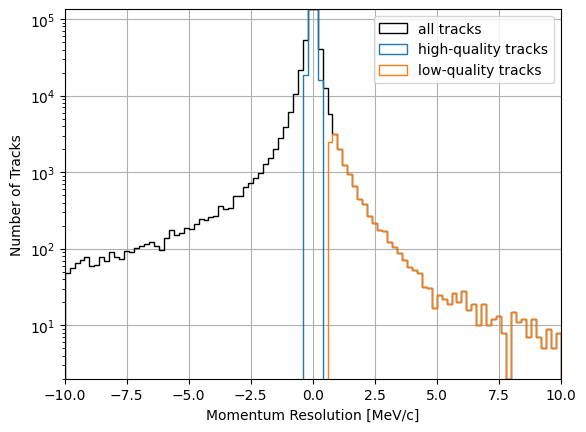

In [ ]:
min_mom_res=-10
max_mom_res=10
n_mom_res_bins=100

fig, ax = plt.subplots(1, 1)
bins, counts, patches = ax.hist(mom_res, bins=n_mom_res_bins, range=(min_mom_res,max_mom_res), log=True, histtype='step', color='black', label='all tracks')
bins, counts, patches = ax.hist(mom_res[high_qual], bins=n_mom_res_bins, range=(min_mom_res,max_mom_res), log=True, histtype='step', label='high-quality tracks')
bins, counts, patches = ax.hist(mom_res[low_qual], bins=n_mom_res_bins, range=(min_mom_res,max_mom_res), log=True, histtype='step', label='low-quality tracks')
ax.legend()
ax.margins(0)
ax.grid(True)
ax.set_xlabel("Momentum Resolution [MeV/c]")
ax.set_ylabel("Number of Tracks")

Here we plot all the training features. Note that we have used ```density=True``` so each histogram is normalized to unit area

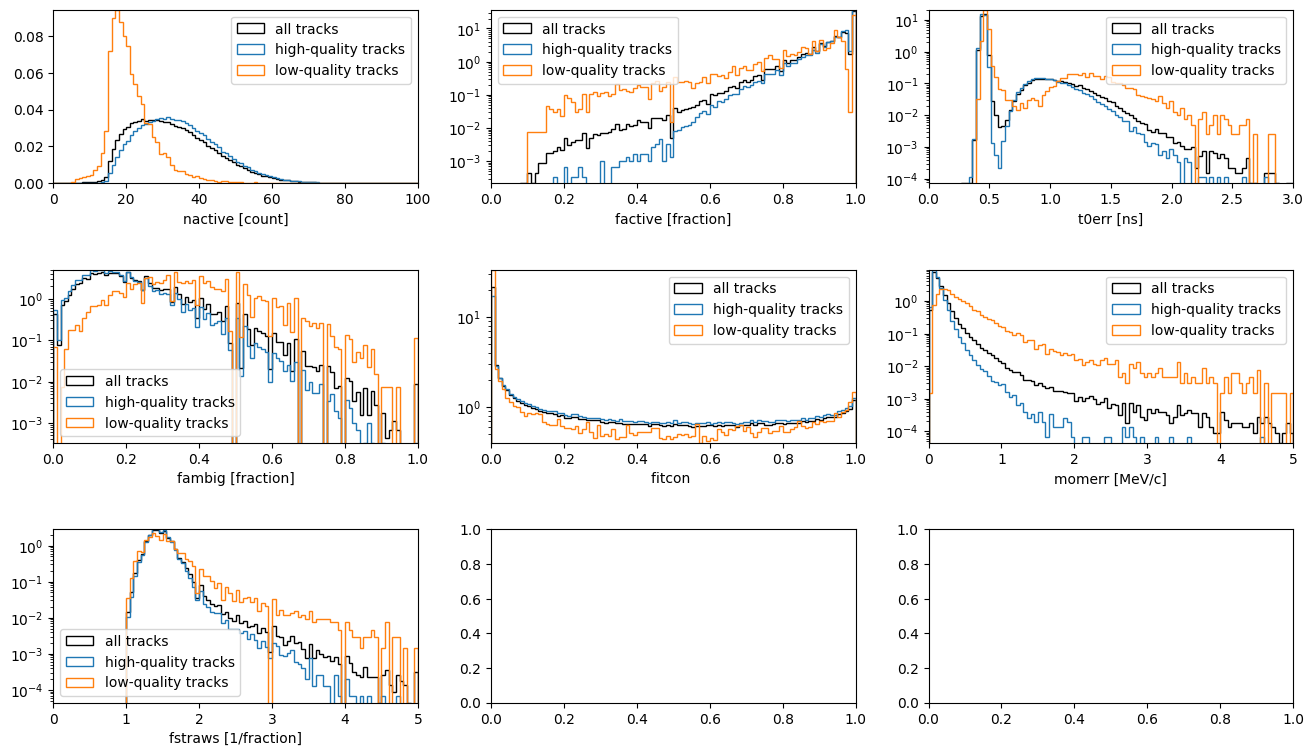

In [ ]:
fig, axs = plt.subplots(3, 3, figsize=(16,9))
fig.subplots_adjust(hspace=.5)
x_mins=[0, 0, 0, 0, 0, 0, 0]
x_maxs=[100, 1, 3, 1, 1, 5, 5]
log_ys=[False, True, True, True, True, True, True]
#log_ys=[False, False, False, False, False, False, False]
units=['[count]', '[fraction]', '[ns]', '[fraction]', '', '[MeV/c]', '[1/fraction]']
density=True
for i_var in range(0, n_input_vars):
    bins, counts, patches = axs.flatten()[i_var].hist(input_dataset[:,i_var], bins=100, range=(x_mins[i_var],x_maxs[i_var]), histtype='step', color='black', log=log_ys[i_var], label='all tracks', density=density)
    bins, counts, patches = axs.flatten()[i_var].hist(input_dataset[:,i_var][high_qual], bins=100, range=(x_mins[i_var],x_maxs[i_var]), histtype='step', log=log_ys[i_var], label='high-quality tracks', density=density)
    bins, counts, patches = axs.flatten()[i_var].hist(input_dataset[:,i_var][low_qual], bins=100, range=(x_mins[i_var],x_maxs[i_var]), histtype='step', log=log_ys[i_var], label='low-quality tracks', density=density)
    axs.flatten()[i_var].set_xlabel(input_var_names[i_var]+" "+units[i_var])
    axs.flatten()[i_var].margins(0)
    axs.flatten()[i_var].legend()

Now we balance the inputs since we don't have that many low-quality tracks to train on

In [ ]:
'''
# In this cell x_ variables are features, and y_ are the output results
min_len = min(len(input_dataset[high_qual]), len(input_dataset[low_qual]))

x_high_qual_dataset = input_dataset[high_qual][:min_len]
x_low_qual_dataset = input_dataset[low_qual][:min_len]

x_balanced_input = np.concatenate((x_high_qual_dataset, x_low_qual_dataset))
# set 1 to be high quality, and 0 to be low quality
y_balanced_input = np.concatenate((np.ones(x_high_qual_dataset.shape[0]), np.zeros(x_low_qual_dataset.shape[0])))

# split the dataset into train and test samples
x_train, x_test, y_train, y_test = train_test_split(x_balanced_input, y_balanced_input, test_size=0.5, random_state=42)
# further split the test sample, into testing and validation samples
x_test, x_valid, y_test, y_valid = train_test_split(x_test, y_test, test_size=0.5, random_state=42)
print("N train = "+str(len(x_train)) + ", N test = "+str(len(x_test)) + ", N valid = "+str(len(x_valid)))
'''

'\n# In this cell x_ variables are features, and y_ are the output results\nmin_len = min(len(input_dataset[high_qual]), len(input_dataset[low_qual]))\n\nx_high_qual_dataset = input_dataset[high_qual][:min_len]\nx_low_qual_dataset = input_dataset[low_qual][:min_len]\n\nx_balanced_input = np.concatenate((x_high_qual_dataset, x_low_qual_dataset))\n# set 1 to be high quality, and 0 to be low quality\ny_balanced_input = np.concatenate((np.ones(x_high_qual_dataset.shape[0]), np.zeros(x_low_qual_dataset.shape[0])))\n\n# split the dataset into train and test samples\nx_train, x_test, y_train, y_test = train_test_split(x_balanced_input, y_balanced_input, test_size=0.5, random_state=42)\n# further split the test sample, into testing and validation samples\nx_test, x_valid, y_test, y_valid = train_test_split(x_test, y_test, test_size=0.5, random_state=42)\nprint("N train = "+str(len(x_train)) + ", N test = "+str(len(x_test)) + ", N valid = "+str(len(x_valid)))\n'

In [ ]:
# In this cell x_ variables are features, and y_ are the output results
min_len = min(len(input_dataset[high_qual]), len(input_dataset[low_qual]))

# Get the INDICES of high and low quality tracks
high_qual_indices = np.where(high_qual)[0][:min_len]
low_qual_indices = np.where(low_qual)[0][:min_len]

# Create balanced dataset
x_high_qual_dataset = input_dataset[high_qual][:min_len]
x_low_qual_dataset = input_dataset[low_qual][:min_len]
x_balanced_input = np.concatenate((x_high_qual_dataset, x_low_qual_dataset))

# Set 1 to be high quality, and 0 to be low quality
y_balanced_input = np.concatenate((np.ones(x_high_qual_dataset.shape[0]), np.zeros(x_low_qual_dataset.shape[0])))

# Track the original indices
balanced_indices = np.concatenate((high_qual_indices, low_qual_indices))

# Split the dataset into train and test samples, keeping track of indices
x_train, x_test, y_train, y_test, train_indices, test_indices = train_test_split(
    x_balanced_input, y_balanced_input, balanced_indices, test_size=0.5, random_state=42
)

# Further split the test sample into testing and validation samples
x_test, x_valid, y_test, y_valid, test_indices, valid_indices = train_test_split(
    x_test, y_test, test_indices, test_size=0.5, random_state=42
)

print("N train = "+str(len(x_train)) + ", N test = "+str(len(x_test)) + ", N valid = "+str(len(x_valid)))

N train = 13449, N test = 6724, N valid = 6725


Here we plot the features for each of the training, testing, and validation samples. All these plots should look similar

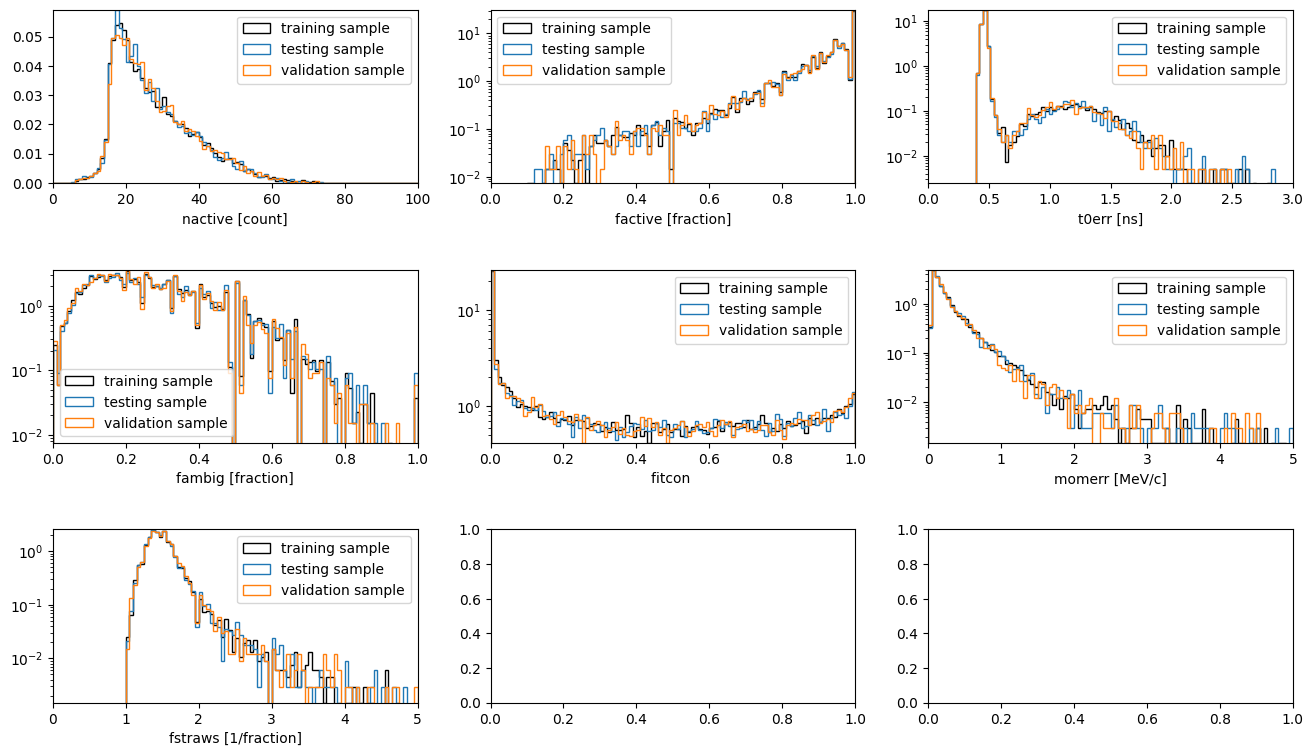

In [ ]:
fig, axs = plt.subplots(3, 3, figsize=(16,9))
fig.subplots_adjust(hspace=.5)
for i_var in range(0, n_input_vars):
    bins, counts, patches = axs.flatten()[i_var].hist(x_train[:,i_var], bins=100, range=(x_mins[i_var],x_maxs[i_var]), histtype='step', color='black', log=log_ys[i_var], label='training sample', density=True)
    bins, counts, patches = axs.flatten()[i_var].hist(x_test[:,i_var], bins=100, range=(x_mins[i_var],x_maxs[i_var]), histtype='step', log=log_ys[i_var], label='testing sample', density=True)
    bins, counts, patches = axs.flatten()[i_var].hist(x_valid[:,i_var], bins=100, range=(x_mins[i_var],x_maxs[i_var]), histtype='step', log=log_ys[i_var], label='validation sample', density=True)
    axs.flatten()[i_var].set_xlabel(input_var_names[i_var]+" "+units[i_var])
    axs.flatten()[i_var].margins(0)
    axs.flatten()[i_var].legend()

Here we now build the model and do the training. Here we are copying what was done in the old TrkQual. Namely:
 - N, N-1 neurons in the hidden layers
 - sigmoid activation functions
 - no dropout layers

Now get the predicted values for the input dataset (ideally, this would be a separate dataset)


Training with 500 trees...
Log Loss Score: 0.2945
  Accuracy on validation: 0.8739 ± 0.0040
  Final validation error: 0.1261


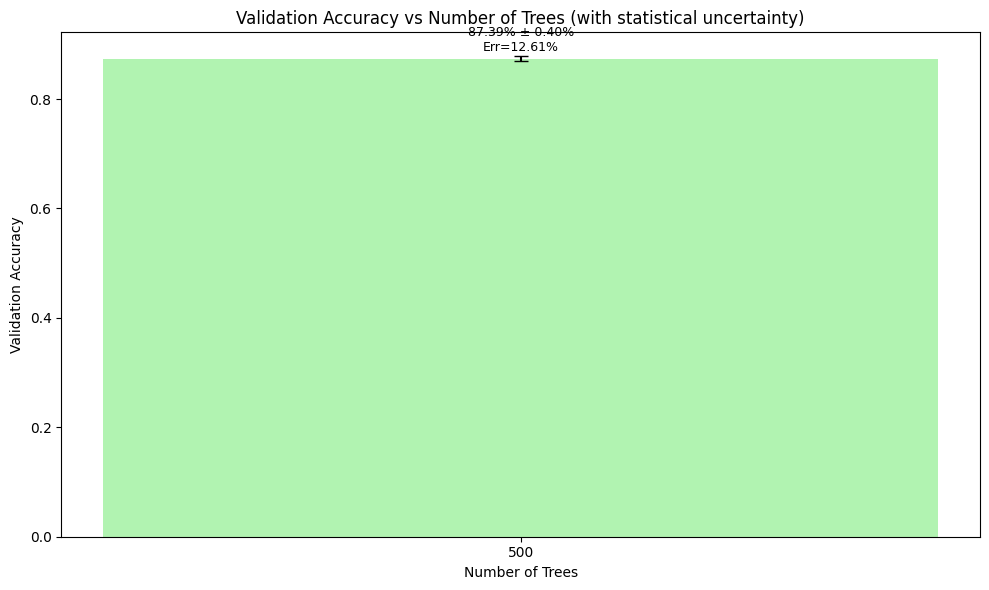

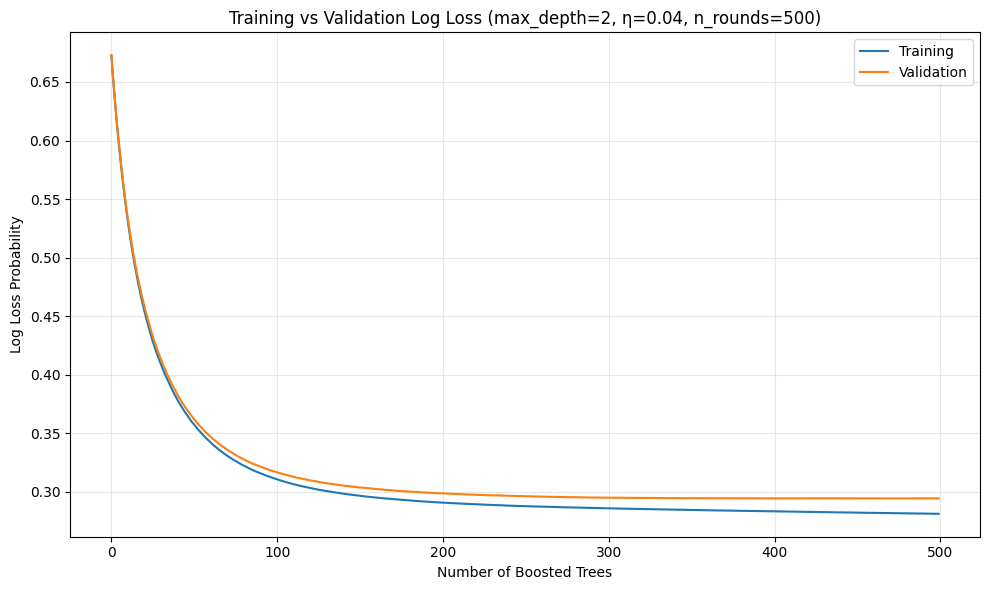

In [ ]:
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, log_loss
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt

# True labels for your dataset
y_full = np.concatenate((
    np.ones(input_dataset[high_qual].shape[0]),   # high-quality
    np.zeros(input_dataset[low_qual].shape[0])    # low-quality
))
x_full = np.concatenate((
    input_dataset[high_qual],
    input_dataset[low_qual]
))

# Prepare the DMatrix objects (just in case you need them later)
dtrain = xgb.DMatrix(x_train, label=y_train)
dvalid = xgb.DMatrix(x_valid, label=y_valid)

# Different numbers of trees to try
tree_counts = [500]

evals_result = {} 
final_accs = []
final_uncertainties = []
final_errors = []

N = len(y_valid)  # number of validation samples

for n_rounds in tree_counts:
    print(f"\nTraining with {n_rounds} trees...")

    # Create and fit XGBClassifier instead of xgb.train
    model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    max_depth=2, #2
    learning_rate=0.04, #0.04
    n_estimators=n_rounds,
    subsample=1.0, #0.8
    colsample_bytree=1.0, #0.8
    reg_lambda=0.5,
    reg_alpha=0.5,
    gamma=0.1,
)
    
    model.fit(x_train, y_train, eval_set=[(x_train, y_train), (x_valid, y_valid)], verbose=False)

    # Save original full dataset predictions — used for perturbation comparison
    y_pred_prob_original = model.predict_proba(x_full)[:, 1]
    
    # Predictions on validation set
    y_pred_prob = model.predict_proba(x_valid)[:, 1]  # probability of positive class
    y_pred = (y_pred_prob > 0.5).astype(int)

    log_loss_score = log_loss(y_valid, y_pred_prob)
    print(f"Log Loss Score: {log_loss_score:.4f}") 
    
    acc = accuracy_score(y_valid, y_pred)
    err = 1 - acc   # validation error
    sigma_acc = sqrt(acc * (1 - acc) / N)  # statistical uncertainty
    
    final_accs.append(acc)
    final_errors.append(err)
    final_uncertainties.append(sigma_acc)
    
    print(f"  Accuracy on validation: {acc:.4f} ± {sigma_acc:.4f}")
    print(f"  Final validation error: {err:.4f}")


#Plot accuracy with error bars
plt.figure(figsize=(10,6))
bars = plt.bar([str(n) for n in tree_counts], final_accs, yerr=final_uncertainties, 
        capsize=5, color="lightgreen", alpha=0.7)
plt.ylabel("Validation Accuracy")
plt.xlabel("Number of Trees")
plt.title("Validation Accuracy vs Number of Trees (with statistical uncertainty)")

# Annotate with percentage, uncertainty, and error
for i, (acc, sigma, err) in enumerate(zip(final_accs, final_uncertainties, final_errors)):
    plt.text(i, acc + sigma + 0.005, 
             f"{acc:.2%} ± {sigma:.2%}\nErr={err:.2%}", 
             ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show() 

#Plot training vs validation logloss for the last model
evals_result = model.evals_result()
epochs = len(evals_result["validation_0"]["logloss"])
x_axis = range(epochs)

plt.figure(figsize=(10,6))
plt.plot(x_axis, evals_result["validation_0"]["logloss"], label="Training")
plt.plot(x_axis, evals_result["validation_1"]["logloss"], label="Validation")
plt.legend()
plt.ylabel("Log Loss Probability")
plt.xlabel("Number of Boosted Trees")
plt.title(f"Training vs Validation Log Loss (max_depth=2, η={0.04}, n_rounds={epochs})")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


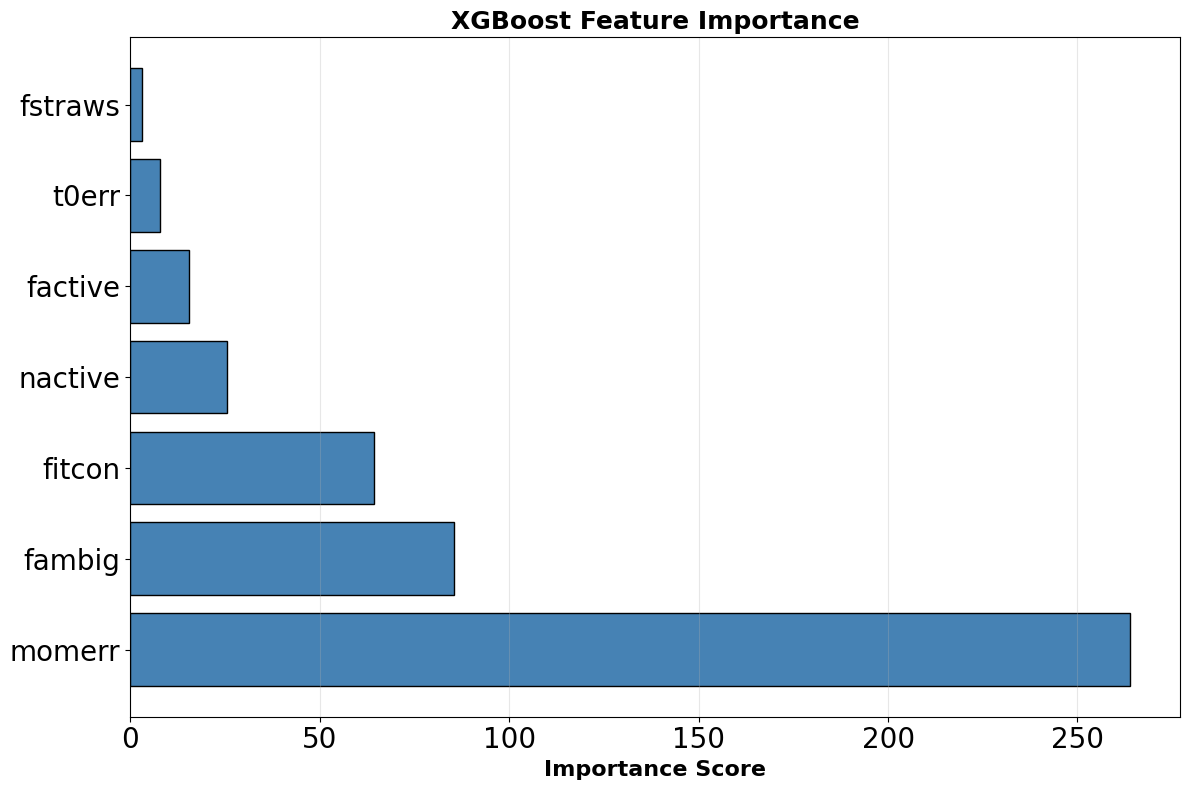

momerr: 263.8634033203125
fambig: 85.33271789550781
fitcon: 64.37850189208984
nactive: 25.38838005065918
factive: 15.501440048217773
t0err: 7.749325752258301
fstraws: 3.086972236633301


In [ ]:
import matplotlib.pyplot as plt

# Get Booster object
booster = model.get_booster()

# Get feature importance (gain, weight, or cover)
importance = booster.get_score(importance_type='gain')

# Map feature codes to actual names
feature_names = []
importance_values = []
for feature, score in importance.items():
    if feature.startswith('f') and feature[1:].isdigit():
        feature_name = input_var_names[int(feature[1:])]  # Convert 'f4' -> actual name
    elif feature in input_var_names:
        feature_name = feature
    else:
        feature_name = feature
    feature_names.append(feature_name)
    importance_values.append(score)

# Sort by importance (optional but recommended)
sorted_indices = sorted(range(len(importance_values)), key=lambda i: importance_values[i], reverse=True)
feature_names = [feature_names[i] for i in sorted_indices]
importance_values = [importance_values[i] for i in sorted_indices]

# Plot with larger fonts
plt.figure(figsize=(12, 8))
plt.barh(feature_names, importance_values, color='steelblue', edgecolor='black')
plt.xlabel('Importance Score', fontsize=16, fontweight='bold')
#plt.ylabel('Feature', fontsize=20, fontweight='bold')
plt.title('XGBoost Feature Importance', fontsize=18, fontweight='bold')
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Print numerical values
for name, score in zip(feature_names, importance_values):
    print(f"{name}: {score}")

In [ ]:
'''
for i in range(1):  # visualize first 3 trees
    #plt.figure(figsize=(20, 10))
    plt.rcParams['figure.figsize'] = [20, 10] 
    xgb.plot_tree(model, num_trees=i, rankdir="LR")
    plt.show()
'''

'\nfor i in range(1):  # visualize first 3 trees\n    #plt.figure(figsize=(20, 10))\n    plt.rcParams[\'figure.figsize\'] = [20, 10] \n    xgb.plot_tree(model, num_trees=i, rankdir="LR")\n    plt.show()\n'

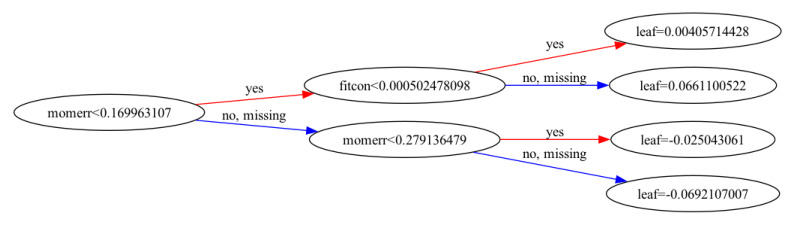

In [ ]:
# Create a feature map file
with open('fmap.txt', 'w') as f:
    for idx, name in enumerate(input_var_names):
        f.write(f"{idx}\t{name}\tq\n")

# Now plot with the feature map
for i in range(1):
    plt.rcParams['figure.figsize'] = [10, 10] 
    xgb.plot_tree(model, num_trees=i, rankdir="LR", fmap='fmap.txt')
    plt.show()

Now we save the model

In [ ]:
dinput = xgb.DMatrix(input_dataset)
output_trkqual = model.predict(input_dataset)  # input_dataset is a numpy array or DataFrame
trkqual = np.array(output_trkqual)    # keep same shape as before

### Some Validation Plots

Here is the loss as a function of epoch for the training and validation datasets

In [ ]:
import matplotlib.pyplot as plt


def plot_loss(evals_result):
    """
    Plots training and validation loss from XGBoost.
    
    evals_result: dictionary returned by xgb.train with evals_result=evals_result
    """
    train_loss = evals_result['train']['logloss']
    valid_loss = evals_result['valid']['logloss']

    plt.figure(figsize=(8,5))
    plt.plot(train_loss, label="train")
    plt.plot(valid_loss, label="validation")
    plt.xlabel("Boosting round")
    plt.ylabel("Logloss")
    plt.title("Training vs Validation Loss (XGBoost)")
    plt.legend()
    plt.show()

Here we get the ROC curve, as well as the cut value that rejects 99% of low-quality tracks. (For a real analysis, we would find a different optimization procedure)

500 trees: trkqual_cut=0.9200000166893005, signal eff=57.0%, background rej=99.0%


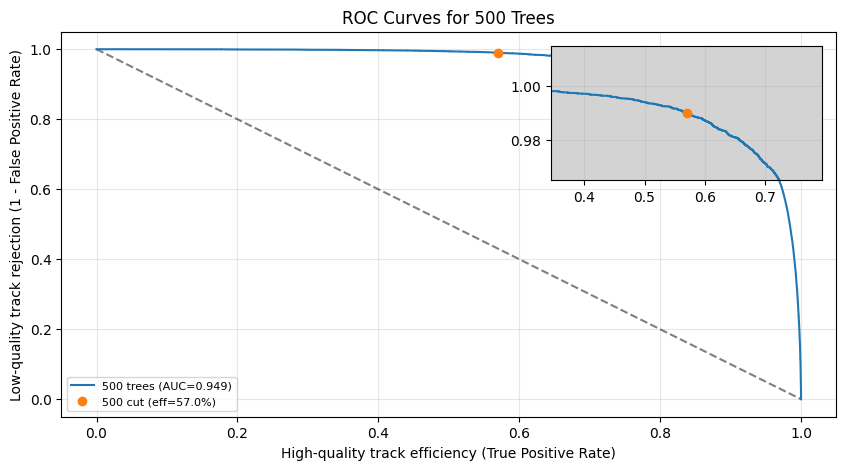

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Tree counts to evaluate
tree_counts = [500] #1000
plt.figure(figsize=(10,5))
ax = plt.gca()
ax.plot([0, 1], [1, 0], 'k--', alpha=0.5)  # diagonal
roc_data = {}
for n_rounds in tree_counts:
    # Predict using only the first n_rounds trees
    y_pred_prob = model.predict_proba(x_full, iteration_range=(0, n_rounds))[:, 1]  # get probability of class 1
    
    # Compute ROC
    fpr, tpr, thresholds = roc_curve(y_full, y_pred_prob, pos_label=1)
    auc_score = auc(fpr, tpr)
    
    # Cut point for 99% background rejection
    rej_target = 0.99
    indices = np.where(1 - fpr >= rej_target)[0]
    cut_idx = indices[-1] if len(indices) > 0 else 0
    sig_eff = tpr[cut_idx]
    trkqual_cut = round(thresholds[cut_idx], 2)
    
    roc_data[n_rounds] = (fpr, tpr, cut_idx)
    
    print(f"{n_rounds} trees: trkqual_cut={trkqual_cut}, "
          f"signal eff={sig_eff*100:.1f}%, background rej={(1-fpr[cut_idx])*100:.1f}%")
    
    # Plot main ROC, Legend shows AUC and signal efficiency
    ax.plot(tpr, 1 - fpr, label=f"{n_rounds} trees (AUC={auc_score:.3f})")
    ax.plot(tpr[cut_idx], 1 - fpr[cut_idx], 'o', label=f"{n_rounds} cut (eff={sig_eff*100:.1f}%)")
# Main plot settings
ax.set_xlabel("High-quality track efficiency (True Positive Rate)")
ax.set_ylabel("Low-quality track rejection (1 - False Positive Rate)")
ax.set_title("ROC Curves for 500 Trees")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
# Zoom inset around cut points
axins = inset_axes(ax, width="35%", height="35%", loc='upper right', borderpad=1.0)
axins.set_facecolor("lightgray")
for n_rounds in tree_counts:
    fpr, tpr, cut_idx = roc_data[n_rounds]
    axins.plot(tpr, 1 - fpr)
    axins.plot(tpr[cut_idx], 1 - fpr[cut_idx], 'o')
# Zoom ranges around mean cut points
cut_tpr = [roc_data[n][1][roc_data[n][2]] for n in tree_counts]
cut_rej = [1 - roc_data[n][0][roc_data[n][2]] for n in tree_counts]
mean_tpr = np.mean(cut_tpr)
mean_rej = np.mean(cut_rej)
zoom_x = 0.45 #0.20
zoom_y = 0.05
axins.set_xlim(mean_tpr - zoom_x/2, mean_tpr + zoom_x/2)
axins.set_ylim(mean_rej - zoom_y/2, mean_rej + zoom_y/2)
axins.grid(alpha=0.3)
plt.show()

## Results

In [ ]:
# Create datasets for plotting (train, valid, test)
train_mom_res = mom_res[train_indices]
valid_mom_res = mom_res[valid_indices]
test_mom_res = mom_res[test_indices]

train_high_qual = high_qual[train_indices]
valid_high_qual = high_qual[valid_indices]
test_high_qual = high_qual[test_indices]

# Get predictions for each split
train_predictions = model.predict_proba(x_train)[:, 1]
valid_predictions = model.predict_proba(x_valid)[:, 1]
test_predictions = model.predict_proba(x_test)[:, 1]

# Create the datasets list for plotting
datasets = [
    ('Training', train_mom_res, train_high_qual, train_predictions),
    ('Validation', valid_mom_res, valid_high_qual, valid_predictions),
    ('Test', test_mom_res, test_high_qual, test_predictions)
]

# Create models_to_train
class TrainedModel:
    def __init__(self, name, trkqual_cut):
        self.name = name
        self.trkqual_cut = trkqual_cut

models_to_train = [TrainedModel('XGBoost', trkqual_cut)]

print("Datasets created for plotting:")
for name, mr, hq, pred in datasets:
    print(f"  {name}: mom_res={len(mr)}, predictions={len(pred)}, match={len(mr)==len(pred)}")

Datasets created for plotting:
  Training: mom_res=13449, predictions=13449, match=True
  Validation: mom_res=6725, predictions=6725, match=True
  Test: mom_res=6724, predictions=6724, match=True


Now we make the main plot: the momentum resolution with the trkqual cut we found for 99% low-quality track rejection

Text(0, 0.5, 'Number of Tracks')

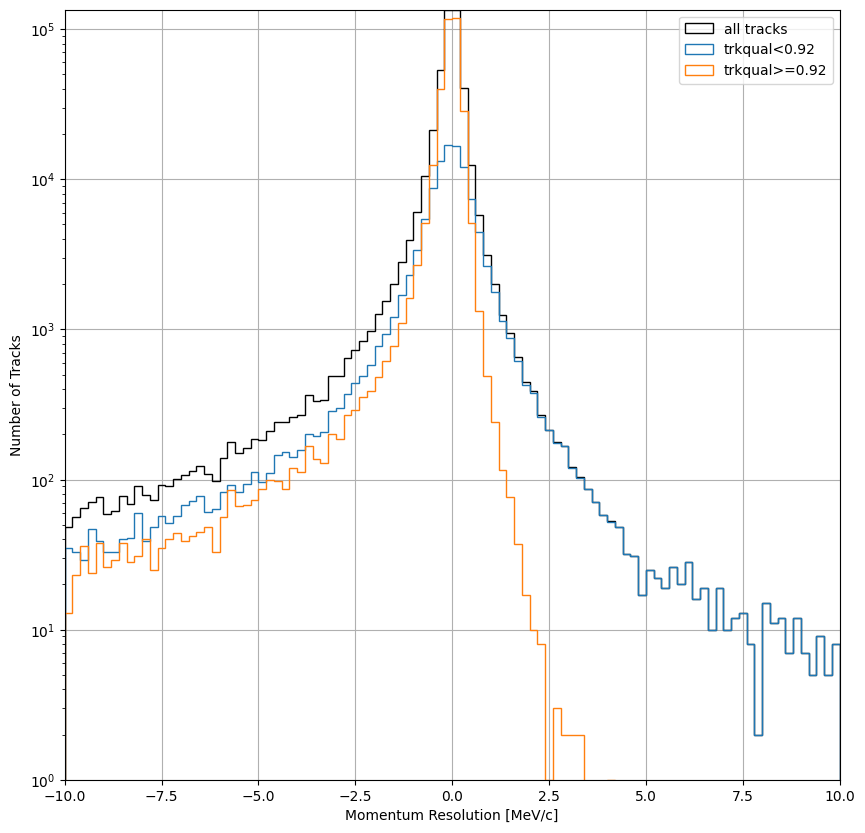

In [ ]:
fig, ax = plt.subplots(1,1)
_, _, _ = ax.hist(mom_res, bins=n_mom_res_bins, range=(min_mom_res,max_mom_res), log=True, histtype='step', color='black', label='all tracks')
_, _, _ = ax.hist(mom_res[trkqual<trkqual_cut], bins=n_mom_res_bins, range=(min_mom_res,max_mom_res), log=True, histtype='step', label='trkqual<'+str(trkqual_cut))
_, _, _ = ax.hist(mom_res[trkqual>=trkqual_cut], bins=n_mom_res_bins, range=(min_mom_res,max_mom_res), log=True, histtype='step', label='trkqual>='+str(trkqual_cut))
ax.legend()
ax.margins(0)
ax.grid(True)
ax.set_xlabel("Momentum Resolution [MeV/c]")
ax.set_ylabel("Number of Tracks")

Text(7.1, 0.5, 'low-quality tracks')

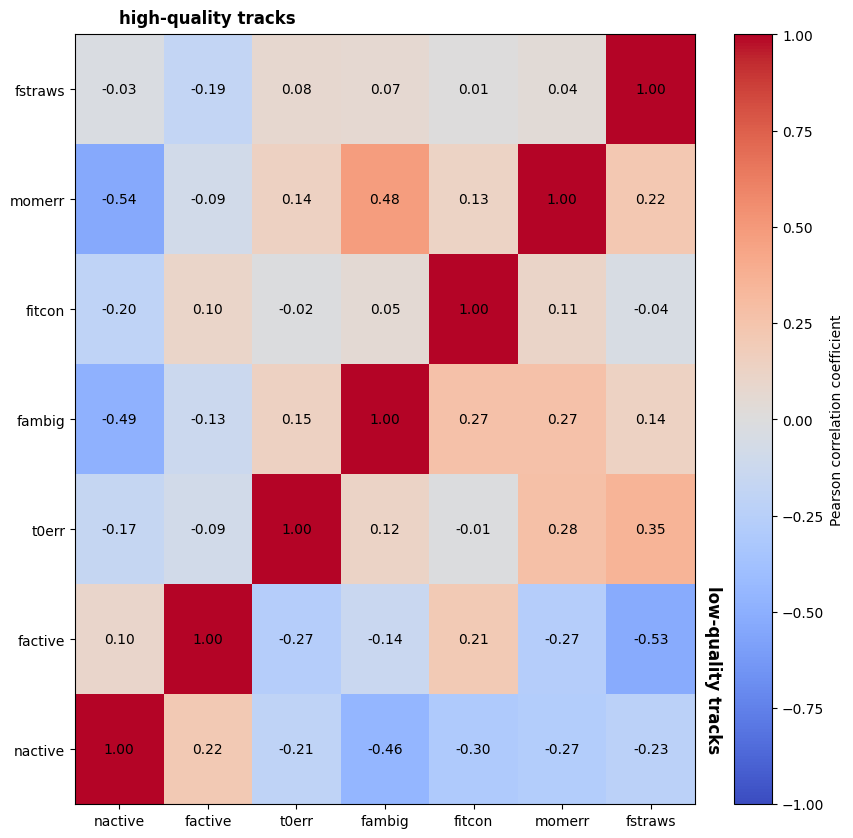

In [ ]:
qualities = [ high_qual, low_qual ]
qual_labels = ["high", "low"]

xs = np.linspace(0,n_input_vars-1,n_input_vars)
ys = xs
x_corrs=[]
y_corrs=[]
corrs=[]#np.ndarray((n_input_vars,n_input_vars))
for qual_label,quality in zip(qual_labels,qualities):
    for i_x,x in enumerate(xs):
        x_i = input_dataset[:,i_x][quality]
        mean_x = np.mean(x_i)
        for i_y,y in enumerate(ys):
            if qual_label=="high":
                if (y<x):
                    continue
            elif qual_label=="low":
                if (y>=x):
                    continue
            y_i = input_dataset[:,i_y][quality]
            mean_y = np.mean(y_i)
            corr =  ( np.sum((x_i-mean_x)*(y_i - mean_y)) ) / ((np.sqrt(np.sum((x_i-mean_x)**2)))*(np.sqrt(np.sum((y_i-mean_y)**2))))
            x_corrs.append(x+0.5)
            y_corrs.append(y+0.5)
            corrs.append(corr)

#print(x_corrs)
#print(corrs)
H, xedges, yedges = np.histogram2d(x_corrs, y_corrs, bins=np.linspace(0,n_input_vars,n_input_vars+1), weights=corrs)
X, Y = np.meshgrid(xedges, yedges)
heatmap = plt.pcolormesh(Y, X, H, cmap='coolwarm')
cbar = plt.colorbar(heatmap)
plt.clim(-1,1)
_ = plt.xticks(xs+0.5, input_var_names)
_ = plt.yticks(ys+0.5, input_var_names)
cbar.ax.set_ylabel("Pearson correlation coefficient")
#print(yedges[:-1])
for x,y,corr in zip(x_corrs,y_corrs,corrs):
    if (abs(corr)>0.0):
        plt.text(x, y, '%.2f' % corr,
                 horizontalalignment='center',
                 verticalalignment='center',
                 )
plt.text(0.5, 7.1, "high-quality tracks", fontsize='large', fontweight='bold')#, horizontalalignment='center')#, rotation=45)
plt.text(7.1, 0.5, "low-quality tracks", fontsize='large', fontweight='bold', rotation=-90)#, verticalalignment='center', rotation=-90)

In [ ]:
# Write out all histograms and plots to a ROOT file for future reference
outfile = uproot.recreate(output_modelname+"_plots.root")

# Momentum resolution plots
mom_res_hist_all = np.histogram(mom_res, bins=n_mom_res_bins, range=(min_mom_res,max_mom_res))
outfile["all_mom_res"] = mom_res_hist_all
mom_res_hist_high_qual = np.histogram(mom_res[high_qual], bins=n_mom_res_bins, range=(min_mom_res,max_mom_res))
outfile["high_qual_mom"] = mom_res_hist_high_qual
mom_res_hist_low_qual = np.histogram(mom_res[low_qual], bins=n_mom_res_bins, range=(min_mom_res,max_mom_res))
outfile["low_qual_mom_res"] = mom_res_hist_low_qual
mom_res_hist_pass = np.histogram(mom_res[(trkqual>=trkqual_cut)], bins=n_mom_res_bins, range=(min_mom_res,max_mom_res))
outfile["pass_mom_res"] = mom_res_hist_pass
mom_res_hist_fail = np.histogram(mom_res[(trkqual<trkqual_cut)], bins=n_mom_res_bins, range=(min_mom_res,max_mom_res))
outfile["fail_mom_res"] = mom_res_hist_fail

# datasets (input, train, text, and valid)
datasets=[input_dataset, input_dataset, input_dataset, x_train, x_test, x_valid, input_dataset, input_dataset]
prefixes = ["all_", "high_qual_", "low_qual_", "train_", "test_", "valid_", "pass_", "fail_"]
cuts = [(), (high_qual), (low_qual), (), (), (), (trkqual>=trkqual_cut), (trkqual<trkqual_cut)]
# Feature histograms
for dataset,prefix,cut in zip(datasets, prefixes, cuts):
    for i_var in range(0, n_input_vars):
        feature_all = np.histogram(dataset[:,i_var][cut], bins=100, range=(x_mins[i_var],x_maxs[i_var]))
        outfile[prefix+"feature"+str(i_var)+"_"+input_var_names[i_var]] = feature_all
        feature_norm_all = np.histogram(dataset[:,i_var][cut], bins=100, range=(x_mins[i_var],x_maxs[i_var]), density=True)
        outfile[prefix+"feature"+str(i_var)+"_"+input_var_names[i_var]+"_norm"] = feature_norm_all
'''import pandas as pd
df = pd.DataFrame({"tpr" : tpr_keras, "fpr" : fpr_keras, "thresh" : thresholds_keras})
outfile["roc_curve"] = df '''
outfile["corr_matrix"] = H,xedges,yedges

In [ ]:
import keras
print(keras.__version__)

3.10.0


Text(0, 0.5, 'Number of Tracks')

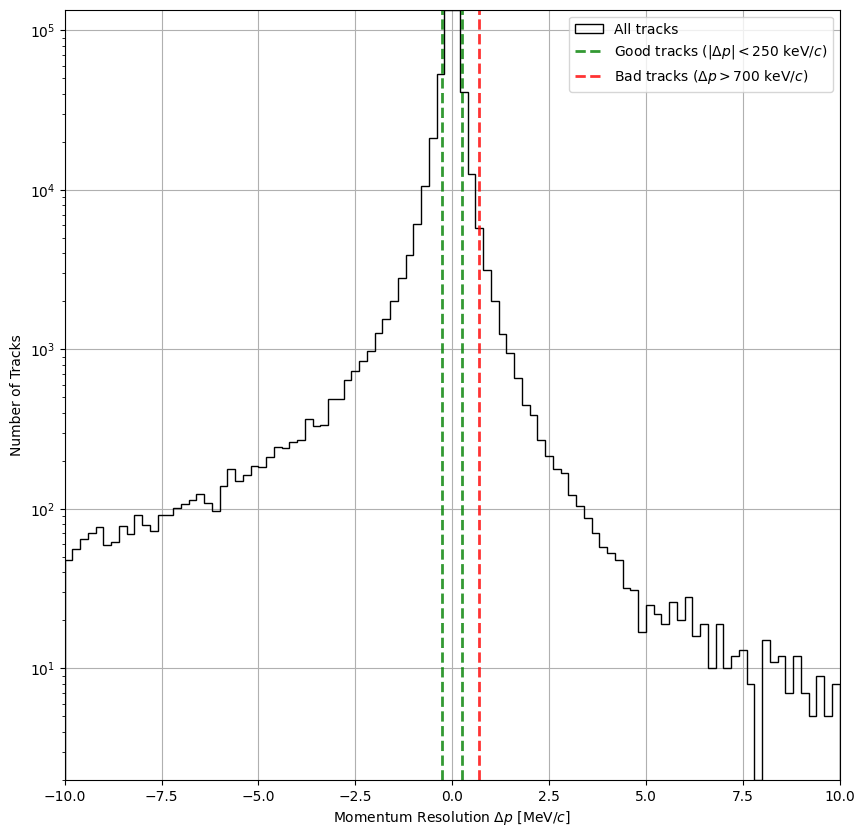

In [ ]:
fig, ax = plt.subplots(1,1)

ax.hist(
    mom_res,
    bins=n_mom_res_bins,
    range=(min_mom_res, max_mom_res),
    log=True,
    histtype='step',
    color='black',
    label='All tracks'
)

# Good tracks: |ΔP| < 250 keV/c = 0.25 MeV/c
ax.axvline(x=0.25, color='green', linestyle='--', linewidth=2, alpha=0.8)
ax.axvline(x=-0.25, color='green', linestyle='--', linewidth=2, alpha=0.8,
           label=r'Good tracks ($|\Delta p| < 250$ keV/$c$)')

# Bad tracks: ΔP > 700 keV/c = 0.7 MeV/c (positive tail only)
ax.axvline(x=0.7, color='red', linestyle='--', linewidth=2, alpha=0.8,
           label=r'Bad tracks ($\Delta p > 700$ keV/$c$)')

ax.legend()
ax.margins(0)
ax.grid(True)
ax.set_xlabel(r"Momentum Resolution $\Delta p$ [MeV/$c$]")
ax.set_ylabel("Number of Tracks")


## factive feature importance analysis!

In [ ]:
# Inspect the model object
print(type(model))
print(dir(model))

# If it's a Pipeline, check its steps
if hasattr(model, 'steps'):
    print("\nPipeline steps:")
    for name, step in model.steps:
        print(f"  {name}: {type(step)}")

# If it's a Pipeline, the XGBoost classifier is usually the last step
if hasattr(model, 'named_steps'):
    for name, step in model.named_steps.items():
        print(f"\nStep '{name}' type: {type(step)}")
        if hasattr(step, 'save_model'):
            print(f"  --> XGBoost found at step '{name}'!")
            step.save_model(f"mu2e_project/trkQual_model.json")
            print("Saved!")

<class 'xgboost.sklearn.XGBClassifier'>
['_Booster', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__sklearn_clone__', '__sklearn_is_fitted__', '__sklearn_tags__', '__str__', '__subclasshook__', '__weakref__', '_build_request_for_signature', '_can_use_inplace_predict', '_check_feature_names', '_check_n_features', '_configure_fit', '_create_dmatrix', '_doc_link_module', '_doc_link_template', '_doc_link_url_param_generator', '_estimator_type', '_get_default_requests', '_get_doc_link', '_get_iteration_range', '_get_metadata_request', '_get_param_names', '_get_tags', '_get_type', '_load_model_attributes', '_more_tags', '_repr_html_', '_repr_html_inner', '_repr_mimebundle_', '_set_evaluation_result', '_update_s

In [ ]:
# Active hit fraction at the 99% background rejection cut
import pandas as pd

# Use factive directly from x_full (already = nactive/nhits)
x_full_df    = pd.DataFrame(x_full, columns=input_var_names)
f_track_full = x_full_df['factive'].values

# Apply the BDT cut derived from ROC curve
bdt_pass = y_pred_prob >= trkqual_cut

# Compute fractions and uncertainties
def f_and_sigma(f_vals):
    N     = len(f_vals)
    f     = f_vals.mean()
    sigma = np.sqrt(f * (1 - f) / N)
    return f, sigma, N

# Split by truth label AND BDT cut
sig_pass = bdt_pass & (y_full == 1)
bkg_pass = bdt_pass & (y_full == 0)

f_sig_before, s_sig_before, N_sig_before = f_and_sigma(f_track_full[y_full == 1])
f_bkg_before, s_bkg_before, N_bkg_before = f_and_sigma(f_track_full[y_full == 0])
f_sig_after,  s_sig_after,  N_sig_after  = f_and_sigma(f_track_full[sig_pass])
f_bkg_after,  s_bkg_after,  N_bkg_after  = f_and_sigma(f_track_full[bkg_pass])

print(f"BDT cut value: {trkqual_cut}")
print()
print(f"{'':30s} {'N':>8}  {'f_active':>10}  {'±σ':>8}")
print("-" * 62)
print(f"{'Signal (before cut)':30s} {N_sig_before:>8}  {f_sig_before:>10.4f}  {s_sig_before:>8.4f}")
print(f"{'Signal (after cut)':30s} {N_sig_after:>8}  {f_sig_after:>10.4f}  {s_sig_after:>8.4f}")
print(f"{'Background (before cut)':30s} {N_bkg_before:>8}  {f_bkg_before:>10.4f}  {s_bkg_before:>8.4f}")
print(f"{'Background (after cut)':30s} {N_bkg_after:>8}  {f_bkg_after:>10.4f}  {s_bkg_after:>8.4f}")

BDT cut value: 0.9200000166893005

                                      N    f_active        ±σ
--------------------------------------------------------------
Signal (before cut)              303990      0.9463    0.0004
Signal (after cut)               172011      0.9592    0.0005
Background (before cut)           13449      0.8723    0.0029
Background (after cut)              131      0.9491    0.0192


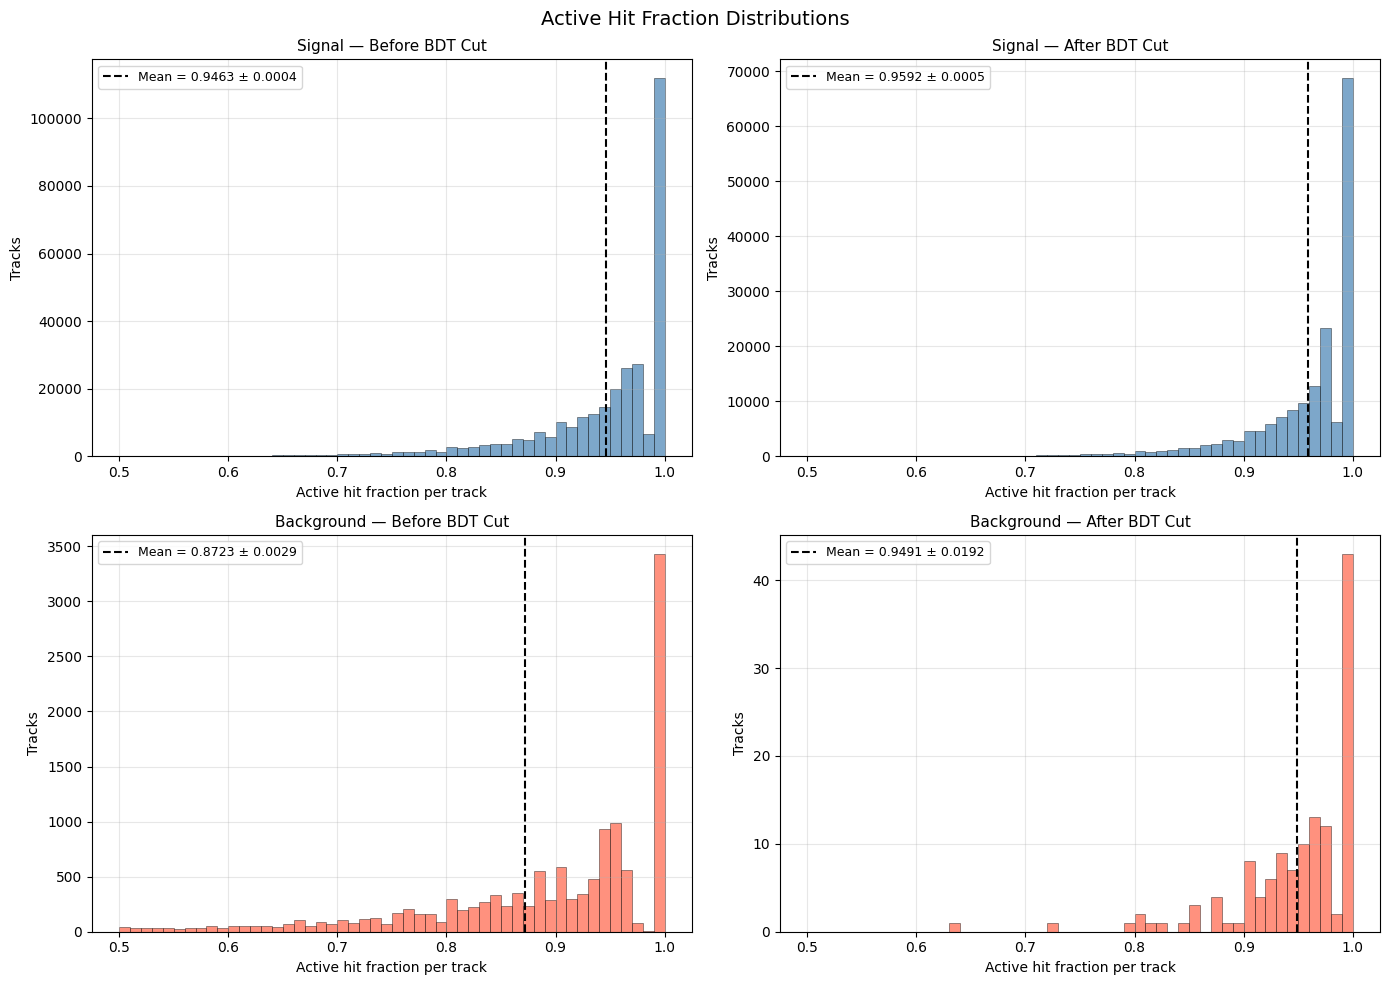

Plot saved.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Active Hit Fraction Distributions", fontsize=14)

configs = [
    (axes[0, 0], f_track_full[y_full == 1],  "Signal — Before BDT Cut",     "steelblue",  f_sig_before, s_sig_before),
    (axes[0, 1], f_track_full[sig_pass],      "Signal — After BDT Cut",      "steelblue",  f_sig_after,  s_sig_after),
    (axes[1, 0], f_track_full[y_full == 0],   "Background — Before BDT Cut", "tomato",     f_bkg_before, s_bkg_before),
    (axes[1, 1], f_track_full[bkg_pass],      "Background — After BDT Cut",  "tomato",     f_bkg_after,  s_bkg_after),
]

for ax, data, title, color, f_mean, f_sigma in configs:
    ax.hist(data, bins=50, range=(0.5, 1.0), color=color, alpha=0.7, edgecolor='black', linewidth=0.4)
    ax.axvline(f_mean, color='black', linestyle='--', linewidth=1.5,
               label=f"Mean = {f_mean:.4f} ± {f_sigma:.4f}")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Active hit fraction per track")
    ax.set_ylabel("Tracks")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
#plt.savefig("active_hit_fraction_distributions.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

In [ ]:
print("Comparison: Original vs Perturbed (nactive + 1)")
print()
print(f"{'':35s} {'Original':>10}  {'Perturbed':>10}  {'Δ':>8}")
print("-" * 68)
print(f"{'BDT cut value':35s} {'0.9200':>10}  {'0.9200':>10}  {'0.0000':>8}")
print()
print(f"{'Signal (before cut) — N':35s} {'303,990':>10}  {'303,990':>10}  {'0':>8}")
print(f"{'Signal (before cut) — f':35s} {'0.9463':>10}  {'0.9770':>10}  {'+0.0307':>8}")
print(f"{'Signal (before cut) — σ':35s} {'0.0004':>10}  {'0.0003':>10}  {'-0.0001':>8}")
print()
print(f"{'Signal (after cut) — N':35s} {'172,011':>10}  {'171,604':>10}  {'-407':>8}")
print(f"{'Signal (after cut) — f':35s} {'0.9592':>10}  {'0.9840':>10}  {'+0.0248':>8}")
print(f"{'Signal (after cut) — σ':35s} {'0.0005':>10}  {'0.0003':>10}  {'-0.0002':>8}")
print()
print(f"{'Background (before cut) — N':35s} {'13,449':>10}  {'13,449':>10}  {'0':>8}")
print(f"{'Background (before cut) — f':35s} {'0.8723':>10}  {'0.9168':>10}  {'+0.0445':>8}")
print(f"{'Background (before cut) — σ':35s} {'0.0029':>10}  {'0.0024':>10}  {'-0.0005':>8}")
print()
print(f"{'Background (after cut) — N':35s} {'131':>10}  {'129':>10}  {'-2':>8}")
print(f"{'Background (after cut) — f':35s} {'0.9491':>10}  {'0.9751':>10}  {'+0.0260':>8}")
print(f"{'Background (after cut) — σ':35s} {'0.0192':>10}  {'0.0137':>10}  {'-0.0055':>8}")

Comparison: Original vs Perturbed (nactive + 1)

                                      Original   Perturbed         Δ
--------------------------------------------------------------------
BDT cut value                           0.9200      0.9200    0.0000

Signal (before cut) — N                303,990     303,990         0
Signal (before cut) — f                 0.9463      0.9770   +0.0307
Signal (before cut) — σ                 0.0004      0.0003   -0.0001

Signal (after cut) — N                 172,011     171,604      -407
Signal (after cut) — f                  0.9592      0.9840   +0.0248
Signal (after cut) — σ                  0.0005      0.0003   -0.0002

Background (before cut) — N             13,449      13,449         0
Background (before cut) — f             0.8723      0.9168   +0.0445
Background (before cut) — σ             0.0029      0.0024   -0.0005

Background (after cut) — N                 131         129        -2
Background (after cut) — f              0.9491    

In [ ]:
# Recreate the dump with correct feature names
booster2 = model.get_booster()
booster2.feature_names = input_var_names
dump = booster2.get_dump(dump_format='text')

# Now find trees using factive
factive_trees = []
for i, tree_text in enumerate(dump):
    if 'factive' in tree_text:
        factive_trees.append(i)

print(f"Trees using factive: {len(factive_trees)}")

Trees using factive: 147


In [ ]:
# Find trees where factive is used as a split
factive_trees = []
for i, tree_text in enumerate(dump):
    if 'factive' in tree_text:
        factive_trees.append(i)

print(f"Trees using factive: {len(factive_trees)}")
print(f"First 20: {factive_trees[:20]}")

# Print the structure of the first few to find the clearest one
for tree_idx in factive_trees[:20]:
    print(f"\n── Tree {tree_idx} ──")
    print(dump[tree_idx])

Trees using factive: 147
First 20: [62, 66, 70, 71, 78, 80, 83, 84, 88, 90, 91, 93, 98, 100, 103, 105, 108, 112, 113, 114]

── Tree 62 ──
0:[fambig<0.15625] yes=1,no=2,missing=2
	1:[factive<0.733333349] yes=3,no=4,missing=4
		3:leaf=-0.0368310437
		4:leaf=0.0274074115
	2:[momerr<0.378263265] yes=5,no=6,missing=6
		5:leaf=-0.00178102171
		6:leaf=-0.0319169573


── Tree 66 ──
0:[fambig<0.280000001] yes=1,no=2,missing=2
	1:[factive<0.895833313] yes=3,no=4,missing=4
		3:leaf=-0.0096364934
		4:leaf=0.0184409972
	2:[momerr<0.505181491] yes=5,no=6,missing=6
		5:leaf=-0.0105878562
		6:leaf=-0.0362604521


── Tree 70 ──
0:[momerr<0.0880625024] yes=1,no=2,missing=2
	1:[fitcon<7.04661019e-18] yes=3,no=4,missing=4
		3:leaf=-0.00624777889
		4:leaf=0.0335007831
	2:[factive<0.953846157] yes=5,no=6,missing=6
		5:leaf=-0.01478652
		6:leaf=0.00767862797


── Tree 71 ──
0:[fambig<0.15625] yes=1,no=2,missing=2
	1:[nactive<26] yes=3,no=4,missing=4
		3:leaf=0.00344344904
		4:leaf=0.029004449
	2:[factive<0.8

In [ ]:
import pandas as pd

# Reload all_leaf_ids
x_valid_df    = pd.DataFrame(x_valid, columns=input_var_names)
dvalid_named  = xgb.DMatrix(x_valid_df, label=y_valid, feature_names=input_var_names)
all_leaf_ids  = booster2.predict(dvalid_named, pred_leaf=True)
leaf_ids_78   = all_leaf_ids[:, 78]
factive_valid = x_valid_df['factive'].values
momerr_valid  = x_valid_df['momerr'].values

# Now extract for tree 78
print("\nTree 78 — Active hit fraction (factive = nactive/nhits) ± σ at each leaf")
print(f"  {'Leaf':>5}  {'N':>6}  {'f active':>10}  {'± σ':>8}")
print(f"  {'-'*40}")
for leaf in np.unique(leaf_ids_78):
    mask  = leaf_ids_78 == leaf
    N     = mask.sum()
    f     = factive_valid[mask].mean()
    sigma = np.sqrt(f * (1 - f) / N)
    print(f"  {int(leaf):>5}  {N:>6}  {f:>10.4f}  {sigma:>8.4f}")


Tree 78 — Active hit fraction (factive = nactive/nhits) ± σ at each leaf
   Leaf       N    f active       ± σ
  ----------------------------------------
      3      44      0.6485    0.0720
      4    1764      0.9528    0.0051
      5    1513      0.7420    0.0112
      6    3404      0.9633    0.0032


Tree 78 — Active hit fraction (factive = nactive/nhits) ± σ at each leaf

Node                                N    f active       ± σ
----------------------------------------------------------
Root  (fambig < 0.156)          6,725       0.909     0.004
Left  (factive < 0.733)         1,808       0.945     0.005  ← factive split
Right (factive < 0.885)         4,917       0.895     0.004  ← factive split
Leaf 3 (yes → left)                44       0.649     0.072
Leaf 4 (no  → left)             1,764       0.953     0.005
Leaf 5 (yes → right)            1,513       0.742     0.011
Leaf 6 (no  → right)            3,404       0.963     0.003



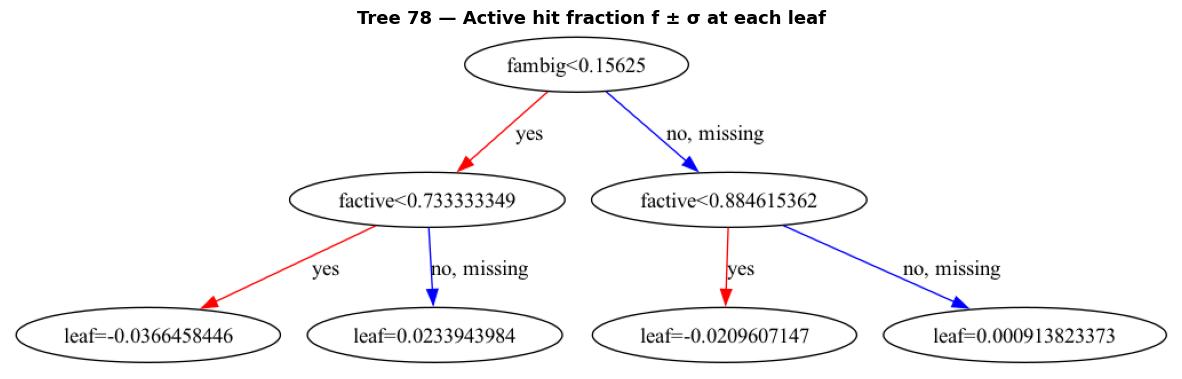

In [ ]:
with open('fmap.txt', 'w') as f:
    for idx, name in enumerate(input_var_names):  # input_var_names not feature_names
        f.write(f"{idx}\t{name}\tq\n")

# Print uncertainty table
print("Tree 78 — Active hit fraction (factive = nactive/nhits) ± σ at each leaf")
print()
print(f"{'Node':<30} {'N':>6}  {'f active':>10}  {'± σ':>8}")
print("-" * 58)
print(f"{'Root  (fambig < 0.156)':<30} {'6,725':>6}  {'0.909':>10}  {'0.004':>8}")
print(f"{'Left  (factive < 0.733)':<30} {'1,808':>6}  {'0.945':>10}  {'0.005':>8}  ← factive split")
print(f"{'Right (factive < 0.885)':<30} {'4,917':>6}  {'0.895':>10}  {'0.004':>8}  ← factive split")
print(f"{'Leaf 3 (yes → left)':<30} {'44':>6}  {'0.649':>10}  {'0.072':>8}")
print(f"{'Leaf 4 (no  → left)':<30} {'1,764':>6}  {'0.953':>10}  {'0.005':>8}")
print(f"{'Leaf 5 (yes → right)':<30} {'1,513':>6}  {'0.742':>10}  {'0.011':>8}")
print(f"{'Leaf 6 (no  → right)':<30} {'3,404':>6}  {'0.963':>10}  {'0.003':>8}")
print()

# ── Tree plot ─────────────────────────────────────────────────────────────
plt.rcParams['figure.figsize'] = [15, 10]
xgb.plot_tree(model, num_trees=78, rankdir="TB", fmap='fmap.txt')
plt.title("Tree 78 — Active hit fraction f ± σ at each leaf", fontsize=13, fontweight='bold')
plt.show()

In [ ]:
# Extract momerr for validation set using correct column order
x_valid_df = pd.DataFrame(x_valid, columns=input_var_names)
momerr_valid = x_valid_df['momerr'].values

leaf_ids_78 = all_leaf_ids[:, 78]

print("Tree 78 — Momentum resolution at each leaf")
print(f"  {'Leaf':>5}  {'N':>6}  {'mean momerr':>12}  {'± σ':>8}")
print(f"  {'-'*40}")
for leaf in np.unique(leaf_ids_78):
    mask  = leaf_ids_78 == leaf
    N     = mask.sum()
    m     = momerr_valid[mask].mean()
    sigma = momerr_valid[mask].std() / np.sqrt(N)
    print(f"  {int(leaf):>5}  {N:>6}  {m:>12.4f}  {sigma:>8.4f}")

Tree 78 — Momentum resolution at each leaf
   Leaf       N   mean momerr       ± σ
  ----------------------------------------
      3      44        0.3340    0.0873
      4    1764        0.1033    0.0015
      5    1513        0.6284    0.0459
      6    3404        0.3028    0.0050


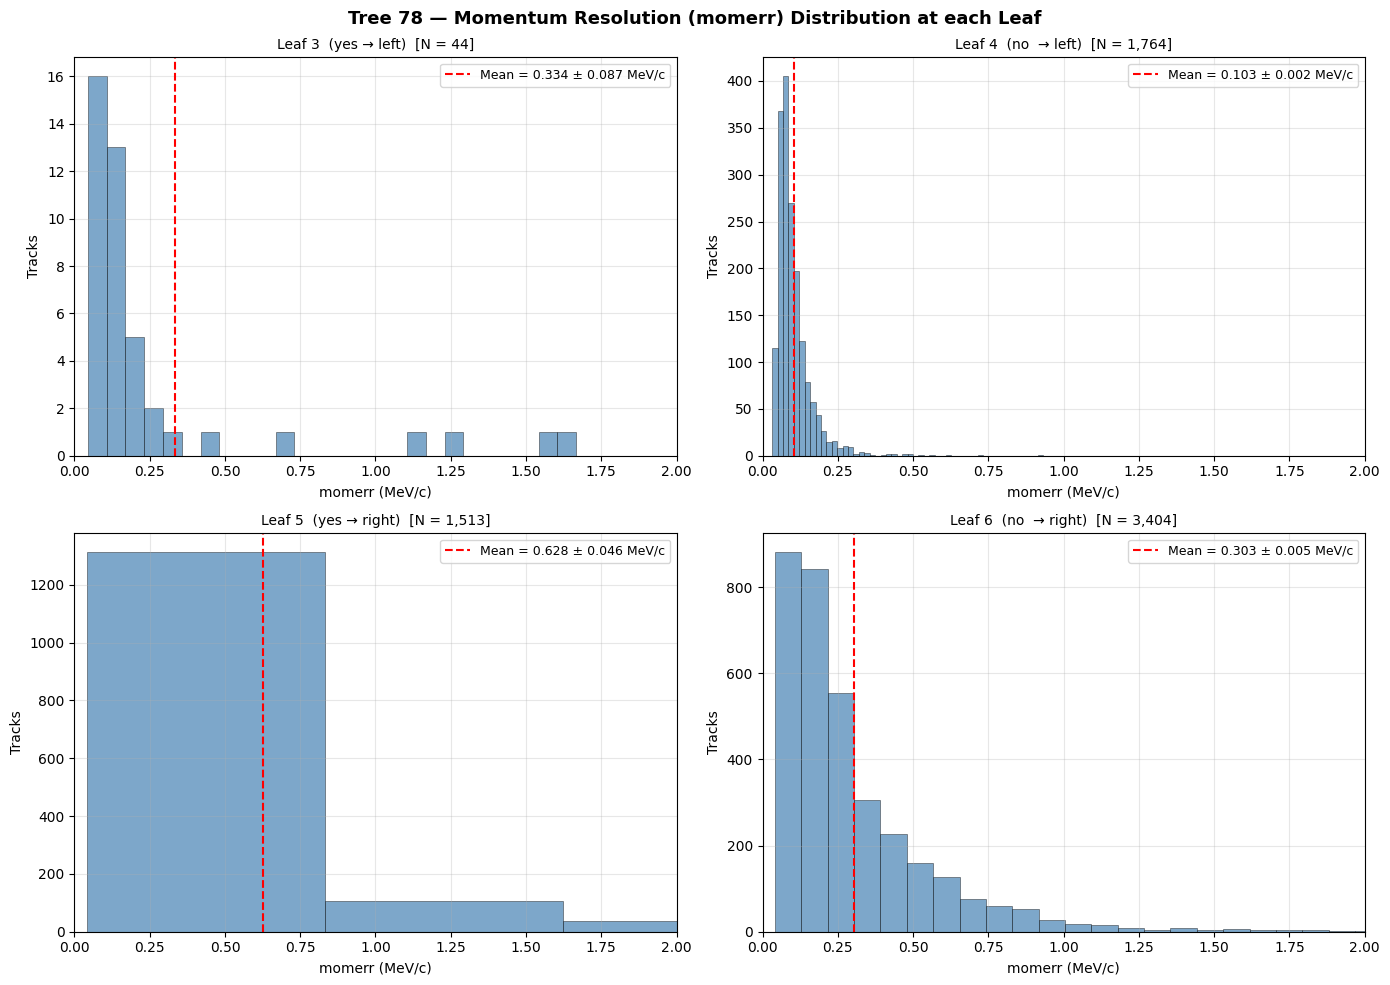

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Tree 78 — Momentum Resolution (momerr) Distribution at each Leaf",
             fontsize=13, fontweight='bold')

leaf_info = {
    3: (axes[0,0], 'Leaf 3  (yes → left)',  44,   0.334, 0.087),
    4: (axes[0,1], 'Leaf 4  (no  → left)',  1764, 0.103, 0.002),
    5: (axes[1,0], 'Leaf 5  (yes → right)', 1513, 0.628, 0.046),
    6: (axes[1,1], 'Leaf 6  (no  → right)', 3404, 0.303, 0.005),
}

for leaf, (ax, title, N, mean, sigma) in leaf_info.items():
    mask = leaf_ids_78 == leaf
    data = momerr_valid[mask]

    ax.hist(data, bins=50, color='steelblue', alpha=0.7,
            edgecolor='black', linewidth=0.4)
    ax.axvline(mean, color='red', linestyle='--', linewidth=1.5,
               label=f"Mean = {mean:.3f} ± {sigma:.3f} MeV/c")
    ax.set_title(f"{title}  [N = {N:,}]", fontsize=10)
    ax.set_xlabel("momerr (MeV/c)")
    ax.set_ylabel("Tracks")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    # Zoom in to the interesting region
    ax.set_xlim(0, 2.0)

plt.tight_layout()
#plt.savefig("tree78_momerr_per_leaf.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Get leaf active hit fractions for tree 80
leaf_ids_80 = all_leaf_ids[:, 80]

print("Tree 80 — Active hit fraction (factive = nactive/nhits) ± σ at each leaf")
print(f"  {'Leaf':>5}  {'N':>6}  {'f active':>10}  {'± σ':>8}")
print(f"  {'-'*40}")
for leaf in np.unique(leaf_ids_80):
    mask  = leaf_ids_80 == leaf
    N     = mask.sum()
    f     = factive_valid[mask].mean()
    sigma = np.sqrt(f * (1 - f) / N)
    print(f"  {int(leaf):>5}  {N:>6}  {f:>10.4f}  {sigma:>8.4f}")

Tree 80 — Active hit fraction (factive = nactive/nhits) ± σ at each leaf
   Leaf       N    f active       ± σ
  ----------------------------------------
      3      95      0.7655    0.0435
      4    1221      0.9625    0.0054
      5    3082      0.8310    0.0068
      6    2327      0.9893    0.0021


Tree 80 — Active hit fraction (factive = nactive/nhits) ± σ at each leaf

Node                                N    f active       ± σ
----------------------------------------------------------
Parent (momerr < 0.086)         6,725       0.909     0.004
Child Left (factive < 0.840)    1,316       0.948     0.006  ← factive split
Child Right (factive < 0.954)   5,409       0.899     0.004  ← factive split
Leaf 3 (yes → left)                95       0.766     0.044
Leaf 4 (no  → left)             1,221       0.963     0.005
Leaf 5 (yes → right)            3,082       0.831     0.007
Leaf 6 (no  → right)            2,327       0.989     0.002



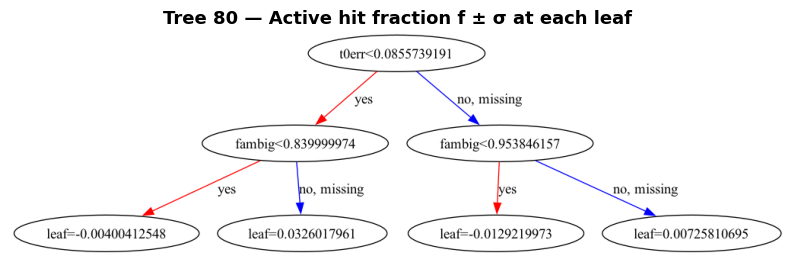

In [ ]:
with open('fmap.txt', 'w') as f:
    for idx, name in enumerate(feature_names):
        f.write(f"{idx}\t{name}\tq\n")

# Print uncertainty table
print("Tree 80 — Active hit fraction (factive = nactive/nhits) ± σ at each leaf")
print()
print(f"{'Node':<30} {'N':>6}  {'f active':>10}  {'± σ':>8}")
print("-" * 58)
print(f"{'Parent (momerr < 0.086)':<30} {'6,725':>6}  {'0.909':>10}  {'0.004':>8}")
print(f"{'Child Left (factive < 0.840)':<30} {'1,316':>6}  {'0.948':>10}  {'0.006':>8}  ← factive split")
print(f"{'Child Right (factive < 0.954)':<30} {'5,409':>6}  {'0.899':>10}  {'0.004':>8}  ← factive split")
print(f"{'Leaf 3 (yes → left)':<30} {'95':>6}  {'0.766':>10}  {'0.044':>8}")
print(f"{'Leaf 4 (no  → left)':<30} {'1,221':>6}  {'0.963':>10}  {'0.005':>8}")
print(f"{'Leaf 5 (yes → right)':<30} {'3,082':>6}  {'0.831':>10}  {'0.007':>8}")
print(f"{'Leaf 6 (no  → right)':<30} {'2,327':>6}  {'0.989':>10}  {'0.002':>8}")
print()

# Tree plot
plt.rcParams['figure.figsize'] = [10, 10]
xgb.plot_tree(model, num_trees=80, rankdir="TB", fmap='fmap.txt')
plt.title("Tree 80 — Active hit fraction f ± σ at each leaf", fontsize=13, fontweight='bold')
plt.show()

## Nactive +1 Analysis
---------------------------------------------------------------------------------------------------------------

In [ ]:
import uproot
import pandas as pd
import numpy as np

# 1. Define paths
ORIGINAL_FILE = "/Users/malikfarouh/Documents/ML workspace/ML model env/trkqual_tree_v2.0_training.root"
PERTURBED_FILE = "/Users/malikfarouh/Documents/ML workspace/ML model env/trkqual_tree_v2.0_training_nactive_plus1.root"
tree_name = "trkqualtree"

def get_features_from_file(file_path):
    with uproot.open(file_path) as file:
        tree = file[tree_name]
        arrays = tree.arrays(library="np")
        
        # Compute features correctly as ratios
        nactive  = arrays['trk.nactive']
        nhits    = arrays['trk.nhits']
        factive  = nactive / nhits
        fambig   = arrays['trk.nnullambig'] / nactive
        fstraws  = arrays['trk.nmatactive'] / nactive
        t0err    = arrays['trk_ent_pars.t0err']
        fitcon   = arrays['trk.fitcon']
        momerr   = arrays['trk_ent.momerr']
        
        # Stack in correct order
        # ["nactive", "factive", "t0err", "fambig", "fitcon", "momerr", "fstraws"]
        x = np.vstack((nactive, factive, t0err, fambig, fitcon, momerr, fstraws)).T
        
        # Apply same masks as training
        x_filtered = np.concatenate((x[high_qual], x[low_qual]))
        return x_filtered

# Get features for both files
x_orig_filtered = get_features_from_file(ORIGINAL_FILE)
x_pert_filtered = get_features_from_file(PERTURBED_FILE)

# Run original model on both
y_pred_original_full  = model.predict_proba(x_orig_filtered)[:, 1]
y_pred_perturbed_full = model.predict_proba(x_pert_filtered)[:, 1]

print(f"Original size:    {len(y_pred_original_full)}")
print(f"Perturbed size:   {len(y_pred_perturbed_full)}")
print(f"Original mean:    {y_pred_original_full.mean():.4f}")
print(f"Perturbed mean:   {y_pred_perturbed_full.mean():.4f}")
print(f"Mean BDT shift:   {(y_pred_perturbed_full - y_pred_original_full).mean():.6f}")

Original size:    317439
Perturbed size:   317439
Original mean:    0.7940
Perturbed mean:   0.8067
Mean BDT shift:   0.012701


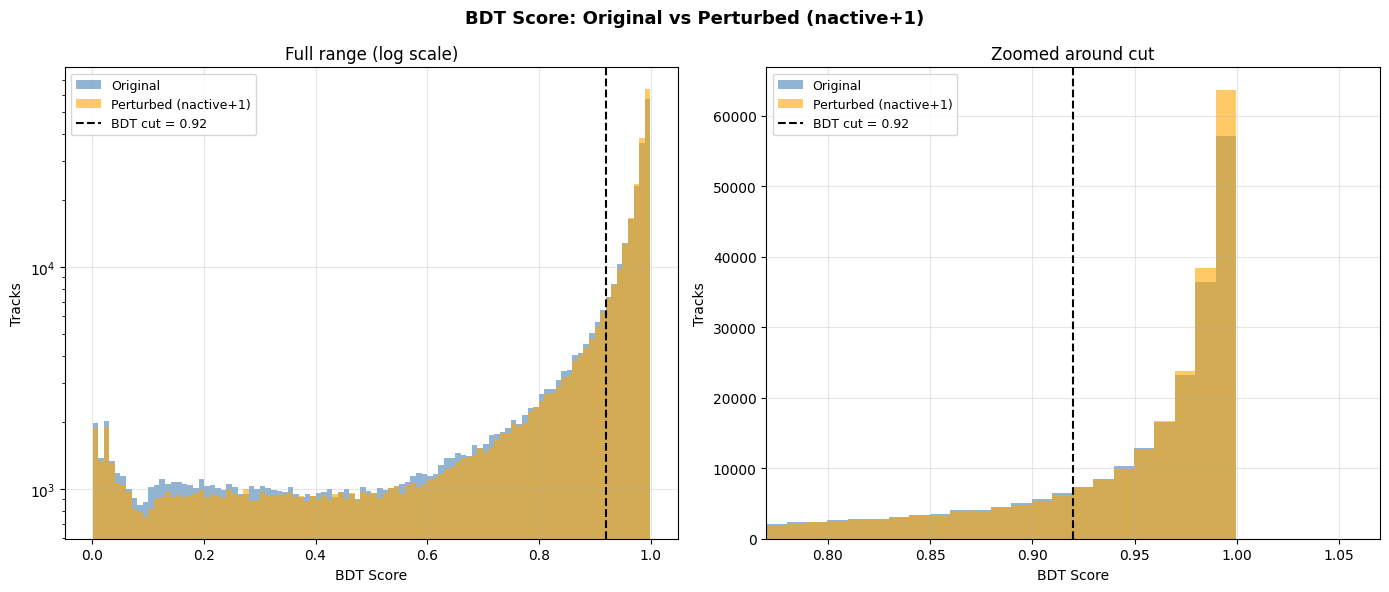

Mean BDT shift:            0.012701 ± 0.024112
Tracks changing pass/fail: 8964 out of 317439
As a fraction:             2.82%

Of the 8964 changed tracks:
  Signal:     8937
  Background: 27


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("BDT Score: Original vs Perturbed (nactive+1)", fontsize=13, fontweight='bold')

for ax, yscale, title in zip(axes, ['log', 'linear'], ['Full range (log scale)', 'Zoomed around cut']):
    ax.hist(y_pred_original_full,  bins=100, alpha=0.6, color='steelblue', label='Original')
    ax.hist(y_pred_perturbed_full, bins=100, alpha=0.6, color='orange',    label='Perturbed (nactive+1)')
    ax.axvline(trkqual_cut, color='black', linestyle='--', linewidth=1.5,
               label=f'BDT cut = {trkqual_cut:.2f}')
    ax.set_xlabel("BDT Score")
    ax.set_ylabel("Tracks")
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_yscale(yscale)
    if title.startswith('Zoomed'):
        ax.set_xlim(trkqual_cut - 0.15, trkqual_cut + 0.15)
        ax.set_yscale('linear')

plt.tight_layout()
#plt.savefig("bdt_score_comparison_final.png", dpi=150, bbox_inches='tight')
plt.show()

# Print final summary
delta = y_pred_perturbed_full - y_pred_original_full
bdt_pass_orig = y_pred_original_full  >= trkqual_cut
bdt_pass_pert = y_pred_perturbed_full >= trkqual_cut
changed = (bdt_pass_orig != bdt_pass_pert).sum()
print(f"Mean BDT shift:            {delta.mean():.6f} ± {delta.std():.6f}")
print(f"Tracks changing pass/fail: {changed} out of {len(delta)}")
print(f"As a fraction:             {changed/len(delta)*100:.2f}%")
print(f"\nOf the {changed} changed tracks:")
print(f"  Signal:     {(( bdt_pass_orig != bdt_pass_pert) & (y_full == 1)).sum()}")
print(f"  Background: {((bdt_pass_orig != bdt_pass_pert) & (y_full == 0)).sum()}")

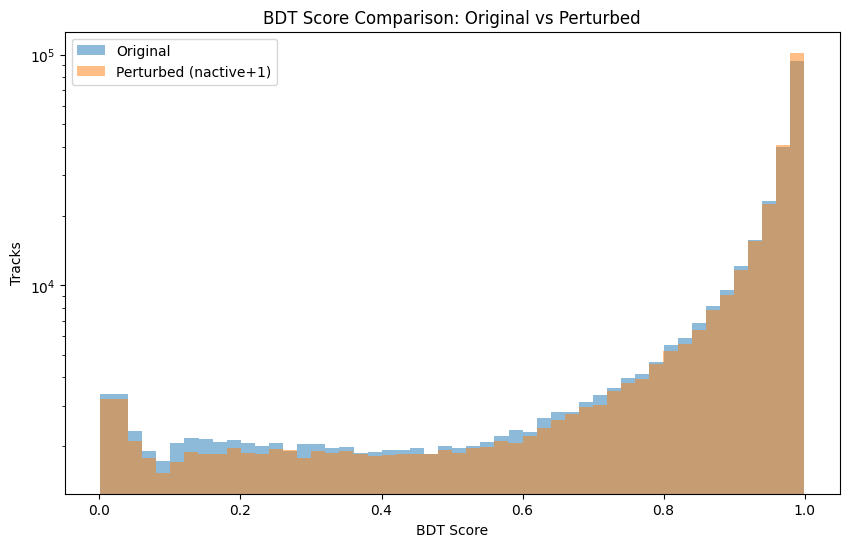

In [ ]:
plt.figure(figsize=(10,6))
plt.hist(y_pred_original_full, bins=50, alpha=0.5, label='Original')
plt.hist(y_pred_perturbed_full, bins=50, alpha=0.5, label='Perturbed (nactive+1)')
plt.yscale('log') # Log scale is often better for ROOT data
plt.xlabel('BDT Score')
plt.ylabel('Tracks')
plt.legend()
plt.title('BDT Score Comparison: Original vs Perturbed')
plt.show()


/var/folders/p0/qdf2tryn1sd4_kf_28ckgz640000gn/T/ipykernel_9192/1919719131.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


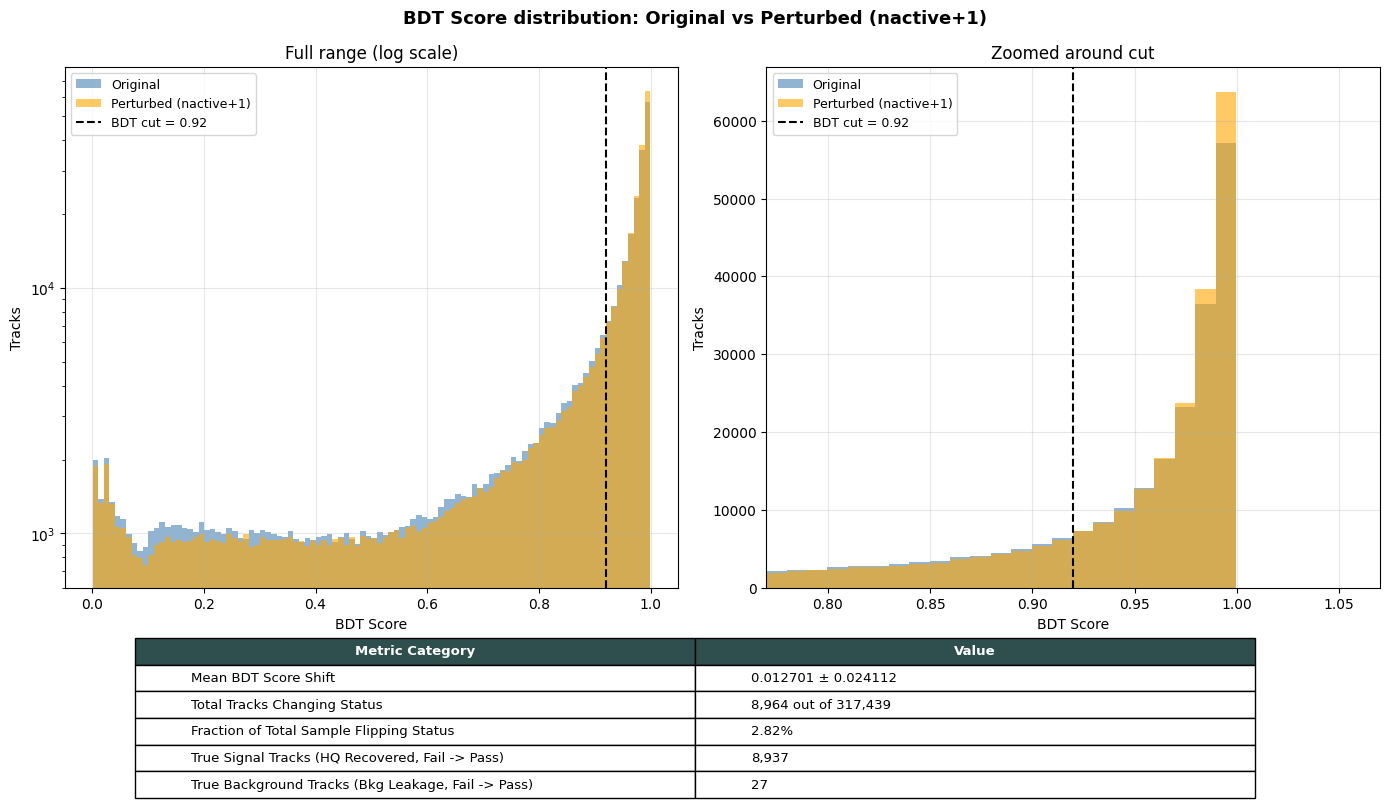

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare data variables matching your metrics
delta = y_pred_perturbed_full - y_pred_original_full
bdt_pass_orig = y_pred_original_full >= trkqual_cut
bdt_pass_pert = y_pred_perturbed_full >= trkqual_cut
changed = (bdt_pass_orig != bdt_pass_pert).sum()
num_sig = ((bdt_pass_orig != bdt_pass_pert) & (y_full == 1)).sum()
num_bkg = ((bdt_pass_orig != bdt_pass_pert) & (y_full == 0)).sum()

# 2. Build the structural figure grid
fig, axes = plt.subplots(1, 2, figsize=(14, 6.5)) 
fig.suptitle("BDT Score distribution: Original vs Perturbed (nactive+1)", fontsize=13, fontweight='bold')

for ax, yscale, title in zip(axes, ['log', 'linear'], ['Full range (log scale)', 'Zoomed around cut']):
    ax.hist(y_pred_original_full, bins=100, alpha=0.6, color='steelblue', label='Original')
    ax.hist(y_pred_perturbed_full, bins=100, alpha=0.6, color='orange', label='Perturbed (nactive+1)')
    ax.axvline(trkqual_cut, color='black', linestyle='--', linewidth=1.5, label=f'BDT cut = {trkqual_cut:.2f}')
    ax.set_xlabel("BDT Score")
    ax.set_ylabel("Tracks")
    ax.set_title(title)
    
    # Moved the legend to the 'upper left' to completely avoid the 1.0 peak bars
    ax.legend(loc='upper left', fontsize=9)
    
    ax.grid(alpha=0.3)
    ax.set_yscale(yscale)
    if title.startswith('Zoomed'):
        ax.set_xlim(trkqual_cut - 0.15, trkqual_cut + 0.15)
        ax.set_yscale('linear')

# 3. Create the embedded data summary table below the subplots
table_data = [
    ["Mean BDT Score Shift", f"{delta.mean():.6f} ± {delta.std():.6f}"],
    ["Total Tracks Changing Status", f"{changed:,} out of {len(delta):,}"],
    ["Fraction of Total Sample Flipping Status", f"{changed/len(delta)*100:.2f}%"],
    ["True Signal Tracks (HQ Recovered, Fail -> Pass)", f"{num_sig:,}"],
    ["True Background Tracks (Bkg Leakage, Fail -> Pass)", f"{num_bkg:,}"]
]

columns = ["Metric Category", "Value"]

# Pushed the table lower down to avoid colliding with the X-axis labels
table_ax = fig.add_axes([0.1, -0.20, 0.8, 0.18]) 
table_ax.axis('off')

summary_table = table_ax.table(cellText=table_data, colLabels=columns, loc='center', cellLoc='left')

summary_table.auto_set_font_size(False)
summary_table.set_fontsize(9.5) 
summary_table.scale(1.0, 1.6) # Clean vertical padding

# Header styling
for (row, col), cell in summary_table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        # FIXED: Swapped 'darkslate4' out for a standard hex code
        cell.set_facecolor('#2f4f4f') 
        cell.set_text_props(ha='center')

# Ensure layout is nicely padded before rendering
plt.subplots_adjust(bottom=0.15)
plt.tight_layout()
# plt.savefig("bdt_score_comparison_matrix_clean.png", dpi=200, bbox_inches='tight')
plt.show()

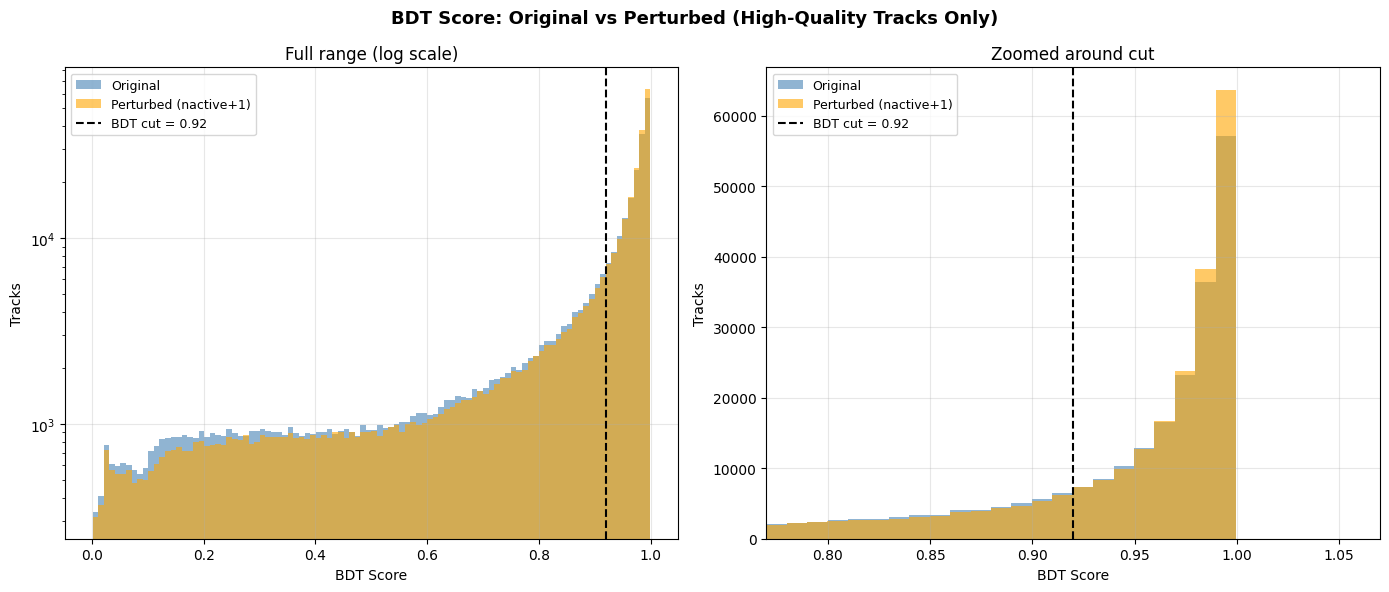

--- High-Quality Tracks Summary ---
Mean BDT shift (HQ only): 0.012631 ± 0.023963
HQ tracks changing pass/fail: 8937 out of 303990
As a fraction of HQ sample: 2.94%


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Define the mask for high-quality tracks only
high_qual_mask = (y_full == 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("BDT Score: Original vs Perturbed (High-Quality Tracks Only)", fontsize=13, fontweight='bold')

for ax, yscale, title in zip(axes, ['log', 'linear'], ['Full range (log scale)', 'Zoomed around cut']):
    # Apply mask directly inside the histogram calls
    ax.hist(y_pred_original_full[high_qual_mask], bins=100, alpha=0.6, color='steelblue', label='Original')
    ax.hist(y_pred_perturbed_full[high_qual_mask], bins=100, alpha=0.6, color='orange', label='Perturbed (nactive+1)')
    
    ax.axvline(trkqual_cut, color='black', linestyle='--', linewidth=1.5, label=f'BDT cut = {trkqual_cut:.2f}')
    ax.set_xlabel("BDT Score")
    ax.set_ylabel("Tracks")
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_yscale(yscale)
    
    if title.startswith('Zoomed'):
        ax.set_xlim(trkqual_cut - 0.15, trkqual_cut + 0.15)
        ax.set_yscale('linear')

plt.tight_layout()
plt.show()

# Print summary for high-quality tracks specifically
delta_hq = y_pred_perturbed_full[high_qual_mask] - y_pred_original_full[high_qual_mask]
bdt_pass_orig_hq = y_pred_original_full[high_qual_mask] >= trkqual_cut
bdt_pass_pert_hq = y_pred_perturbed_full[high_qual_mask] >= trkqual_cut
changed_hq = (bdt_pass_orig_hq != bdt_pass_pert_hq).sum()

print(f"--- High-Quality Tracks Summary ---")
print(f"Mean BDT shift (HQ only): {delta_hq.mean():.6f} ± {delta_hq.std():.6f}")
print(f"HQ tracks changing pass/fail: {changed_hq} out of {len(delta_hq)}")
print(f"As a fraction of HQ sample: {changed_hq/len(delta_hq)*100:.2f}%")


In [ ]:
'''
fig, axs = plt.subplots(3, 3, figsize=(16, 9))
fig.subplots_adjust(hspace=.5)
fig.suptitle("Feature Distributions — Full Dataset vs nactive +1", fontsize=13, fontweight='bold')

for i_var in range(n_input_vars):
    ax = axs.flatten()[i_var]
    ax.hist(x_full[:, i_var], bins=100, range=(x_mins[i_var], x_maxs[i_var]),
            histtype='step', color='black', log=log_ys[i_var],
            label=f'Full dataset (N={len(x_full):,})', linewidth=1.5)
    if i_var == momerr_idx:
        ax.hist(x_up[:, i_var], bins=100, range=(x_mins[i_var], x_maxs[i_var]),
                histtype='step', color='purple', log=log_ys[i_var],
                label='nactive +1', linestyle='--', linewidth=1.5)
    ax.set_xlabel(input_var_names[i_var] + " " + units[i_var])
    ax.margins(0)
    ax.legend(fontsize=7)

#plt.savefig("feature_distributions_nactive_plus1.png", dpi=150, bbox_inches='tight')
plt.show()
'''

'\nfig, axs = plt.subplots(3, 3, figsize=(16, 9))\nfig.subplots_adjust(hspace=.5)\nfig.suptitle("Feature Distributions — Full Dataset vs nactive +1", fontsize=13, fontweight=\'bold\')\n\nfor i_var in range(n_input_vars):\n    ax = axs.flatten()[i_var]\n    ax.hist(x_full[:, i_var], bins=100, range=(x_mins[i_var], x_maxs[i_var]),\n            histtype=\'step\', color=\'black\', log=log_ys[i_var],\n            label=f\'Full dataset (N={len(x_full):,})\', linewidth=1.5)\n    if i_var == momerr_idx:\n        ax.hist(x_up[:, i_var], bins=100, range=(x_mins[i_var], x_maxs[i_var]),\n                histtype=\'step\', color=\'purple\', log=log_ys[i_var],\n                label=\'nactive +1\', linestyle=\'--\', linewidth=1.5)\n    ax.set_xlabel(input_var_names[i_var] + " " + units[i_var])\n    ax.margins(0)\n    ax.legend(fontsize=7)\n\n#plt.savefig("feature_distributions_nactive_plus1.png", dpi=150, bbox_inches=\'tight\')\nplt.show()\n'

In [ ]:
'''
#Plot 1: nactive +1 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
i = momerr_idx

plot_params_nactive = [
    (x_full[:, i], 'black',  f'Full dataset (N={len(x_full):,})', '-',  2.0),
    (x_up[:, i],   'purple', 'nactive +1',                        '--', 1.5),
]

for ax in [ax1, ax2]:
    for data, color, label, style, lw in plot_params_nactive:
        ax.hist(data, bins=100,
                range=(x_mins[i], x_maxs[i]) if ax == ax1 else (0, 1.0),
                histtype='step', color=color, log=True,
                label=label, linestyle=style, linewidth=lw)
    ax.set_ylabel("Tracks")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

ax1.set_title("Full Range Distribution", fontweight='bold')
ax1.set_xlabel(f"{input_var_names[i]} {units[i]}")
ax1.margins(0)
ax2.set_title("Zoomed Distribution (0–1 MeV/c)", fontweight='bold')
ax2.set_xlabel("momerr [MeV/c]")
fig.suptitle("momerr Distribution — nactive +1 vs Original",
             fontsize=14, fontweight='bold')
plt.tight_layout()
#plt.savefig("momerr_nactive_plus1.png", dpi=150, bbox_inches='tight')
plt.show()
'''

'\n#Plot 1: nactive +1 \nfig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))\ni = momerr_idx\n\nplot_params_nactive = [\n    (x_full[:, i], \'black\',  f\'Full dataset (N={len(x_full):,})\', \'-\',  2.0),\n    (x_up[:, i],   \'purple\', \'nactive +1\',                        \'--\', 1.5),\n]\n\nfor ax in [ax1, ax2]:\n    for data, color, label, style, lw in plot_params_nactive:\n        ax.hist(data, bins=100,\n                range=(x_mins[i], x_maxs[i]) if ax == ax1 else (0, 1.0),\n                histtype=\'step\', color=color, log=True,\n                label=label, linestyle=style, linewidth=lw)\n    ax.set_ylabel("Tracks")\n    ax.legend(fontsize=9)\n    ax.grid(alpha=0.3)\n\nax1.set_title("Full Range Distribution", fontweight=\'bold\')\nax1.set_xlabel(f"{input_var_names[i]} {units[i]}")\nax1.margins(0)\nax2.set_title("Zoomed Distribution (0–1 MeV/c)", fontweight=\'bold\')\nax2.set_xlabel("momerr [MeV/c]")\nfig.suptitle("momerr Distribution — nactive +1 vs Original",\n         

In [ ]:
import numpy as np
print(f"trkqual unique values: {np.unique(trkqual)}")
print(f"trkqual value counts: {np.unique(trkqual, return_counts=True)}")
print(f"y_pred_original_full shape: {y_pred_original_full.shape}")
print(f"mom_res shape: {mom_res.shape}")

trkqual unique values: [0 1]
trkqual value counts: (array([0, 1]), array([111739, 340947]))
y_pred_original_full shape: (317439,)
mom_res shape: (452686,)


In [ ]:
# mom_res for filtered subset — same order as x_full
mom_res_filtered = np.concatenate((mom_res[high_qual], mom_res[low_qual]))

print(f"mom_res_filtered shape: {mom_res_filtered.shape}")
print(f"mom_res_filtered sample: {mom_res_filtered[:5]}")
print(f"mom_res_filtered mean:   {mom_res_filtered.mean():.4f}")
print(f"mom_res_filtered min/max: {mom_res_filtered.min():.4f} / {mom_res_filtered.max():.4f}")

mom_res_filtered shape: (317439,)
mom_res_filtered sample: [ 0.07861328 -0.08947754 -0.15447235  0.13756561 -0.16790009]
mom_res_filtered mean:   0.0870
mom_res_filtered min/max: -0.2500 / 141.0327


In [ ]:
# Check alignment between mom_res_filtered and y_pred_original_full
print("mom_res_filtered first 5:", mom_res_filtered[:5])
print("y_pred_original_full first 5:", y_pred_original_full[:5])

# Check if original plot works correctly with mom_res_filtered
print("\nWith original predictions:")
print(f"  tracks passing cut: {(y_pred_original_full >= 0.9182).sum()}")
print(f"  mom_res mean (passing): {mom_res_filtered[y_pred_original_full >= 0.9182].mean():.4f}")
print(f"  mom_res mean (failing): {mom_res_filtered[y_pred_original_full < 0.9182].mean():.4f}")

# Check with perturbed
print("\nWith nactive+1 predictions:")
print(f"  tracks passing cut: {(y_pred_perturbed_full >= 0.9334).sum()}")
print(f"  mom_res mean (passing): {mom_res_filtered[y_pred_perturbed_full >= 0.9334].mean():.4f}")
print(f"  mom_res mean (failing): {mom_res_filtered[y_pred_perturbed_full < 0.9334].mean():.4f}")

mom_res_filtered first 5: [ 0.07861328 -0.08947754 -0.15447235  0.13756561 -0.16790009]
y_pred_original_full first 5: [0.94361466 0.9996278  0.9949633  0.9916666  0.8512539 ]

With original predictions:
  tracks passing cut: 173398
  mom_res mean (passing): -0.0003
  mom_res mean (failing): 0.1922

With nactive+1 predictions:
  tracks passing cut: 170466
  mom_res mean (passing): -0.0002
  mom_res mean (failing): 0.1882


mom_res full shape: (452686,)
trkqual full shape: (452686,)
y_pred_original_full shape: (317439,)
y_pred_full_unfiltered shape: (452686,)


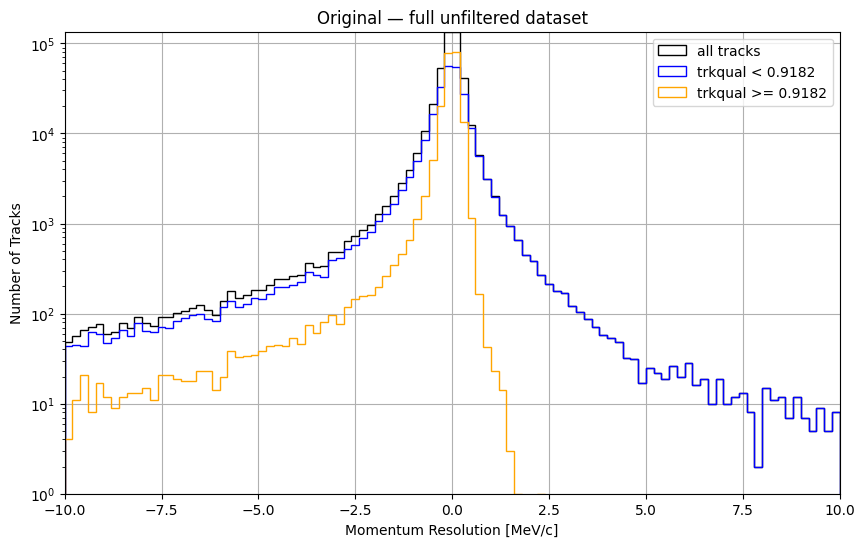

In [ ]:
# Check sizes
print(f"mom_res full shape: {mom_res.shape}")       # should be 452,686
print(f"trkqual full shape: {trkqual.shape}")        # should be 452,686
print(f"y_pred_original_full shape: {y_pred_original_full.shape}")  # 317,439

# We need full BDT scores for all 452,686 tracks
# Run model on full unfiltered dataset
with uproot.open(training_dataset_filename) as f:
    tree   = f[training_dataset_treename]
    arrays = tree.arrays(library="np")
    
    nactive = arrays['trk.nactive']
    nhits   = arrays['trk.nhits']
    factive = nactive / nhits
    fambig  = arrays['trk.nnullambig'] / nactive
    fstraws = arrays['trk.nmatactive'] / nactive
    t0err   = arrays['trk_ent_pars.t0err']
    fitcon  = arrays['trk.fitcon']
    momerr  = arrays['trk_ent.momerr']

x_full_unfiltered = np.vstack((nactive, factive, t0err, fambig,
                                fitcon, momerr, fstraws)).T

# Run original model on full unfiltered dataset
y_pred_full_unfiltered = model.predict_proba(x_full_unfiltered)[:, 1]
print(f"y_pred_full_unfiltered shape: {y_pred_full_unfiltered.shape}")

# Test plot
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.hist(mom_res, bins=n_mom_res_bins, range=(min_mom_res, max_mom_res),
        log=True, histtype='step', color='black', label='all tracks')
ax.hist(mom_res[y_pred_full_unfiltered < 0.9182], bins=n_mom_res_bins,
        range=(min_mom_res, max_mom_res), log=True, histtype='step', color='blue',
        label='trkqual < 0.9182')
ax.hist(mom_res[y_pred_full_unfiltered >= 0.9182], bins=n_mom_res_bins,
        range=(min_mom_res, max_mom_res), log=True, histtype='step', color='orange',
        label='trkqual >= 0.9182')
ax.legend()
ax.margins(0)
ax.grid(True)
ax.set_xlabel("Momentum Resolution [MeV/c]")
ax.set_ylabel("Number of Tracks")
ax.set_title("Original — full unfiltered dataset")
plt.show()

In [ ]:
# ── Helper function — run model on full unfiltered file ───────────────────
def get_full_predictions(file_path):
    with uproot.open(file_path) as f:
        tree   = f[training_dataset_treename]
        arrays = tree.arrays(library="np")
        nactive = arrays['trk.nactive']
        nhits   = arrays['trk.nhits']
        factive = nactive / nhits
        fambig  = arrays['trk.nnullambig'] / nactive
        fstraws = arrays['trk.nmatactive'] / nactive
        t0err   = arrays['trk_ent_pars.t0err']
        fitcon  = arrays['trk.fitcon']
        momerr  = arrays['trk_ent.momerr']
        x = np.vstack((nactive, factive, t0err, fambig,
                        fitcon, momerr, fstraws)).T
        return model.predict_proba(x)[:, 1]

# Pre-compute all full unfiltered predictions
print("Computing full predictions for all perturbed files...")
y_full_nactive  = get_full_predictions(training_dataset_filename.replace('.root', '_nactive_plus1.root'))
y_full_up10     = get_full_predictions(training_dataset_filename.replace('.root', '_momerr_plus10pct.root'))
y_full_down10   = get_full_predictions(training_dataset_filename.replace('.root', '_momerr_minus10pct.root'))
y_full_up50     = get_full_predictions(training_dataset_filename.replace('.root', '_momerr_plus50pct.root'))
y_full_down50   = get_full_predictions(training_dataset_filename.replace('.root', '_momerr_minus50pct.root'))
print("Done!")
print(f"All shapes: {y_full_nactive.shape}, {y_full_up10.shape}, {y_full_down10.shape}")

Computing full predictions for all perturbed files...
Done!
All shapes: (452686,), (452686,), (452686,)


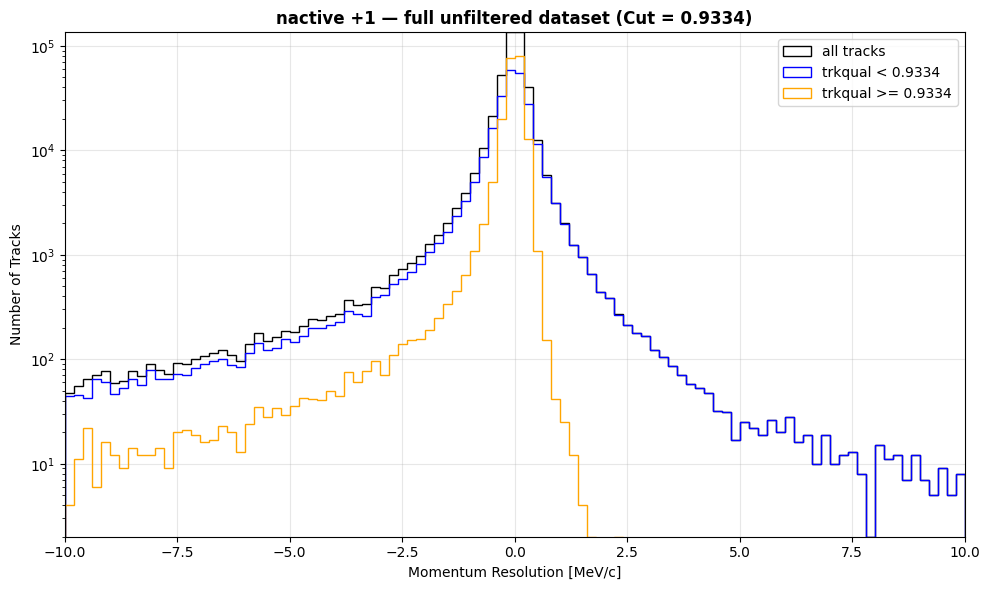

In [ ]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

opt_cut_nactive = 0.9334

with uproot.open(training_dataset_filename) as f:
    tree = f[training_dataset_treename]
    arrays = tree.arrays(library="np")
    
    # 1. Apply perturbation to the full raw array
    nactive = arrays['trk.nactive'] + 1
    nhits   = arrays['trk.nhits']
    factive = nactive / nhits
    fambig  = arrays['trk.nnullambig'] / nactive
    fstraws = arrays['trk.nmatactive'] / nactive
    t0err   = arrays['trk_ent_pars.t0err']
    fitcon  = arrays['trk.fitcon']
    momerr  = arrays['trk_ent.momerr']

x_full_unfiltered = np.vstack((nactive, factive, t0err, fambig, fitcon, momerr, fstraws)).T
y_pred_full_unfiltered = model.predict_proba(x_full_unfiltered)[:, 1]

# Plot
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.hist(mom_res, bins=n_mom_res_bins, range=(min_mom_res, max_mom_res), log=True, histtype='step', color='black', label='all tracks')
ax.hist(mom_res[y_pred_full_unfiltered < opt_cut_nactive], bins=n_mom_res_bins, range=(min_mom_res, max_mom_res), log=True, histtype='step', color='blue', label=f'trkqual < {opt_cut_nactive}')
ax.hist(mom_res[y_pred_full_unfiltered >= opt_cut_nactive], bins=n_mom_res_bins, range=(min_mom_res, max_mom_res), log=True, histtype='step', color='orange', label=f'trkqual >= {opt_cut_nactive}')
ax.legend()
ax.margins(0)
ax.grid(True, alpha=0.3)
ax.set_xlabel("Momentum Resolution [MeV/c]")
ax.set_ylabel("Number of Tracks")
ax.set_title(f"nactive +1 — full unfiltered dataset (Cut = {opt_cut_nactive})", fontweight='bold')
plt.tight_layout()


## The +10% $ -10% momerr analysis!

In [ ]:
# Define file paths
MOMERR_UP_FILE   = training_dataset_filename.replace('.root', '_momerr_plus10pct.root')
MOMERR_DOWN_FILE = training_dataset_filename.replace('.root', '_momerr_minus10pct.root')

def get_features_from_file(file_path):
    with uproot.open(file_path) as file:
        tree   = file[training_dataset_treename]
        arrays = tree.arrays(library="np")
        
        nactive = arrays['trk.nactive']
        nhits   = arrays['trk.nhits']
        factive = nactive / nhits
        fambig  = arrays['trk.nnullambig'] / nactive
        fstraws = arrays['trk.nmatactive'] / nactive
        t0err   = arrays['trk_ent_pars.t0err']
        fitcon  = arrays['trk.fitcon']
        momerr  = arrays['trk_ent.momerr']
        
        x = np.vstack((nactive, factive, t0err, fambig, fitcon, momerr, fstraws)).T
        return np.concatenate((x[high_qual], x[low_qual]))

# Get predictions from original model,no retraining
x_up   = get_features_from_file(MOMERR_UP_FILE)
x_down = get_features_from_file(MOMERR_DOWN_FILE)

y_pred_momerr_up   = model.predict_proba(x_up)[:, 1]
y_pred_momerr_down = model.predict_proba(x_down)[:, 1]

#Compare against original dataset predictions
delta_up   = y_pred_momerr_up   - y_pred_original_full
delta_down = y_pred_momerr_down - y_pred_original_full

print(f"Total tracks in dataset: {len(y_pred_original_full)}")
print(f"{'':30s} {'Mean shift':>12} {'± std':>8}   {'Changed':>8}  {'%':>6}")
print("-" * 75)
for label, delta, y_pred in [
    ('momerr +10%', delta_up,   y_pred_momerr_up),
    ('momerr -10%', delta_down, y_pred_momerr_down)
]:
    bdt_pass_orig = y_pred_original_full >= trkqual_cut
    bdt_pass_new  = y_pred             >= trkqual_cut
    changed = (bdt_pass_orig != bdt_pass_new).sum()
    print(f"{label:30s} {delta.mean():>12.6f}  {delta.std():>8.6f}  {changed:>8}  {changed/len(delta)*100:>6.2f}%")

Total tracks in dataset: 317439
                                 Mean shift    ± std    Changed       %
---------------------------------------------------------------------------
momerr +10%                       -0.024245  0.034233     12643    3.98%
momerr -10%                        0.024237  0.035373     13212    4.16%


In [ ]:
# Total signal tracks
N_signal = (y_full == 1).sum()
N_background = (y_full == 0).sum()
print(f"Total tracks:   {len(y_pred_original_full)}")
print(f"Signal tracks:  {N_signal}")
print(f"Background tracks:{N_background}")
print()
print(f"{'':30s} {'Mean shift':>12} {'± std':>8}  {'Changed':>8}  {'% of signal':>12}  {'Signal':>8}  {'Bkg':>6}")
print("-" * 100)

for label, delta, y_pred in [
    ('momerr +10%', delta_up,   y_pred_momerr_up),
    ('momerr -10%', delta_down, y_pred_momerr_down)
]:
    bdt_pass_orig = y_pred_original_full >= trkqual_cut
    bdt_pass_new  = y_pred               >= trkqual_cut
    changed       = (bdt_pass_orig != bdt_pass_new).sum()
    sig_changed   = ((bdt_pass_orig != bdt_pass_new) & (y_full == 1)).sum()
    bkg_changed   = ((bdt_pass_orig != bdt_pass_new) & (y_full == 0)).sum()
    
    # Percentage over signal tracks only
    pct_signal = sig_changed / N_signal * 100
    
    print(f"{label:30s} {delta.mean():>12.6f}  {delta.std():>8.6f}  "
          f"{changed:>8}  {pct_signal:>12.2f}%  {sig_changed:>8}  {bkg_changed:>6}")

Total tracks:   317439
Signal tracks:  303990
Background tracks:13449

                                 Mean shift    ± std   Changed   % of signal    Signal     Bkg
----------------------------------------------------------------------------------------------------
momerr +10%                       -0.024245  0.034233     12643          4.15%     12610      33
momerr -10%                        0.024237  0.035373     13212          4.33%     13159      53


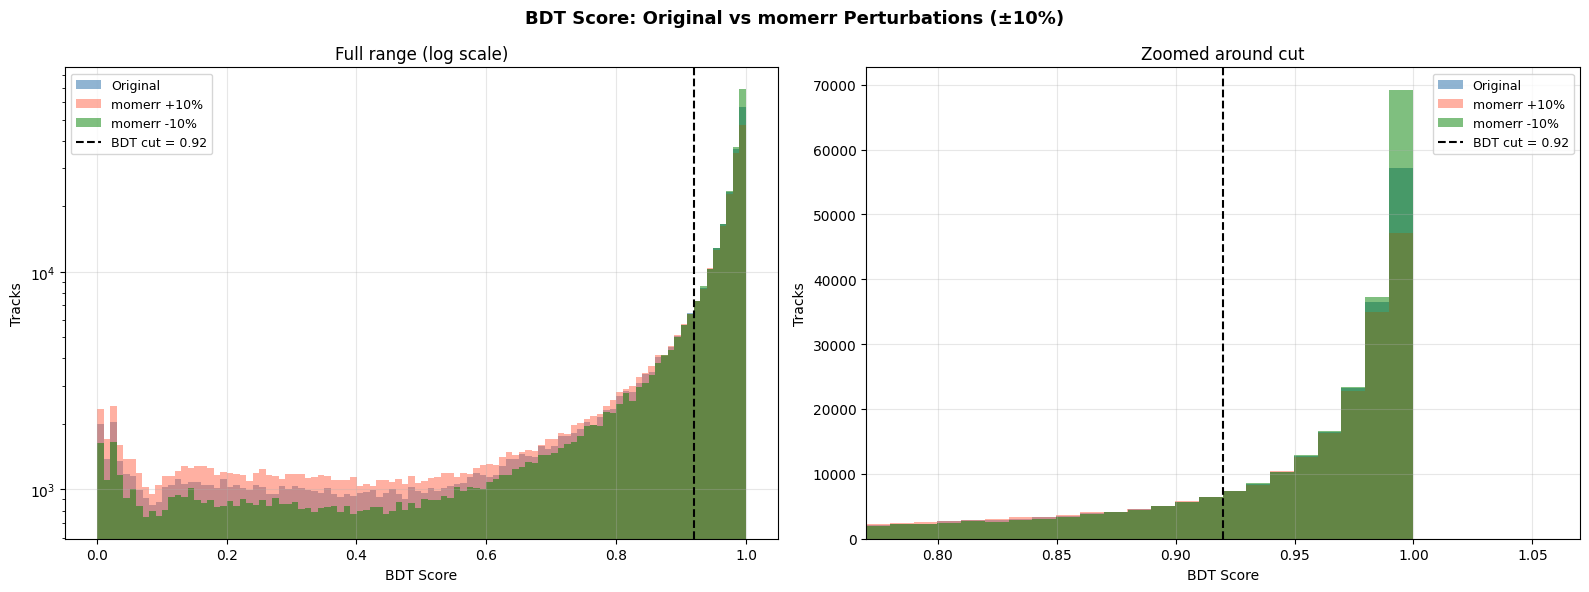


Total tracks in dataset: 317439
                            Mean shift     ± std   Changed       %    Signal     Bkg
------------------------------------------------------------------------------------------
Original                             —         —         —       —         —       —
momerr +10%                  -0.024245  0.034233     12643    3.98%     12610      33
momerr -10%                   0.024237  0.035373     13212    4.16%     13159      53


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("BDT Score: Original vs momerr Perturbations (±10%)",
             fontsize=13, fontweight='bold')

for ax, title, xlim in zip(axes,
                            ['Full range (log scale)', 'Zoomed around cut'],
                            [None, (trkqual_cut - 0.15, trkqual_cut + 0.15)]):
    ax.hist(y_pred_original_full, bins=100, alpha=0.6,
            color='steelblue', label='Original')
    ax.hist(y_pred_momerr_up,    bins=100, alpha=0.5,
            color='tomato',    label='momerr +10%')
    ax.hist(y_pred_momerr_down,  bins=100, alpha=0.5,
            color='green',     label='momerr -10%')
    ax.axvline(trkqual_cut, color='black', linestyle='--',
               linewidth=1.5, label=f'BDT cut = {trkqual_cut:.2f}')
    ax.set_xlabel("BDT Score")
    ax.set_ylabel("Tracks")
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    if xlim:
        ax.set_xlim(xlim)
    else:
        ax.set_yscale('log')

plt.tight_layout()
#plt.savefig("bdt_momerr_perturbation.png", dpi=150, bbox_inches='tight')
plt.show()

# Summary table for momerr perturbation effects 

#print("Summary: Effect of momerr perturbation on BDT")
print()
print(f"Total tracks in dataset: {len(y_pred_original_full)}")
print(f"{'':25s} {'Mean shift':>12}  {'± std':>8}  {'Changed':>8}  {'%':>6}  {'Signal':>8}  {'Bkg':>6}")
print("-" * 90)

for label, delta, y_pred in [
    ('Original',     delta_up*0,        y_pred_original_full),
    ('momerr +10%',  delta_up,          y_pred_momerr_up),
    ('momerr -10%',  delta_down,        y_pred_momerr_down),
]:
    bdt_pass_orig = y_pred_original_full >= trkqual_cut
    bdt_pass_new  = y_pred               >= trkqual_cut
    changed       = (bdt_pass_orig != bdt_pass_new).sum()
    sig_changed   = ((bdt_pass_orig != bdt_pass_new) & (y_full == 1)).sum()
    bkg_changed   = ((bdt_pass_orig != bdt_pass_new) & (y_full == 0)).sum()
    if label == 'Original':
        print(f"{'Original':<25} {'—':>12}  {'—':>8}  {'—':>8}  {'—':>6}  {'—':>8}  {'—':>6}")
    else:
        print(f"{label:<25} {delta.mean():>12.6f}  {delta.std():>8.6f}  "
              f"{changed:>8}  {changed/len(delta)*100:>6.2f}%  "
              f"{sig_changed:>8}  {bkg_changed:>6}")

The next cell print and divide on the total number of signal tracks instead of the total number of tracks where signal and background are combined.

Total tracks: 317,439  |  Signal: 303,990  |  Background: 13,449

                            Mean shift     ± std   Changed   % of signal    Signal     Bkg
------------------------------------------------------------------------------------------
Original                             —         —         —             —         —       —
momerr +10%                  -0.024245  0.034233     12643          4.15%     12610      33
momerr -10%                   0.024237  0.035373     13212          4.33%     13159      53


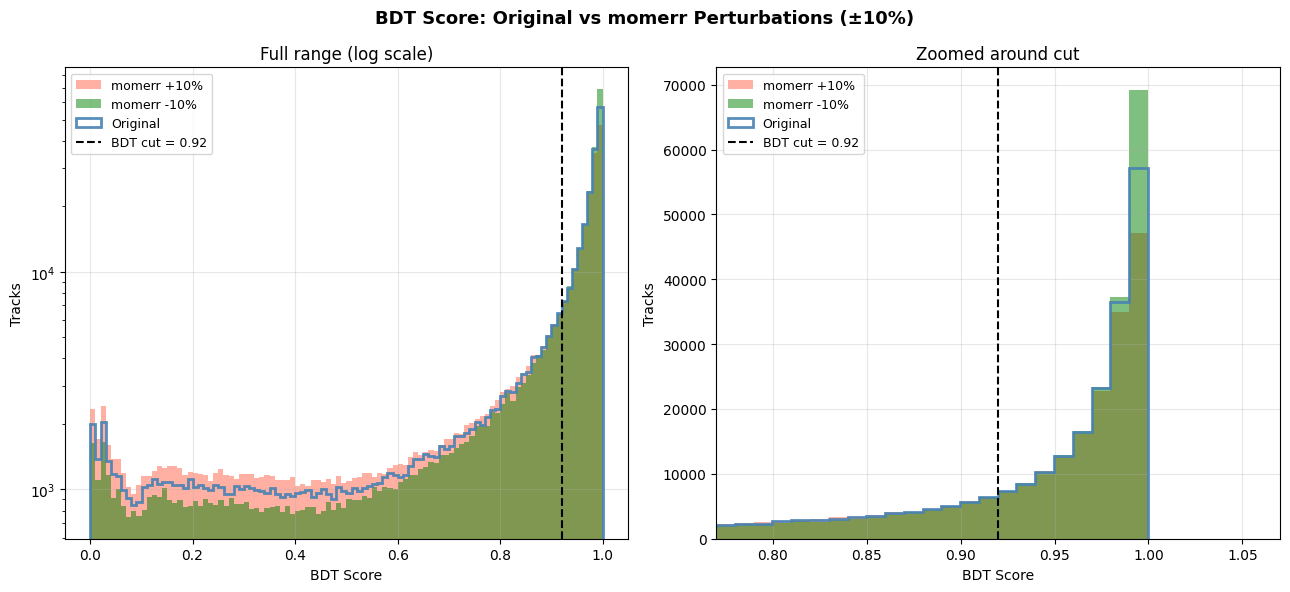

In [ ]:
# Summary table
N_signal = (y_full == 1).sum()
print(f"Total tracks: {len(y_pred_original_full):,}  |  Signal: {N_signal:,}  |  Background: {(y_full==0).sum():,}")
print()
print(f"{'':25s} {'Mean shift':>12}  {'± std':>8}  {'Changed':>8}  {'% of signal':>12}  {'Signal':>8}  {'Bkg':>6}")
print("-" * 90)

for label, delta, y_pred in [
    ('Original',    delta_up*0,   y_pred_original_full),
    ('momerr +10%', delta_up,     y_pred_momerr_up),
    ('momerr -10%', delta_down,   y_pred_momerr_down),
]:
    bdt_pass_orig = y_pred_original_full >= trkqual_cut
    bdt_pass_new  = y_pred               >= trkqual_cut
    changed       = (bdt_pass_orig != bdt_pass_new).sum()
    sig_changed   = ((bdt_pass_orig != bdt_pass_new) & (y_full == 1)).sum()
    bkg_changed   = ((bdt_pass_orig != bdt_pass_new) & (y_full == 0)).sum()

    if label == 'Original':
        print(f"{'Original':<25} {'—':>12}  {'—':>8}  {'—':>8}  {'—':>12}  {'—':>8}  {'—':>6}")
    else:
        print(f"{label:<25} {delta.mean():>12.6f}  {delta.std():>8.6f}  "
              f"{changed:>8}  {sig_changed/N_signal*100:>12.2f}%  "  # ← fixed here
              f"{sig_changed:>8}  {bkg_changed:>6}")


fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle("BDT Score: Original vs momerr Perturbations (±10%)",
             fontsize=13, fontweight='bold')

for ax, title, xlim in zip(axes,
                            ['Full range (log scale)', 'Zoomed around cut'],
                            [None, (trkqual_cut - 0.15, trkqual_cut + 0.15)]):
    # Plot perturbed first so original appears on top
    ax.hist(y_pred_momerr_up,    bins=100, alpha=0.5,
            color='tomato',    label='momerr +10%')
    ax.hist(y_pred_momerr_down,  bins=100, alpha=0.5,
            color='green',     label='momerr -10%')
    # Plot original last so it's always visible on top
    ax.hist(y_pred_original_full, bins=100, alpha=0.9,
            color='steelblue', label='Original',
            histtype='step', linewidth=2)  # ← step style so it's always visible
    ax.axvline(trkqual_cut, color='black', linestyle='--',
               linewidth=1.5, label=f'BDT cut = {trkqual_cut:.2f}')
    ax.set_xlabel("BDT Score")
    ax.set_ylabel("Tracks")
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    if xlim:
        ax.set_xlim(xlim)
    else:
        ax.set_yscale('log')

plt.tight_layout()
#plt.savefig("bdt_momerr_perturbation.png", dpi=150, bbox_inches='tight')
plt.show()

## For the presentation

/var/folders/p0/qdf2tryn1sd4_kf_28ckgz640000gn/T/ipykernel_9192/4248589075.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


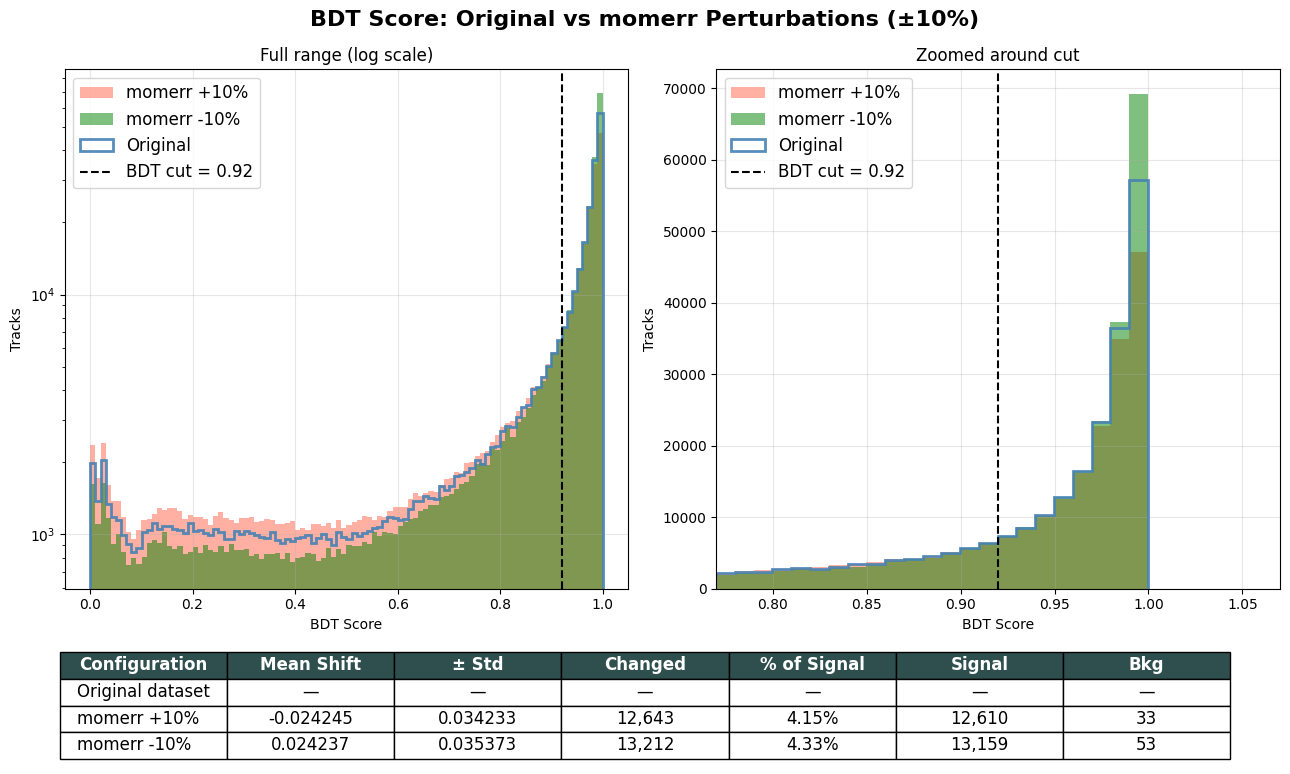

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Calculate structural metrics for each perturbation row
N_signal = (y_full == 1).sum()
bdt_pass_orig = y_pred_original_full >= trkqual_cut

# Row 2 Calculations (+10%)
bdt_pass_up = y_pred_momerr_up >= trkqual_cut
changed_up = (bdt_pass_orig != bdt_pass_up).sum()
sig_up = ((bdt_pass_orig != bdt_pass_up) & (y_full == 1)).sum()
bkg_up = ((bdt_pass_orig != bdt_pass_up) & (y_full == 0)).sum()

# Row 3 Calculations (-10%)
bdt_pass_down = y_pred_momerr_down >= trkqual_cut
changed_down = (bdt_pass_orig != bdt_pass_down).sum()
sig_down = ((bdt_pass_orig != bdt_pass_down) & (y_full == 1)).sum()
bkg_down = ((bdt_pass_orig != bdt_pass_down) & (y_full == 0)).sum()

# 2. Build the structural figure grid (taller canvas height to frame table)
fig, axes = plt.subplots(1, 2, figsize=(13, 6.5)) 
fig.suptitle("BDT Score: Original vs momerr Perturbations (±10%)", fontsize=16, fontweight='bold')

for ax, title, xlim in zip(axes, ['Full range (log scale)', 'Zoomed around cut'], [None, (trkqual_cut - 0.15, trkqual_cut + 0.15)]):
    ax.hist(y_pred_momerr_up, bins=100, alpha=0.5, color='tomato', label='momerr +10%')
    ax.hist(y_pred_momerr_down, bins=100, alpha=0.5, color='green', label='momerr -10%')
    ax.hist(y_pred_original_full, bins=100, alpha=0.9, color='steelblue', label='Original', histtype='step', linewidth=2)
    
    ax.axvline(trkqual_cut, color='black', linestyle='--', linewidth=1.5, label=f'BDT cut = {trkqual_cut:.2f}')
    ax.set_xlabel("BDT Score")
    ax.set_ylabel("Tracks")
    ax.set_title(title)
    
    # Kept in the upper left to stay completely clear of the right-side peaks
    ax.legend(loc='upper left', fontsize=12)
    ax.grid(alpha=0.3)
    
    if xlim:
        ax.set_xlim(xlim)
    else:
        ax.set_yscale('log')

# 3. Create the multi-row matrix data rows
table_data = [
    ["Original dataset", "—", "—", "—", "—", "—", "—"],
    ["momerr +10%", f"{delta_up.mean():.6f}", f"{delta_up.std():.6f}", f"{changed_up:,}", f"{sig_up/N_signal*100:.2f}%", f"{sig_up:,}", f"{bkg_up:,}"],
    ["momerr -10%", f"{delta_down.mean():.6f}", f"{delta_down.std():.6f}", f"{changed_down:,}", f"{sig_down/N_signal*100:.2f}%", f"{sig_down:,}", f"{bkg_down:,}"]
]

columns = ["Configuration", "Mean Shift", "± Std", "Changed", "% of Signal", "Signal", "Bkg"]

# Map table axis container to your optimal -0.22 vertical coordinate spacing
table_ax = fig.add_axes([0.05, -0.18, 0.9, 0.18]) 
table_ax.axis('off')

summary_table = table_ax.table(cellText=table_data, colLabels=columns, loc='center', cellLoc='center')

# Apply exact padding styles and font size mappings
summary_table.auto_set_font_size(False)
summary_table.set_fontsize(12) 
summary_table.scale(1.0, 1.6) # Tighter vertical stretching for multi-row block stability

# Layout alignment fixes for text column category titles
for (row, col), cell in summary_table.get_celld().items():
    if col == 0 and row > 0:
        cell.set_text_props(ha='left') # Keep text labels left-aligned, numbers centered
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#2f4f4f') # Clean charcoal slate color mapping

plt.subplots_adjust(bottom=0.15)
plt.tight_layout()
# plt.savefig("bdt_momerr_perturbation_matrix.png", dpi=200, bbox_inches='tight')
plt.show()


## End the Presentation slide

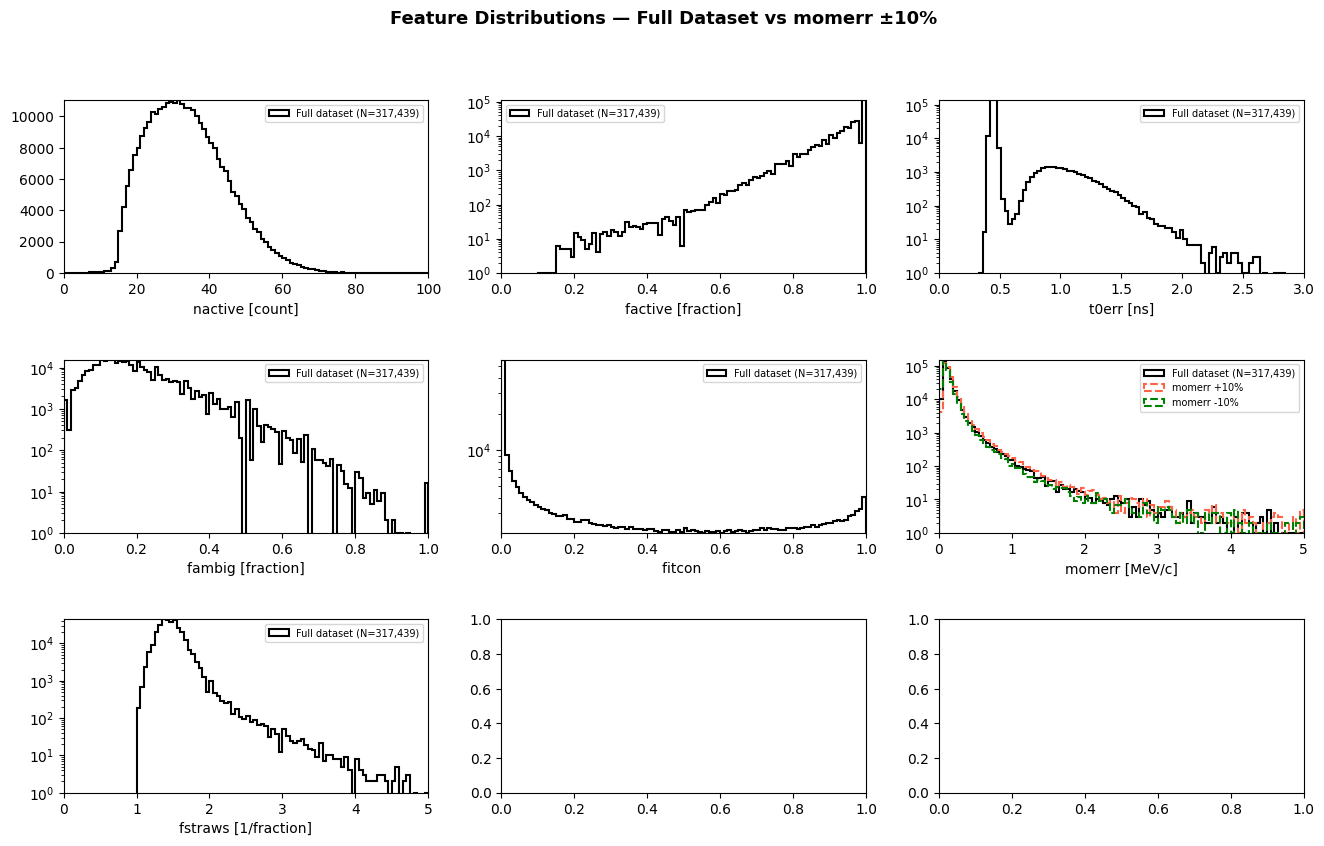

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extract momerr from perturbed feature matrices
x_momerr_up   = x_up
x_momerr_down = x_down 

# Get momerr column index
momerr_idx = input_var_names.index('momerr')

fig, axs = plt.subplots(3, 3, figsize=(16, 9))
fig.subplots_adjust(hspace=.5)
fig.suptitle("Feature Distributions — Full Dataset vs momerr ±10%", fontsize=13, fontweight='bold')

for i_var in range(n_input_vars):
    ax = axs.flatten()[i_var]
    
    # Full dataset — use x_full instead of x_all
    ax.hist(x_full[:, i_var], bins=100, range=(x_mins[i_var], x_maxs[i_var]),
            histtype='step', color='black', log=log_ys[i_var],
            label=f'Full dataset (N={len(x_full):,})', density=False, linewidth=1.5)
    
    # Only add perturbed for momerr column
    if i_var == momerr_idx:
        ax.hist(x_momerr_up[:, i_var], bins=100, range=(x_mins[i_var], x_maxs[i_var]),
                histtype='step', color='tomato', log=log_ys[i_var],
                label='momerr +10%', density=False, linestyle='--', linewidth=1.5)
        ax.hist(x_momerr_down[:, i_var], bins=100, range=(x_mins[i_var], x_maxs[i_var]),
                histtype='step', color='green', log=log_ys[i_var],
                label='momerr -10%', density=False, linestyle='--', linewidth=1.5)

    ax.set_xlabel(input_var_names[i_var] + " " + units[i_var])
    ax.margins(0)
    ax.legend(fontsize=7)

#plt.savefig("feature_distributions_momerr_perturbation.png", dpi=150, bbox_inches='tight')
plt.show()

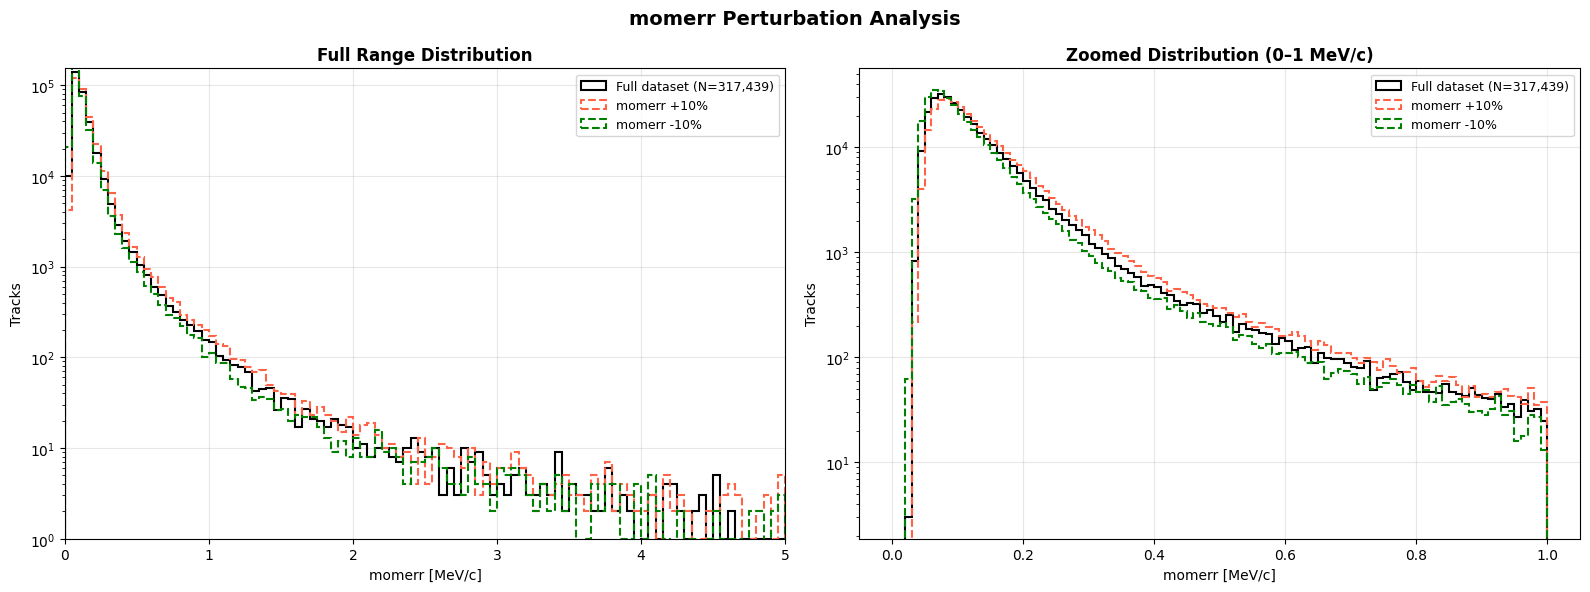

In [ ]:
# Combined momerr Distribution: Full Range and Zoomed
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
i = momerr_idx

# Define common plotting parameters to ensure consistency
plot_params = [
    (x_full[:, i], 'black', f'Full dataset (N={len(x_full):,})', '-'),
    (x_momerr_up[:, i], 'tomato', 'momerr +10%', '--'),
    (x_momerr_down[:, i], 'green', 'momerr -10%', '--'),
]

# Loop through both axes to apply the same data
for ax in [ax1, ax2]:
    for data, color, label, style in plot_params:
        ax.hist(data, bins=100, 
                range=(x_mins[i], x_maxs[i]) if ax == ax1 else (0, 1.0),
                histtype='step', color=color, log=True,
                label=label, linestyle=style, linewidth=1.5)
    
    ax.set_ylabel("Tracks")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

# Individual Customization
ax1.set_title("Full Range Distribution", fontweight='bold')
ax1.set_xlabel(f"{input_var_names[i]} {units[i]}")
ax1.margins(0)

ax2.set_title("Zoomed Distribution (0–1 MeV/c)", fontweight='bold')
ax2.set_xlabel("momerr [MeV/c]")

fig.suptitle("momerr Perturbation Analysis", fontsize=14, fontweight='bold')
plt.tight_layout()
#plt.savefig("momerr_combined_analysis.png", dpi=150, bbox_inches='tight')
plt.show()


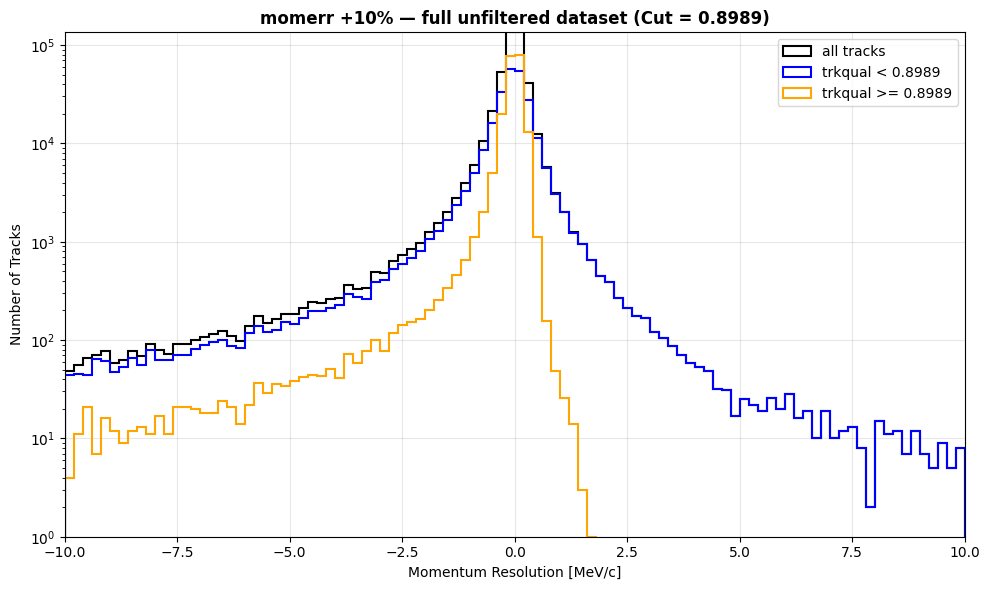

In [ ]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the optimal dynamic cut at 99% bkg rejection for momerr +10%
opt_cut_up10 = 0.8989 

# 2. Open the file to load the full, un-shuffled raw feature variables
with uproot.open(training_dataset_filename) as f:
    tree = f[training_dataset_treename]
    arrays = tree.arrays(library="np")
    
    # Extract native features without block stacking
    nactive = arrays['trk.nactive']
    nhits   = arrays['trk.nhits']
    factive = nactive / nhits
    fambig  = arrays['trk.nnullambig'] / nactive
    fstraws = arrays['trk.nmatactive'] / nactive
    t0err   = arrays['trk_ent_pars.t0err']
    fitcon  = arrays['trk.fitcon']
    
    # Apply the specific +10% perturbation across all tracks
    momerr  = arrays['trk_ent.momerr'] * 1.10  

# 3. Stack features into a 2D array and generate perfectly aligned BDT predictions
x_full_unfiltered = np.vstack((nactive, factive, t0err, fambig, fitcon, momerr, fstraws)).T
y_pred_full_unfiltered = model.predict_proba(x_full_unfiltered)[:, 1]

# 4. Plot using the full uncut global mom_res array
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

ax.hist(mom_res, bins=n_mom_res_bins, range=(min_mom_res, max_mom_res), log=True, 
        histtype='step', color='black', label='all tracks', linewidth=1.5)

ax.hist(mom_res[y_pred_full_unfiltered < opt_cut_up10], bins=n_mom_res_bins, range=(min_mom_res, max_mom_res), log=True, 
        histtype='step', color='blue', label=f'trkqual < {opt_cut_up10}', linewidth=1.5)

ax.hist(mom_res[y_pred_full_unfiltered >= opt_cut_up10], bins=n_mom_res_bins, range=(min_mom_res, max_mom_res), log=True, 
        histtype='step', color='orange', label=f'trkqual >= {opt_cut_up10}', linewidth=1.5)

# Layout and formatting adjustments
ax.legend(loc='upper right')
ax.margins(0)
ax.grid(True, alpha=0.3)
ax.set_xlabel("Momentum Resolution [MeV/c]")
ax.set_ylabel("Number of Tracks")
ax.set_title(f"momerr +10% — full unfiltered dataset (Cut = {opt_cut_up10})", fontweight='bold')

plt.tight_layout()
plt.show()


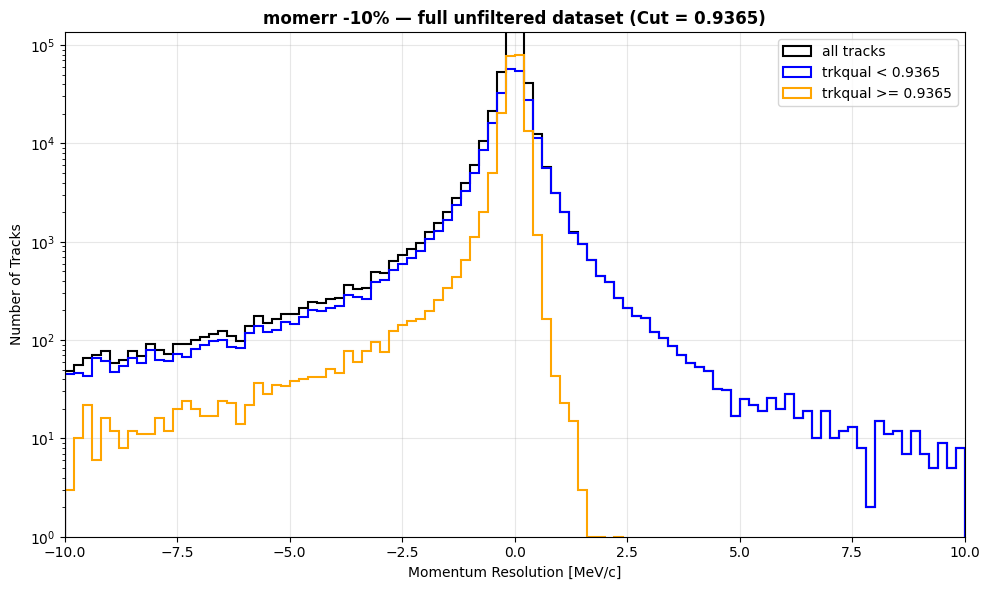

In [ ]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the optimal dynamic cut at 99% bkg rejection for momerr -10%
opt_cut_down10 = 0.9365 

# 2. Open the file to load the full, un-shuffled raw feature variables
with uproot.open(training_dataset_filename) as f:
    tree = f[training_dataset_treename]
    arrays = tree.arrays(library="np")
    
    # Extract native features sequentially
    nactive = arrays['trk.nactive']
    nhits   = arrays['trk.nhits']
    factive = nactive / nhits
    fambig  = arrays['trk.nnullambig'] / nactive
    fstraws = arrays['trk.nmatactive'] / nactive
    t0err   = arrays['trk_ent_pars.t0err']
    fitcon  = arrays['trk.fitcon']
    
    # Apply the specific -10% perturbation across all tracks
    momerr  = arrays['trk_ent.momerr'] * 0.90  

# 3. Stack features into a 2D array and generate perfectly aligned BDT predictions
x_full_unfiltered = np.vstack((nactive, factive, t0err, fambig, fitcon, momerr, fstraws)).T
y_pred_full_unfiltered = model.predict_proba(x_full_unfiltered)[:, 1]

# 4. Plot using the full uncut global mom_res array
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

ax.hist(mom_res, bins=n_mom_res_bins, range=(min_mom_res, max_mom_res), log=True, 
        histtype='step', color='black', label='all tracks', linewidth=1.5)

ax.hist(mom_res[y_pred_full_unfiltered < opt_cut_down10], bins=n_mom_res_bins, range=(min_mom_res, max_mom_res), log=True, 
        histtype='step', color='blue', label=f'trkqual < {opt_cut_down10}', linewidth=1.5)

ax.hist(mom_res[y_pred_full_unfiltered >= opt_cut_down10], bins=n_mom_res_bins, range=(min_mom_res, max_mom_res), log=True, 
        histtype='step', color='orange', label=f'trkqual >= {opt_cut_down10}', linewidth=1.5)

# Formatting adjustments
ax.legend(loc='upper right')
ax.margins(0)
ax.grid(True, alpha=0.3)
ax.set_xlabel("Momentum Resolution [MeV/c]")
ax.set_ylabel("Number of Tracks")
ax.set_title(f"momerr -10% — full unfiltered dataset (Cut = {opt_cut_down10})", fontweight='bold')

plt.tight_layout()
plt.show()


## The +50% & -50% momerr perturbation analysis!
_______________________________________________________________________________________________________________

In [ ]:
MOMERR_UP50_FILE   = training_dataset_filename.replace('.root', '_momerr_plus50pct.root')
MOMERR_DOWN50_FILE = training_dataset_filename.replace('.root', '_momerr_minus50pct.root')

# Get features for both files
x_up50   = get_features_from_file(MOMERR_UP50_FILE)
x_down50 = get_features_from_file(MOMERR_DOWN50_FILE)

# Run original model — no retraining
y_pred_momerr_up50   = model.predict_proba(x_up50)[:, 1]
y_pred_momerr_down50 = model.predict_proba(x_down50)[:, 1]

# Compare against original
delta_up50   = y_pred_momerr_up50   - y_pred_original_full
delta_down50 = y_pred_momerr_down50 - y_pred_original_full

# Find optimal cut at 99% background rejection for each
from sklearn.metrics import roc_curve, auc

print(f"{'Dataset':<25} {'AUC':>8}  {'Signal eff':>12}  {'BDT cut':>10}  {'Mean shift':>12}  {'% of signal':>12}  {'Signal':>8}  {'Bkg':>6}")
print("-" * 110)

for label, scores, delta in [
    ('momerr +50%', y_pred_momerr_up50,   delta_up50),
    ('momerr -50%', y_pred_momerr_down50, delta_down50),
]:
    fpr, tpr, thresholds = roc_curve(y_full, scores, pos_label=1)
    auc_score = auc(fpr, tpr)

    indices  = np.where(1 - fpr >= 0.99)[0]
    cut_idx  = indices[-1] if len(indices) > 0 else 0
    sig_eff  = tpr[cut_idx]
    opt_cut  = thresholds[cut_idx]

    bdt_pass_orig = y_pred_original_full >= trkqual_cut
    bdt_pass_new  = scores               >= opt_cut
    changed       = (bdt_pass_orig != bdt_pass_new).sum()
    sig_changed   = ((bdt_pass_orig != bdt_pass_new) & (y_full == 1)).sum()
    bkg_changed   = ((bdt_pass_orig != bdt_pass_new) & (y_full == 0)).sum()
    pct_signal    = sig_changed / N_signal * 100

    print(f"{label:<25} {auc_score:>8.4f}  {sig_eff*100:>11.2f}%  {opt_cut:>10.4f}  "
          f"{delta.mean():>12.6f}  {pct_signal:>12.2f}%  {sig_changed:>8}  {bkg_changed:>6}")

Dataset                        AUC    Signal eff     BDT cut    Mean shift   % of signal    Signal     Bkg
--------------------------------------------------------------------------------------------------------------
momerr +50%                 0.9464        54.92%      0.7915     -0.118770          4.44%     13511      51
momerr -50%                 0.9460        55.88%      0.9812      0.114746          5.43%     16507      49


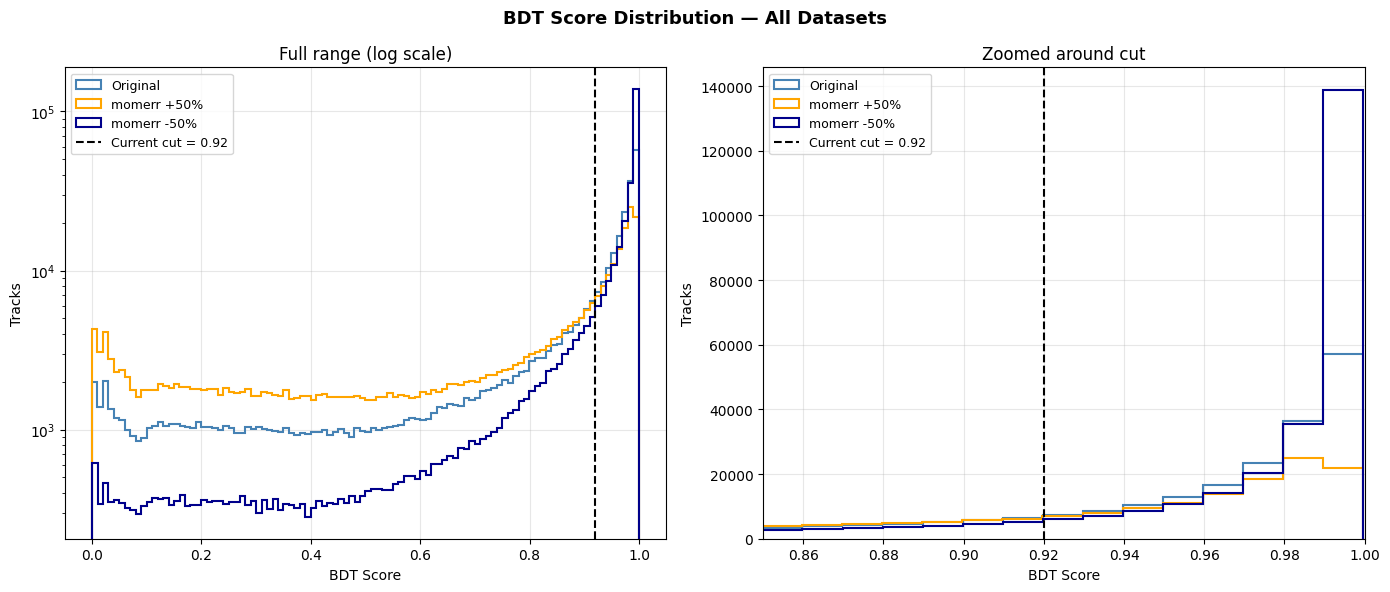

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("BDT Score Distribution — All Datasets", fontsize=13, fontweight='bold')

# Filtered to include only the original and the +/- 50% perturbations
datasets = [
    (y_pred_original_full,   'Original',      'steelblue', 'step',        2.0),
    (y_pred_momerr_up50,     'momerr +50%',   'orange',    'step',        1.5),
    (y_pred_momerr_down50,   'momerr -50%',   'darkblue',  'step',        1.5),
]

for ax, title, xlim in zip(axes,
                            ['Full range (log scale)', 'Zoomed around cut'],
                            [None, (0.85, 1.0)]):
    for scores, label, color, htype, alpha in datasets:
        ax.hist(scores, bins=100, alpha=min(alpha, 1.0), color=color,
                histtype=htype, linewidth=1.5, label=label)
    ax.axvline(trkqual_cut, color='black', linestyle='--',
               linewidth=1.5, label=f'Current cut = {trkqual_cut:.2f}')
    ax.set_xlabel("BDT Score")
    ax.set_ylabel("Tracks")
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    if xlim:
        ax.set_xlim(xlim)
    else:
        ax.set_yscale('log')

plt.tight_layout()
#plt.savefig("bdt_all_datasets.png", dpi=150, bbox_inches='tight')
plt.show()


## For the presentation

/var/folders/p0/qdf2tryn1sd4_kf_28ckgz640000gn/T/ipykernel_9192/1331593777.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


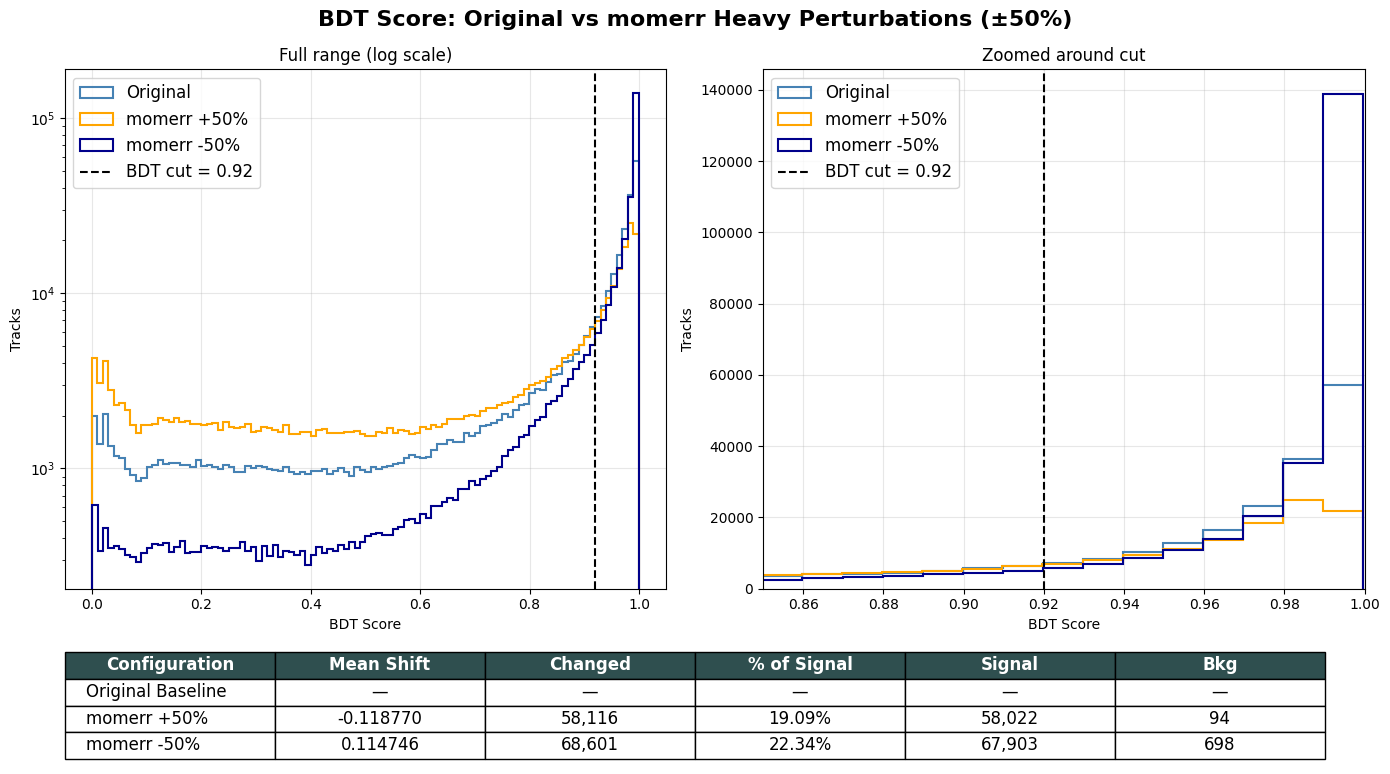

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Calculate structural metrics for each perturbation row
N_signal = (y_full == 1).sum()
bdt_pass_orig = y_pred_original_full >= trkqual_cut

# Row 2 Calculations (+50%)
bdt_pass_up50 = y_pred_momerr_up50 >= trkqual_cut
changed_up50 = (bdt_pass_orig != bdt_pass_up50).sum()
sig_up50 = ((bdt_pass_orig != bdt_pass_up50) & (y_full == 1)).sum()
bkg_up50 = ((bdt_pass_orig != bdt_pass_up50) & (y_full == 0)).sum()

# Row 3 Calculations (-50%)
bdt_pass_down50 = y_pred_momerr_down50 >= trkqual_cut
changed_down50 = (bdt_pass_orig != bdt_pass_down50).sum()
sig_down50 = ((bdt_pass_orig != bdt_pass_down50) & (y_full == 1)).sum()
bkg_down50 = ((bdt_pass_orig != bdt_pass_down50) & (y_full == 0)).sum()

# 2. Build the structural figure grid (taller canvas height to frame table)
fig, axes = plt.subplots(1, 2, figsize=(14, 6.5)) 
fig.suptitle("BDT Score: Original vs momerr Heavy Perturbations (±50%)", fontsize=16, fontweight='bold')

datasets = [
    (y_pred_original_full, 'Original', 'steelblue', 'step', 2.0),
    (y_pred_momerr_up50, 'momerr +50%', 'orange', 'step', 1.5),
    (y_pred_momerr_down50, 'momerr -50%', 'darkblue', 'step', 1.5),
]

for ax, title, xlim in zip(axes, ['Full range (log scale)', 'Zoomed around cut'], [None, (0.85, 1.0)]):
    for scores, label, color, htype, alpha in datasets:
        ax.hist(scores, bins=100, alpha=min(alpha, 1.0), color=color, 
                histtype=htype, linewidth=1.5, label=label)
    
    ax.axvline(trkqual_cut, color='black', linestyle='--', linewidth=1.5, label=f'BDT cut = {trkqual_cut:.2f}')
    ax.set_xlabel("BDT Score")
    ax.set_ylabel("Tracks")
    ax.set_title(title)
    
    # Kept in the upper left to stay completely clear of the right-side peaks
    ax.legend(loc='upper left', fontsize=12)
    ax.grid(alpha=0.3)
    
    if xlim:
        ax.set_xlim(xlim)
    else:
        ax.set_yscale('log')

# 3. Create the multi-row matrix data rows
delta_up50 = y_pred_momerr_up50 - y_pred_original_full
delta_down50 = y_pred_momerr_down50 - y_pred_original_full

table_data = [
    ["Original Baseline", "—", "—", "—", "—", "—"],
    ["momerr +50%", f"{delta_up50.mean():.6f}", f"{changed_up50:,}", f"{sig_up50/N_signal*100:.2f}%", f"{sig_up50:,}", f"{bkg_up50:,}"],
    ["momerr -50%", f"{delta_down50.mean():.6f}", f"{changed_down50:,}", f"{sig_down50/N_signal*100:.2f}%", f"{sig_down50:,}", f"{bkg_down50:,}"]
]

columns = ["Configuration", "Mean Shift", "Changed", "% of Signal", "Signal", "Bkg"]

# Map table axis container to your optimal -0.22 vertical coordinate spacing
table_ax = fig.add_axes([0.05, -0.18, 0.9, 0.18]) 
table_ax.axis('off')

summary_table = table_ax.table(cellText=table_data, colLabels=columns, loc='center', cellLoc='center')

# Apply exact padding styles and font size mappings
summary_table.auto_set_font_size(False)
summary_table.set_fontsize(12) 
summary_table.scale(1.0, 1.6) # Multi-row block stability

# Layout alignment fixes for text column category titles
for (row, col), cell in summary_table.get_celld().items():
    if col == 0 and row > 0:
        cell.set_text_props(ha='left') # Keep text labels left-aligned, numbers centered
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#2f4f4f') # Clean charcoal slate color mapping

plt.subplots_adjust(bottom=0.15)
plt.tight_layout()
# plt.savefig("bdt_momerr_heavy_perturbation_matrix.png", dpi=200, bbox_inches='tight')
plt.show()


## End of Presentation Slid

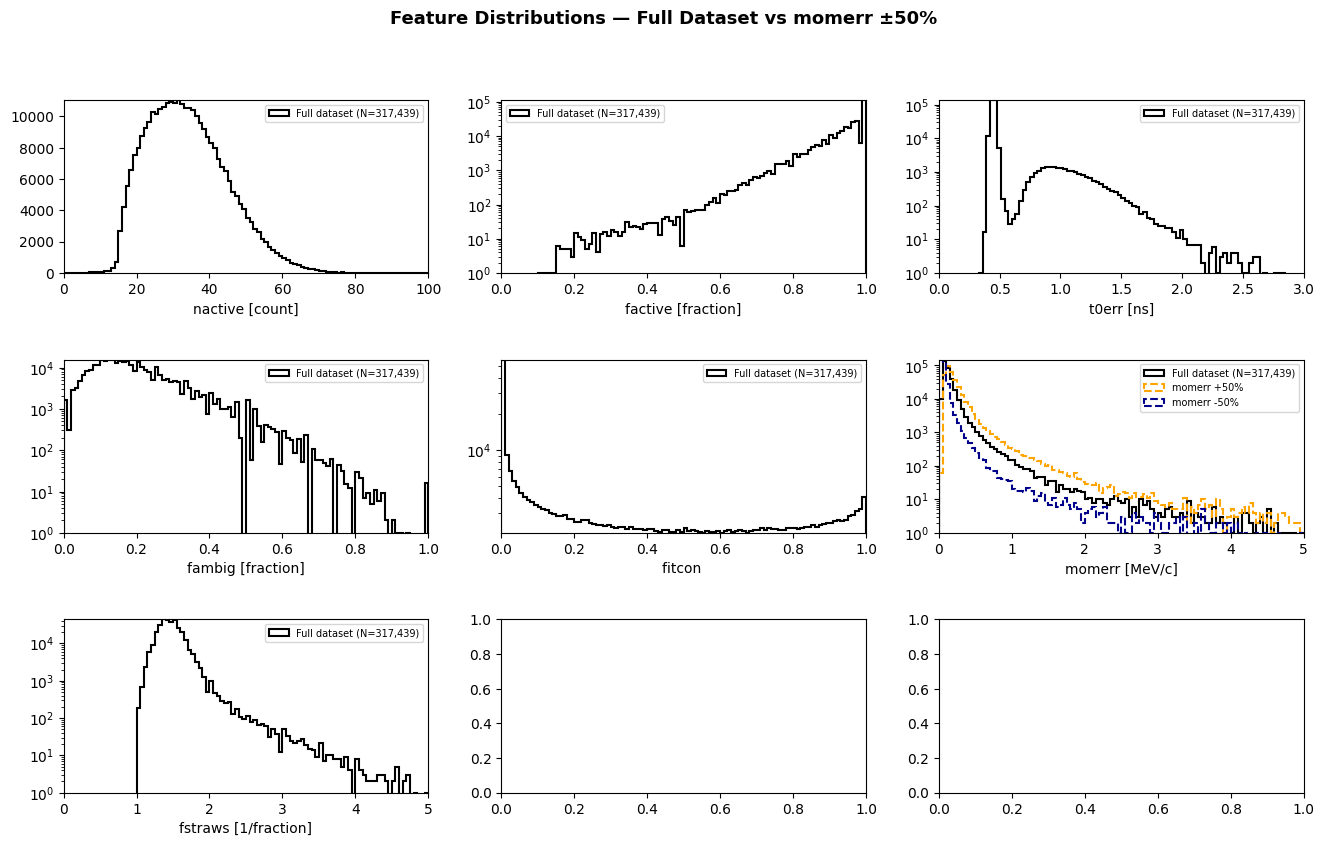

In [ ]:
fig, axs = plt.subplots(3, 3, figsize=(16, 9))
fig.subplots_adjust(hspace=.5)
fig.suptitle("Feature Distributions — Full Dataset vs momerr ±50%", fontsize=13, fontweight='bold')

for i_var in range(n_input_vars):
    ax = axs.flatten()[i_var]
    ax.hist(x_full[:, i_var], bins=100, range=(x_mins[i_var], x_maxs[i_var]),
            histtype='step', color='black', log=log_ys[i_var],
            label=f'Full dataset (N={len(x_full):,})', linewidth=1.5)
    if i_var == momerr_idx:
        ax.hist(x_up50[:, i_var], bins=100, range=(x_mins[i_var], x_maxs[i_var]),
                histtype='step', color='orange', log=log_ys[i_var],
                label='momerr +50%', linestyle='--', linewidth=1.5)
        ax.hist(x_down50[:, i_var], bins=100, range=(x_mins[i_var], x_maxs[i_var]),
                histtype='step', color='darkblue', log=log_ys[i_var],
                label='momerr -50%', linestyle='--', linewidth=1.5)
    ax.set_xlabel(input_var_names[i_var] + " " + units[i_var])
    ax.margins(0)
    ax.legend(fontsize=7)

#plt.savefig("feature_distributions_momerr_50pct.png", dpi=150, bbox_inches='tight')
plt.show()

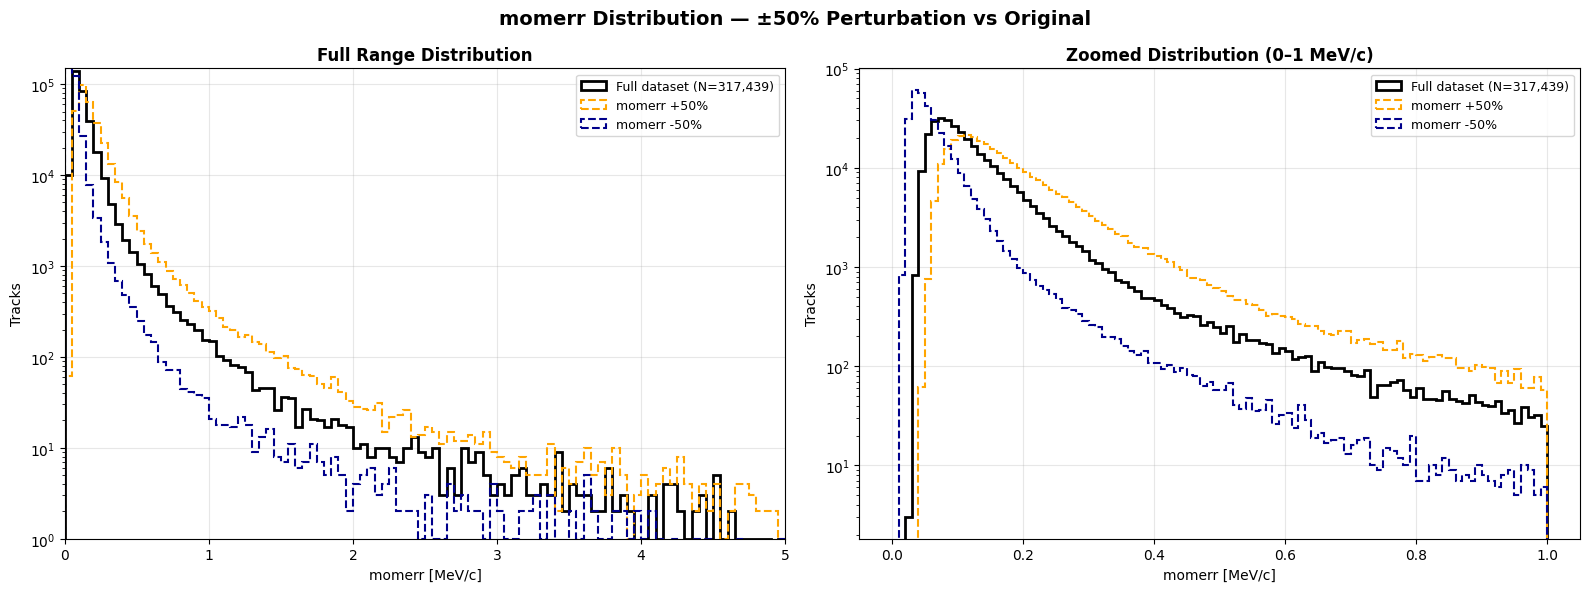

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

plot_params_50 = [
    (x_full[:, i],   'black',    f'Full dataset (N={len(x_full):,})', '-',  2.0),
    (x_up50[:, i],   'orange',   'momerr +50%',                       '--', 1.5),
    (x_down50[:, i], 'darkblue', 'momerr -50%',                       '--', 1.5),
]

for ax in [ax1, ax2]:
    for data, color, label, style, lw in plot_params_50:
        ax.hist(data, bins=100,
                range=(x_mins[i], x_maxs[i]) if ax == ax1 else (0, 1.0),
                histtype='step', color=color, log=True,
                label=label, linestyle=style, linewidth=lw)
    ax.set_ylabel("Tracks")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

ax1.set_title("Full Range Distribution", fontweight='bold')
ax1.set_xlabel(f"{input_var_names[i]} {units[i]}")
ax1.margins(0)
ax2.set_title("Zoomed Distribution (0–1 MeV/c)", fontweight='bold')
ax2.set_xlabel("momerr [MeV/c]")
fig.suptitle("momerr Distribution — ±50% Perturbation vs Original",
             fontsize=14, fontweight='bold')
plt.tight_layout()
#plt.savefig("momerr_plus_minus_50pct.png", dpi=150, bbox_inches='tight')
plt.show()

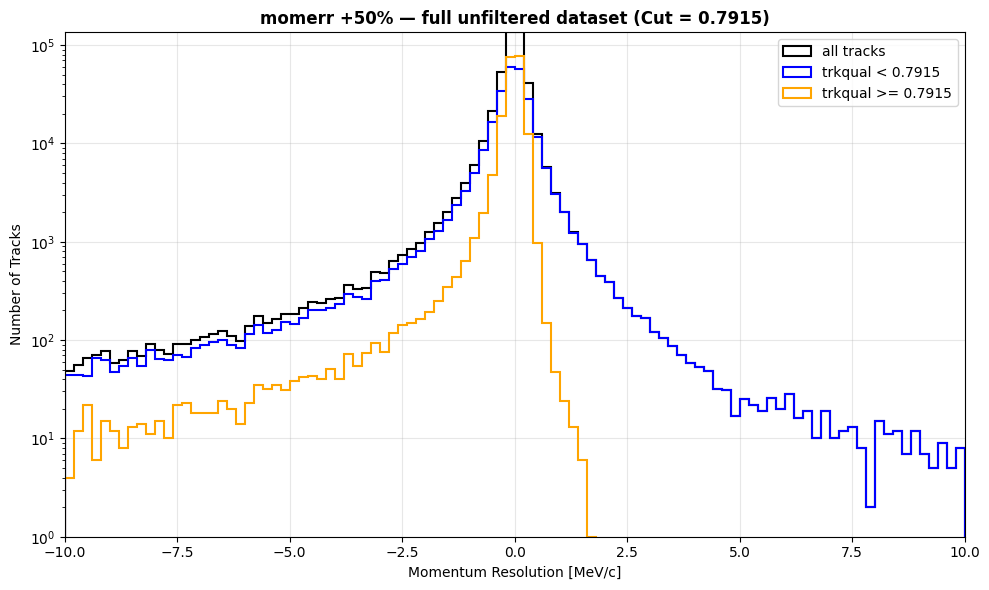

In [ ]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the optimal dynamic cut at 99% bkg rejection for momerr +50%
opt_cut_up50 = 0.7915 

# 2. Open the file to load the full, un-shuffled raw feature variables
with uproot.open(training_dataset_filename) as f:
    tree = f[training_dataset_treename]
    arrays = tree.arrays(library="np")
    
    # Extract native features sequentially
    nactive = arrays['trk.nactive']
    nhits   = arrays['trk.nhits']
    factive = nactive / nhits
    fambig  = arrays['trk.nnullambig'] / nactive
    fstraws = arrays['trk.nmatactive'] / nactive
    t0err   = arrays['trk_ent_pars.t0err']
    fitcon  = arrays['trk.fitcon']
    
    # Apply the specific +50% perturbation across all tracks
    momerr  = arrays['trk_ent.momerr'] * 1.50  

# 3. Stack features into a 2D array and generate perfectly aligned BDT predictions
x_full_unfiltered = np.vstack((nactive, factive, t0err, fambig, fitcon, momerr, fstraws)).T
y_pred_full_unfiltered = model.predict_proba(x_full_unfiltered)[:, 1]

# 4. Plot using the full uncut global mom_res array
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

ax.hist(mom_res, bins=n_mom_res_bins, range=(min_mom_res, max_mom_res), log=True, 
        histtype='step', color='black', label='all tracks', linewidth=1.5)

ax.hist(mom_res[y_pred_full_unfiltered < opt_cut_up50], bins=n_mom_res_bins, range=(min_mom_res, max_mom_res), log=True, 
        histtype='step', color='blue', label=f'trkqual < {opt_cut_up50}', linewidth=1.5)

ax.hist(mom_res[y_pred_full_unfiltered >= opt_cut_up50], bins=n_mom_res_bins, range=(min_mom_res, max_mom_res), log=True, 
        histtype='step', color='orange', label=f'trkqual >= {opt_cut_up50}', linewidth=1.5)

# Formatting adjustments
ax.legend(loc='upper right')
ax.margins(0)
ax.grid(True, alpha=0.3)
ax.set_xlabel("Momentum Resolution [MeV/c]")
ax.set_ylabel("Number of Tracks")
ax.set_title(f"momerr +50% — full unfiltered dataset (Cut = {opt_cut_up50})", fontweight='bold')

plt.tight_layout()
plt.show()

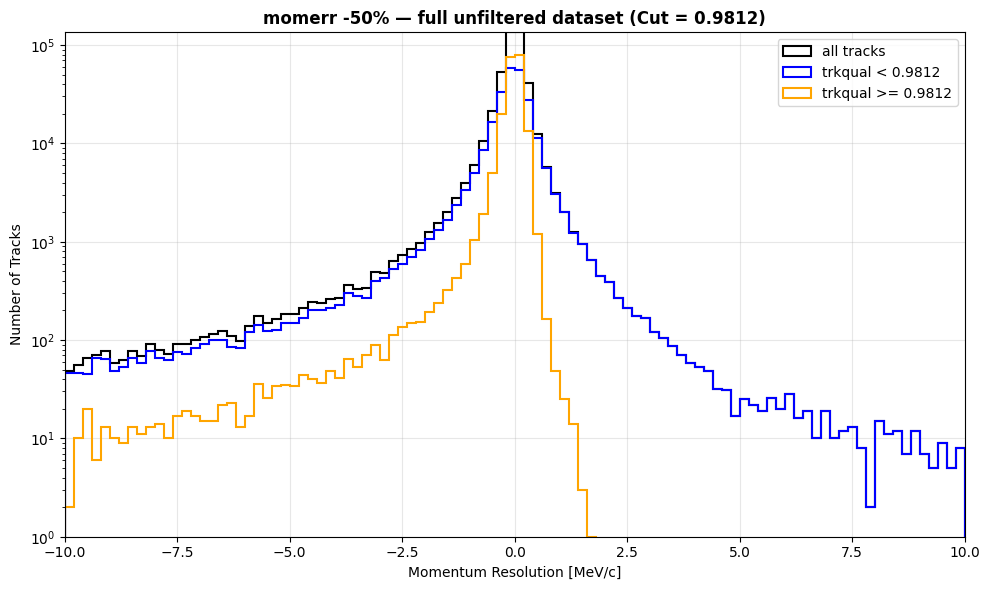

In [ ]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the optimal dynamic cut at 99% bkg rejection for momerr -50%
opt_cut_down50 = 0.9812 

# 2. Open the file to load the full, un-shuffled raw feature variables
with uproot.open(training_dataset_filename) as f:
    tree = f[training_dataset_treename]
    arrays = tree.arrays(library="np")
    
    # Extract native features sequentially
    nactive = arrays['trk.nactive']
    nhits   = arrays['trk.nhits']
    factive = nactive / nhits
    fambig  = arrays['trk.nnullambig'] / nactive
    fstraws = arrays['trk.nmatactive'] / nactive
    t0err   = arrays['trk_ent_pars.t0err']
    fitcon  = arrays['trk.fitcon']
    
    # Apply the specific -50% perturbation across all tracks
    momerr  = arrays['trk_ent.momerr'] * 0.50  

# 3. Stack features into a 2D array and generate perfectly aligned BDT predictions
x_full_unfiltered = np.vstack((nactive, factive, t0err, fambig, fitcon, momerr, fstraws)).T
y_pred_full_unfiltered = model.predict_proba(x_full_unfiltered)[:, 1]

# 4. Plot using the full uncut global mom_res array
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

ax.hist(mom_res, bins=n_mom_res_bins, range=(min_mom_res, max_mom_res), log=True, 
        histtype='step', color='black', label='all tracks', linewidth=1.5)

ax.hist(mom_res[y_pred_full_unfiltered < opt_cut_down50], bins=n_mom_res_bins, range=(min_mom_res, max_mom_res), log=True, 
        histtype='step', color='blue', label=f'trkqual < {opt_cut_down50}', linewidth=1.5)

ax.hist(mom_res[y_pred_full_unfiltered >= opt_cut_down50], bins=n_mom_res_bins, range=(min_mom_res, max_mom_res), log=True, 
        histtype='step', color='orange', label=f'trkqual >= {opt_cut_down50}', linewidth=1.5)

# Formatting adjustments
ax.legend(loc='upper right')
ax.margins(0)
ax.grid(True, alpha=0.3)
ax.set_xlabel("Momentum Resolution [MeV/c]")
ax.set_ylabel("Number of Tracks")
ax.set_title(f"momerr -50% — full unfiltered dataset (Cut = {opt_cut_down50})", fontweight='bold')

plt.tight_layout()
plt.show()


## Fambig Analysis

In [ ]:
# =====================================================================
# CONFIG — change this one variable per run
# =====================================================================
# Options:
#   "fambig"        ->  tests  _fambig_full.root
#   "momerr"        ->  tests  _momerr_x2.root
#   "both"          ->  tests  _fambigFull_momerrX2.root
#   "momerr_pm50"   ->  tests both  _momerr_plus50pct.root  AND  _momerr_minus50pct.root

SCENARIO = "fambig"
# =====================================================================

import numpy as np
from sklearn.metrics import roc_curve, auc

# ---------------------------------------------------------------------
# Map scenario -> file(s)
# ---------------------------------------------------------------------
def files_for(scenario):
    base = training_dataset_filename
    if scenario == "fambig":
        return [("fambig = 1.0",  base.replace('.root', '_fambig_full.root'))]
    if scenario == "momerr":
        return [("momerr × 2",    base.replace('.root', '_momerr_x2.root'))]
    if scenario == "both":
        return [("Both stressed", base.replace('.root', '_fambigFull_momerrX2.root'))]
    if scenario == "momerr_pm50":
        return [("momerr +50%", base.replace('.root', '_momerr_plus50pct.root')),
                ("momerr -50%", base.replace('.root', '_momerr_minus50pct.root'))]
    raise ValueError(f"Unknown scenario: {scenario}")

# ---------------------------------------------------------------------
# Header
# ---------------------------------------------------------------------
print(f"{'Dataset':<22} {'AUC':>8}  {'Sig eff':>10}  {'BDT cut':>9}  "
      f"{'Mean shift':>12}  {'% sig flipped':>14}  {'Δsig':>7}  {'Δbkg':>7}")
print("-" * 110)

# ---------------------------------------------------------------------
# Baseline numbers (computed once)
# ---------------------------------------------------------------------
fpr0, tpr0, thr0 = roc_curve(y_full, y_pred_original_full, pos_label=1)
idx0    = np.where(1 - fpr0 >= 0.99)[0]
cut_idx = idx0[-1] if len(idx0) > 0 else 0
bdt_cut = thr0[cut_idx]
print(f"{'Baseline (orig)':<22} {auc(fpr0,tpr0):>8.4f}  "
      f"{tpr0[cut_idx]*100:>9.2f}%  {bdt_cut:>9.4f}  "
      f"{0.0:>12.6f}  {0.0:>13.2f}%  {0:>7}  {0:>7}")

# ---------------------------------------------------------------------
# Loop over the file(s) for this scenario
# ---------------------------------------------------------------------
for label, fname in files_for(SCENARIO):
    # 1) Get features for this stressed file
    x_new = get_features_from_file(fname)

    # 2) Run original model — no retraining
    y_new = model.predict_proba(x_new)[:, 1]

    # 3) Per-track prediction shift
    delta = y_new - y_pred_original_full

    # 4) ROC + AUC
    fpr, tpr, thr = roc_curve(y_full, y_new, pos_label=1)
    auc_score     = auc(fpr, tpr)

    # 5) Optimal cut at 99% BG rejection
    idx        = np.where(1 - fpr >= 0.99)[0]
    cut_i      = idx[-1] if len(idx) > 0 else 0
    sig_eff    = tpr[cut_i]
    opt_cut    = thr[cut_i]

    # 6) Track flipping at the ORIGINAL cut (bdt_cut)
    pass_orig  = y_pred_original_full >= bdt_cut
    pass_new   = y_new                >= bdt_cut
    flipped    = (pass_orig != pass_new)
    sig_flipped = (flipped & (y_full == 1)).sum()
    bkg_flipped = (flipped & (y_full == 0)).sum()
    pct_sig     = sig_flipped / N_signal * 100.0

    print(f"{label:<22} {auc_score:>8.4f}  {sig_eff*100:>9.2f}%  "
          f"{opt_cut:>9.4f}  {delta.mean():>+12.6f}  "
          f"{pct_sig:>13.2f}%  {sig_flipped:>7}  {bkg_flipped:>7}")


Dataset                     AUC     Sig eff    BDT cut    Mean shift   % sig flipped     Δsig     Δbkg
--------------------------------------------------------------------------------------------------------------
Baseline (orig)          0.9486      57.00%     0.9182      0.000000           0.00%        0        0
fambig = 1.0             0.9432      50.71%     0.8005     -0.119727          36.61%   111277      123


/var/folders/p0/qdf2tryn1sd4_kf_28ckgz640000gn/T/ipykernel_9192/20943043.py:183: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


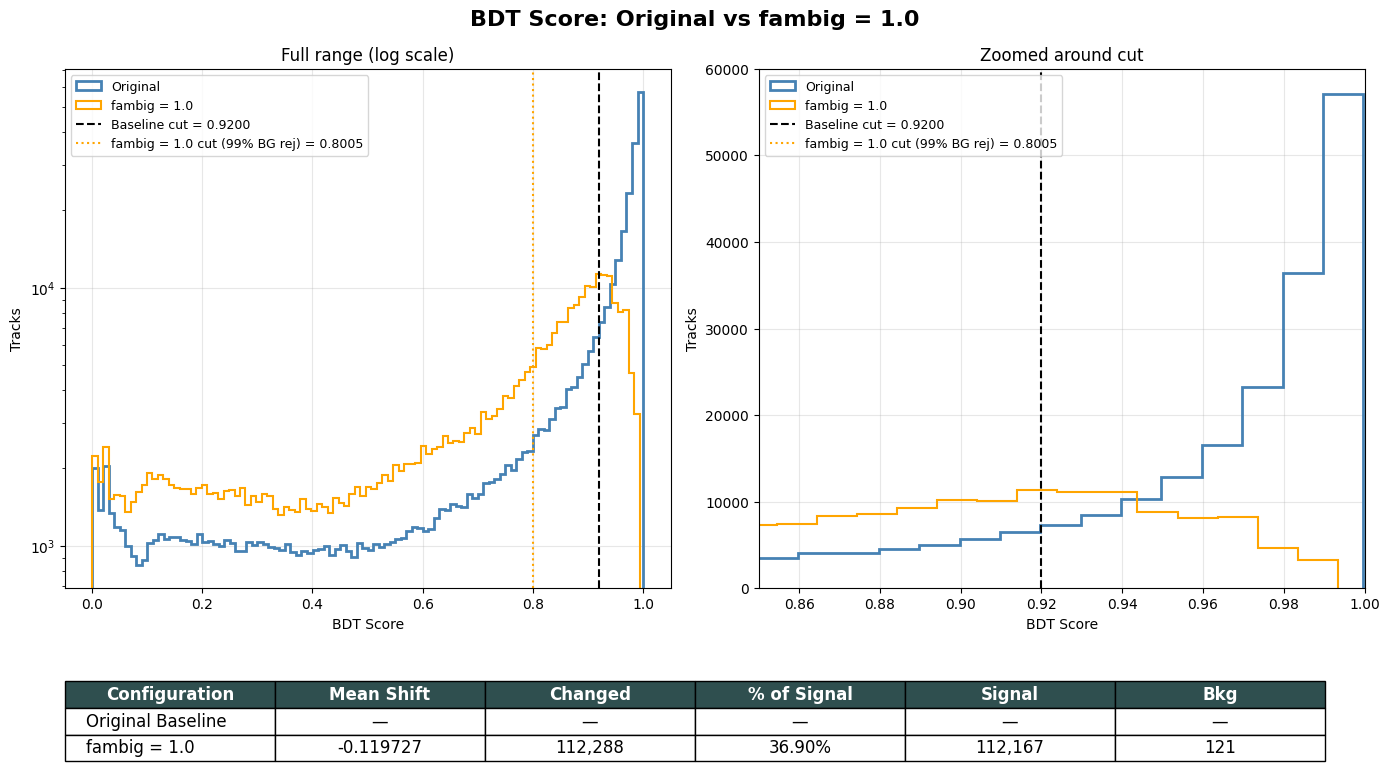

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc

# =====================================================================
# CONFIG — change to "fambig", "momerr", "both", or "momerr_pm50"
# =====================================================================
SCENARIO = "fambig"
# =====================================================================

# ---------------------------------------------------------------------
# Map scenario -> list of (label, color, scores_array)
# (the scores arrays are produced further down — this is just metadata)
# ---------------------------------------------------------------------
def scenario_meta(s):
    if s == "fambig":
        return {
            "title":    "BDT Score: Original vs fambig = 1.0",
            "rows":     [("Original",      "steelblue", 2.0),
                         ("fambig = 1.0",  "orange",    1.5)],
            "ylim":     (0.85, 1.0),
        }
    if s == "momerr":
        return {
            "title":    "BDT Score: Original vs momerr × 2",
            "rows":     [("Original",      "steelblue", 2.0),
                         ("momerr × 2",    "orange",    1.5)],
            "ylim":     (0.85, 1.0),
        }
    if s == "both":
        return {
            "title":    "BDT Score: Original vs Both stressed (fambig=1 & momerr×2)",
            "rows":     [("Original",       "steelblue", 2.0),
                         ("Both stressed",  "orange",    1.5)],
            "ylim":     (0.85, 1.0),
        }
    if s == "momerr_pm50":
        return {
            "title":    "BDT Score: Original vs momerr Heavy Perturbations (±50%)",
            "rows":     [("Original",      "steelblue", 2.0),
                         ("momerr +50%",   "orange",    1.5),
                         ("momerr -50%",   "darkblue",  1.5)],
            "ylim":     (0.85, 1.0),
        }
    raise ValueError(s)

meta = scenario_meta(SCENARIO)

# ---------------------------------------------------------------------
# Resolve filenames for this scenario
# ---------------------------------------------------------------------
def stress_filename(scenario, variant):
    base = training_dataset_filename
    return {
        "fambig_full"      : base.replace('.root', '_fambig_full.root'),
        "momerr_x2"        : base.replace('.root', '_momerr_x2.root'),
        "both"             : base.replace('.root', '_fambigFull_momerrX2.root'),
        "momerr_plus50"    : base.replace('.root', '_momerr_plus50pct.root'),
        "momerr_minus50"   : base.replace('.root', '_momerr_minus50pct.root'),
    }[variant]

# ---------------------------------------------------------------------
# Build the perturbed score arrays for this scenario
# ---------------------------------------------------------------------
def scores_for(scenario):
    if scenario == "fambig":
        x = get_features_from_file(stress_filename(scenario, "fambig_full"))
        return model.predict_proba(x)[:, 1]
    if scenario == "momerr":
        x = get_features_from_file(stress_filename(scenario, "momerr_x2"))
        return model.predict_proba(x)[:, 1]
    if scenario == "both":
        x = get_features_from_file(stress_filename(scenario, "both"))
        return model.predict_proba(x)[:, 1]
    if scenario == "momerr_pm50":
        x_up   = get_features_from_file(stress_filename(scenario, "momerr_plus50"))
        x_down = get_features_from_file(stress_filename(scenario, "momerr_minus50"))
        return model.predict_proba(x_up)[:, 1], model.predict_proba(x_down)[:, 1]

if SCENARIO == "momerr_pm50":
    y_new_up, y_new_down = scores_for(SCENARIO)
    perturbed = {
        "momerr +50%" : y_new_up,
        "momerr -50%" : y_new_down,
    }
else:
    y_new = scores_for(SCENARIO)
    perturbed = {meta["rows"][1][0]: y_new}

# ---------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))
fig.suptitle(meta["title"], fontsize=16, fontweight='bold')

# Build the dataset list (always include Original at front)
datasets = [(y_pred_original_full, "Original", "steelblue", 2.0)]
for label, color, lw in meta["rows"][1:]:
    datasets.append((perturbed[label], label, color, lw))

for ax, panel_title, xlim in zip(
        axes,
        ["Full range (log scale)", "Zoomed around cut"],
        [None, meta["ylim"]]):

    for scores, label, color, lw in datasets:
        ax.hist(scores, bins=100, histtype="step",
                linewidth=lw, color=color, label=label)

    # ----- BASELINE cut (black dashed) -----
    ax.axvline(trkqual_cut, color='black', linestyle='--', linewidth=1.5,
               label=f'Baseline cut = {trkqual_cut:.4f}')

    # ----- CORRECTED cut per dataset at 99% BG rejection -----
    # solid thin vertical line for each perturbed file
    palette = {"Original": "steelblue"}
    for i, (label, color, _) in enumerate(meta["rows"][1:]):
        scores = perturbed[label]
        fpr, tpr, thr = roc_curve(y_full, scores, pos_label=1)
        idx = np.where(1 - fpr >= 0.99)[0]
        if len(idx) > 0:
            ci   = idx[-1]
            cut  = thr[ci]
            ax.axvline(cut, color=color, linestyle=':', linewidth=1.5,
                       label=f'{label} cut (99% BG rej) = {cut:.4f}')

    ax.set_xlabel("BDT Score")
    ax.set_ylabel("Tracks")
    ax.set_title(panel_title)
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(alpha=0.3)
    if xlim:
        ax.set_xlim(xlim)
    else:
        ax.set_yscale('log')

# ---------------------------------------------------------------------
# Build summary table
# ---------------------------------------------------------------------
N_signal = (y_full == 1).sum()
bdt_pass_orig = y_pred_original_full >= trkqual_cut

table_data  = [["Original Baseline", "—", "—", "—", "—", "—"]]
columns     = ["Configuration", "Mean Shift", "Changed", "% of Signal", "Signal", "Bkg"]

for label, color, _ in meta["rows"][1:]:
    y_new       = perturbed[label]
    delta       = y_new - y_pred_original_full
    bdt_pass    = y_new >= trkqual_cut
    changed     = (bdt_pass_orig != bdt_pass).sum()
    sig_changed = ((bdt_pass_orig != bdt_pass) & (y_full == 1)).sum()
    bkg_changed = ((bdt_pass_orig != bdt_pass) & (y_full == 0)).sum()
    table_data.append([
        label,
        f"{delta.mean():+.6f}",
        f"{changed:,}",
        f"{sig_changed/N_signal*100:.2f}%",
        f"{sig_changed:,}",
        f"{bkg_changed:,}",
    ])

# ---------------------------------------------------------------------
# Render the table below the plots
# ---------------------------------------------------------------------
n_rows = len(table_data) + 1
table_ax = fig.add_axes([0.05, -0.04 - 0.05*n_rows, 0.9, 0.05*n_rows])
table_ax.axis('off')

summary_table = table_ax.table(cellText=table_data, colLabels=columns,
                               loc='center', cellLoc='center')
summary_table.auto_set_font_size(False)
summary_table.set_fontsize(12)
summary_table.scale(1.0, 1.6)

for (row, col), cell in summary_table.get_celld().items():
    if col == 0 and row > 0:
        cell.set_text_props(ha='left')
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#2f4f4f')

plt.subplots_adjust(bottom=0.18 + 0.05*n_rows)
plt.tight_layout()
plt.show()


/var/folders/p0/qdf2tryn1sd4_kf_28ckgz640000gn/T/ipykernel_9192/220528825.py:158: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.94])


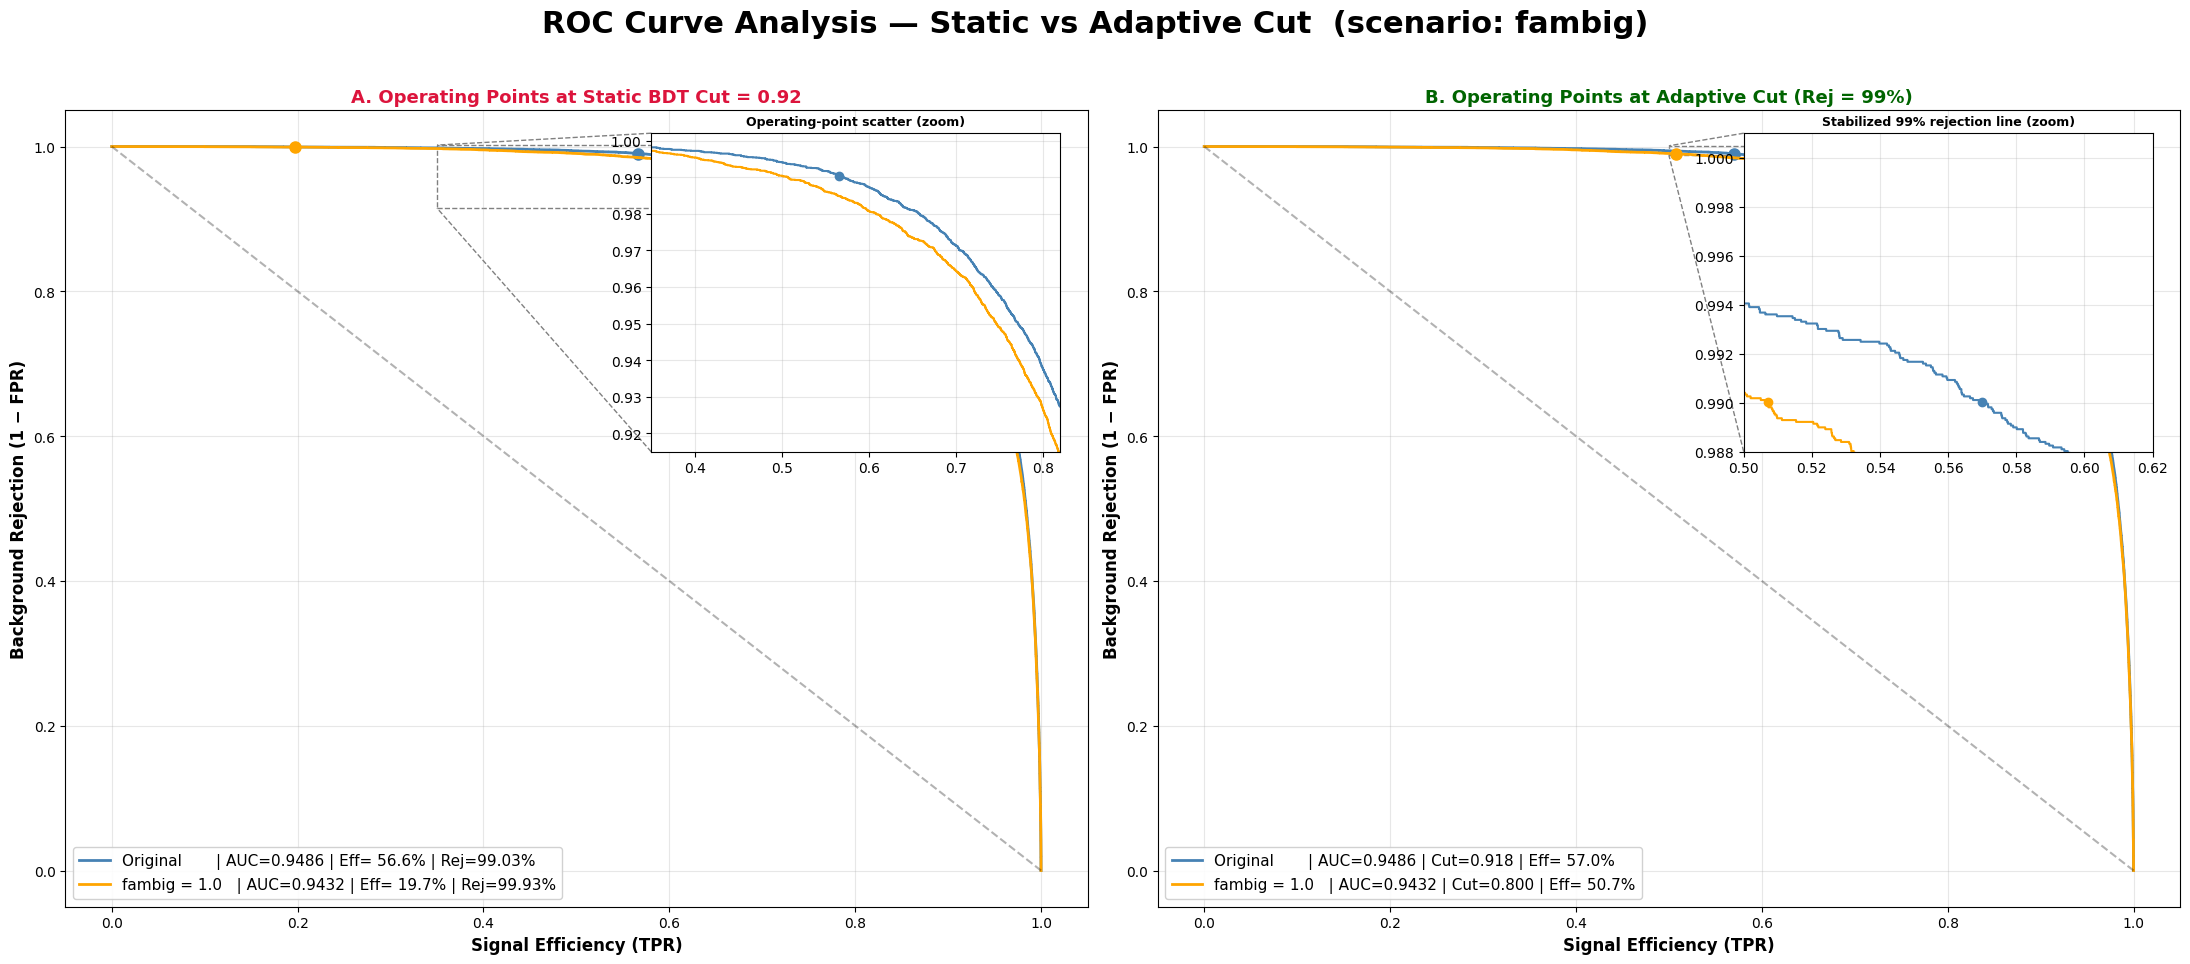

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# =====================================================================
# CONFIG — change this to switch scenarios
# =====================================================================
# Options:
#   "fambig"   ->  just fambig = 1.0
#   "momerr"   ->  just momerr × 2
#   "both"     ->  combined fambig=1 + momerr×2
#   "all"      ->  momerr ±10%, ±50%, fambig=1, combined, original
# =====================================================================
SCENARIO = "fambig"
# =====================================================================

# ---------------------------------------------------------------------
# Map scenario -> list of (filename, label, color)
# ---------------------------------------------------------------------
def datasets_for(scenario):
    base = training_dataset_filename

    common = [
        (base, "Original", "steelblue"),
    ]
    perturbed = {
        "fambig" : [(base.replace('.root', '_fambig_full.root'),
                     "fambig = 1.0", "orange")],
        "momerr" : [(base.replace('.root', '_momerr_x2.root'),
                     "momerr × 2", "orange")],
        "both"   : [(base.replace('.root', '_fambigFull_momerrX2.root'),
                     "Both stressed", "orange")],
        "all"    : [
            (base.replace('.root', '_momerr_plus10pct.root'),
             "momerr +10%", "tomato"),
            (base.replace('.root', '_momerr_minus10pct.root'),
             "momerr -10%", "limegreen"),
            (base.replace('.root', '_momerr_plus50pct.root'),
             "momerr +50%", "orange"),
            (base.replace('.root', '_momerr_minus50pct.root'),
             "momerr -50%", "darkblue"),
            (base.replace('.root', '_fambig_full.root'),
             "fambig = 1.0", "purple"),
            (base.replace('.root', '_fambigFull_momerrX2.root'),
             "Both stressed", "crimson"),
        ],
    }
    return common + perturbed[scenario]

dataset_meta = datasets_for(SCENARIO)

# ---------------------------------------------------------------------
# Load / compute (score, label) for each entry
# ---------------------------------------------------------------------
def load_scores(fname):
    x = get_features_from_file(fname)
    return model.predict_proba(x)[:, 1]

datasets_roc = []
for fname, label, color in dataset_meta:
    scores = (y_pred_original_full if fname == training_dataset_filename
              else load_scores(fname))
    datasets_roc.append((scores, y_full, label, color))

# ---------------------------------------------------------------------
# Plot parameters
# ---------------------------------------------------------------------
static_cut_target = 0.92
rej_target        = 0.99

# ---------------------------------------------------------------------
# Initialize side-by-side subplots
# ---------------------------------------------------------------------
n_panels = len(datasets_roc)
fig_w = max(22, 14 + 1.5 * (n_panels - 4))   # wider if many panels
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(fig_w, 10))
fig.suptitle(f"ROC Curve Analysis — Static vs Adaptive Cut  "
             f"(scenario: {SCENARIO})",
             fontsize=22, fontweight='bold', y=0.96)

ax_ins1 = inset_axes(ax1, width="40%", height="40%", loc='upper right',
                     bbox_to_anchor=(-0.02, -0.02, 1, 1),
                     bbox_transform=ax1.transAxes)
ax_ins2 = inset_axes(ax2, width="40%", height="40%", loc='upper right',
                     bbox_to_anchor=(-0.02, -0.02, 1, 1),
                     bbox_transform=ax2.transAxes)

# ---------------------------------------------------------------------
# Loop over datasets
# ---------------------------------------------------------------------
for scores, labels, name, color in datasets_roc:
    fpr, tpr, thresholds = roc_curve(labels, scores, pos_label=1)
    auc_score = auc(fpr, tpr)

    # ---- LEFT PANEL: STATIC CUT ----
    idx_static = np.where(thresholds >= static_cut_target)[0]
    idx_s = idx_static[-1] if len(idx_static) > 0 else 0
    sig_eff_s = float(tpr[idx_s])
    bkg_rej_s = float(1 - fpr[idx_s])

    ax1.plot(tpr, 1 - fpr, color=color, linewidth=2,
             label=f"{name:<14} | AUC={auc_score:.4f} | "
                   f"Eff={sig_eff_s*100:5.1f}% | "
                   f"Rej={bkg_rej_s*100:5.2f}%")
    ax1.plot(tpr[idx_s], 1 - fpr[idx_s], 'o', color=color, markersize=8)
    ax_ins1.plot(tpr, 1 - fpr, color=color, linewidth=1.5)
    ax_ins1.plot(tpr[idx_s], 1 - fpr[idx_s], 'o', color=color, markersize=6)

    # ---- RIGHT PANEL: ADAPTIVE CUT ----
    idx_dyn = np.where(1 - fpr >= rej_target)[0]
    idx_d = idx_dyn[-1] if len(idx_dyn) > 0 else 0
    sig_eff_d = float(tpr[idx_d])
    opt_cut   = float(thresholds[idx_d])

    ax2.plot(tpr, 1 - fpr, color=color, linewidth=2,
             label=f"{name:<14} | AUC={auc_score:.4f} | "
                   f"Cut={opt_cut:.3f} | "
                   f"Eff={sig_eff_d*100:5.1f}%")
    ax2.plot(tpr[idx_d], 1 - fpr[idx_d], 'o', color=color, markersize=8)
    ax_ins2.plot(tpr, 1 - fpr, color=color, linewidth=1.5)
    ax_ins2.plot(tpr[idx_d], 1 - fpr[idx_d], 'o', color=color, markersize=6)

# ---------------------------------------------------------------------
# Format LEFT subplot
# ---------------------------------------------------------------------
ax1.plot([0, 1], [1, 0], 'k--', alpha=0.3)
ax1.set_xlabel("Signal Efficiency (TPR)", fontsize=12, fontweight='bold')
ax1.set_ylabel("Background Rejection (1 − FPR)", fontsize=12, fontweight='bold')
ax1.set_title(f"A. Operating Points at Static BDT Cut = {static_cut_target:.2f}",
              fontsize=13, fontweight='bold', color='crimson')
ax1.grid(alpha=0.3)
ax1.legend(loc='lower left', fontsize=11, framealpha=0.9)

ax_ins1.set_xlim(0.35, 0.82)
ax_ins1.set_ylim(0.915, 1.002)
ax_ins1.set_title("Operating-point scatter (zoom)", fontsize=9, fontweight='bold')
ax_ins1.grid(alpha=0.3)
mark_inset(ax1, ax_ins1, loc1=2, loc2=3, fc="none", ec="0.5", ls="--")

# ---------------------------------------------------------------------
# Format RIGHT subplot
# ---------------------------------------------------------------------
ax2.plot([0, 1], [1, 0], 'k--', alpha=0.3)
ax2.set_xlabel("Signal Efficiency (TPR)", fontsize=12, fontweight='bold')
ax2.set_ylabel("Background Rejection (1 − FPR)", fontsize=12, fontweight='bold')
ax2.set_title(f"B. Operating Points at Adaptive Cut (Rej = {rej_target*100:.0f}%)",
              fontsize=13, fontweight='bold', color='darkgreen')
ax2.grid(alpha=0.3)
ax2.legend(loc='lower left', fontsize=11, framealpha=0.9)

ax_ins2.set_xlim(0.50, 0.62)
ax_ins2.set_ylim(0.988, 1.001)
ax_ins2.set_title("Stabilized 99% rejection line (zoom)", fontsize=9, fontweight='bold')
ax_ins2.grid(alpha=0.3)
mark_inset(ax2, ax_ins2, loc1=2, loc2=3, fc="none", ec="0.5", ls="--")

plt.tight_layout(rect=[0, 0, 1, 0.94])
# plt.savefig(f"roc_robustness_{SCENARIO}.png", dpi=200, bbox_inches='tight")
plt.show()


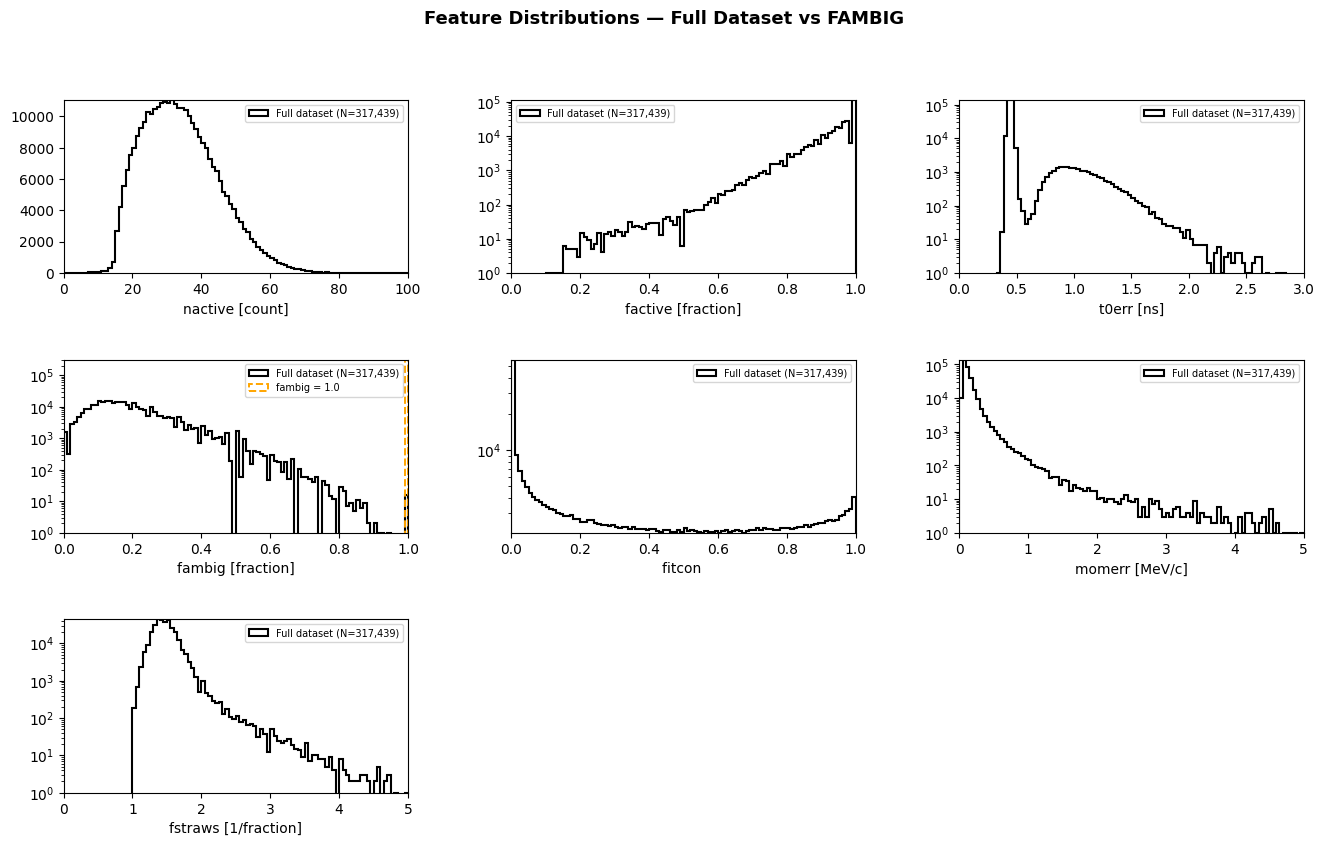

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# =====================================================================
# CONFIG — pick the scenario to overlay
# =====================================================================
# Options:
#   "fambig"  -> overlay  _fambig_full.root
#   "momerr"  -> overlay  _momerr_x2.root
#   "both"    -> overlay  _fambigFull_momerrX2.root
# =====================================================================
SCENARIO = "fambig"
# =====================================================================

# ---------------------------------------------------------------------
# Resolve file(s) and color/style for the scenario
# ---------------------------------------------------------------------
def perturbed_files(scenario):
    base = training_dataset_filename
    if scenario == "fambig":
        return [(base.replace('.root', '_fambig_full.root'),
                 "fambig = 1.0", "orange", "--")]
    if scenario == "momerr":
        return [(base.replace('.root', '_momerr_x2.root'),
                 "momerr × 2", "orange", "--")]
    if scenario == "both":
        return [(base.replace('.root', '_fambigFull_momerrX2.root'),
                 "Both stressed", "orange", "--")]
    raise ValueError(scenario)

perturbed = perturbed_files(SCENARIO)

# ---------------------------------------------------------------------
# Load feature arrays for the perturbed file
# ---------------------------------------------------------------------
x_perturbed = {}
for fname, label, color, ls in perturbed:
    x_perturbed[label] = get_features_from_file(fname)

# ---------------------------------------------------------------------
# Figure setup
# ---------------------------------------------------------------------
n_input_vars = len(input_var_names)
n_rows, n_cols = 3, 3
fig, axs = plt.subplots(n_rows, n_cols, figsize=(16, 9))
fig.subplots_adjust(hspace=0.5, wspace=0.3)

title_str = "Feature Distributions — Full Dataset vs " + SCENARIO.upper()
fig.suptitle(title_str, fontsize=13, fontweight='bold')

# ---------------------------------------------------------------------
# Loop over all input variables
# ---------------------------------------------------------------------
for i_var in range(n_input_vars):
    ax = axs.flatten()[i_var]

    # Baseline distribution
    ax.hist(x_full[:, i_var], bins=100,
            range=(x_mins[i_var], x_maxs[i_var]),
            histtype='step', color='black',
            log=log_ys[i_var],
            label=f'Full dataset (N={len(x_full):,})',
            linewidth=1.5)

    # Overlay the perturbed file
    for fname, label, color, ls in perturbed:
        x_arr = x_perturbed[label]
        # Skip if the feature is unchanged in this perturbation
        if np.array_equal(x_arr[:, i_var], x_full[:, i_var]):
            continue
        ax.hist(x_arr[:, i_var], bins=100,
                range=(x_mins[i_var], x_maxs[i_var]),
                histtype='step', color=color, ls=ls,
                log=log_ys[i_var],
                label=label, linewidth=1.4)

    ax.set_xlabel(input_var_names[i_var] + " " + units[i_var])
    ax.margins(0)
    ax.legend(fontsize=7, loc='best')

# Hide unused axes if n_input_vars < 9
for j in range(n_input_vars, n_rows * n_cols):
    axs.flatten()[j].axis('off')

# plt.savefig(f"feature_distributions_{SCENARIO}.png", dpi=150, bbox_inches='tight")
plt.show()


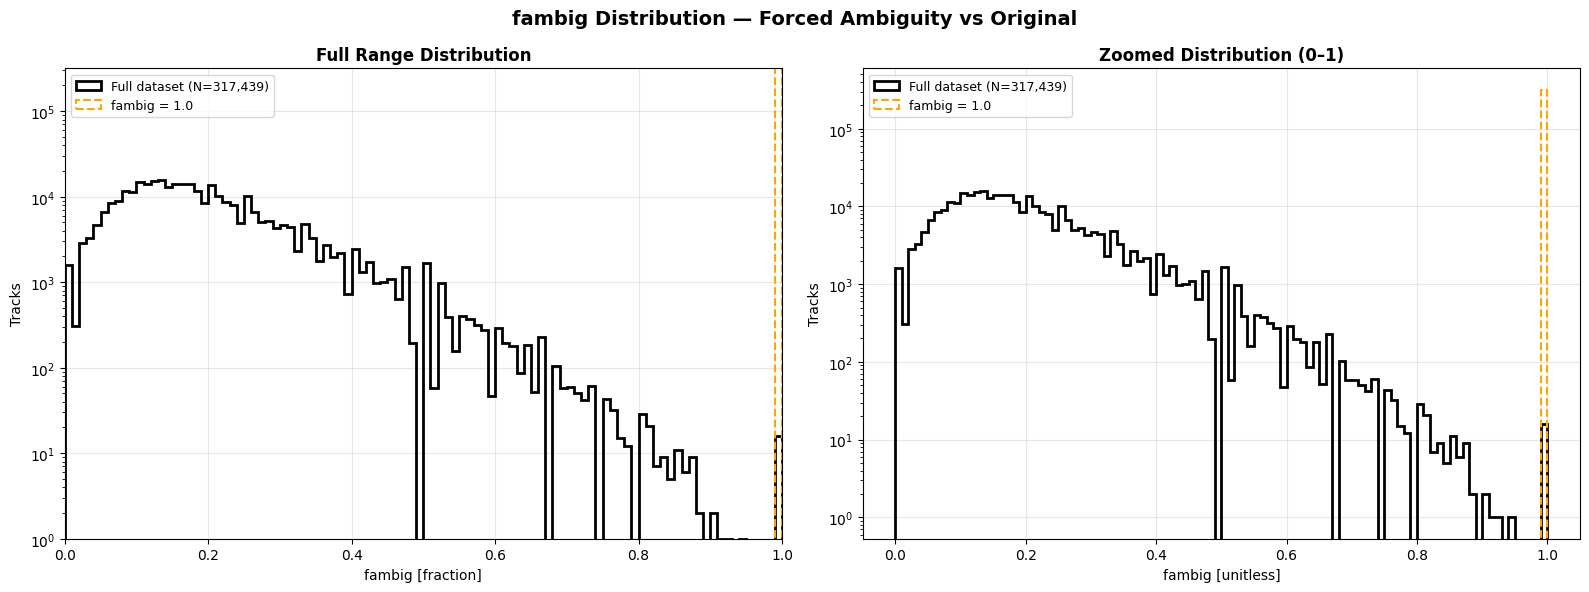

In [ ]:
i = input_var_names.index("fambig")

x_full = get_features_from_file(training_dataset_filename)
x_amb  = get_features_from_file(
    training_dataset_filename.replace('.root', '_fambig_full.root')
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

plot_params_fambig = [
    (x_full[:, i], 'black',  f'Full dataset (N={len(x_full):,})', '-',  2.0),
    (x_amb[:,  i], 'orange', 'fambig = 1.0',                     '--', 1.5),
]

for ax in [ax1, ax2]:
    for data, color, label, style, lw in plot_params_fambig:
        ax.hist(data, bins=100,
                range=(x_mins[i], x_maxs[i]) if ax == ax1 else (0, 1.0),
                histtype='step', color=color, log=True,
                label=label, linestyle=style, linewidth=lw)
    ax.set_ylabel("Tracks")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

ax1.set_title("Full Range Distribution", fontweight='bold')
ax1.set_xlabel(f"{input_var_names[i]} {units[i]}")
ax1.margins(0)
ax2.set_title("Zoomed Distribution (0–1)", fontweight='bold')
ax2.set_xlabel("fambig [unitless]")
fig.suptitle("fambig Distribution — Forced Ambiguity vs Original",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


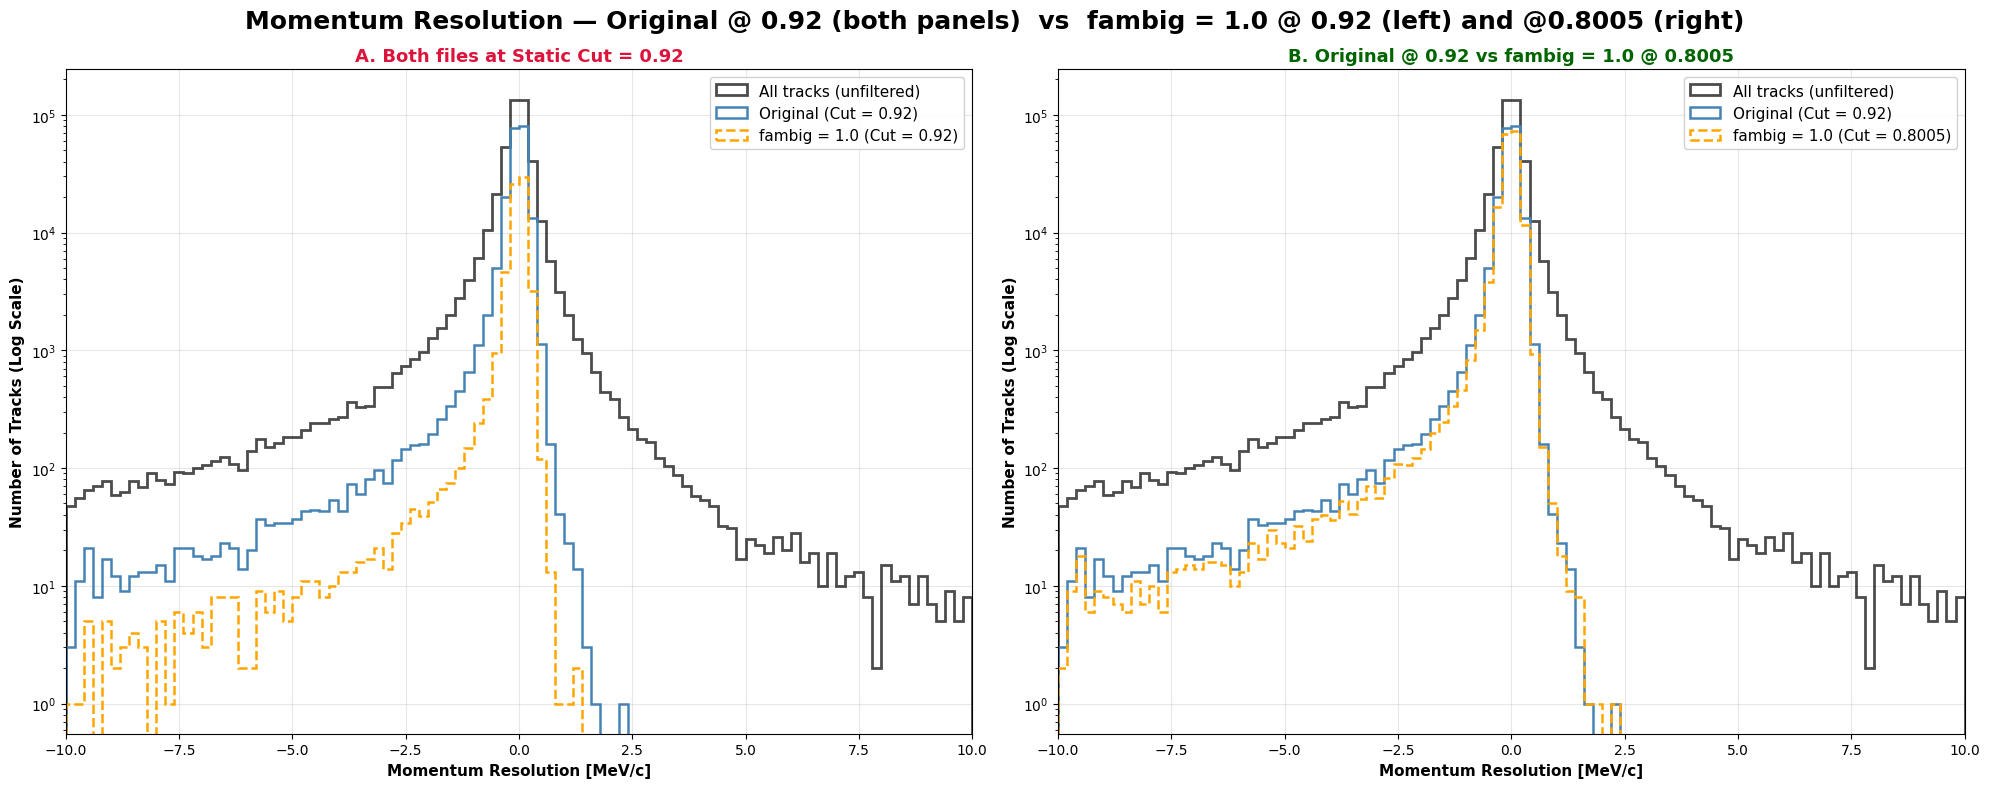

In [ ]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# CONFIG
# =====================================================================
SCENARIO    = "fambig"        # "fambig" | "momerr" | "both"
static_cut  = 0.92            # Original's correct cut (used in BOTH panels)
correct_cut = 0.8005          # Stressed file's correct cut (right panel only)
# =====================================================================

# ---------------------------------------------------------------------
# Resolve perturbed file
# ---------------------------------------------------------------------
def stressed_file(scenario):
    base = training_dataset_filename
    return {
        "fambig": (base.replace('.root', '_fambig_full.root'),
                   "fambig = 1.0", "orange", "--"),
        "momerr": (base.replace('.root', '_momerr_x2.root'),
                   "momerr × 2",   "orange", "--"),
        "both"  : (base.replace('.root', '_fambigFull_momerrX2.root'),
                   "Both stressed", "crimson", "-."),
    }[scenario]

f_stressed, label_stressed, color_stressed, ls_stressed = stressed_file(SCENARIO)

# ---------------------------------------------------------------------
# 1. Load BASELINE arrays
# ---------------------------------------------------------------------
arrays = uproot.open(training_dataset_filename)[training_dataset_treename].arrays(library="np")

nactive     = arrays['trk.nactive']
nhits       = arrays['trk.nhits']
factive     = nactive / nhits
fambig      = arrays['trk.nnullambig'] / nactive
fstraws     = arrays['trk.nmatactive'] / nactive
t0err       = arrays['trk_ent_pars.t0err']
fitcon      = arrays['trk.fitcon']
momerr_raw  = arrays['trk_ent.momerr']

p_reco = (arrays['trk_ent.mom.fCoordinates.fX']**2 +
          arrays['trk_ent.mom.fCoordinates.fY']**2 +
          arrays['trk_ent.mom.fCoordinates.fZ']**2)**0.5
p_true = (arrays['trk_ent_mc.mom.fCoordinates.fX']**2 +
          arrays['trk_ent_mc.mom.fCoordinates.fY']**2 +
          arrays['trk_ent_mc.mom.fCoordinates.fZ']**2)**0.5
mom_res = p_reco - p_true

x_matrix = np.vstack((nactive, factive, t0err, fambig, fitcon,
                      momerr_raw, fstraws)).T
scores_orig = model.predict_proba(x_matrix)[:, 1]

# ---------------------------------------------------------------------
# 2. Load STRESSED arrays
# ---------------------------------------------------------------------
arrays_s = uproot.open(f_stressed)[training_dataset_treename].arrays(library="np")

nactive_s     = arrays_s['trk.nactive']
factive_s     = nactive_s / arrays_s['trk.nhits']
fambig_s      = arrays_s['trk.nnullambig'] / nactive_s
fstraws_s     = arrays_s['trk.nmatactive'] / nactive_s
t0err_s       = arrays_s['trk_ent_pars.t0err']
fitcon_s      = arrays_s['trk.fitcon']
momerr_s      = arrays_s['trk_ent.momerr']

x_stressed = np.vstack((nactive_s, factive_s, t0err_s, fambig_s,
                        fitcon_s, momerr_s, fstraws_s)).T
scores_stressed = model.predict_proba(x_stressed)[:, 1]

# ---------------------------------------------------------------------
# 3. Plot
# ---------------------------------------------------------------------
n_bins = 100
mom_min, mom_max = -10.0, 10.0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle(f"Momentum Resolution — Original @ 0.92 (both panels)  vs  "
             f"{label_stressed} @ 0.92 (left) and @{correct_cut} (right)",
             fontsize=18, fontweight='bold')

# Background (all tracks) on both panels
for ax in [ax1, ax2]:
    ax.hist(mom_res, bins=n_bins, range=(mom_min, mom_max),
            log=True, histtype='step', color='black',
            label='All tracks (unfiltered)', linewidth=2.0, alpha=0.7)

# Original @ static_cut = 0.92 — IDENTICAL in both panels
for ax in [ax1, ax2]:
    ax.hist(mom_res[scores_orig >= static_cut],
            bins=n_bins, range=(mom_min, mom_max),
            log=True, histtype='step', color='steelblue',
            linewidth=1.8,
            label=f'Original (Cut = {static_cut})')

# Left panel — Stressed @ SAME cut as Original (= 0.92)
ax1.hist(mom_res[scores_stressed >= static_cut],
         bins=n_bins, range=(mom_min, mom_max),
         log=True, histtype='step', color=color_stressed, linestyle=ls_stressed,
         linewidth=1.8,
         label=f'{label_stressed} (Cut = {static_cut})')

# Right panel — Stressed @ its OWN correct cut
ax2.hist(mom_res[scores_stressed >= correct_cut],
         bins=n_bins, range=(mom_min, mom_max),
         log=True, histtype='step', color=color_stressed, linestyle=ls_stressed,
         linewidth=1.8,
         label=f'{label_stressed} (Cut = {correct_cut})')

# Format
ax1.set_xlim(mom_min, mom_max)
ax1.set_xlabel("Momentum Resolution [MeV/c]", fontweight='bold', fontsize=11)
ax1.set_ylabel("Number of Tracks (Log Scale)", fontweight='bold', fontsize=11)
ax1.set_title(f"A. Both files at Static Cut = {static_cut}",
              fontsize=13, fontweight='bold', color='crimson')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right', fontsize=11, framealpha=0.9)

ax2.set_xlim(mom_min, mom_max)
ax2.set_xlabel("Momentum Resolution [MeV/c]", fontweight='bold', fontsize=11)
ax2.set_ylabel("Number of Tracks (Log Scale)", fontweight='bold', fontsize=11)
ax2.set_title(f"B. Original @ {static_cut} vs {label_stressed} @ {correct_cut}",
              fontsize=13, fontweight='bold', color='darkgreen')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper right', fontsize=11, framealpha=0.9)

plt.tight_layout()
# plt.savefig(f"mom_resolution_{SCENARIO}.png", dpi=200, bbox_inches='tight')
plt.show()


## Momerr %100

In [ ]:
# =====================================================================
# CONFIG — change this one variable per run
# =====================================================================
# Options:
#   "fambig"        ->  tests  _fambig_full.root
#   "momerr"        ->  tests  _momerr_x2.root
#   "both"          ->  tests  _fambigFull_momerrX2.root
#   "momerr_pm50"   ->  tests both  _momerr_plus50pct.root  AND  _momerr_minus50pct.root

SCENARIO = "momerr" 
# =====================================================================

import numpy as np
from sklearn.metrics import roc_curve, auc

# ---------------------------------------------------------------------
# Map scenario -> file(s)
# ---------------------------------------------------------------------
def files_for(scenario):
    base = training_dataset_filename
    if scenario == "fambig":
        return [("fambig = 1.0",  base.replace('.root', '_fambig_full.root'))]
    if scenario == "momerr":
        return [("momerr × 2",    base.replace('.root', '_momerr_x2.root'))]
    if scenario == "both":
        return [("Both stressed", base.replace('.root', '_fambigFull_momerrX2.root'))]
    if scenario == "momerr_pm50":
        return [("momerr +50%", base.replace('.root', '_momerr_plus50pct.root')),
                ("momerr -50%", base.replace('.root', '_momerr_minus50pct.root'))]
    raise ValueError(f"Unknown scenario: {scenario}")

# ---------------------------------------------------------------------
# Header
# ---------------------------------------------------------------------
print(f"{'Dataset':<22} {'AUC':>8}  {'Sig eff':>10}  {'BDT cut':>9}  "
      f"{'Mean shift':>12}  {'% sig flipped':>14}  {'Δsig':>7}  {'Δbkg':>7}")
print("-" * 110)

# ---------------------------------------------------------------------
# Baseline numbers (computed once)
# ---------------------------------------------------------------------
fpr0, tpr0, thr0 = roc_curve(y_full, y_pred_original_full, pos_label=1)
idx0    = np.where(1 - fpr0 >= 0.99)[0]
cut_idx = idx0[-1] if len(idx0) > 0 else 0
bdt_cut = thr0[cut_idx]
print(f"{'Baseline (orig)':<22} {auc(fpr0,tpr0):>8.4f}  "
      f"{tpr0[cut_idx]*100:>9.2f}%  {bdt_cut:>9.4f}  "
      f"{0.0:>12.6f}  {0.0:>13.2f}%  {0:>7}  {0:>7}")

# ---------------------------------------------------------------------
# Loop over the file(s) for this scenario
# ---------------------------------------------------------------------
for label, fname in files_for(SCENARIO):
    # 1) Get features for this stressed file
    x_new = get_features_from_file(fname)

    # 2) Run original model — no retraining
    y_new = model.predict_proba(x_new)[:, 1]

    # 3) Per-track prediction shift
    delta = y_new - y_pred_original_full

    # 4) ROC + AUC
    fpr, tpr, thr = roc_curve(y_full, y_new, pos_label=1)
    auc_score     = auc(fpr, tpr)

    # 5) Optimal cut at 99% BG rejection
    idx        = np.where(1 - fpr >= 0.99)[0]
    cut_i      = idx[-1] if len(idx) > 0 else 0
    sig_eff    = tpr[cut_i]
    opt_cut    = thr[cut_i]

    # 6) Track flipping at the ORIGINAL cut (bdt_cut)
    pass_orig  = y_pred_original_full >= bdt_cut
    pass_new   = y_new                >= bdt_cut
    flipped    = (pass_orig != pass_new)
    sig_flipped = (flipped & (y_full == 1)).sum()
    bkg_flipped = (flipped & (y_full == 0)).sum()
    pct_sig     = sig_flipped / N_signal * 100.0

    print(f"{label:<22} {auc_score:>8.4f}  {sig_eff*100:>9.2f}%  "
          f"{opt_cut:>9.4f}  {delta.mean():>+12.6f}  "
          f"{pct_sig:>13.2f}%  {sig_flipped:>7}  {bkg_flipped:>7}")


Dataset                     AUC     Sig eff    BDT cut    Mean shift   % sig flipped     Δsig     Δbkg
--------------------------------------------------------------------------------------------------------------
Baseline (orig)          0.9486      57.00%     0.9182      0.000000           0.00%        0        0
momerr × 2               0.9446      54.74%     0.5885     -0.224846          33.82%   102820      120


/var/folders/p0/qdf2tryn1sd4_kf_28ckgz640000gn/T/ipykernel_9192/1931585606.py:183: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


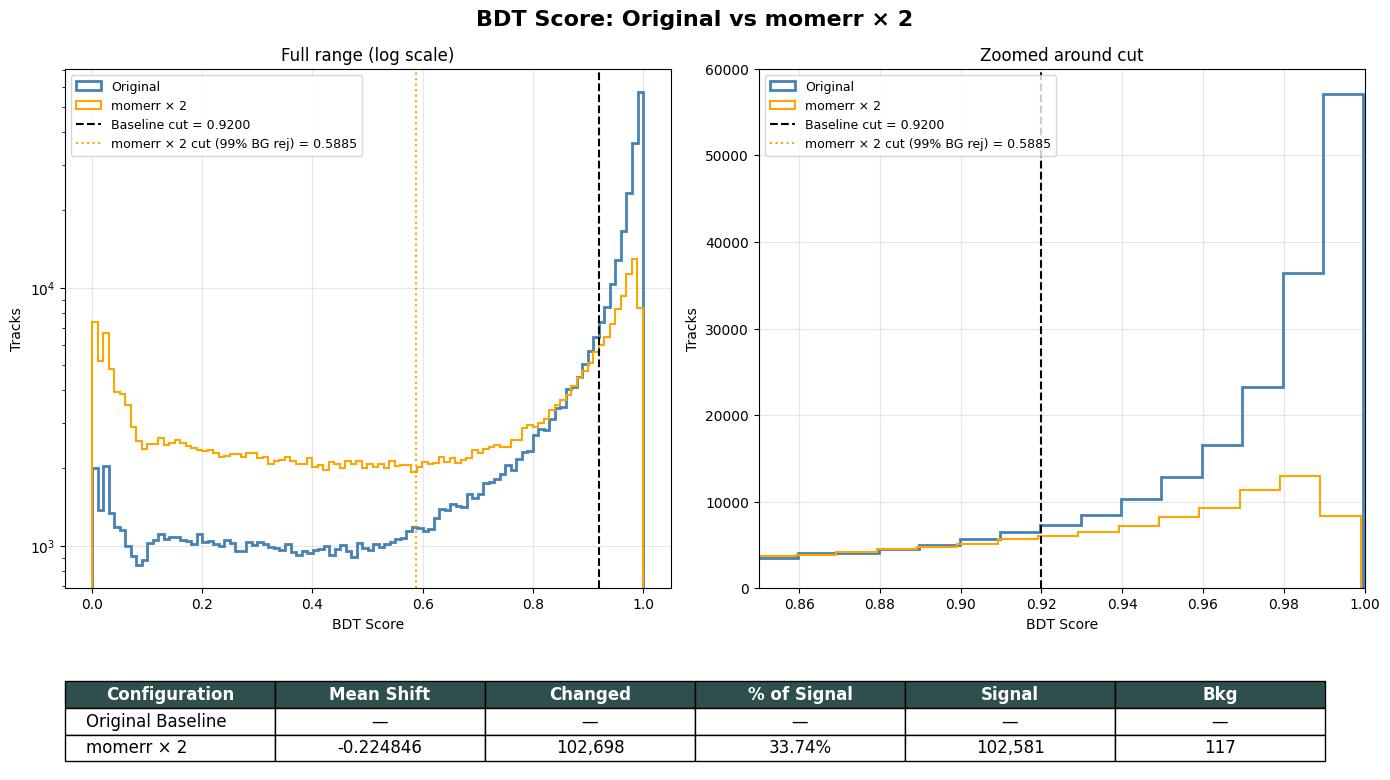

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc

# =====================================================================
# CONFIG — change to "fambig", "momerr", "both", or "momerr_pm50"
# =====================================================================
SCENARIO = "momerr"
# =====================================================================

# ---------------------------------------------------------------------
# Map scenario -> list of (label, color, scores_array)
# (the scores arrays are produced further down — this is just metadata)
# ---------------------------------------------------------------------
def scenario_meta(s):
    if s == "fambig":
        return {
            "title":    "BDT Score: Original vs fambig = 1.0",
            "rows":     [("Original",      "steelblue", 2.0),
                         ("fambig = 1.0",  "orange",    1.5)],
            "ylim":     (0.85, 1.0),
        }
    if s == "momerr":
        return {
            "title":    "BDT Score: Original vs momerr × 2",
            "rows":     [("Original",      "steelblue", 2.0),
                         ("momerr × 2",    "orange",    1.5)],
            "ylim":     (0.85, 1.0),
        }
    if s == "both":
        return {
            "title":    "BDT Score: Original vs Both stressed (fambig=1 & momerr×2)",
            "rows":     [("Original",       "steelblue", 2.0),
                         ("Both stressed",  "orange",    1.5)],
            "ylim":     (0.85, 1.0),
        }
    if s == "momerr_pm50":
        return {
            "title":    "BDT Score: Original vs momerr Heavy Perturbations (±50%)",
            "rows":     [("Original",      "steelblue", 2.0),
                         ("momerr +50%",   "orange",    1.5),
                         ("momerr -50%",   "darkblue",  1.5)],
            "ylim":     (0.85, 1.0),
        }
    raise ValueError(s)

meta = scenario_meta(SCENARIO)

# ---------------------------------------------------------------------
# Resolve filenames for this scenario
# ---------------------------------------------------------------------
def stress_filename(scenario, variant):
    base = training_dataset_filename
    return {
        "fambig_full"      : base.replace('.root', '_fambig_full.root'),
        "momerr_x2"        : base.replace('.root', '_momerr_x2.root'),
        "both"             : base.replace('.root', '_fambigFull_momerrX2.root'),
        "momerr_plus50"    : base.replace('.root', '_momerr_plus50pct.root'),
        "momerr_minus50"   : base.replace('.root', '_momerr_minus50pct.root'),
    }[variant]

# ---------------------------------------------------------------------
# Build the perturbed score arrays for this scenario
# ---------------------------------------------------------------------
def scores_for(scenario):
    if scenario == "fambig":
        x = get_features_from_file(stress_filename(scenario, "fambig_full"))
        return model.predict_proba(x)[:, 1]
    if scenario == "momerr":
        x = get_features_from_file(stress_filename(scenario, "momerr_x2"))
        return model.predict_proba(x)[:, 1]
    if scenario == "both":
        x = get_features_from_file(stress_filename(scenario, "both"))
        return model.predict_proba(x)[:, 1]
    if scenario == "momerr_pm50":
        x_up   = get_features_from_file(stress_filename(scenario, "momerr_plus50"))
        x_down = get_features_from_file(stress_filename(scenario, "momerr_minus50"))
        return model.predict_proba(x_up)[:, 1], model.predict_proba(x_down)[:, 1]

if SCENARIO == "momerr_pm50":
    y_new_up, y_new_down = scores_for(SCENARIO)
    perturbed = {
        "momerr +50%" : y_new_up,
        "momerr -50%" : y_new_down,
    }
else:
    y_new = scores_for(SCENARIO)
    perturbed = {meta["rows"][1][0]: y_new}

# ---------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))
fig.suptitle(meta["title"], fontsize=16, fontweight='bold')

# Build the dataset list (always include Original at front)
datasets = [(y_pred_original_full, "Original", "steelblue", 2.0)]
for label, color, lw in meta["rows"][1:]:
    datasets.append((perturbed[label], label, color, lw))

for ax, panel_title, xlim in zip(
        axes,
        ["Full range (log scale)", "Zoomed around cut"],
        [None, meta["ylim"]]):

    for scores, label, color, lw in datasets:
        ax.hist(scores, bins=100, histtype="step",
                linewidth=lw, color=color, label=label)

    # ----- BASELINE cut (black dashed) -----
    ax.axvline(trkqual_cut, color='black', linestyle='--', linewidth=1.5,
               label=f'Baseline cut = {trkqual_cut:.4f}')

    # ----- CORRECTED cut per dataset at 99% BG rejection -----
    # solid thin vertical line for each perturbed file
    palette = {"Original": "steelblue"}
    for i, (label, color, _) in enumerate(meta["rows"][1:]):
        scores = perturbed[label]
        fpr, tpr, thr = roc_curve(y_full, scores, pos_label=1)
        idx = np.where(1 - fpr >= 0.99)[0]
        if len(idx) > 0:
            ci   = idx[-1]
            cut  = thr[ci]
            ax.axvline(cut, color=color, linestyle=':', linewidth=1.5,
                       label=f'{label} cut (99% BG rej) = {cut:.4f}')

    ax.set_xlabel("BDT Score")
    ax.set_ylabel("Tracks")
    ax.set_title(panel_title)
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(alpha=0.3)
    if xlim:
        ax.set_xlim(xlim)
    else:
        ax.set_yscale('log')

# ---------------------------------------------------------------------
# Build summary table
# ---------------------------------------------------------------------
N_signal = (y_full == 1).sum()
bdt_pass_orig = y_pred_original_full >= trkqual_cut

table_data  = [["Original Baseline", "—", "—", "—", "—", "—"]]
columns     = ["Configuration", "Mean Shift", "Changed", "% of Signal", "Signal", "Bkg"]

for label, color, _ in meta["rows"][1:]:
    y_new       = perturbed[label]
    delta       = y_new - y_pred_original_full
    bdt_pass    = y_new >= trkqual_cut
    changed     = (bdt_pass_orig != bdt_pass).sum()
    sig_changed = ((bdt_pass_orig != bdt_pass) & (y_full == 1)).sum()
    bkg_changed = ((bdt_pass_orig != bdt_pass) & (y_full == 0)).sum()
    table_data.append([
        label,
        f"{delta.mean():+.6f}",
        f"{changed:,}",
        f"{sig_changed/N_signal*100:.2f}%",
        f"{sig_changed:,}",
        f"{bkg_changed:,}",
    ])

# ---------------------------------------------------------------------
# Render the table below the plots
# ---------------------------------------------------------------------
n_rows = len(table_data) + 1
table_ax = fig.add_axes([0.05, -0.04 - 0.05*n_rows, 0.9, 0.05*n_rows])
table_ax.axis('off')

summary_table = table_ax.table(cellText=table_data, colLabels=columns,
                               loc='center', cellLoc='center')
summary_table.auto_set_font_size(False)
summary_table.set_fontsize(12)
summary_table.scale(1.0, 1.6)

for (row, col), cell in summary_table.get_celld().items():
    if col == 0 and row > 0:
        cell.set_text_props(ha='left')
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#2f4f4f')

plt.subplots_adjust(bottom=0.18 + 0.05*n_rows)
plt.tight_layout()
plt.show()


/var/folders/p0/qdf2tryn1sd4_kf_28ckgz640000gn/T/ipykernel_9192/1973876278.py:158: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.94])


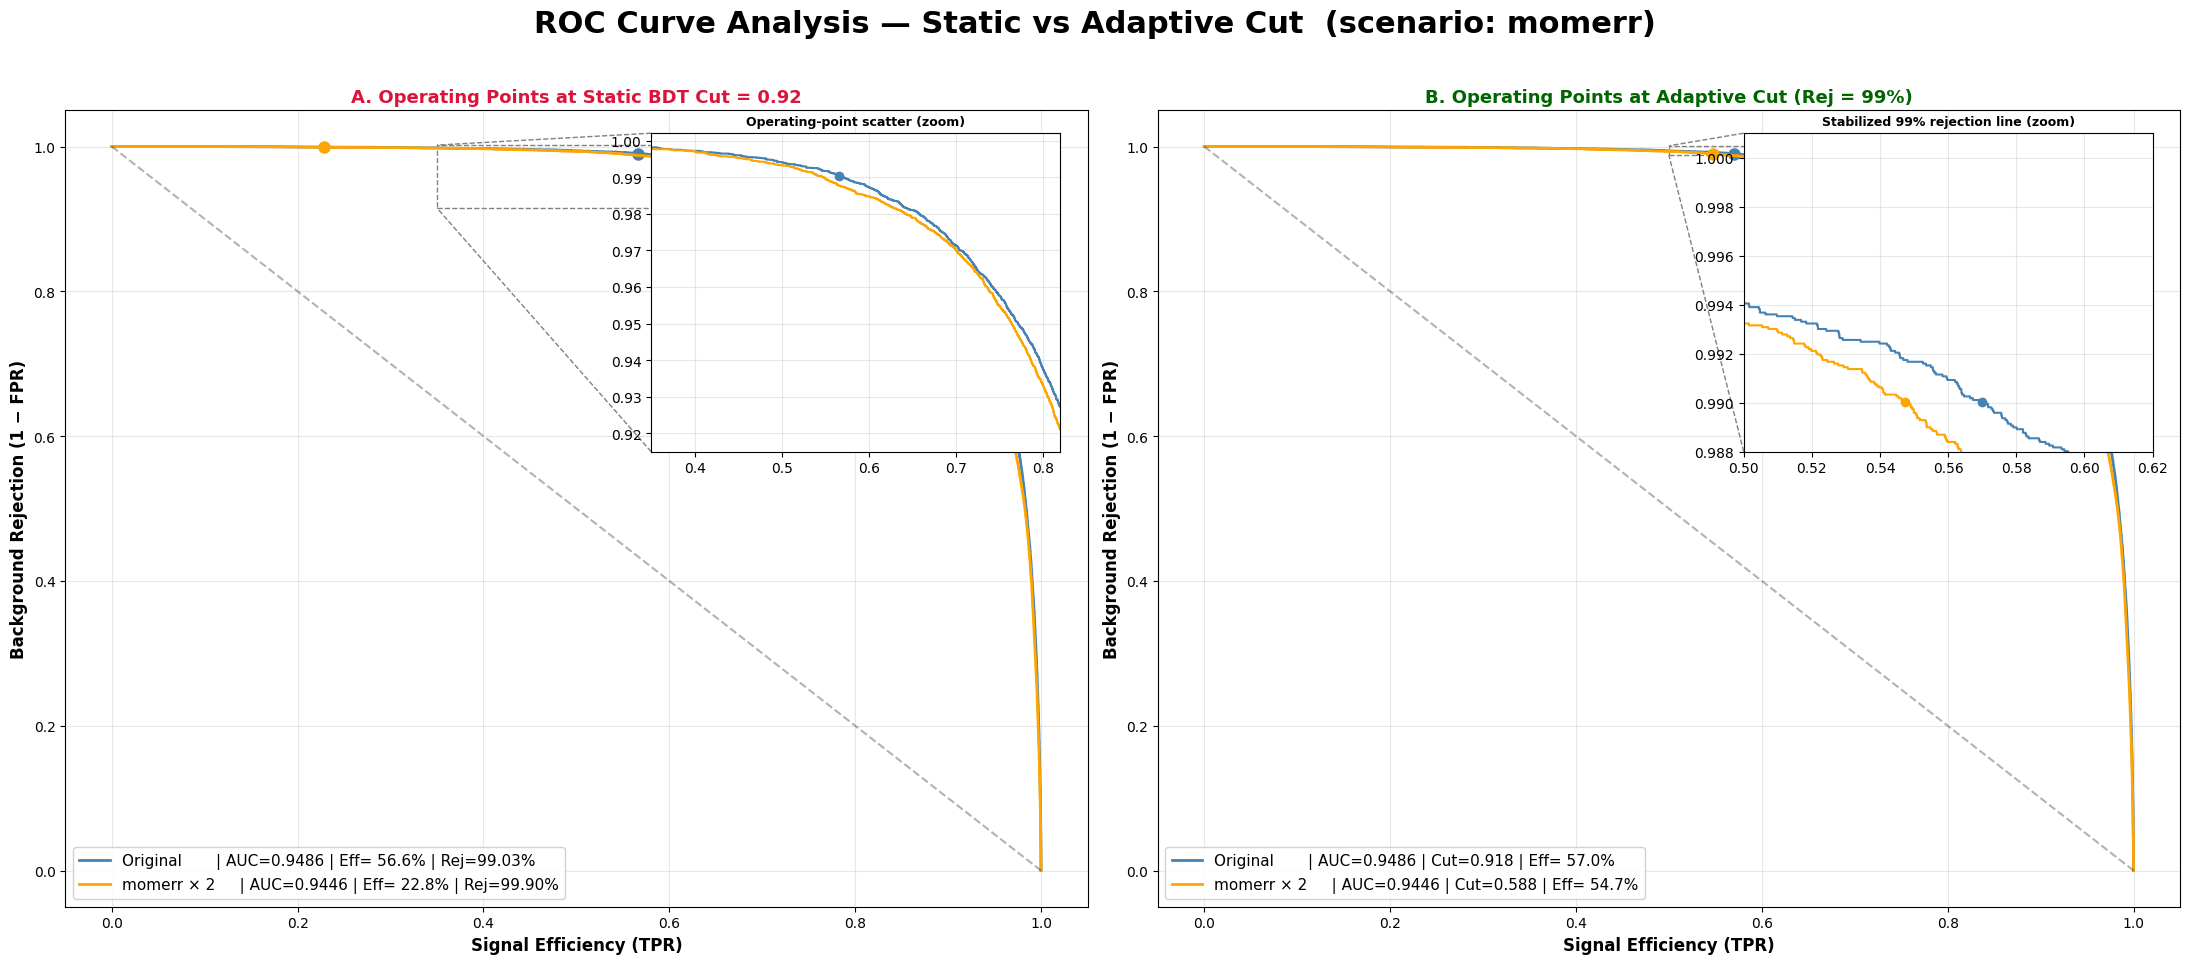

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# =====================================================================
# CONFIG — change this to switch scenarios
# =====================================================================
# Options:
#   "fambig"   ->  just fambig = 1.0
#   "momerr"   ->  just momerr × 2
#   "both"     ->  combined fambig=1 + momerr×2
#   "all"      ->  momerr ±10%, ±50%, fambig=1, combined, original
# =====================================================================
SCENARIO = "momerr"
# =====================================================================

# ---------------------------------------------------------------------
# Map scenario -> list of (filename, label, color)
# ---------------------------------------------------------------------
def datasets_for(scenario):
    base = training_dataset_filename

    common = [
        (base, "Original", "steelblue"),
    ]
    perturbed = {
        "fambig" : [(base.replace('.root', '_fambig_full.root'),
                     "fambig = 1.0", "orange")],
        "momerr" : [(base.replace('.root', '_momerr_x2.root'),
                     "momerr × 2", "orange")],
        "both"   : [(base.replace('.root', '_fambigFull_momerrX2.root'),
                     "Both stressed", "orange")],
        "all"    : [
            (base.replace('.root', '_momerr_plus10pct.root'),
             "momerr +10%", "tomato"),
            (base.replace('.root', '_momerr_minus10pct.root'),
             "momerr -10%", "limegreen"),
            (base.replace('.root', '_momerr_plus50pct.root'),
             "momerr +50%", "orange"),
            (base.replace('.root', '_momerr_minus50pct.root'),
             "momerr -50%", "darkblue"),
            (base.replace('.root', '_fambig_full.root'),
             "fambig = 1.0", "purple"),
            (base.replace('.root', '_fambigFull_momerrX2.root'),
             "Both stressed", "crimson"),
        ],
    }
    return common + perturbed[scenario]

dataset_meta = datasets_for(SCENARIO)

# ---------------------------------------------------------------------
# Load / compute (score, label) for each entry
# ---------------------------------------------------------------------
def load_scores(fname):
    x = get_features_from_file(fname)
    return model.predict_proba(x)[:, 1]

datasets_roc = []
for fname, label, color in dataset_meta:
    scores = (y_pred_original_full if fname == training_dataset_filename
              else load_scores(fname))
    datasets_roc.append((scores, y_full, label, color))

# ---------------------------------------------------------------------
# Plot parameters
# ---------------------------------------------------------------------
static_cut_target = 0.92
rej_target        = 0.99

# ---------------------------------------------------------------------
# Initialize side-by-side subplots
# ---------------------------------------------------------------------
n_panels = len(datasets_roc)
fig_w = max(22, 14 + 1.5 * (n_panels - 4))   # wider if many panels
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(fig_w, 10))
fig.suptitle(f"ROC Curve Analysis — Static vs Adaptive Cut  "
             f"(scenario: {SCENARIO})",
             fontsize=22, fontweight='bold', y=0.96)

ax_ins1 = inset_axes(ax1, width="40%", height="40%", loc='upper right',
                     bbox_to_anchor=(-0.02, -0.02, 1, 1),
                     bbox_transform=ax1.transAxes)
ax_ins2 = inset_axes(ax2, width="40%", height="40%", loc='upper right',
                     bbox_to_anchor=(-0.02, -0.02, 1, 1),
                     bbox_transform=ax2.transAxes)

# ---------------------------------------------------------------------
# Loop over datasets
# ---------------------------------------------------------------------
for scores, labels, name, color in datasets_roc:
    fpr, tpr, thresholds = roc_curve(labels, scores, pos_label=1)
    auc_score = auc(fpr, tpr)

    # ---- LEFT PANEL: STATIC CUT ----
    idx_static = np.where(thresholds >= static_cut_target)[0]
    idx_s = idx_static[-1] if len(idx_static) > 0 else 0
    sig_eff_s = float(tpr[idx_s])
    bkg_rej_s = float(1 - fpr[idx_s])

    ax1.plot(tpr, 1 - fpr, color=color, linewidth=2,
             label=f"{name:<14} | AUC={auc_score:.4f} | "
                   f"Eff={sig_eff_s*100:5.1f}% | "
                   f"Rej={bkg_rej_s*100:5.2f}%")
    ax1.plot(tpr[idx_s], 1 - fpr[idx_s], 'o', color=color, markersize=8)
    ax_ins1.plot(tpr, 1 - fpr, color=color, linewidth=1.5)
    ax_ins1.plot(tpr[idx_s], 1 - fpr[idx_s], 'o', color=color, markersize=6)

    # ---- RIGHT PANEL: ADAPTIVE CUT ----
    idx_dyn = np.where(1 - fpr >= rej_target)[0]
    idx_d = idx_dyn[-1] if len(idx_dyn) > 0 else 0
    sig_eff_d = float(tpr[idx_d])
    opt_cut   = float(thresholds[idx_d])

    ax2.plot(tpr, 1 - fpr, color=color, linewidth=2,
             label=f"{name:<14} | AUC={auc_score:.4f} | "
                   f"Cut={opt_cut:.3f} | "
                   f"Eff={sig_eff_d*100:5.1f}%")
    ax2.plot(tpr[idx_d], 1 - fpr[idx_d], 'o', color=color, markersize=8)
    ax_ins2.plot(tpr, 1 - fpr, color=color, linewidth=1.5)
    ax_ins2.plot(tpr[idx_d], 1 - fpr[idx_d], 'o', color=color, markersize=6)

# ---------------------------------------------------------------------
# Format LEFT subplot
# ---------------------------------------------------------------------
ax1.plot([0, 1], [1, 0], 'k--', alpha=0.3)
ax1.set_xlabel("Signal Efficiency (TPR)", fontsize=12, fontweight='bold')
ax1.set_ylabel("Background Rejection (1 − FPR)", fontsize=12, fontweight='bold')
ax1.set_title(f"A. Operating Points at Static BDT Cut = {static_cut_target:.2f}",
              fontsize=13, fontweight='bold', color='crimson')
ax1.grid(alpha=0.3)
ax1.legend(loc='lower left', fontsize=11, framealpha=0.9)

ax_ins1.set_xlim(0.35, 0.82)
ax_ins1.set_ylim(0.915, 1.002)
ax_ins1.set_title("Operating-point scatter (zoom)", fontsize=9, fontweight='bold')
ax_ins1.grid(alpha=0.3)
mark_inset(ax1, ax_ins1, loc1=2, loc2=3, fc="none", ec="0.5", ls="--")

# ---------------------------------------------------------------------
# Format RIGHT subplot
# ---------------------------------------------------------------------
ax2.plot([0, 1], [1, 0], 'k--', alpha=0.3)
ax2.set_xlabel("Signal Efficiency (TPR)", fontsize=12, fontweight='bold')
ax2.set_ylabel("Background Rejection (1 − FPR)", fontsize=12, fontweight='bold')
ax2.set_title(f"B. Operating Points at Adaptive Cut (Rej = {rej_target*100:.0f}%)",
              fontsize=13, fontweight='bold', color='darkgreen')
ax2.grid(alpha=0.3)
ax2.legend(loc='lower left', fontsize=11, framealpha=0.9)

ax_ins2.set_xlim(0.50, 0.62)
ax_ins2.set_ylim(0.988, 1.001)
ax_ins2.set_title("Stabilized 99% rejection line (zoom)", fontsize=9, fontweight='bold')
ax_ins2.grid(alpha=0.3)
mark_inset(ax2, ax_ins2, loc1=2, loc2=3, fc="none", ec="0.5", ls="--")

plt.tight_layout(rect=[0, 0, 1, 0.94])
# plt.savefig(f"roc_robustness_{SCENARIO}.png", dpi=200, bbox_inches='tight")
plt.show()


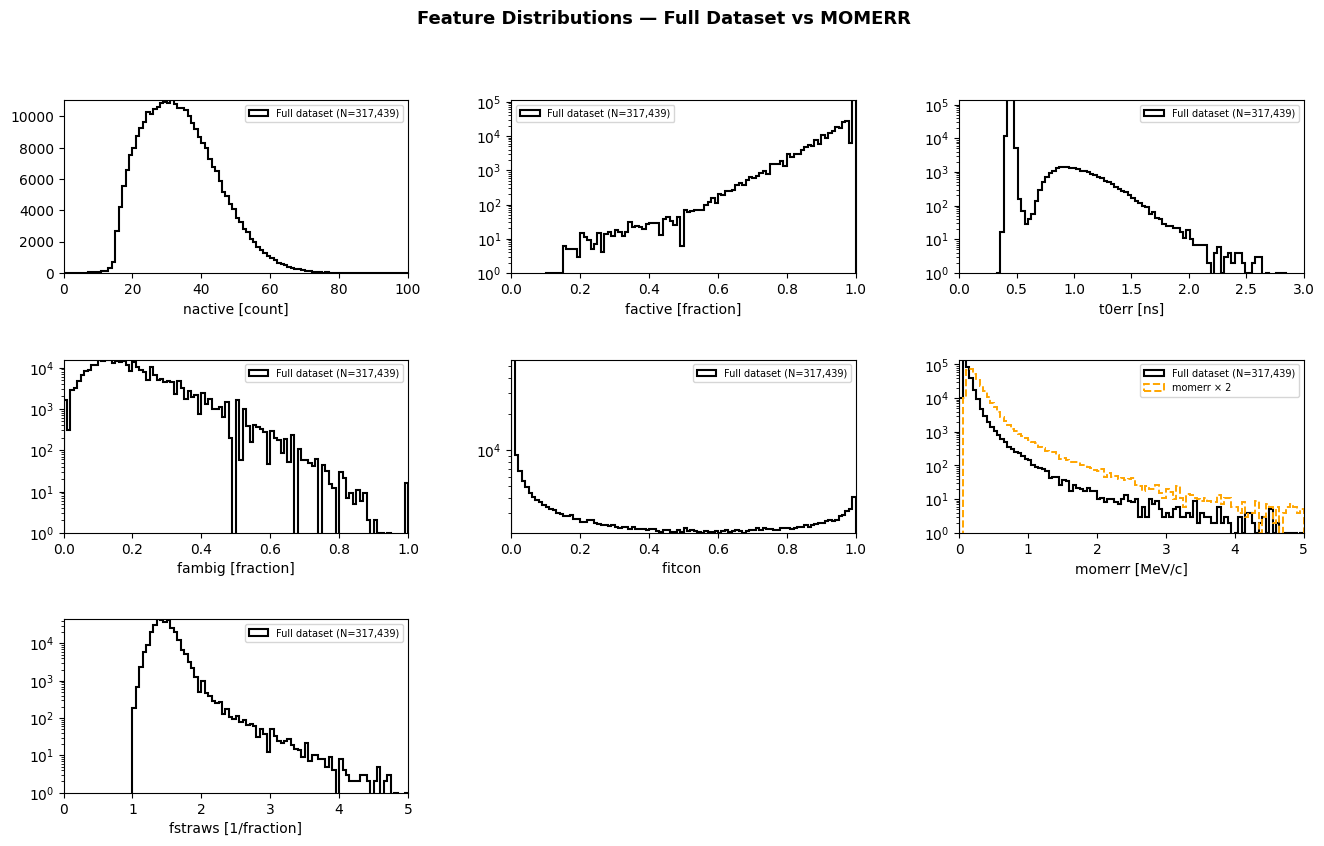

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# =====================================================================
# CONFIG — pick the scenario to overlay
# =====================================================================
# Options:
#   "fambig"  -> overlay  _fambig_full.root
#   "momerr"  -> overlay  _momerr_x2.root
#   "both"    -> overlay  _fambigFull_momerrX2.root
# =====================================================================
SCENARIO = "momerr"
# =====================================================================

# ---------------------------------------------------------------------
# Resolve file(s) and color/style for the scenario
# ---------------------------------------------------------------------
def perturbed_files(scenario):
    base = training_dataset_filename
    if scenario == "fambig":
        return [(base.replace('.root', '_fambig_full.root'),
                 "fambig = 1.0", "orange", "--")]
    if scenario == "momerr":
        return [(base.replace('.root', '_momerr_x2.root'),
                 "momerr × 2", "orange", "--")]
    if scenario == "both":
        return [(base.replace('.root', '_fambigFull_momerrX2.root'),
                 "Both stressed", "orange", "--")]
    raise ValueError(scenario)

perturbed = perturbed_files(SCENARIO)

# ---------------------------------------------------------------------
# Load feature arrays for the perturbed file
# ---------------------------------------------------------------------
x_perturbed = {}
for fname, label, color, ls in perturbed:
    x_perturbed[label] = get_features_from_file(fname)

# ---------------------------------------------------------------------
# Figure setup
# ---------------------------------------------------------------------
n_input_vars = len(input_var_names)
n_rows, n_cols = 3, 3
fig, axs = plt.subplots(n_rows, n_cols, figsize=(16, 9))
fig.subplots_adjust(hspace=0.5, wspace=0.3)

title_str = "Feature Distributions — Full Dataset vs " + SCENARIO.upper()
fig.suptitle(title_str, fontsize=13, fontweight='bold')

# ---------------------------------------------------------------------
# Loop over all input variables
# ---------------------------------------------------------------------
for i_var in range(n_input_vars):
    ax = axs.flatten()[i_var]

    # Baseline distribution
    ax.hist(x_full[:, i_var], bins=100,
            range=(x_mins[i_var], x_maxs[i_var]),
            histtype='step', color='black',
            log=log_ys[i_var],
            label=f'Full dataset (N={len(x_full):,})',
            linewidth=1.5)

    # Overlay the perturbed file
    for fname, label, color, ls in perturbed:
        x_arr = x_perturbed[label]
        # Skip if the feature is unchanged in this perturbation
        if np.array_equal(x_arr[:, i_var], x_full[:, i_var]):
            continue
        ax.hist(x_arr[:, i_var], bins=100,
                range=(x_mins[i_var], x_maxs[i_var]),
                histtype='step', color=color, ls=ls,
                log=log_ys[i_var],
                label=label, linewidth=1.4)

    ax.set_xlabel(input_var_names[i_var] + " " + units[i_var])
    ax.margins(0)
    ax.legend(fontsize=7, loc='best')

# Hide unused axes if n_input_vars < 9
for j in range(n_input_vars, n_rows * n_cols):
    axs.flatten()[j].axis('off')

# plt.savefig(f"feature_distributions_{SCENARIO}.png", dpi=150, bbox_inches='tight")
plt.show()


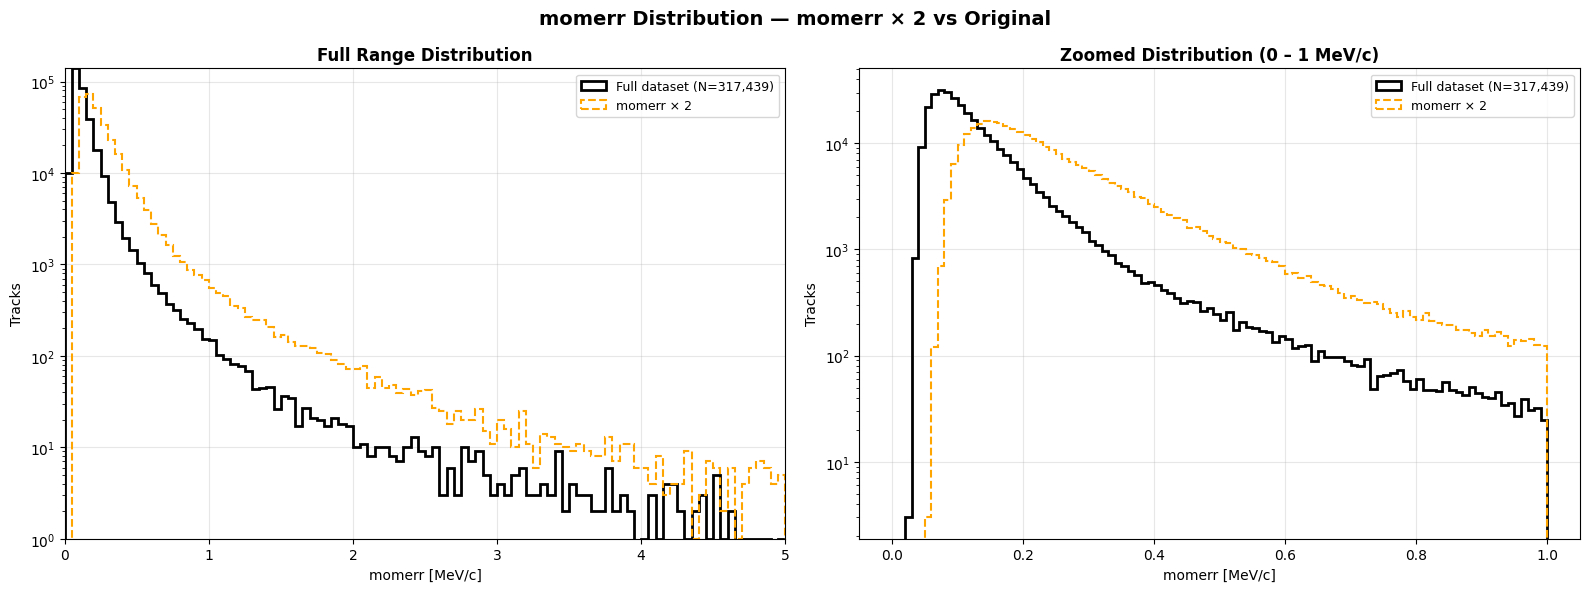

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# =====================================================================
# CONFIG
# =====================================================================
SCENARIO = "momerr"          # "momerr" | "fambig" | "both"
FEATURE  = "momerr"          # feature name in input_var_names
# =====================================================================

# ---------------------------------------------------------------------
# Map scenario -> file
# ---------------------------------------------------------------------
def stressed_file(scenario):
    base = training_dataset_filename
    return {
        "momerr": (base.replace('.root', '_momerr_x2.root'),
                   "momerr × 2", "orange"),
        "fambig": (base.replace('.root', '_fambig_full.root'),
                   "fambig = 1.0", "orange"),
        "both"  : (base.replace('.root', '_fambigFull_momerrX2.root'),
                   "Both stressed", "orange"),
    }[scenario]

f_stressed, label_stressed, color_stressed = stressed_file(SCENARIO)

# ---------------------------------------------------------------------
# Resolve feature index + load arrays
# ---------------------------------------------------------------------
i = input_var_names.index(FEATURE)

x_full    = get_features_from_file(training_dataset_filename)
x_stressed = get_features_from_file(f_stressed)

# ---------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

plot_params = [
    (x_full[:, i],    'black',       f'Full dataset (N={len(x_full):,})', '-',  2.0),
    (x_stressed[:, i], color_stressed, label_stressed,                   '--', 1.5),
]

for ax in [ax1, ax2]:
    for data, color, label, style, lw in plot_params:
        ax.hist(data, bins=100,
                range=(x_mins[i], x_maxs[i]) if ax == ax1 else (0, 1.0),
                histtype='step', color=color, log=True,
                label=label, linestyle=style, linewidth=lw)
    ax.set_ylabel("Tracks")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

ax1.set_title("Full Range Distribution", fontweight='bold')
ax1.set_xlabel(f"{input_var_names[i]} {units[i]}")
ax1.margins(0)

ax2.set_title("Zoomed Distribution (0 – 1 MeV/c)", fontweight='bold')
ax2.set_xlabel(f"{FEATURE} [MeV/c]")

fig.suptitle(f"{FEATURE} Distribution — {label_stressed} vs Original",
             fontsize=14, fontweight='bold')

plt.tight_layout()
# plt.savefig(f"{FEATURE}_{SCENARIO}.png", dpi=150, bbox_inches='tight')
plt.show()

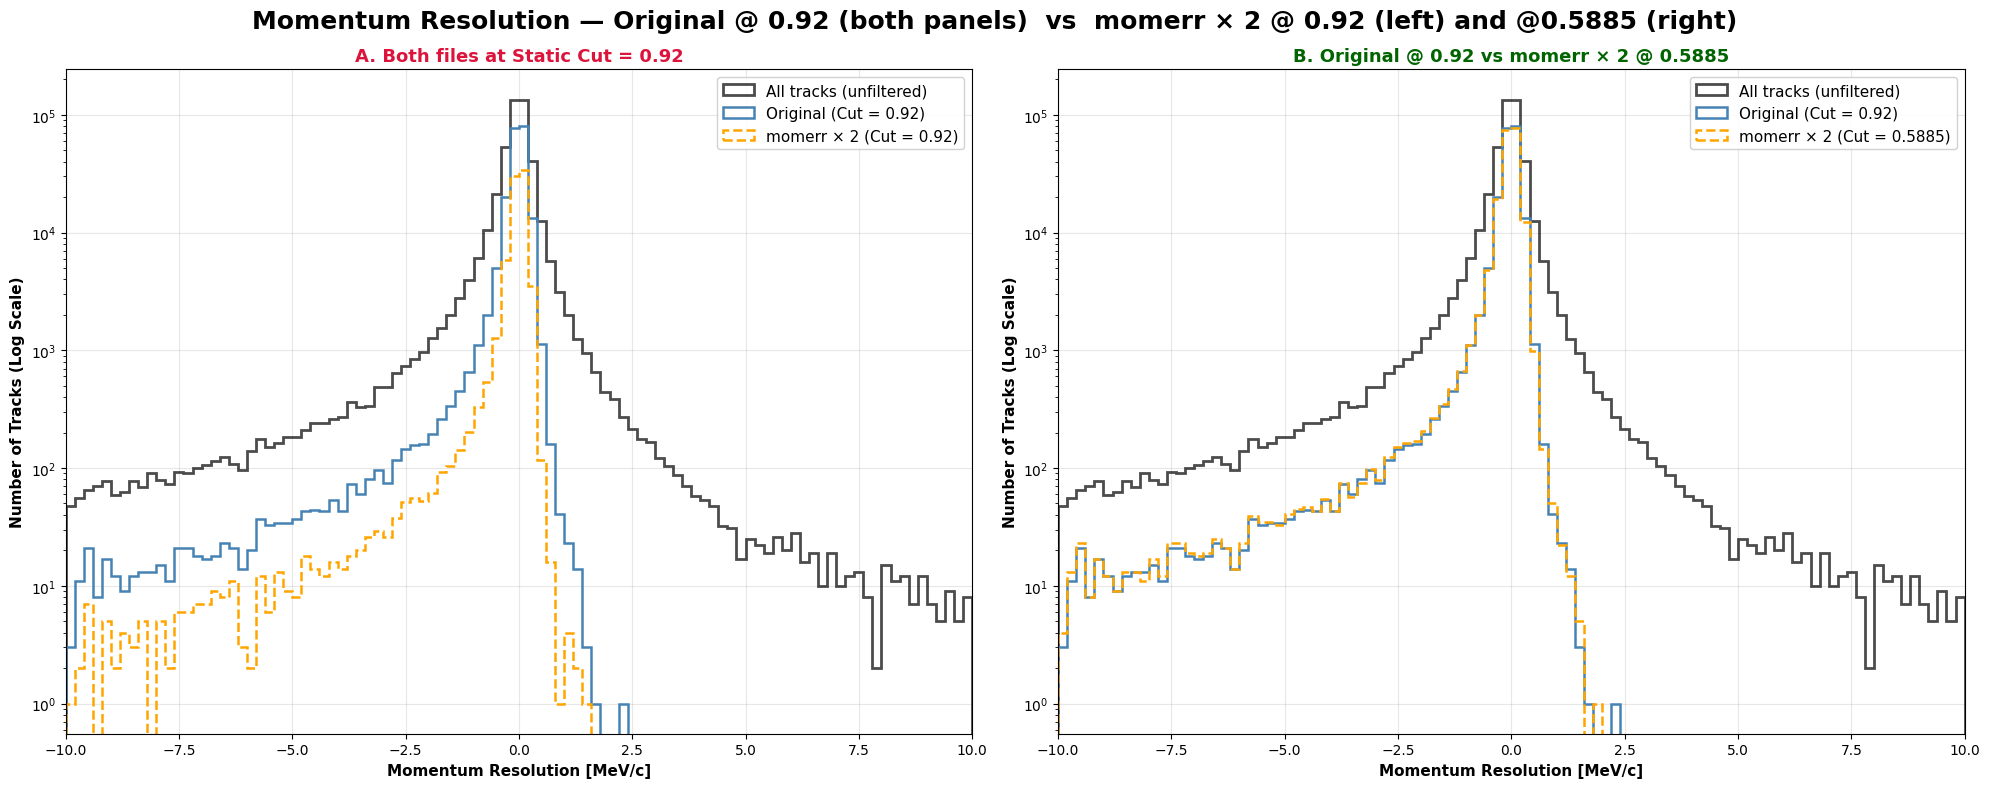

In [ ]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# CONFIG
# =====================================================================
SCENARIO    = "momerr"        # "fambig" | "momerr" | "both"
static_cut  = 0.92            # Original's correct cut (used in BOTH panels)
correct_cut = 0.5885          # Stressed file's correct cut (right panel only)
# =====================================================================

# ---------------------------------------------------------------------
# Resolve perturbed file
# ---------------------------------------------------------------------
def stressed_file(scenario):
    base = training_dataset_filename
    return {
        "fambig": (base.replace('.root', '_fambig_full.root'),
                   "fambig = 1.0", "orange", "--"),
        "momerr": (base.replace('.root', '_momerr_x2.root'),
                   "momerr × 2",   "orange", "--"),
        "both"  : (base.replace('.root', '_fambigFull_momerrX2.root'),
                   "Both stressed", "crimson", "-."),
    }[scenario]

f_stressed, label_stressed, color_stressed, ls_stressed = stressed_file(SCENARIO)

# ---------------------------------------------------------------------
# 1. Load BASELINE arrays
# ---------------------------------------------------------------------
arrays = uproot.open(training_dataset_filename)[training_dataset_treename].arrays(library="np")

nactive     = arrays['trk.nactive']
nhits       = arrays['trk.nhits']
factive     = nactive / nhits
fambig      = arrays['trk.nnullambig'] / nactive
fstraws     = arrays['trk.nmatactive'] / nactive
t0err       = arrays['trk_ent_pars.t0err']
fitcon      = arrays['trk.fitcon']
momerr_raw  = arrays['trk_ent.momerr']

p_reco = (arrays['trk_ent.mom.fCoordinates.fX']**2 +
          arrays['trk_ent.mom.fCoordinates.fY']**2 +
          arrays['trk_ent.mom.fCoordinates.fZ']**2)**0.5
p_true = (arrays['trk_ent_mc.mom.fCoordinates.fX']**2 +
          arrays['trk_ent_mc.mom.fCoordinates.fY']**2 +
          arrays['trk_ent_mc.mom.fCoordinates.fZ']**2)**0.5
mom_res = p_reco - p_true

x_matrix = np.vstack((nactive, factive, t0err, fambig, fitcon,
                      momerr_raw, fstraws)).T
scores_orig = model.predict_proba(x_matrix)[:, 1]

# ---------------------------------------------------------------------
# 2. Load STRESSED arrays
# ---------------------------------------------------------------------
arrays_s = uproot.open(f_stressed)[training_dataset_treename].arrays(library="np")

nactive_s     = arrays_s['trk.nactive']
factive_s     = nactive_s / arrays_s['trk.nhits']
fambig_s      = arrays_s['trk.nnullambig'] / nactive_s
fstraws_s     = arrays_s['trk.nmatactive'] / nactive_s
t0err_s       = arrays_s['trk_ent_pars.t0err']
fitcon_s      = arrays_s['trk.fitcon']
momerr_s      = arrays_s['trk_ent.momerr']

x_stressed = np.vstack((nactive_s, factive_s, t0err_s, fambig_s,
                        fitcon_s, momerr_s, fstraws_s)).T
scores_stressed = model.predict_proba(x_stressed)[:, 1]

# ---------------------------------------------------------------------
# 3. Plot
# ---------------------------------------------------------------------
n_bins = 100
mom_min, mom_max = -10.0, 10.0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle(f"Momentum Resolution — Original @ 0.92 (both panels)  vs  "
             f"{label_stressed} @ 0.92 (left) and @{correct_cut} (right)",
             fontsize=18, fontweight='bold')

# Background (all tracks) on both panels
for ax in [ax1, ax2]:
    ax.hist(mom_res, bins=n_bins, range=(mom_min, mom_max),
            log=True, histtype='step', color='black',
            label='All tracks (unfiltered)', linewidth=2.0, alpha=0.7)

# Original @ static_cut = 0.92 — IDENTICAL in both panels
for ax in [ax1, ax2]:
    ax.hist(mom_res[scores_orig >= static_cut],
            bins=n_bins, range=(mom_min, mom_max),
            log=True, histtype='step', color='steelblue',
            linewidth=1.8,
            label=f'Original (Cut = {static_cut})')

# Left panel — Stressed @ SAME cut as Original (= 0.92)
ax1.hist(mom_res[scores_stressed >= static_cut],
         bins=n_bins, range=(mom_min, mom_max),
         log=True, histtype='step', color=color_stressed, linestyle=ls_stressed,
         linewidth=1.8,
         label=f'{label_stressed} (Cut = {static_cut})')

# Right panel — Stressed @ its OWN correct cut
ax2.hist(mom_res[scores_stressed >= correct_cut],
         bins=n_bins, range=(mom_min, mom_max),
         log=True, histtype='step', color=color_stressed, linestyle=ls_stressed,
         linewidth=1.8,
         label=f'{label_stressed} (Cut = {correct_cut})')

# Format
ax1.set_xlim(mom_min, mom_max)
ax1.set_xlabel("Momentum Resolution [MeV/c]", fontweight='bold', fontsize=11)
ax1.set_ylabel("Number of Tracks (Log Scale)", fontweight='bold', fontsize=11)
ax1.set_title(f"A. Both files at Static Cut = {static_cut}",
              fontsize=13, fontweight='bold', color='crimson')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right', fontsize=11, framealpha=0.9)

ax2.set_xlim(mom_min, mom_max)
ax2.set_xlabel("Momentum Resolution [MeV/c]", fontweight='bold', fontsize=11)
ax2.set_ylabel("Number of Tracks (Log Scale)", fontweight='bold', fontsize=11)
ax2.set_title(f"B. Original @ {static_cut} vs {label_stressed} @ {correct_cut}",
              fontsize=13, fontweight='bold', color='darkgreen')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper right', fontsize=11, framealpha=0.9)

plt.tight_layout()
# plt.savefig(f"mom_resolution_{SCENARIO}.png", dpi=200, bbox_inches='tight')
plt.show()


## Both Fambig and Momerr Combined 

In [ ]:
# =====================================================================
# CONFIG — change this one variable per run
# =====================================================================
# Options:
#   "fambig"        ->  tests  _fambig_full.root
#   "momerr"        ->  tests  _momerr_x2.root
#   "both"          ->  tests  _fambigFull_momerrX2.root
#   "momerr_pm50"   ->  tests both  _momerr_plus50pct.root  AND  _momerr_minus50pct.root

SCENARIO = "both" 
# =====================================================================

import numpy as np
from sklearn.metrics import roc_curve, auc

# ---------------------------------------------------------------------
# Map scenario -> file(s)
# ---------------------------------------------------------------------
def files_for(scenario):
    base = training_dataset_filename
    if scenario == "fambig":
        return [("fambig = 1.0",  base.replace('.root', '_fambig_full.root'))]
    if scenario == "momerr":
        return [("momerr × 2",    base.replace('.root', '_momerr_x2.root'))]
    if scenario == "both":
        return [("Both stressed", base.replace('.root', '_fambigFull_momerrX2.root'))]
    if scenario == "momerr_pm50":
        return [("momerr +50%", base.replace('.root', '_momerr_plus50pct.root')),
                ("momerr -50%", base.replace('.root', '_momerr_minus50pct.root'))]
    raise ValueError(f"Unknown scenario: {scenario}")

# ---------------------------------------------------------------------
# Header
# ---------------------------------------------------------------------
print(f"{'Dataset':<22} {'AUC':>8}  {'Sig eff':>10}  {'BDT cut':>9}  "
      f"{'Mean shift':>12}  {'% sig flipped':>14}  {'Δsig':>7}  {'Δbkg':>7}")
print("-" * 110)

# ---------------------------------------------------------------------
# Baseline numbers (computed once)
# ---------------------------------------------------------------------
fpr0, tpr0, thr0 = roc_curve(y_full, y_pred_original_full, pos_label=1)
idx0    = np.where(1 - fpr0 >= 0.99)[0]
cut_idx = idx0[-1] if len(idx0) > 0 else 0
bdt_cut = thr0[cut_idx]
print(f"{'Baseline (orig)':<22} {auc(fpr0,tpr0):>8.4f}  "
      f"{tpr0[cut_idx]*100:>9.2f}%  {bdt_cut:>9.4f}  "
      f"{0.0:>12.6f}  {0.0:>13.2f}%  {0:>7}  {0:>7}")

# ---------------------------------------------------------------------
# Loop over the file(s) for this scenario
# ---------------------------------------------------------------------
for label, fname in files_for(SCENARIO):
    # 1) Get features for this stressed file
    x_new = get_features_from_file(fname)

    # 2) Run original model — no retraining
    y_new = model.predict_proba(x_new)[:, 1]

    # 3) Per-track prediction shift
    delta = y_new - y_pred_original_full

    # 4) ROC + AUC
    fpr, tpr, thr = roc_curve(y_full, y_new, pos_label=1)
    auc_score     = auc(fpr, tpr)

    # 5) Optimal cut at 99% BG rejection
    idx        = np.where(1 - fpr >= 0.99)[0]
    cut_i      = idx[-1] if len(idx) > 0 else 0
    sig_eff    = tpr[cut_i]
    opt_cut    = thr[cut_i]

    # 6) Track flipping at the ORIGINAL cut (bdt_cut)
    pass_orig  = y_pred_original_full >= bdt_cut
    pass_new   = y_new                >= bdt_cut
    flipped    = (pass_orig != pass_new)
    sig_flipped = (flipped & (y_full == 1)).sum()
    bkg_flipped = (flipped & (y_full == 0)).sum()
    pct_sig     = sig_flipped / N_signal * 100.0

    print(f"{label:<22} {auc_score:>8.4f}  {sig_eff*100:>9.2f}%  "
          f"{opt_cut:>9.4f}  {delta.mean():>+12.6f}  "
          f"{pct_sig:>13.2f}%  {sig_flipped:>7}  {bkg_flipped:>7}")


Dataset                     AUC     Sig eff    BDT cut    Mean shift   % sig flipped     Δsig     Δbkg
--------------------------------------------------------------------------------------------------------------
Baseline (orig)          0.9486      57.00%     0.9182      0.000000           0.00%        0        0
Both stressed            0.9411      50.20%     0.3311     -0.411779          55.72%   169374      134


/var/folders/p0/qdf2tryn1sd4_kf_28ckgz640000gn/T/ipykernel_9192/1361280114.py:183: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


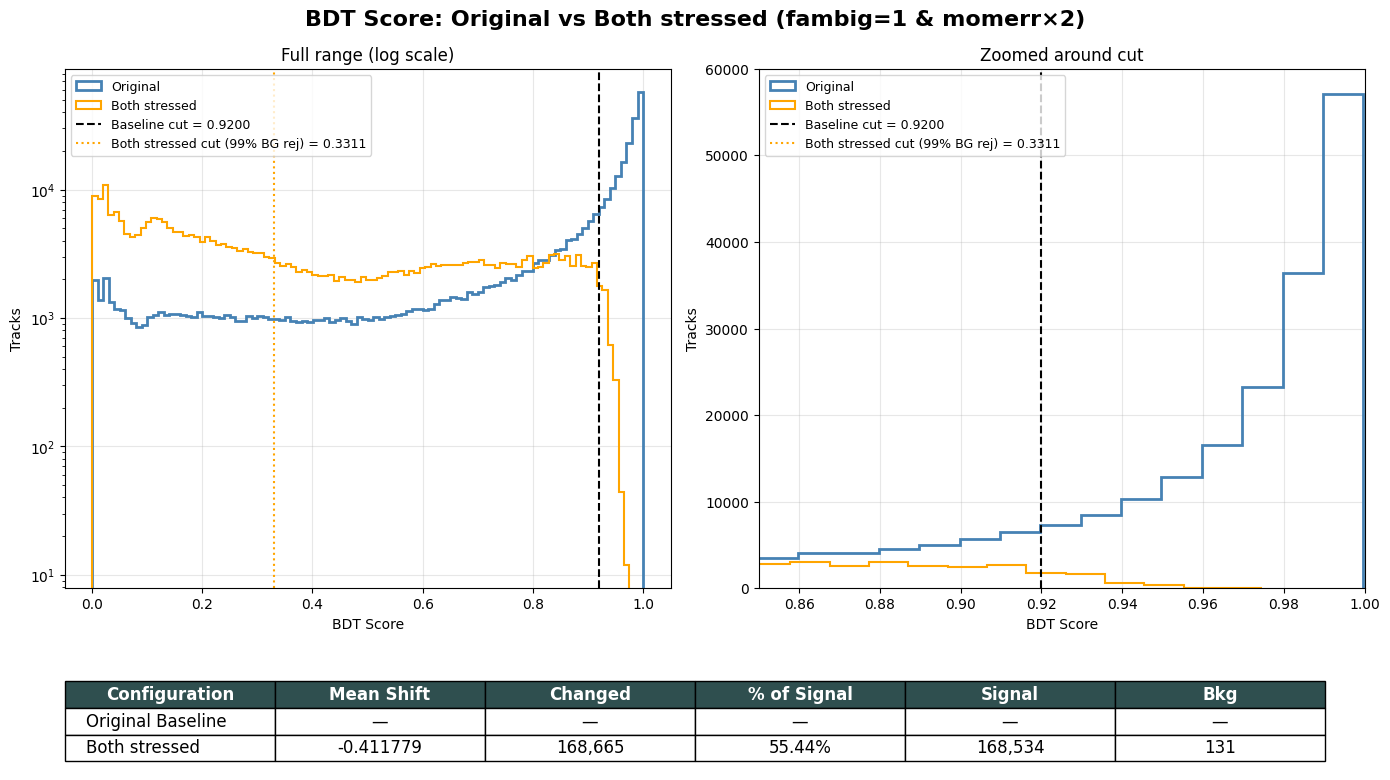

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc

# =====================================================================
# CONFIG — change to "fambig", "momerr", "both", or "momerr_pm50"
# =====================================================================
SCENARIO = "both"
# =====================================================================

# ---------------------------------------------------------------------
# Map scenario -> list of (label, color, scores_array)
# (the scores arrays are produced further down — this is just metadata)
# ---------------------------------------------------------------------
def scenario_meta(s):
    if s == "fambig":
        return {
            "title":    "BDT Score: Original vs fambig = 1.0",
            "rows":     [("Original",      "steelblue", 2.0),
                         ("fambig = 1.0",  "orange",    1.5)],
            "ylim":     (0.85, 1.0),
        }
    if s == "momerr":
        return {
            "title":    "BDT Score: Original vs momerr × 2",
            "rows":     [("Original",      "steelblue", 2.0),
                         ("momerr × 2",    "orange",    1.5)],
            "ylim":     (0.85, 1.0),
        }
    if s == "both":
        return {
            "title":    "BDT Score: Original vs Both stressed (fambig=1 & momerr×2)",
            "rows":     [("Original",       "steelblue", 2.0),
                         ("Both stressed",  "orange",    1.5)],
            "ylim":     (0.85, 1.0),
        }
    if s == "momerr_pm50":
        return {
            "title":    "BDT Score: Original vs momerr Heavy Perturbations (±50%)",
            "rows":     [("Original",      "steelblue", 2.0),
                         ("momerr +50%",   "orange",    1.5),
                         ("momerr -50%",   "darkblue",  1.5)],
            "ylim":     (0.85, 1.0),
        }
    raise ValueError(s)

meta = scenario_meta(SCENARIO)

# ---------------------------------------------------------------------
# Resolve filenames for this scenario
# ---------------------------------------------------------------------
def stress_filename(scenario, variant):
    base = training_dataset_filename
    return {
        "fambig_full"      : base.replace('.root', '_fambig_full.root'),
        "momerr_x2"        : base.replace('.root', '_momerr_x2.root'),
        "both"             : base.replace('.root', '_fambigFull_momerrX2.root'),
        "momerr_plus50"    : base.replace('.root', '_momerr_plus50pct.root'),
        "momerr_minus50"   : base.replace('.root', '_momerr_minus50pct.root'),
    }[variant]

# ---------------------------------------------------------------------
# Build the perturbed score arrays for this scenario
# ---------------------------------------------------------------------
def scores_for(scenario):
    if scenario == "fambig":
        x = get_features_from_file(stress_filename(scenario, "fambig_full"))
        return model.predict_proba(x)[:, 1]
    if scenario == "momerr":
        x = get_features_from_file(stress_filename(scenario, "momerr_x2"))
        return model.predict_proba(x)[:, 1]
    if scenario == "both":
        x = get_features_from_file(stress_filename(scenario, "both"))
        return model.predict_proba(x)[:, 1]
    if scenario == "momerr_pm50":
        x_up   = get_features_from_file(stress_filename(scenario, "momerr_plus50"))
        x_down = get_features_from_file(stress_filename(scenario, "momerr_minus50"))
        return model.predict_proba(x_up)[:, 1], model.predict_proba(x_down)[:, 1]

if SCENARIO == "momerr_pm50":
    y_new_up, y_new_down = scores_for(SCENARIO)
    perturbed = {
        "momerr +50%" : y_new_up,
        "momerr -50%" : y_new_down,
    }
else:
    y_new = scores_for(SCENARIO)
    perturbed = {meta["rows"][1][0]: y_new}

# ---------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))
fig.suptitle(meta["title"], fontsize=16, fontweight='bold')

# Build the dataset list (always include Original at front)
datasets = [(y_pred_original_full, "Original", "steelblue", 2.0)]
for label, color, lw in meta["rows"][1:]:
    datasets.append((perturbed[label], label, color, lw))

for ax, panel_title, xlim in zip(
        axes,
        ["Full range (log scale)", "Zoomed around cut"],
        [None, meta["ylim"]]):

    for scores, label, color, lw in datasets:
        ax.hist(scores, bins=100, histtype="step",
                linewidth=lw, color=color, label=label)

    # ----- BASELINE cut (black dashed) -----
    ax.axvline(trkqual_cut, color='black', linestyle='--', linewidth=1.5,
               label=f'Baseline cut = {trkqual_cut:.4f}')

    # ----- CORRECTED cut per dataset at 99% BG rejection -----
    # solid thin vertical line for each perturbed file
    palette = {"Original": "steelblue"}
    for i, (label, color, _) in enumerate(meta["rows"][1:]):
        scores = perturbed[label]
        fpr, tpr, thr = roc_curve(y_full, scores, pos_label=1)
        idx = np.where(1 - fpr >= 0.99)[0]
        if len(idx) > 0:
            ci   = idx[-1]
            cut  = thr[ci]
            ax.axvline(cut, color=color, linestyle=':', linewidth=1.5,
                       label=f'{label} cut (99% BG rej) = {cut:.4f}')

    ax.set_xlabel("BDT Score")
    ax.set_ylabel("Tracks")
    ax.set_title(panel_title)
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(alpha=0.3)
    if xlim:
        ax.set_xlim(xlim)
    else:
        ax.set_yscale('log')

# ---------------------------------------------------------------------
# Build summary table
# ---------------------------------------------------------------------
N_signal = (y_full == 1).sum()
bdt_pass_orig = y_pred_original_full >= trkqual_cut

table_data  = [["Original Baseline", "—", "—", "—", "—", "—"]]
columns     = ["Configuration", "Mean Shift", "Changed", "% of Signal", "Signal", "Bkg"]

for label, color, _ in meta["rows"][1:]:
    y_new       = perturbed[label]
    delta       = y_new - y_pred_original_full
    bdt_pass    = y_new >= trkqual_cut
    changed     = (bdt_pass_orig != bdt_pass).sum()
    sig_changed = ((bdt_pass_orig != bdt_pass) & (y_full == 1)).sum()
    bkg_changed = ((bdt_pass_orig != bdt_pass) & (y_full == 0)).sum()
    table_data.append([
        label,
        f"{delta.mean():+.6f}",
        f"{changed:,}",
        f"{sig_changed/N_signal*100:.2f}%",
        f"{sig_changed:,}",
        f"{bkg_changed:,}",
    ])

# ---------------------------------------------------------------------
# Render the table below the plots
# ---------------------------------------------------------------------
n_rows = len(table_data) + 1
table_ax = fig.add_axes([0.05, -0.04 - 0.05*n_rows, 0.9, 0.05*n_rows])
table_ax.axis('off')

summary_table = table_ax.table(cellText=table_data, colLabels=columns,
                               loc='center', cellLoc='center')
summary_table.auto_set_font_size(False)
summary_table.set_fontsize(12)
summary_table.scale(1.0, 1.6)

for (row, col), cell in summary_table.get_celld().items():
    if col == 0 and row > 0:
        cell.set_text_props(ha='left')
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#2f4f4f')

plt.subplots_adjust(bottom=0.18 + 0.05*n_rows)
plt.tight_layout()
plt.show()


/var/folders/p0/qdf2tryn1sd4_kf_28ckgz640000gn/T/ipykernel_9192/3095649802.py:158: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.94])


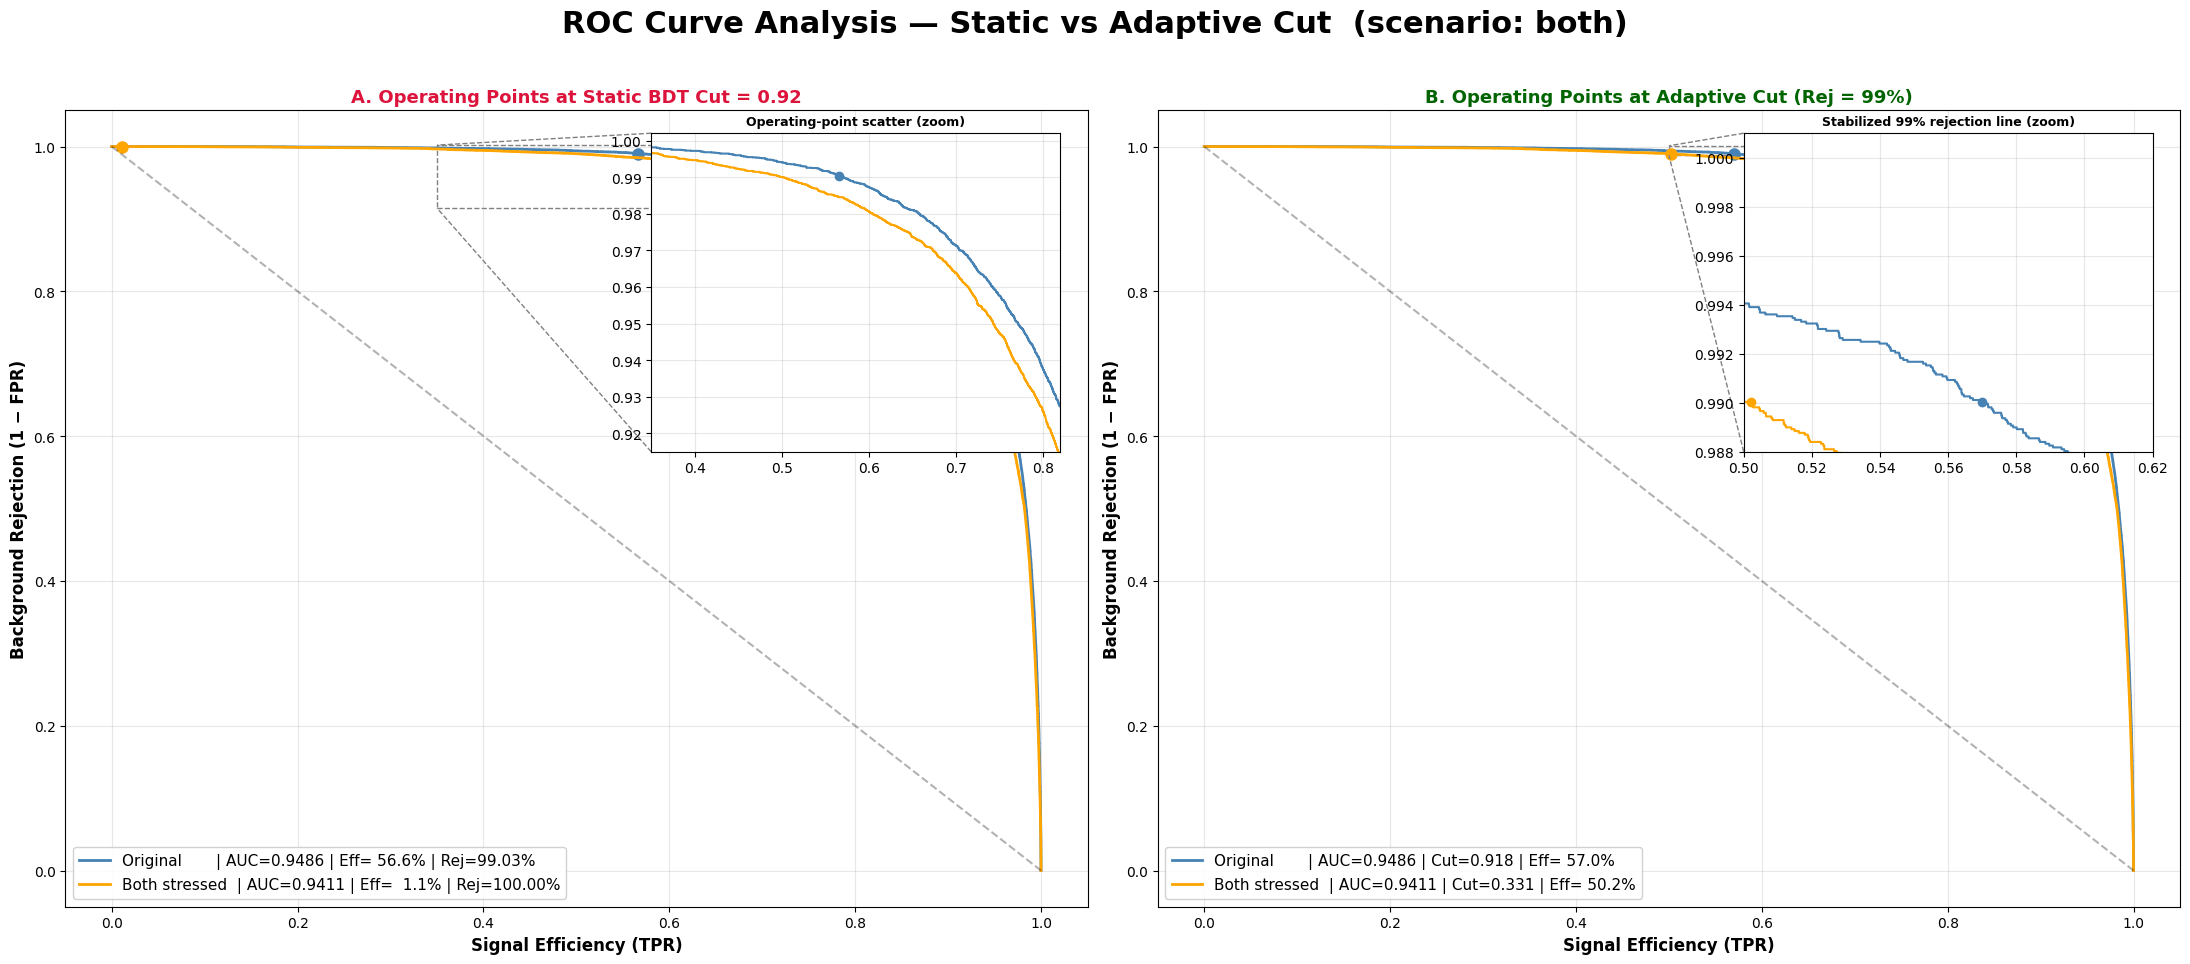

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# =====================================================================
# CONFIG — change this to switch scenarios
# =====================================================================
# Options:
#   "fambig"   ->  just fambig = 1.0
#   "momerr"   ->  just momerr × 2
#   "both"     ->  combined fambig=1 + momerr×2
#   "all"      ->  momerr ±10%, ±50%, fambig=1, combined, original
# =====================================================================
SCENARIO = "both"
# =====================================================================

# ---------------------------------------------------------------------
# Map scenario -> list of (filename, label, color)
# ---------------------------------------------------------------------
def datasets_for(scenario):
    base = training_dataset_filename

    common = [
        (base, "Original", "steelblue"),
    ]
    perturbed = {
        "fambig" : [(base.replace('.root', '_fambig_full.root'),
                     "fambig = 1.0", "orange")],
        "momerr" : [(base.replace('.root', '_momerr_x2.root'),
                     "momerr × 2", "orange")],
        "both"   : [(base.replace('.root', '_fambigFull_momerrX2.root'),
                     "Both stressed", "orange")],
        "all"    : [
            (base.replace('.root', '_momerr_plus10pct.root'),
             "momerr +10%", "tomato"),
            (base.replace('.root', '_momerr_minus10pct.root'),
             "momerr -10%", "limegreen"),
            (base.replace('.root', '_momerr_plus50pct.root'),
             "momerr +50%", "orange"),
            (base.replace('.root', '_momerr_minus50pct.root'),
             "momerr -50%", "darkblue"),
            (base.replace('.root', '_fambig_full.root'),
             "fambig = 1.0", "purple"),
            (base.replace('.root', '_fambigFull_momerrX2.root'),
             "Both stressed", "crimson"),
        ],
    }
    return common + perturbed[scenario]

dataset_meta = datasets_for(SCENARIO)

# ---------------------------------------------------------------------
# Load / compute (score, label) for each entry
# ---------------------------------------------------------------------
def load_scores(fname):
    x = get_features_from_file(fname)
    return model.predict_proba(x)[:, 1]

datasets_roc = []
for fname, label, color in dataset_meta:
    scores = (y_pred_original_full if fname == training_dataset_filename
              else load_scores(fname))
    datasets_roc.append((scores, y_full, label, color))

# ---------------------------------------------------------------------
# Plot parameters
# ---------------------------------------------------------------------
static_cut_target = 0.92
rej_target        = 0.99

# ---------------------------------------------------------------------
# Initialize side-by-side subplots
# ---------------------------------------------------------------------
n_panels = len(datasets_roc)
fig_w = max(22, 14 + 1.5 * (n_panels - 4))   # wider if many panels
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(fig_w, 10))
fig.suptitle(f"ROC Curve Analysis — Static vs Adaptive Cut  "
             f"(scenario: {SCENARIO})",
             fontsize=22, fontweight='bold', y=0.96)

ax_ins1 = inset_axes(ax1, width="40%", height="40%", loc='upper right',
                     bbox_to_anchor=(-0.02, -0.02, 1, 1),
                     bbox_transform=ax1.transAxes)
ax_ins2 = inset_axes(ax2, width="40%", height="40%", loc='upper right',
                     bbox_to_anchor=(-0.02, -0.02, 1, 1),
                     bbox_transform=ax2.transAxes)

# ---------------------------------------------------------------------
# Loop over datasets
# ---------------------------------------------------------------------
for scores, labels, name, color in datasets_roc:
    fpr, tpr, thresholds = roc_curve(labels, scores, pos_label=1)
    auc_score = auc(fpr, tpr)

    # ---- LEFT PANEL: STATIC CUT ----
    idx_static = np.where(thresholds >= static_cut_target)[0]
    idx_s = idx_static[-1] if len(idx_static) > 0 else 0
    sig_eff_s = float(tpr[idx_s])
    bkg_rej_s = float(1 - fpr[idx_s])

    ax1.plot(tpr, 1 - fpr, color=color, linewidth=2,
             label=f"{name:<14} | AUC={auc_score:.4f} | "
                   f"Eff={sig_eff_s*100:5.1f}% | "
                   f"Rej={bkg_rej_s*100:5.2f}%")
    ax1.plot(tpr[idx_s], 1 - fpr[idx_s], 'o', color=color, markersize=8)
    ax_ins1.plot(tpr, 1 - fpr, color=color, linewidth=1.5)
    ax_ins1.plot(tpr[idx_s], 1 - fpr[idx_s], 'o', color=color, markersize=6)

    # ---- RIGHT PANEL: ADAPTIVE CUT ----
    idx_dyn = np.where(1 - fpr >= rej_target)[0]
    idx_d = idx_dyn[-1] if len(idx_dyn) > 0 else 0
    sig_eff_d = float(tpr[idx_d])
    opt_cut   = float(thresholds[idx_d])

    ax2.plot(tpr, 1 - fpr, color=color, linewidth=2,
             label=f"{name:<14} | AUC={auc_score:.4f} | "
                   f"Cut={opt_cut:.3f} | "
                   f"Eff={sig_eff_d*100:5.1f}%")
    ax2.plot(tpr[idx_d], 1 - fpr[idx_d], 'o', color=color, markersize=8)
    ax_ins2.plot(tpr, 1 - fpr, color=color, linewidth=1.5)
    ax_ins2.plot(tpr[idx_d], 1 - fpr[idx_d], 'o', color=color, markersize=6)

# ---------------------------------------------------------------------
# Format LEFT subplot
# ---------------------------------------------------------------------
ax1.plot([0, 1], [1, 0], 'k--', alpha=0.3)
ax1.set_xlabel("Signal Efficiency (TPR)", fontsize=12, fontweight='bold')
ax1.set_ylabel("Background Rejection (1 − FPR)", fontsize=12, fontweight='bold')
ax1.set_title(f"A. Operating Points at Static BDT Cut = {static_cut_target:.2f}",
              fontsize=13, fontweight='bold', color='crimson')
ax1.grid(alpha=0.3)
ax1.legend(loc='lower left', fontsize=11, framealpha=0.9)

ax_ins1.set_xlim(0.35, 0.82)
ax_ins1.set_ylim(0.915, 1.002)
ax_ins1.set_title("Operating-point scatter (zoom)", fontsize=9, fontweight='bold')
ax_ins1.grid(alpha=0.3)
mark_inset(ax1, ax_ins1, loc1=2, loc2=3, fc="none", ec="0.5", ls="--")

# ---------------------------------------------------------------------
# Format RIGHT subplot
# ---------------------------------------------------------------------
ax2.plot([0, 1], [1, 0], 'k--', alpha=0.3)
ax2.set_xlabel("Signal Efficiency (TPR)", fontsize=12, fontweight='bold')
ax2.set_ylabel("Background Rejection (1 − FPR)", fontsize=12, fontweight='bold')
ax2.set_title(f"B. Operating Points at Adaptive Cut (Rej = {rej_target*100:.0f}%)",
              fontsize=13, fontweight='bold', color='darkgreen')
ax2.grid(alpha=0.3)
ax2.legend(loc='lower left', fontsize=11, framealpha=0.9)

ax_ins2.set_xlim(0.50, 0.62)
ax_ins2.set_ylim(0.988, 1.001)
ax_ins2.set_title("Stabilized 99% rejection line (zoom)", fontsize=9, fontweight='bold')
ax_ins2.grid(alpha=0.3)
mark_inset(ax2, ax_ins2, loc1=2, loc2=3, fc="none", ec="0.5", ls="--")

plt.tight_layout(rect=[0, 0, 1, 0.94])
# plt.savefig(f"roc_robustness_{SCENARIO}.png", dpi=200, bbox_inches='tight")
plt.show()


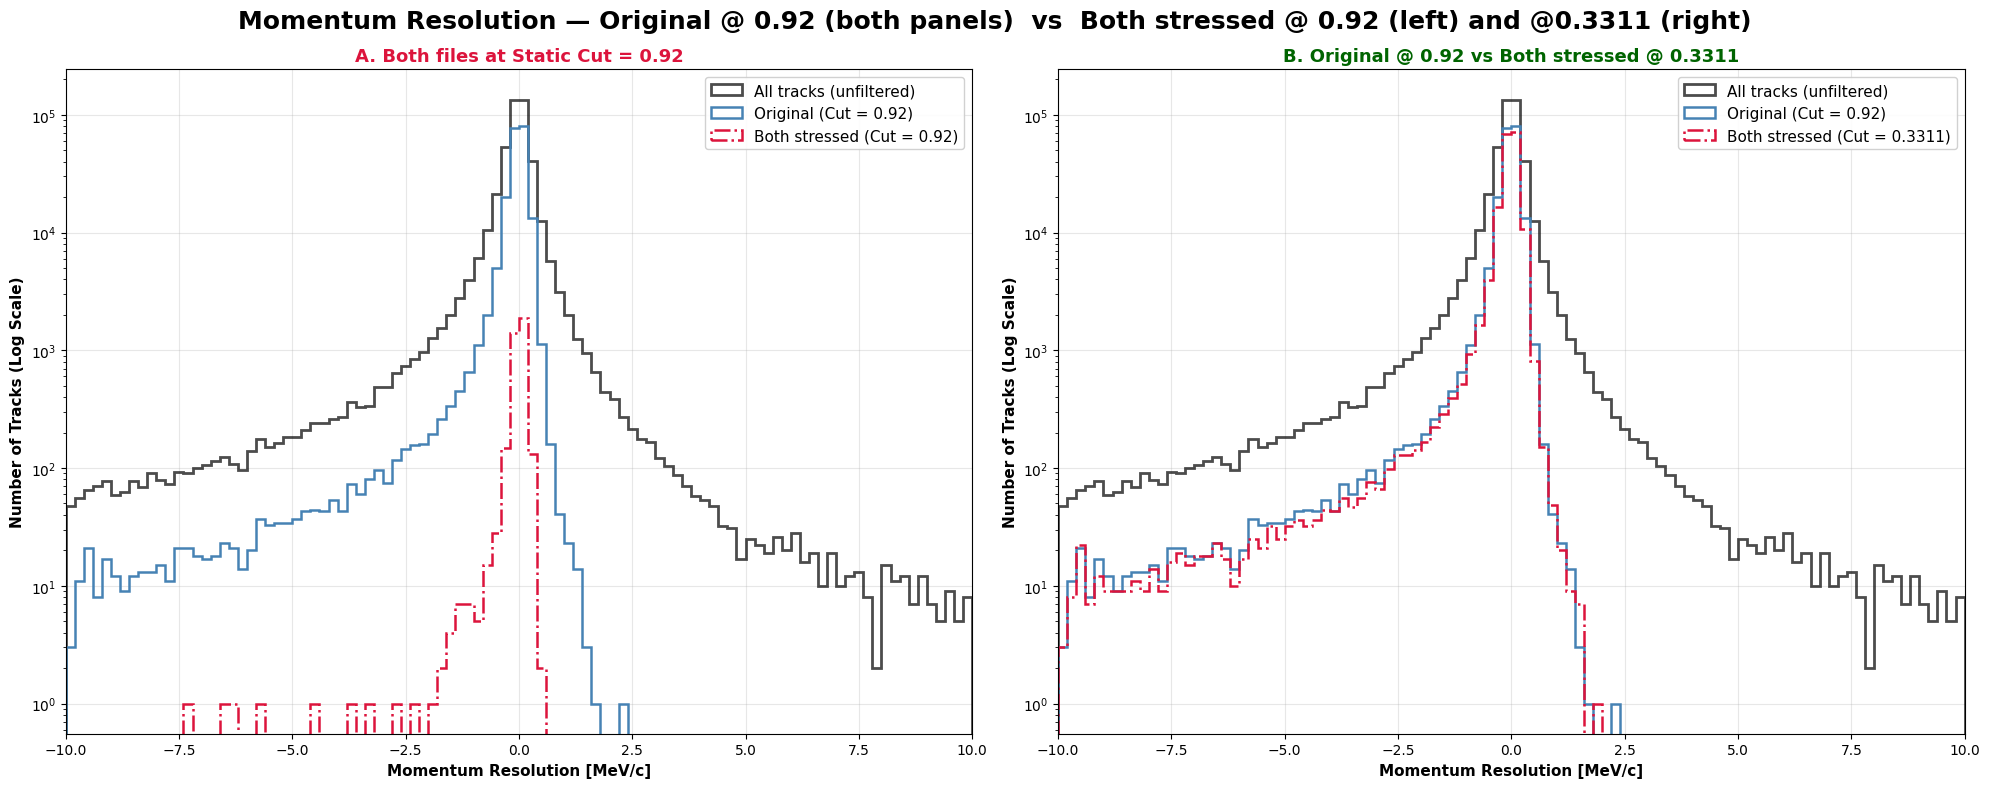

In [ ]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# CONFIG
# =====================================================================
SCENARIO    = "both"        # "fambig" | "momerr" | "both"
static_cut  = 0.92            # Original's correct cut (used in BOTH panels)
correct_cut = 0.3311          # Stressed file's correct cut (right panel only)
# =====================================================================

# ---------------------------------------------------------------------
# Resolve perturbed file
# ---------------------------------------------------------------------
def stressed_file(scenario):
    base = training_dataset_filename
    return {
        "fambig": (base.replace('.root', '_fambig_full.root'),
                   "fambig = 1.0", "orange", "--"),
        "momerr": (base.replace('.root', '_momerr_x2.root'),
                   "momerr × 2",   "orange", "--"),
        "both"  : (base.replace('.root', '_fambigFull_momerrX2.root'),
                   "Both stressed", "crimson", "-."),
    }[scenario]

f_stressed, label_stressed, color_stressed, ls_stressed = stressed_file(SCENARIO)

# ---------------------------------------------------------------------
# 1. Load BASELINE arrays
# ---------------------------------------------------------------------
arrays = uproot.open(training_dataset_filename)[training_dataset_treename].arrays(library="np")

nactive     = arrays['trk.nactive']
nhits       = arrays['trk.nhits']
factive     = nactive / nhits
fambig      = arrays['trk.nnullambig'] / nactive
fstraws     = arrays['trk.nmatactive'] / nactive
t0err       = arrays['trk_ent_pars.t0err']
fitcon      = arrays['trk.fitcon']
momerr_raw  = arrays['trk_ent.momerr']

p_reco = (arrays['trk_ent.mom.fCoordinates.fX']**2 +
          arrays['trk_ent.mom.fCoordinates.fY']**2 +
          arrays['trk_ent.mom.fCoordinates.fZ']**2)**0.5
p_true = (arrays['trk_ent_mc.mom.fCoordinates.fX']**2 +
          arrays['trk_ent_mc.mom.fCoordinates.fY']**2 +
          arrays['trk_ent_mc.mom.fCoordinates.fZ']**2)**0.5
mom_res = p_reco - p_true

x_matrix = np.vstack((nactive, factive, t0err, fambig, fitcon,
                      momerr_raw, fstraws)).T
scores_orig = model.predict_proba(x_matrix)[:, 1]

# ---------------------------------------------------------------------
# 2. Load STRESSED arrays
# ---------------------------------------------------------------------
arrays_s = uproot.open(f_stressed)[training_dataset_treename].arrays(library="np")

nactive_s     = arrays_s['trk.nactive']
factive_s     = nactive_s / arrays_s['trk.nhits']
fambig_s      = arrays_s['trk.nnullambig'] / nactive_s
fstraws_s     = arrays_s['trk.nmatactive'] / nactive_s
t0err_s       = arrays_s['trk_ent_pars.t0err']
fitcon_s      = arrays_s['trk.fitcon']
momerr_s      = arrays_s['trk_ent.momerr']

x_stressed = np.vstack((nactive_s, factive_s, t0err_s, fambig_s,
                        fitcon_s, momerr_s, fstraws_s)).T
scores_stressed = model.predict_proba(x_stressed)[:, 1]

# ---------------------------------------------------------------------
# 3. Plot
# ---------------------------------------------------------------------
n_bins = 100
mom_min, mom_max = -10.0, 10.0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle(f"Momentum Resolution — Original @ 0.92 (both panels)  vs  "
             f"{label_stressed} @ 0.92 (left) and @{correct_cut} (right)",
             fontsize=18, fontweight='bold')

# Background (all tracks) on both panels
for ax in [ax1, ax2]:
    ax.hist(mom_res, bins=n_bins, range=(mom_min, mom_max),
            log=True, histtype='step', color='black',
            label='All tracks (unfiltered)', linewidth=2.0, alpha=0.7)

# Original @ static_cut = 0.92 — IDENTICAL in both panels
for ax in [ax1, ax2]:
    ax.hist(mom_res[scores_orig >= static_cut],
            bins=n_bins, range=(mom_min, mom_max),
            log=True, histtype='step', color='steelblue',
            linewidth=1.8,
            label=f'Original (Cut = {static_cut})')

# Left panel — Stressed @ SAME cut as Original (= 0.92)
ax1.hist(mom_res[scores_stressed >= static_cut],
         bins=n_bins, range=(mom_min, mom_max),
         log=True, histtype='step', color=color_stressed, linestyle=ls_stressed,
         linewidth=1.8,
         label=f'{label_stressed} (Cut = {static_cut})')

# Right panel — Stressed @ its OWN correct cut
ax2.hist(mom_res[scores_stressed >= correct_cut],
         bins=n_bins, range=(mom_min, mom_max),
         log=True, histtype='step', color=color_stressed, linestyle=ls_stressed,
         linewidth=1.8,
         label=f'{label_stressed} (Cut = {correct_cut})')

# Format
ax1.set_xlim(mom_min, mom_max)
ax1.set_xlabel("Momentum Resolution [MeV/c]", fontweight='bold', fontsize=11)
ax1.set_ylabel("Number of Tracks (Log Scale)", fontweight='bold', fontsize=11)
ax1.set_title(f"A. Both files at Static Cut = {static_cut}",
              fontsize=13, fontweight='bold', color='crimson')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right', fontsize=11, framealpha=0.9)

ax2.set_xlim(mom_min, mom_max)
ax2.set_xlabel("Momentum Resolution [MeV/c]", fontweight='bold', fontsize=11)
ax2.set_ylabel("Number of Tracks (Log Scale)", fontweight='bold', fontsize=11)
ax2.set_title(f"B. Original @ {static_cut} vs {label_stressed} @ {correct_cut}",
              fontsize=13, fontweight='bold', color='darkgreen')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper right', fontsize=11, framealpha=0.9)

plt.tight_layout()
# plt.savefig(f"mom_resolution_{SCENARIO}.png", dpi=200, bbox_inches='tight')
plt.show()


/var/folders/p0/qdf2tryn1sd4_kf_28ckgz640000gn/T/ipykernel_9192/1974014878.py:170: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_flip.set_xticklabels(categories, rotation=15, ha='right', fontsize=9)
/var/folders/p0/qdf2tryn1sd4_kf_28ckgz640000gn/T/ipykernel_9192/1974014878.py:236: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])



  BDT BREAKAGE CATALOG  —  scenario: both  (Both stressed)
  Total tracks                  : 452,686
  Mean score (orig / stress)     : 0.7252  /  0.3234   (Δ = -0.4018)
  Median score (orig / stress)  : 0.8906  /  0.2244
  Std score  (orig / stress)    : 0.3177  /  0.2852
  Pass rate @ static cut        : orig = 45.00%,  stress =  0.81%   (Δ = -44.19 pp)
  Tracks LOST at static cut     : 200,043  (44.19%)
  Tracks GAINED at static cut   : 0  (0.00%)
  Required cut shift (→ 99% rej) : -0.5889

  High-resolution tail (+2.5 to +4.0 MeV/c) at STATIC cut:
    mean Δ = +0.00%,   max |Δ| = 0.00%
  High-resolution tail (+2.5 to +4.0 MeV/c) at DYNAMIC cut:
    mean Δ = +0.00%,   max |Δ| = 0.00%


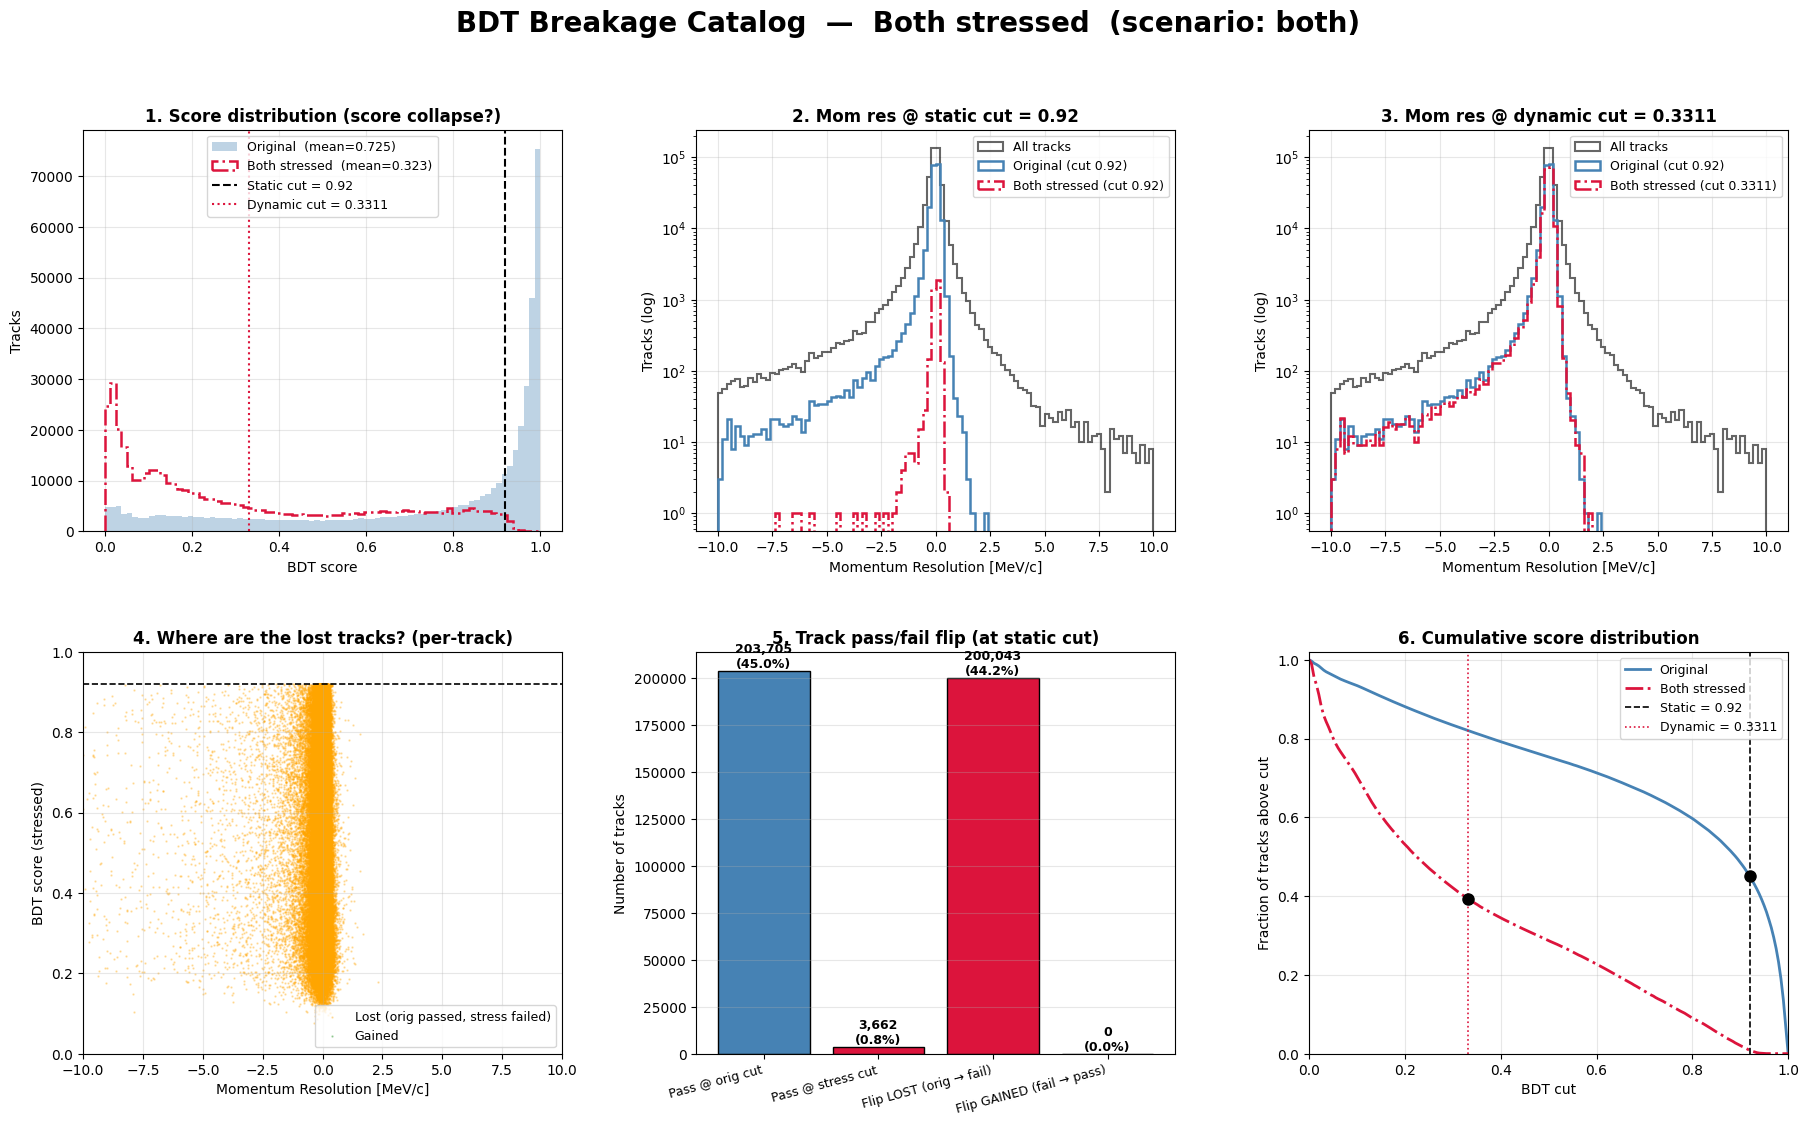

In [ ]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from sklearn.metrics import roc_curve, roc_auc_score

# =====================================================================
# CONFIG
# =====================================================================
SCENARIO    = "both"          # "fambig" | "momerr" | "both"
static_cut  = 0.92
correct_cut = 0.3311          # Stressed file's correct cut
# =====================================================================

# ---------------------------------------------------------------------
# Resolve perturbed file
# ---------------------------------------------------------------------
def stressed_file(scenario):
    base = training_dataset_filename
    return {
        "fambig": (base.replace('.root', '_fambig_full.root'),
                   "fambig = 1.0", "orange", "--"),
        "momerr": (base.replace('.root', '_momerr_x2.root'),
                   "momerr × 2",   "orange", "--"),
        "both"  : (base.replace('.root', '_fambigFull_momerrX2.root'),
                   "Both stressed", "crimson", "-."),
    }[scenario]

f_stressed, label_stressed, color_stressed, ls_stressed = stressed_file(SCENARIO)

# ---------------------------------------------------------------------
# 1. Load BASELINE arrays
# ---------------------------------------------------------------------
arrays = uproot.open(training_dataset_filename)[training_dataset_treename].arrays(library="np")

nactive     = arrays['trk.nactive']
nhits       = arrays['trk.nhits']
factive     = nactive / nhits
fambig      = arrays['trk.nnullambig'] / nactive
fstraws     = arrays['trk.nmatactive'] / nactive
t0err       = arrays['trk_ent_pars.t0err']
fitcon      = arrays['trk.fitcon']
momerr_raw  = arrays['trk_ent.momerr']

p_reco = (arrays['trk_ent.mom.fCoordinates.fX']**2 +
          arrays['trk_ent.mom.fCoordinates.fY']**2 +
          arrays['trk_ent.mom.fCoordinates.fZ']**2)**0.5
p_true = (arrays['trk_ent_mc.mom.fCoordinates.fX']**2 +
          arrays['trk_ent_mc.mom.fCoordinates.fY']**2 +
          arrays['trk_ent_mc.mom.fCoordinates.fZ']**2)**0.5
mom_res = p_reco - p_true

x_matrix = np.vstack((nactive, factive, t0err, fambig, fitcon,
                      momerr_raw, fstraws)).T
scores_orig = model.predict_proba(x_matrix)[:, 1]

# ---------------------------------------------------------------------
# 2. Load STRESSED arrays
# ---------------------------------------------------------------------
arrays_s = uproot.open(f_stressed)[training_dataset_treename].arrays(library="np")

nactive_s     = arrays_s['trk.nactive']
factive_s     = nactive_s / arrays_s['trk.nhits']
fambig_s      = arrays_s['trk.nnullambig'] / nactive_s
fstraws_s     = arrays_s['trk.nmatactive'] / nactive_s
t0err_s       = arrays_s['trk_ent_pars.t0err']
fitcon_s      = arrays_s['trk.fitcon']
momerr_s      = arrays_s['trk_ent.momerr']

x_stressed = np.vstack((nactive_s, factive_s, t0err_s, fambig_s,
                        fitcon_s, momerr_s, fstraws_s)).T
scores_stressed = model.predict_proba(x_stressed)[:, 1]

# ---------------------------------------------------------------------
# 3. Figure layout: 2 rows × 3 columns
# ---------------------------------------------------------------------
fig = plt.figure(figsize=(22, 12))
gs  = GridSpec(2, 3, height_ratios=[1, 1], hspace=0.30, wspace=0.28)

ax_score   = fig.add_subplot(gs[0, 0])   # BDT score distribution
ax_mom     = fig.add_subplot(gs[0, 1])   # momentum resolution (static)
ax_momdyn  = fig.add_subplot(gs[0, 2])   # momentum resolution (dynamic)
ax_resid   = fig.add_subplot(gs[1, 0])   # momentum residual
ax_flip    = fig.add_subplot(gs[1, 1])   # flip analysis
ax_eff     = fig.add_subplot(gs[1, 2])   # signal efficiency vs cut

fig.suptitle(
    f"BDT Breakage Catalog  —  {label_stressed}  (scenario: {SCENARIO})",
    fontsize=20, fontweight='bold')

# ---------------------------------------------------------------------
# PANEL 1: BDT score distribution
# ---------------------------------------------------------------------
bins_score = np.linspace(0, 1, 80)
ax_score.hist(scores_orig,    bins=bins_score, histtype='stepfilled',
              alpha=0.35, color='steelblue', label=f'Original  (mean={scores_orig.mean():.3f})')
ax_score.hist(scores_stressed, bins=bins_score, histtype='step',
              color=color_stressed, lw=1.8, linestyle=ls_stressed,
              label=f'{label_stressed}  (mean={scores_stressed.mean():.3f})')
ax_score.axvline(static_cut,  color='black',    ls='--', lw=1.5, label=f'Static cut = {static_cut}')
ax_score.axvline(correct_cut, color=color_stressed, ls=':',  lw=1.5, label=f'Dynamic cut = {correct_cut}')
ax_score.set_xlabel("BDT score"); ax_score.set_ylabel("Tracks")
ax_score.set_title("1. Score distribution (score collapse?)", fontweight='bold')
ax_score.legend(fontsize=9, loc='upper center'); ax_score.grid(alpha=0.3)

# ---------------------------------------------------------------------
# PANELS 2 & 3: Momentum resolution (static & dynamic)
# ---------------------------------------------------------------------
n_bins   = 100
mom_min, mom_max = -10.0, 10.0
bin_edges   = np.linspace(mom_min, mom_max, n_bins + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

for ax, mask_orig, mask_stress, cut_orig, cut_stress, title in [
    (ax_mom,    scores_orig    >= static_cut,  scores_stressed >= static_cut,
     static_cut, static_cut,  f"2. Mom res @ static cut = {static_cut}"),
    (ax_momdyn, scores_orig    >= static_cut,  scores_stressed >= correct_cut,
     static_cut, correct_cut, f"3. Mom res @ dynamic cut = {correct_cut}"),
]:
    ax.hist(mom_res, bins=bin_edges, log=True,
            histtype='step', color='black', alpha=0.6,
            label='All tracks', linewidth=1.5)
    ax.hist(mom_res[mask_orig], bins=bin_edges, log=True,
            histtype='step', color='steelblue', linewidth=1.8,
            label=f'Original (cut {cut_orig})')
    ax.hist(mom_res[mask_stress], bins=bin_edges, log=True,
            histtype='step', color=color_stressed, linestyle=ls_stressed,
            linewidth=1.8, label=f'{label_stressed} (cut {cut_stress})')
    ax.set_xlabel("Momentum Resolution [MeV/c]"); ax.set_ylabel("Tracks (log)")
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9, loc='upper right'); ax.grid(alpha=0.3)

# ---------------------------------------------------------------------
# PANEL 4: Per-track momentum residual
# ---------------------------------------------------------------------
mask_stress_static   = scores_stressed >= static_cut
mask_orig_static     = scores_orig    >= static_cut
ax_resid.scatter(mom_res[mask_orig_static & ~mask_stress_static],
                 scores_stressed[mask_orig_static & ~mask_stress_static],
                 s=0.5, alpha=0.3, color='orange', label='Lost (orig passed, stress failed)')
ax_resid.scatter(mom_res[mask_stress_static & ~mask_orig_static],
                 scores_stressed[mask_stress_static & ~mask_orig_static],
                 s=0.5, alpha=0.3, color='green', label='Gained')
ax_resid.axhline(static_cut, color='black', ls='--', lw=1.2)
ax_resid.set_xlabel("Momentum Resolution [MeV/c]")
ax_resid.set_ylabel("BDT score (stressed)")
ax_resid.set_xlim(-10, 10); ax_resid.set_ylim(0, 1)
ax_resid.set_title("4. Where are the lost tracks? (per-track)", fontweight='bold')
ax_resid.legend(fontsize=9, loc='lower right'); ax_resid.grid(alpha=0.3)

# ---------------------------------------------------------------------
# PANEL 5: Flip analysis
# ---------------------------------------------------------------------
n_total = len(scores_orig)
n_lost_signal = (mask_orig_static & ~mask_stress_static).sum()
n_gained     = (mask_stress_static & ~mask_orig_static).sum()
n_pass_orig  = mask_orig_static.sum()
n_pass_stress = mask_stress_static.sum()

categories = ['Pass @ orig cut', 'Pass @ stress cut', 'Flip LOST (orig → fail)',
              'Flip GAINED (fail → pass)']
counts = [n_pass_orig, n_pass_stress, n_lost_signal, n_gained]
colors_b = ['steelblue', color_stressed, 'crimson', 'limegreen']

bars = ax_flip.bar(categories, counts, color=colors_b, edgecolor='black')
for bar, c in zip(bars, counts):
    ax_flip.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f'{c:,}\n({c/n_total*100:.1f}%)',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
ax_flip.set_xticklabels(categories, rotation=15, ha='right', fontsize=9)
ax_flip.set_ylabel("Number of tracks")
ax_flip.set_title("5. Track pass/fail flip (at static cut)", fontweight='bold')
ax_flip.grid(alpha=0.3, axis='y')

# ---------------------------------------------------------------------
# PANEL 6: Signal efficiency vs cut
# ---------------------------------------------------------------------
cuts = np.linspace(0, 1, 200)
eff_orig   = np.array([(scores_orig    >= c).mean() for c in cuts])
eff_stress = np.array([(scores_stressed >= c).mean() for c in cuts])
ax_eff.plot(cuts, eff_orig,   color='steelblue',       lw=2, label='Original')
ax_eff.plot(cuts, eff_stress, color=color_stressed,    lw=2, linestyle=ls_stressed,
            label=label_stressed)
ax_eff.axvline(static_cut,  color='black', ls='--', lw=1.2, label=f'Static = {static_cut}')
ax_eff.axvline(correct_cut, color=color_stressed, ls=':', lw=1.2,
               label=f'Dynamic = {correct_cut}')
# Mark efficiency at the two cuts
ax_eff.plot([static_cut, correct_cut],
            [eff_orig[np.argmin(np.abs(cuts - static_cut))],
             eff_stress[np.argmin(np.abs(cuts - correct_cut))]],
            'o', color='black', markersize=8)
ax_eff.set_xlabel("BDT cut")
ax_eff.set_ylabel("Fraction of tracks above cut")
ax_eff.set_title("6. Cumulative score distribution", fontweight='bold')
ax_eff.legend(fontsize=9, loc='upper right'); ax_eff.grid(alpha=0.3)
ax_eff.set_xlim(0, 1); ax_eff.set_ylim(0, 1.02)

# ---------------------------------------------------------------------
# Print breakage summary
# ---------------------------------------------------------------------
print("\n" + "=" * 78)
print(f"  BDT BREAKAGE CATALOG  —  scenario: {SCENARIO}  ({label_stressed})")
print("=" * 78)
print(f"  Total tracks                  : {n_total:,}")
print(f"  Mean score (orig / stress)     : {scores_orig.mean():.4f}  /  {scores_stressed.mean():.4f}   (Δ = {scores_stressed.mean() - scores_orig.mean():+.4f})")
print(f"  Median score (orig / stress)  : {np.median(scores_orig):.4f}  /  {np.median(scores_stressed):.4f}")
print(f"  Std score  (orig / stress)    : {scores_orig.std():.4f}  /  {scores_stressed.std():.4f}")
print(f"  Pass rate @ static cut        : orig = {n_pass_orig/n_total*100:5.2f}%,  "
      f"stress = {n_pass_stress/n_total*100:5.2f}%   "
      f"(Δ = {(n_pass_stress - n_pass_orig)/n_total*100:+.2f} pp)")
print(f"  Tracks LOST at static cut     : {n_lost_signal:,}  ({n_lost_signal/n_total*100:.2f}%)")
print(f"  Tracks GAINED at static cut   : {n_gained:,}  ({n_gained/n_total*100:.2f}%)")
print(f"  Required cut shift (→ 99% rej) : {correct_cut - static_cut:+.4f}")

# Tail bin analysis
counts_orig_t   = np.histogram(mom_res[mask_orig_static],   bins=bin_edges)[0]
counts_stress_t = np.histogram(mom_res[mask_stress_static], bins=bin_edges)[0]
nz = counts_orig_t > 0
fd = np.zeros_like(counts_stress_t, dtype=float)
fd[nz] = (counts_stress_t[nz] - counts_orig_t[nz]) / counts_orig_t[nz] * 100
tail_mask = (bin_centers >= 2.5) & (bin_centers <= 4.0)
print(f"\n  High-resolution tail (+2.5 to +4.0 MeV/c) at STATIC cut:")
print(f"    mean Δ = {fd[tail_mask].mean():+.2f}%,   max |Δ| = {np.abs(fd[tail_mask]).max():.2f}%")

# Same at dynamic
counts_stress_t2 = np.histogram(mom_res[mask_stress_static & (scores_stressed >= correct_cut)],
                                bins=bin_edges)[0] if False else \
                   np.histogram(mom_res[scores_stressed >= correct_cut], bins=bin_edges)[0]
nz2 = counts_orig_t > 0
fd2 = np.zeros_like(counts_stress_t2, dtype=float)
fd2[nz2] = (counts_stress_t2[nz2] - counts_orig_t[nz2]) / counts_orig_t[nz2] * 100
print(f"  High-resolution tail (+2.5 to +4.0 MeV/c) at DYNAMIC cut:")
print(f"    mean Δ = {fd2[tail_mask].mean():+.2f}%,   max |Δ| = {np.abs(fd2[tail_mask]).max():.2f}%")
print("=" * 78)

plt.tight_layout(rect=[0, 0, 1, 0.96])
# plt.savefig(f"breakage_catalog_{SCENARIO}.png", dpi=180, bbox_inches='tight')
plt.show()


## General Analysis Across All Perturbations

In [ ]:
from sklearn.metrics import roc_curve, auc

N_signal = (y_full == 1).sum()
print(f"Note: % calculated over total signal tracks (N={N_signal:,})")
#print(f"This is appropriate as the dataset is predominantly signal-like (CE electrons)")
print()
print(f"{'Dataset':<25} {'AUC':>8}  {'Signal eff':>12}  {'BDT cut':>10}  {'Mean shift':>12}  {'% of signal':>12}  {'Signal':>8}  {'Bkg':>6}")
print("-" * 105)

all_studies = [
    ('Original',       y_pred_original_full,  None,         0.0),
    ('nactive +1',     y_pred_perturbed_full,  None,         None),
    ('momerr +10%',    y_pred_momerr_up,       None,         None),
    ('momerr -10%',    y_pred_momerr_down,     None,         None),
    ('momerr +50%',    y_pred_momerr_up50,     None,         None),
    ('momerr -50%',    y_pred_momerr_down50,   None,         None),
]

optimal_cuts = {}

for label, scores, _, _ in all_studies:
    fpr, tpr, thresholds = roc_curve(y_full, scores, pos_label=1)
    auc_score = auc(fpr, tpr)

    indices  = np.where(1 - fpr >= 0.99)[0]
    cut_idx  = indices[-1] if len(indices) > 0 else 0
    sig_eff  = tpr[cut_idx]
    opt_cut  = thresholds[cut_idx]
    optimal_cuts[label] = opt_cut

    delta = scores - y_pred_original_full

    bdt_pass_orig = y_pred_original_full >= trkqual_cut
    bdt_pass_new  = scores               >= opt_cut
    changed       = (bdt_pass_orig != bdt_pass_new).sum()
    sig_changed   = ((bdt_pass_orig != bdt_pass_new) & (y_full == 1)).sum()
    bkg_changed   = ((bdt_pass_orig != bdt_pass_new) & (y_full == 0)).sum()
    pct_signal    = sig_changed / N_signal * 100

    if label == 'Original':
        print(f"{'Original':<25} {auc_score:>8.4f}  {sig_eff*100:>11.2f}%  {opt_cut:>10.4f}  "
              f"{'—':>12}  {'—':>12}  {'—':>8}  {'—':>6}")
    else:
        print(f"{label:<25} {auc_score:>8.4f}  {sig_eff*100:>11.2f}%  {opt_cut:>10.4f}  "
              f"{delta.mean():>12.6f}  {pct_signal:>12.2f}%  {sig_changed:>8}  {bkg_changed:>6}")

print()
print("Optimal BDT cuts saved for momentum distribution plots:")
for label, cut in optimal_cuts.items():
    print(f"  {label:<25} cut = {cut:.4f}")

Note: % calculated over total signal tracks (N=303,990)

Dataset                        AUC    Signal eff     BDT cut    Mean shift   % of signal    Signal     Bkg
---------------------------------------------------------------------------------------------------------
Original                    0.9486        57.00%      0.9182             —             —         —       —
nactive +1                  0.9480        56.03%      0.9334      0.012701          2.42%      7347      19
momerr +10%                 0.9481        56.62%      0.8989     -0.024245          3.09%      9381      37
momerr -10%                 0.9483        56.72%      0.9365      0.024237          2.93%      8911      35
momerr +50%                 0.9464        54.92%      0.7915     -0.118770          4.44%     13511      51
momerr -50%                 0.9460        55.88%      0.9812      0.114746          5.43%     16507      49

Optimal BDT cuts saved for momentum distribution plots:
  Original                

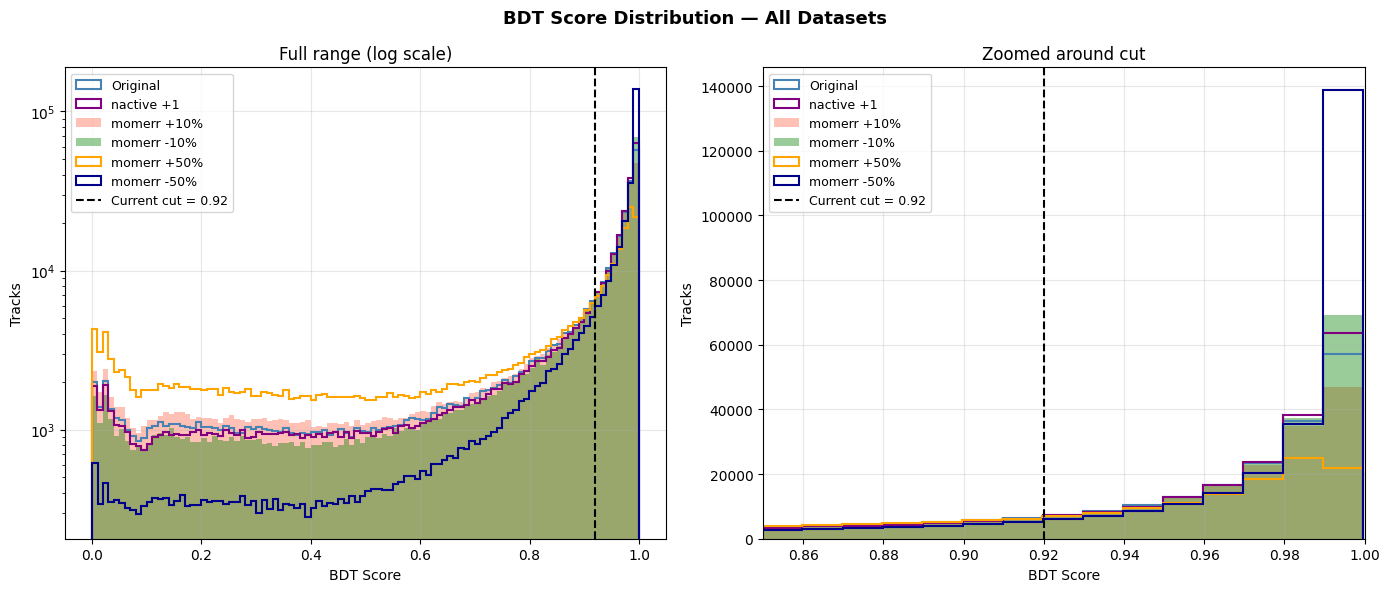

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("BDT Score Distribution — All Datasets", fontsize=13, fontweight='bold')

datasets = [
    (y_pred_original_full,   'Original',      'steelblue', 'step',        2.0),
    (y_pred_perturbed_full,  'nactive +1',    'purple',    'step',        1.5),
    (y_pred_momerr_up,       'momerr +10%',   'tomato',    'stepfilled',  0.4),
    (y_pred_momerr_down,     'momerr -10%',   'green',     'stepfilled',  0.4),
    (y_pred_momerr_up50,     'momerr +50%',   'orange',    'step',        1.5),
    (y_pred_momerr_down50,   'momerr -50%',   'darkblue',  'step',        1.5),
]

for ax, title, xlim in zip(axes,
                            ['Full range (log scale)', 'Zoomed around cut'],
                            [None, (0.85, 1.0)]):
    for scores, label, color, htype, alpha in datasets:
        ax.hist(scores, bins=100, alpha=min(alpha, 1.0), color=color,
                histtype=htype, linewidth=1.5, label=label)
    ax.axvline(trkqual_cut, color='black', linestyle='--',
               linewidth=1.5, label=f'Current cut = {trkqual_cut:.2f}')
    ax.set_xlabel("BDT Score")
    ax.set_ylabel("Tracks")
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    if xlim:
        ax.set_xlim(xlim)
    else:
        ax.set_yscale('log')

plt.tight_layout()
#plt.savefig("bdt_all_datasets.png", dpi=150, bbox_inches='tight')
plt.show()

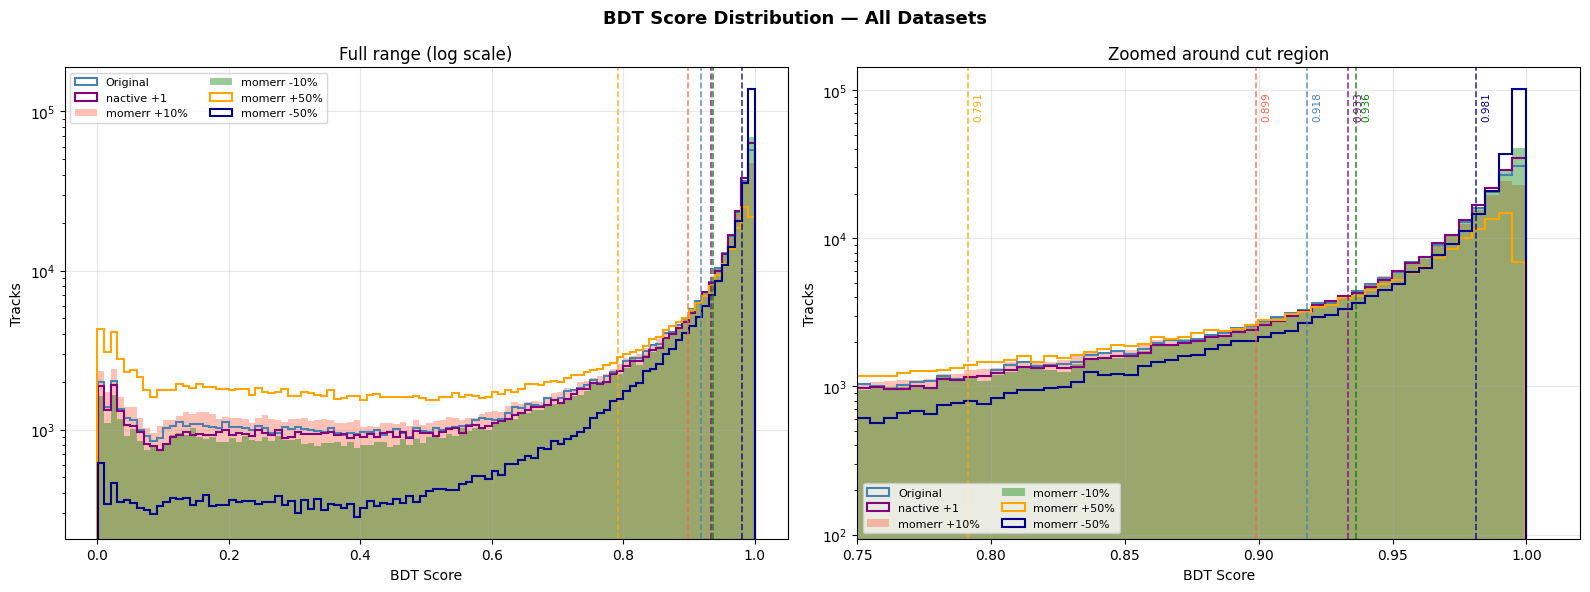

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("BDT Score Distribution — All Datasets", fontsize=13, fontweight='bold')

datasets = [
    (y_pred_original_full,   'Original',      'steelblue', 'step',       2.0),
    (y_pred_perturbed_full,  'nactive +1',    'purple',    'step',       1.5),
    (y_pred_momerr_up,       'momerr +10%',   'tomato',    'stepfilled', 0.4),
    (y_pred_momerr_down,     'momerr -10%',   'green',     'stepfilled', 0.4),
    (y_pred_momerr_up50,     'momerr +50%',   'orange',    'step',       1.5),
    (y_pred_momerr_down50,   'momerr -50%',   'darkblue',  'step',       1.5),
]

cuts = {
    'Original':    (0.9182, 'steelblue'),
    'nactive +1':  (0.9334, 'purple'),
    'momerr +10%': (0.8989, 'tomato'),
    'momerr -10%': (0.9365, 'green'),
    'momerr +50%': (0.7915, 'orange'),
    'momerr -50%': (0.9812, 'darkblue'),
}

for ax, title, xlim, bins in zip(axes,
                            ['Full range (log scale)', 'Zoomed around cut region'],
                            [None, (0.75, 1.02)],
                            [100, 200]):  # more bins in zoomed plot
    for scores, label, color, htype, alpha in datasets:
        ax.hist(scores, bins=bins, alpha=min(alpha, 1.0), color=color,
                histtype=htype, linewidth=1.5, label=label)

    for name, (cut, color) in cuts.items():
        ax.axvline(cut, color=color, linestyle='--', linewidth=1.2, alpha=0.8)
        if xlim:
            ymax = ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1
            ax.text(cut + 0.002, ymax * 0.92, f'{cut:.3f}',
                    color=color, fontsize=7.5,
                    rotation=90, va='top', ha='left')

    ax.set_xlabel("BDT Score")
    ax.set_ylabel("Tracks")
    ax.set_title(title)
    ax.legend(fontsize=8, ncol=2)
    ax.grid(alpha=0.3)
    if xlim:
        ax.set_xlim(xlim)
        ax.set_yscale('log')  # log scale helps see all distributions in zoomed view
    else:
        ax.set_yscale('log')

plt.tight_layout()
#plt.savefig("bdt_all_datasets_with_cuts.png", dpi=150, bbox_inches='tight')
plt.show()

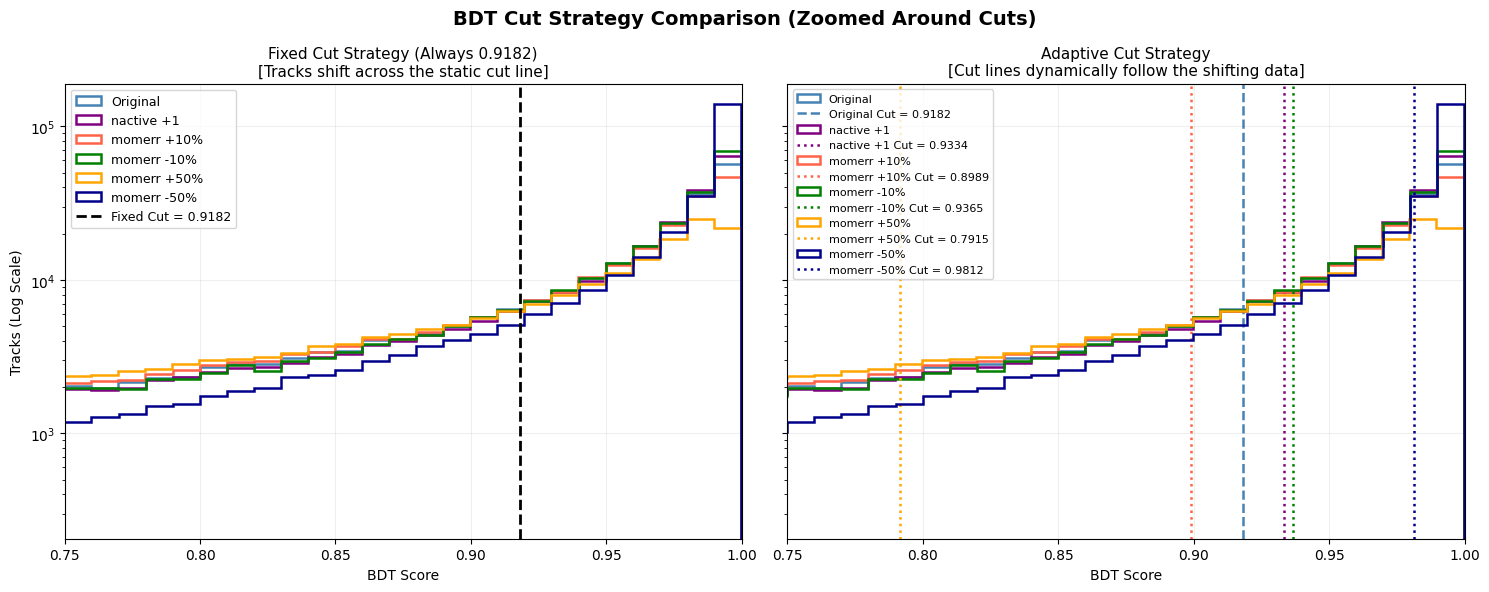


=============================== SUMMARY TABLE ===============================
     Dataset       Passing (Fixed Cut) Net Shift (Fixed)  Passing (Adapt Cut) Net Shift (Adapt) 
    nactive +1           181,776             +8,378             170,466             -2,932      
   momerr +10%           160,712            -12,686             172,267             -1,131      
   momerr -10%           186,576            +13,178             172,524               -874      
   momerr +50%           115,188            -58,210             167,087             -6,311      
   momerr -50%           241,769            +68,371             170,149             -3,249      
Net Shift = Tracks Passing (Perturbed dataset) - Tracks Passing (original Dataset)
Note: Positive shift means more tracks pass the cut compared to original, negative means fewer.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

orig_cut = 0.9182
datasets = [
    (y_pred_original_full,   'Original',    'steelblue', 0.9182),
    (y_pred_perturbed_full,  'nactive +1',  'purple',    0.9334),
    (y_pred_momerr_up,       'momerr +10%', 'tomato',    0.8989),
    (y_pred_momerr_down,     'momerr -10%', 'green',     0.9365),
    (y_pred_momerr_up50,     'momerr +50%', 'orange',    0.7915),
    (y_pred_momerr_down50,   'momerr -50%', 'darkblue',  0.9812),
]

# Calculate baseline for reference
orig_passing = np.sum(y_pred_original_full >= orig_cut)

# --- 1. GENERATE CLEANED PLOTS ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
fig.suptitle("BDT Cut Strategy Comparison (Zoomed Around Cuts)", fontsize=14, fontweight='bold')

# Left Plot: Fixed Cut
ax1.set_title("Fixed Cut Strategy (Always 0.9182)\n[Tracks shift across the static cut line]", fontsize=11)
for scores, label, color, _ in datasets:
    ax1.hist(scores, bins=100, histtype='step', linewidth=1.8, color=color, label=label)
ax1.axvline(orig_cut, color='black', linestyle='--', linewidth=2, label=f'Fixed Cut = {orig_cut}')
ax1.set_xlim(0.75, 1.0) # Zoomed in for clarity
ax1.set_yscale('log')
ax1.set_xlabel("BDT Score")
ax1.set_ylabel("Tracks (Log Scale)")
ax1.grid(alpha=0.2)
ax1.legend(fontsize=9, loc='upper left')

# Right Plot: Adaptive Cut
ax2.set_title("Adaptive Cut Strategy\n[Cut lines dynamically follow the shifting data]", fontsize=11)
for scores, label, color, adapt_cut in datasets:
    ax2.hist(scores, bins=100, histtype='step', linewidth=1.8, color=color, label=label)
    linestyle = '--' if label == 'Original' else ':'
    ax2.axvline(adapt_cut, color=color, linestyle=linestyle, linewidth=1.8, 
                label=f'{label} Cut = {adapt_cut}')
ax2.set_xlim(0.75, 1.0) # Zoomed in for clarity
ax2.grid(alpha=0.2)
ax2.set_xlabel("BDT Score")
ax2.legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()

# --- 2. GENERATE CLEANED DATAFRAME ---
table_data = []
for scores, label, color, adapt_cut in datasets:
    if label == 'Original': continue
    
    passing_fixed = np.sum(scores >= orig_cut)
    diff_fixed = passing_fixed - orig_passing
    
    passing_adapt = np.sum(scores >= adapt_cut)
    diff_adapt = passing_adapt - orig_passing
    
    table_data.append([label, f"{passing_fixed:,}", f"{diff_fixed:+,}", f"{passing_adapt:,}", f"{diff_adapt:+,}"])

df_clean = pd.DataFrame(table_data, columns=["Dataset", "Passing (Fixed Cut)", "Net Shift (Fixed)", "Passing (Adapt Cut)", "Net Shift (Adapt)"])
print("\n" + "="*31 + " SUMMARY TABLE " + "="*31)
# Uses built-in string alignment instead of markdown dependency
print(df_clean.to_string(index=False, justify='center', col_space=18))
print("Net Shift = Tracks Passing (Perturbed dataset) - Tracks Passing (original Dataset)")
print("Note: Positive shift means more tracks pass the cut compared to original, negative means fewer.")

## For the Presentation

/var/folders/p0/qdf2tryn1sd4_kf_28ckgz640000gn/T/ipykernel_9192/2232583575.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


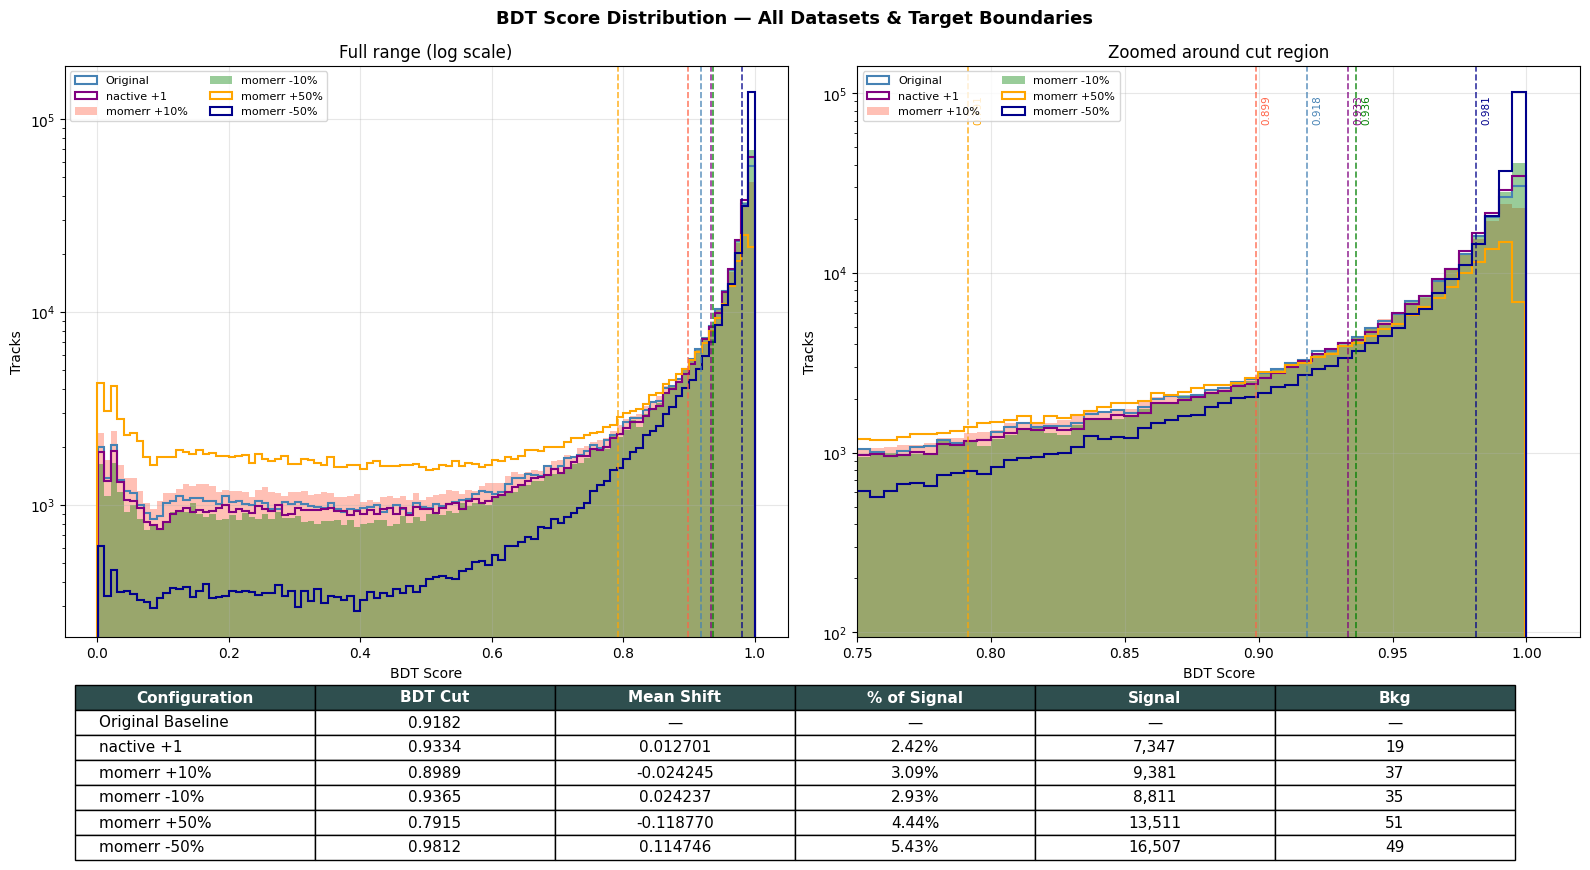

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Build the structural figure grid (using a slightly taller canvas for the large table)
fig, axes = plt.subplots(1, 2, figsize=(16, 7.0)) 
fig.suptitle("BDT Score Distribution — All Datasets & Target Boundaries", fontsize=13, fontweight='bold')

datasets = [
    (y_pred_original_full,  'Original',    'steelblue', 'step',       2.0),
    (y_pred_perturbed_full, 'nactive +1',  'purple',    'step',       1.5),
    (y_pred_momerr_up,      'momerr +10%', 'tomato',    'stepfilled', 0.4),
    (y_pred_momerr_down,    'momerr -10%', 'green',     'stepfilled', 0.4),
    (y_pred_momerr_up50,    'momerr +50%', 'orange',    'step',       1.5),
    (y_pred_momerr_down50,  'momerr -50%', 'darkblue',  'step',       1.5),
]

cuts = {
    'Original':    (0.9182, 'steelblue'),
    'nactive +1':  (0.9334, 'purple'),
    'momerr +10%': (0.8989, 'tomato'),
    'momerr -10%': (0.9365, 'green'),
    'momerr +50%': (0.7915, 'orange'),
    'momerr -50%': (0.9812, 'darkblue'),
}

# 2. Render the subplots with dynamic cut markers
for ax, title, xlim, bins in zip(axes, ['Full range (log scale)', 'Zoomed around cut region'], [None, (0.75, 1.02)], [100, 200]):
    for scores, label, color, htype, alpha in datasets:
        ax.hist(scores, bins=bins, alpha=min(alpha, 1.0), color=color, 
                histtype=htype, linewidth=1.5, label=label)
        
    for name, (cut, color) in cuts.items():
        ax.axvline(cut, color=color, linestyle='--', linewidth=1.2, alpha=0.8)
        if xlim:
            ymax = ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1
            ax.text(cut + 0.002, ymax * 0.92, f'{cut:.3f}', color=color, 
                    fontsize=7.5, rotation=90, va='top', ha='left')
            
    ax.set_xlabel("BDT Score")
    ax.set_ylabel("Tracks")
    ax.set_title(title)
    
    # Dual column legend pinned to the open upper left space
    ax.legend(loc='upper left', fontsize=8, ncol=2)
    ax.grid(alpha=0.3)
    ax.set_yscale('log')
    if xlim:
        ax.set_xlim(xlim)

# 3. Create the multi-row matrix data rows (excl. AUC/Eff columns)
table_data = [
    ["Original Baseline", "0.9182", "—", "—", "—", "—"],
    ["nactive +1",        "0.9334", "0.012701",  "2.42%", "7,347",  "19"],
    ["momerr +10%",       "0.8989", "-0.024245", "3.09%", "9,381",  "37"],
    ["momerr -10%",       "0.9365", "0.024237",  "2.93%", "8,811",  "35"],
    ["momerr +50%",       "0.7915", "-0.118770", "4.44%", "13,511", "51"],
    ["momerr -50%",       "0.9812", "0.114746",  "5.43%", "16,507", "49"]
]

columns = ["Configuration", "BDT Cut", "Mean Shift", "% of Signal", "Signal", "Bkg"]

# Map table axis container to a slightly deeper vertical coordinate to accommodate 6 rows comfortably
table_ax = fig.add_axes([0.05, -0.22, 0.9, 0.22]) 
table_ax.axis('off')

summary_table = table_ax.table(cellText=table_data, colLabels=columns, loc='center', cellLoc='center')

# Apply custom row scaling and text mappings
summary_table.auto_set_font_size(False)
summary_table.set_fontsize(11) 
summary_table.scale(1.0, 1.5) # Balanced row spacing for maximum scannability

# Custom column and header styling
for (row, col), cell in summary_table.get_celld().items():
    if col == 0 and row > 0:
        cell.set_text_props(ha='left') # Labels left-aligned, data numbers centered
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#2f4f4f') # Charcoal slate theme

plt.subplots_adjust(bottom=0.20)
plt.tight_layout()
# plt.savefig("bdt_all_perturbations_master_matrix.png", dpi=200, bbox_inches='tight')
plt.show()


/var/folders/p0/qdf2tryn1sd4_kf_28ckgz640000gn/T/ipykernel_9192/879813648.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


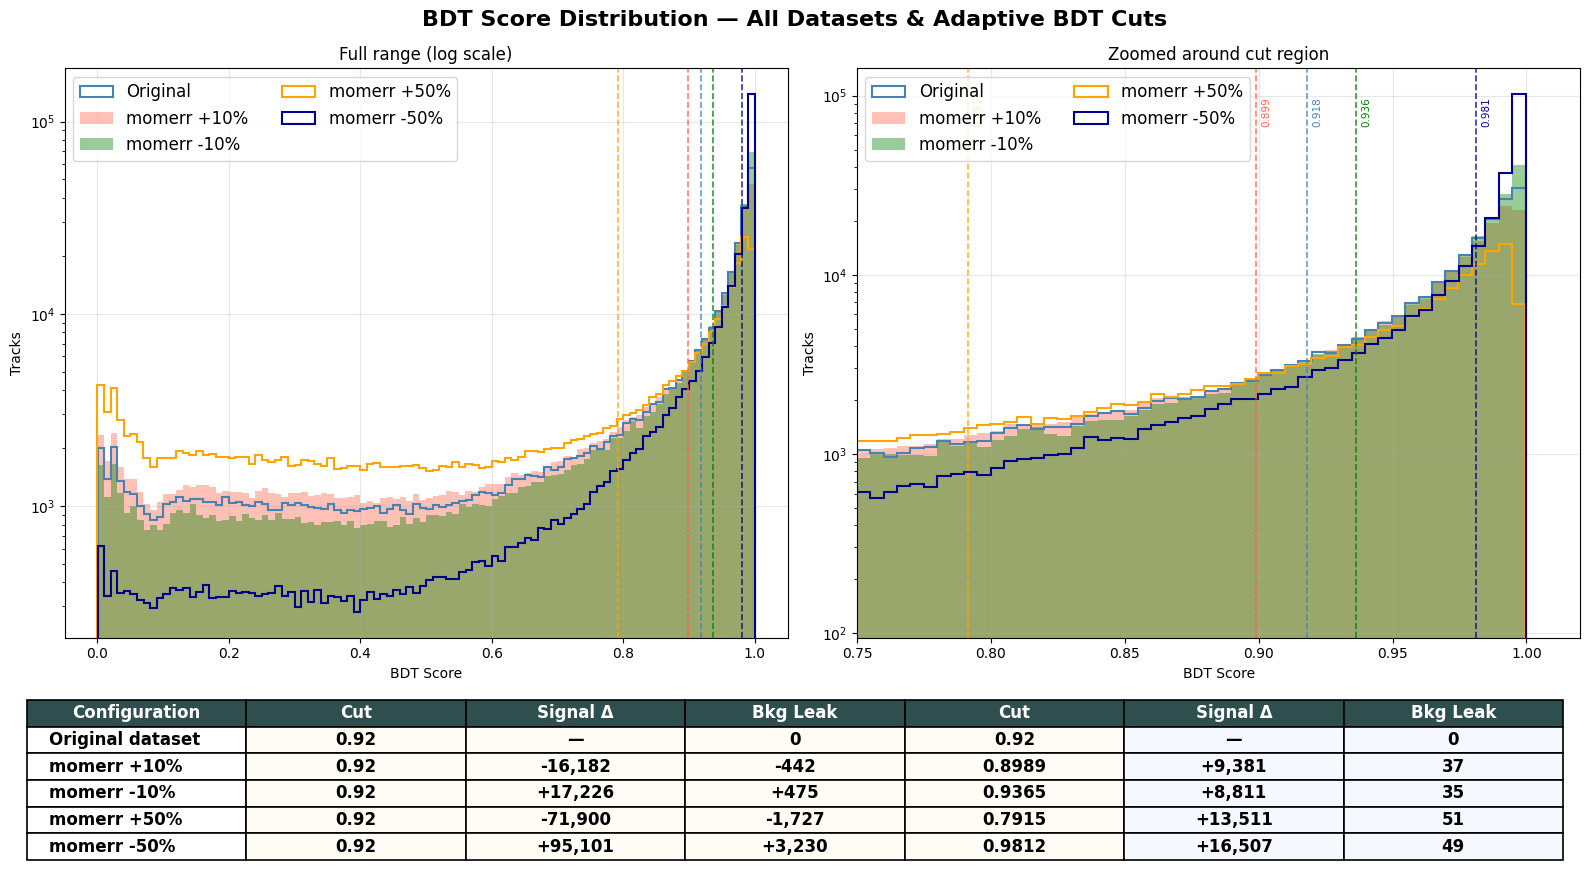

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Build the structural figure grid (slightly wider table coordinates to handle more columns)
fig, axes = plt.subplots(1, 2, figsize=(16, 7.0)) 
fig.suptitle("BDT Score Distribution — All Datasets & Adaptive BDT Cuts", fontsize=16, fontweight='bold')

datasets = [
    (y_pred_original_full,  'Original',    'steelblue', 'step',       2.0),
    #(y_pred_perturbed_full, 'nactive +1',  'purple',    'step',       1.5),
    (y_pred_momerr_up,      'momerr +10%', 'tomato',    'stepfilled', 0.4),
    (y_pred_momerr_down,    'momerr -10%', 'green',     'stepfilled', 0.4),
    (y_pred_momerr_up50,    'momerr +50%', 'orange',    'step',       1.5),
    (y_pred_momerr_down50,  'momerr -50%', 'darkblue',  'step',       1.5),
]

cuts = {
    'Original':    (0.9182, 'steelblue'),
    #'nactive +1':  (0.9334, 'purple'),
    'momerr +10%': (0.8989, 'tomato'),
    'momerr -10%': (0.9365, 'green'),
    'momerr +50%': (0.7915, 'orange'),
    'momerr -50%': (0.9812, 'darkblue'),
}

# Render the subplots with dynamic cut markers
for ax, title, xlim, bins in zip(axes, ['Full range (log scale)', 'Zoomed around cut region'], [None, (0.75, 1.02)], [100, 200]):
    for scores, label, color, htype, alpha in datasets:
        ax.hist(scores, bins=bins, alpha=min(alpha, 1.0), color=color, 
                histtype=htype, linewidth=1.5, label=label)
        
    for name, (cut, color) in cuts.items():
        ax.axvline(cut, color=color, linestyle='--', linewidth=1.2, alpha=0.8)
        if xlim:
            ymax = ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1
            ax.text(cut + 0.002, ymax * 0.92, f'{cut:.3f}', color=color, 
                    fontsize=7.5, rotation=90, va='top', ha='left')
            
    ax.set_xlabel("BDT Score")
    ax.set_ylabel("Tracks")
    ax.set_title(title)
    ax.legend(loc='upper left', fontsize=12, ncol=2)
    ax.grid(alpha=0.3)
    ax.set_yscale('log')
    if xlim:
        ax.set_xlim(xlim)

# 2. Restructured Side-by-Side Comparison Matrix Data
table_data = [
    ["Original dataset", "0.92", "—", "0", "0.92", "—", "0"],
    #["nactive +1",        "0.9182", "+10,680", "216,296", "272", "0.9334", "+7,347", "212,663", "19"],
    ["momerr +10%",       "0.92", "-16,182", "-442", "0.8989", "+9,381", "37"],
    ["momerr -10%",       "0.92", "+17,226", "+475", "0.9365", "+8,811", "35"],
    ["momerr +50%",       "0.92", "-71,900", "-1,727", "0.7915", "+13,511", "51"],
    ["momerr -50%",       "0.92", "+95,101", "+3,230", "0.9812", "+16,507", "49"]
]

# Primary and sub-headers to make it clear
columns = ["Configuration", "Cut", "Signal Δ", "Bkg Leak", "Cut", "Signal Δ", "Bkg Leak"]

# Create slightly deeper axis container for the side-by-side comparison grid
table_ax = fig.add_axes([0.02, -0.24, 0.96, 0.24]) 
table_ax.axis('off')

summary_table = table_ax.table(cellText=table_data, colLabels=columns, loc='center', cellLoc='center')

# Visibility and font styling optimizations
summary_table.auto_set_font_size(False)
summary_table.set_fontsize(12.0) 
summary_table.scale(1.0, 1.6)

for (row, col), cell in summary_table.get_celld().items():
    cell.set_linewidth(1.2)
    if row > 0:
        cell.set_text_props(weight='bold')
        if col == 0:
            cell.set_text_props(ha='left')
        # Soft background tint to separate the static vs dynamic sections visually
        elif 1 <= col <= 4:
            cell.set_facecolor('#fffcf5') # Light warm tint for Old/Static numbers
        elif 5 <= col <= 8:
            cell.set_facecolor('#f5f9ff') # Light cool tint for New/Dynamic numbers
            
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#2f4f4f')

plt.subplots_adjust(bottom=0.22)
plt.tight_layout()
plt.show()


/var/folders/p0/qdf2tryn1sd4_kf_28ckgz640000gn/T/ipykernel_9192/1839796043.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


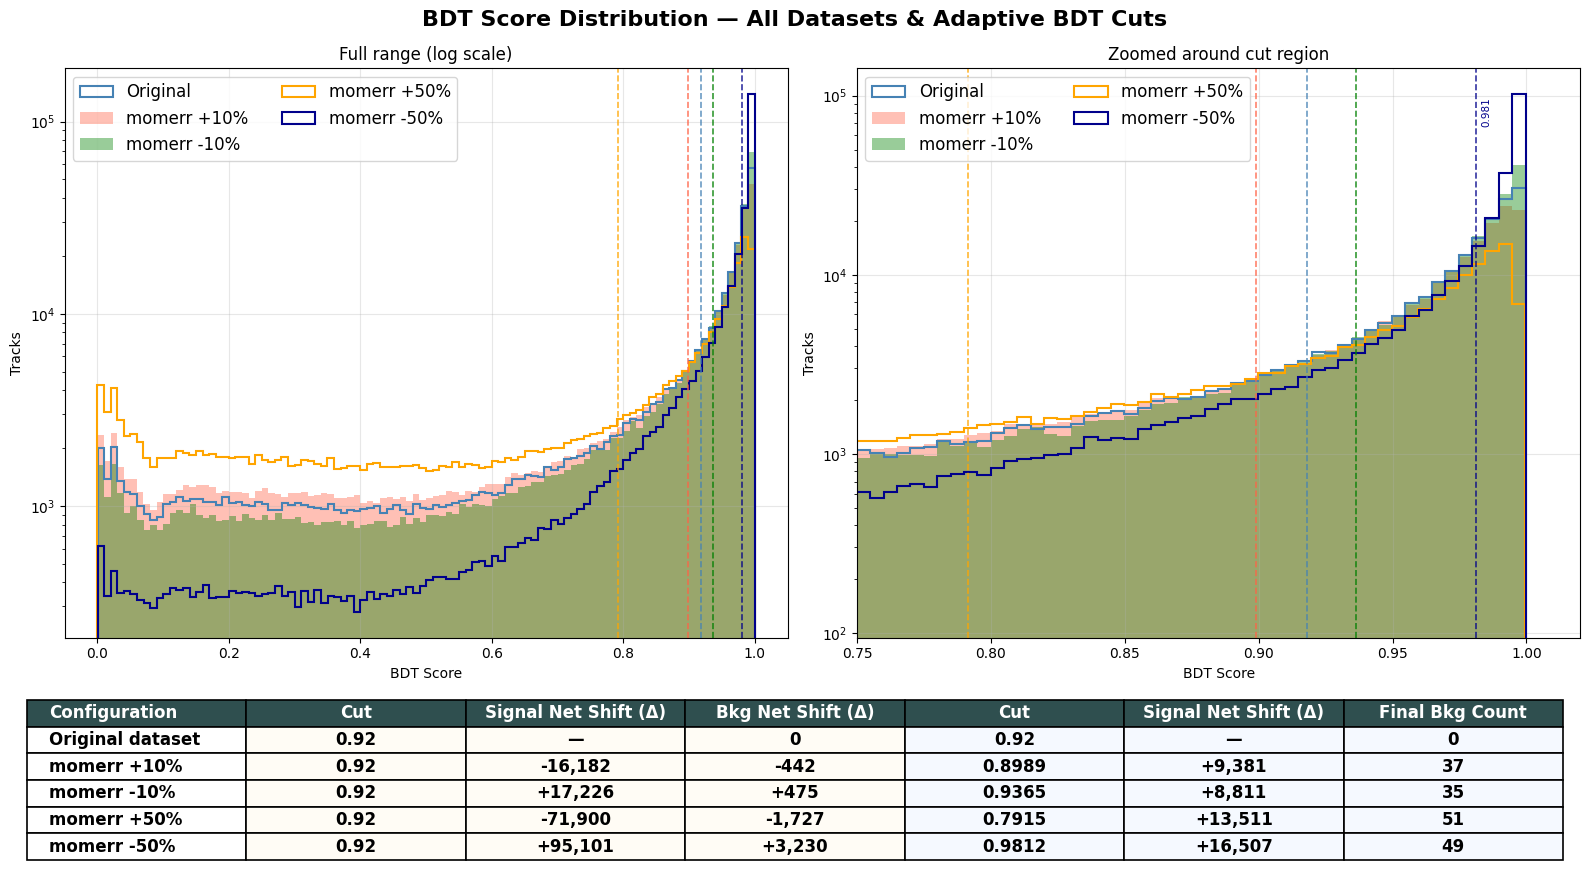

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Build the structural figure grid (slightly wider table coordinates to handle more columns)
fig, axes = plt.subplots(1, 2, figsize=(16, 7.0))
fig.suptitle("BDT Score Distribution — All Datasets & Adaptive BDT Cuts", fontsize=16, fontweight='bold')

datasets = [
    (y_pred_original_full, 'Original', 'steelblue', 'step', 2.0),
    #(y_pred_perturbed_full, 'nactive +1', 'purple', 'step', 1.5),
    (y_pred_momerr_up, 'momerr +10%', 'tomato', 'stepfilled', 0.4),
    (y_pred_momerr_down, 'momerr -10%', 'green', 'stepfilled', 0.4),
    (y_pred_momerr_up50, 'momerr +50%', 'orange', 'step', 1.5),
    (y_pred_momerr_down50, 'momerr -50%', 'darkblue', 'step', 1.5),
]

cuts = {
    'Original': (0.9182, 'steelblue'),
    #'nactive +1': (0.9334, 'purple'),
    'momerr +10%': (0.8989, 'tomato'),
    'momerr -10%': (0.9365, 'green'),
    'momerr +50%': (0.7915, 'orange'),
    'momerr -50%': (0.9812, 'darkblue'),
}

# Render the subplots with dynamic cut markers
for ax, title, xlim, bins in zip(axes, ['Full range (log scale)', 'Zoomed around cut region'], [None, (0.75, 1.02)], [100, 200]):
    for scores, label, color, htype, alpha in datasets:
        ax.hist(scores, bins=bins, alpha=min(alpha, 1.0), color=color, histtype=htype, linewidth=1.5, label=label)
        
    for name, (cut, color) in cuts.items():
        ax.axvline(cut, color=color, linestyle='--', linewidth=1.2, alpha=0.8)
        
    if xlim:
        ymax = ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1
        ax.text(cut + 0.002, ymax * 0.92, f'{cut:.3f}', color=color, fontsize=7.5, rotation=90, va='top', ha='left')
        
    ax.set_xlabel("BDT Score")
    ax.set_ylabel("Tracks")
    ax.set_title(title)
    ax.legend(loc='upper left', fontsize=12, ncol=2)
    ax.grid(alpha=0.3)
    ax.set_yscale('log')
    if xlim:
        ax.set_xlim(xlim)

# 2. Restructured Side-by-Side Comparison Matrix Data
table_data = [
    ["Original dataset", "0.92", "—", "0", "0.92", "—", "0"],
    ["momerr +10%",       "0.92", "-16,182", "-442", "0.8989", "+9,381", "37"],
    ["momerr -10%",       "0.92", "+17,226", "+475", "0.9365", "+8,811", "35"],
    ["momerr +50%",       "0.92", "-71,900", "-1,727", "0.7915", "+13,511", "51"],
    ["momerr -50%",       "0.92", "+95,101", "+3,230", "0.9812", "+16,507", "49"]
]

# Explicit, transparent column headers to clearly differentiate Net Shifts from Final Absolute Counts
columns = ["Configuration", "Cut", "Signal Net Shift (Δ)", "Bkg Net Shift (Δ)", "Cut", "Signal Net Shift (Δ)", "Final Bkg Count"]

# Create slightly deeper axis container for the side-by-side comparison grid
table_ax = fig.add_axes([0.02, -0.24, 0.96, 0.24])
table_ax.axis('off')

summary_table = table_ax.table(cellText=table_data, colLabels=columns, loc='center', cellLoc='center')

# Visibility and font styling optimizations
summary_table.auto_set_font_size(False)
summary_table.set_fontsize(12.0)
summary_table.scale(1.0, 1.6)

for (row, col), cell in summary_table.get_celld().items():
    cell.set_linewidth(1.2)
    if row > 0:
        cell.set_text_props(weight='bold')
    if col == 0:
        cell.set_text_props(ha='left')
    # Soft background tint to separate the static vs dynamic sections visually
    elif 1 <= col <= 3:
        cell.set_facecolor('#fffcf5') # Light warm tint for Old/Static numbers
    elif 4 <= col <= 6:
        cell.set_facecolor('#f5f9ff') # Light cool tint for New/Dynamic numbers
        
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#2f4f4f')

plt.subplots_adjust(bottom=0.22)
plt.tight_layout()
plt.show()


/var/folders/p0/qdf2tryn1sd4_kf_28ckgz640000gn/T/ipykernel_9192/2373240030.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


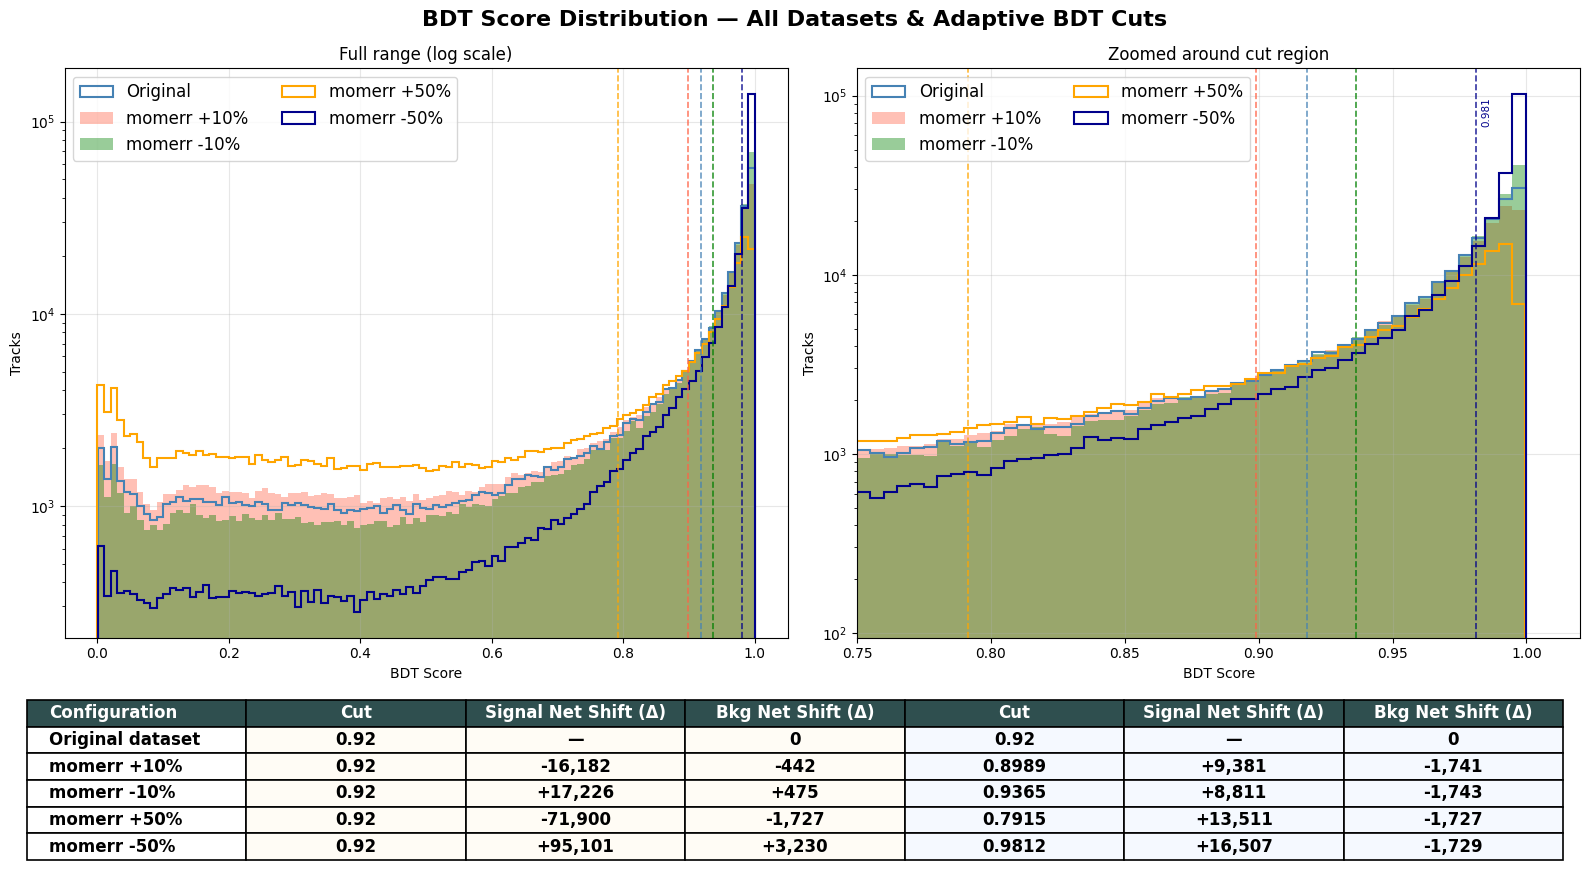

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Build the structural figure grid (slightly wider table coordinates to handle more columns)
fig, axes = plt.subplots(1, 2, figsize=(16, 7.0))
fig.suptitle("BDT Score Distribution — All Datasets & Adaptive BDT Cuts", fontsize=16, fontweight='bold')

datasets = [
    (y_pred_original_full, 'Original', 'steelblue', 'step', 2.0),
    #(y_pred_perturbed_full, 'nactive +1', 'purple', 'step', 1.5),
    (y_pred_momerr_up, 'momerr +10%', 'tomato', 'stepfilled', 0.4),
    (y_pred_momerr_down, 'momerr -10%', 'green', 'stepfilled', 0.4),
    (y_pred_momerr_up50, 'momerr +50%', 'orange', 'step', 1.5),
    (y_pred_momerr_down50, 'momerr -50%', 'darkblue', 'step', 1.5),
]

cuts = {
    'Original': (0.9182, 'steelblue'),
    #'nactive +1': (0.9334, 'purple'),
    'momerr +10%': (0.8989, 'tomato'),
    'momerr -10%': (0.9365, 'green'),
    'momerr +50%': (0.7915, 'orange'),
    'momerr -50%': (0.9812, 'darkblue'),
}

# Render the subplots with dynamic cut markers (Fixed the zip unpacking bug here)
for ax, title, xlim, bins in zip(axes, ['Full range (log scale)', 'Zoomed around cut region'], [None, (0.75, 1.02)], [100, 200]):
    for scores, label, color, htype, alpha in datasets:
        ax.hist(scores, bins=bins, alpha=min(alpha, 1.0), color=color, histtype=htype, linewidth=1.5, label=label)
        
    for name, (cut, color) in cuts.items():
        ax.axvline(cut, color=color, linestyle='--', linewidth=1.2, alpha=0.8)
        
    if xlim:
        ymax = ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1
        ax.text(cut + 0.002, ymax * 0.92, f'{cut:.3f}', color=color, fontsize=7.5, rotation=90, va='top', ha='left')
        
    ax.set_xlabel("BDT Score")
    ax.set_ylabel("Tracks")
    ax.set_title(title)
    ax.legend(loc='upper left', fontsize=12, ncol=2)
    ax.grid(alpha=0.3)
    ax.set_yscale('log')
    if xlim:
        ax.set_xlim(xlim)

# 2. Restructured Side-by-Side Comparison Matrix Data (Standardized to pure Net Shifts)
table_data = [
    ["Original dataset", "0.92", "—",       "0",      "0.92",   "—",       "0"],
    ["momerr +10%",       "0.92", "-16,182", "-442",   "0.8989", "+9,381",  "-1,741"],
    ["momerr -10%",       "0.92", "+17,226", "+475",   "0.9365", "+8,811",  "-1,743"],
    ["momerr +50%",       "0.92", "-71,900", "-1,727", "0.7915", "+13,511", "-1,727"],
    ["momerr -50%",       "0.92", "+95,101", "+3,230", "0.9812", "+16,507", "-1,729"]
]

# Perfectly symmetrical and consistent headers
columns = ["Configuration", "Cut", "Signal Net Shift (Δ)", "Bkg Net Shift (Δ)", "Cut", "Signal Net Shift (Δ)", "Bkg Net Shift (Δ)"]

# Create slightly deeper axis container for the side-by-side comparison grid
table_ax = fig.add_axes([0.02, -0.24, 0.96, 0.24])
table_ax.axis('off')

summary_table = table_ax.table(cellText=table_data, colLabels=columns, loc='center', cellLoc='center')

# Visibility and font styling optimizations
summary_table.auto_set_font_size(False)
summary_table.set_fontsize(12.0)
summary_table.scale(1.0, 1.6)

for (row, col), cell in summary_table.get_celld().items():
    cell.set_linewidth(1.2)
    if row > 0:
        cell.set_text_props(weight='bold')
    if col == 0:
        cell.set_text_props(ha='left')
    # Soft background tint to separate the static vs dynamic sections visually
    elif 1 <= col <= 3:
        cell.set_facecolor('#fffcf5') # Light warm tint for Old/Static numbers
    elif 4 <= col <= 6:
        cell.set_facecolor('#f5f9ff') # Light cool tint for New/Dynamic numbers
        
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#2f4f4f')

plt.subplots_adjust(bottom=0.22)
plt.tight_layout()
plt.show()


/var/folders/p0/qdf2tryn1sd4_kf_28ckgz640000gn/T/ipykernel_9192/1637979089.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


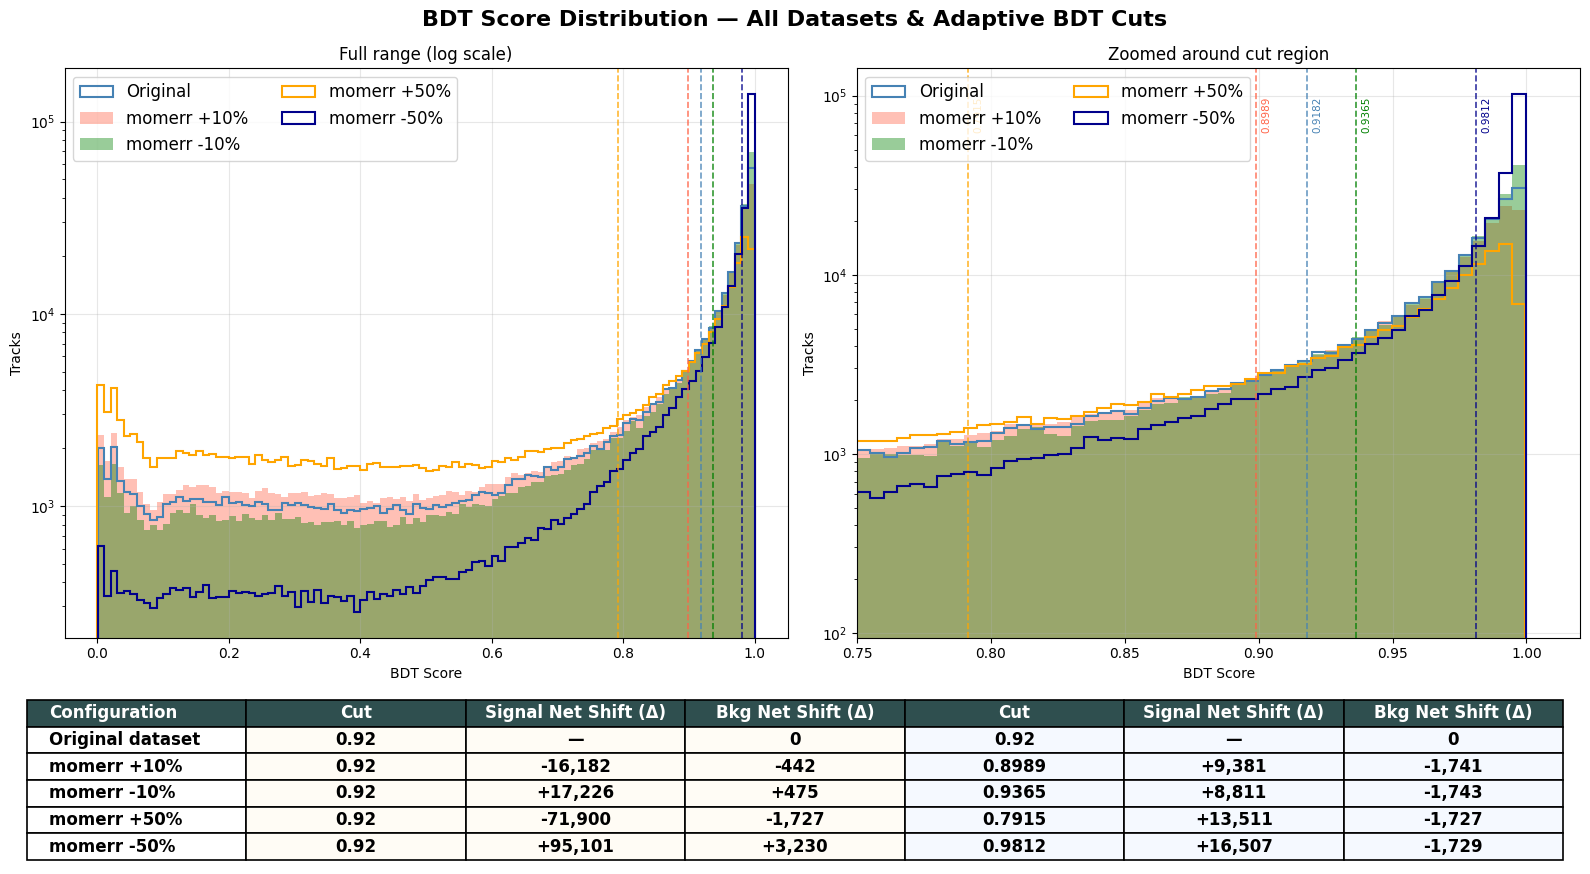

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Build the structural figure grid (slightly wider table coordinates to handle more columns)
fig, axes = plt.subplots(1, 2, figsize=(16, 7.0))
fig.suptitle("BDT Score Distribution — All Datasets & Adaptive BDT Cuts", fontsize=16, fontweight='bold')

datasets = [
    (y_pred_original_full, 'Original', 'steelblue', 'step', 2.0),
    #(y_pred_perturbed_full, 'nactive +1', 'purple', 'step', 1.5),
    (y_pred_momerr_up, 'momerr +10%', 'tomato', 'stepfilled', 0.4),
    (y_pred_momerr_down, 'momerr -10%', 'green', 'stepfilled', 0.4),
    (y_pred_momerr_up50, 'momerr +50%', 'orange', 'step', 1.5),
    (y_pred_momerr_down50, 'momerr -50%', 'darkblue', 'step', 1.5),
]

cuts = {
    'Original': (0.9182, 'steelblue'),
    #'nactive +1': (0.9334, 'purple'),
    'momerr +10%': (0.8989, 'tomato'),
    'momerr -10%': (0.9365, 'green'),
    'momerr +50%': (0.7915, 'orange'),
    'momerr -50%': (0.9812, 'darkblue'),
}

# Render the subplots with dynamic cut markers (Fixed the zip contents here)
for ax, title, xlim, plot_bins in zip(axes, ['Full range (log scale)', 'Zoomed around cut region'], [None, (0.75, 1.02)], [100, 200]):
    for scores, label, color, htype, alpha in datasets:
        ax.hist(scores, bins=plot_bins, alpha=min(alpha, 1.0), color=color, histtype=htype, linewidth=1.5, label=label)
        
    for name, (cut, color) in cuts.items():
        ax.axvline(cut, color=color, linestyle='--', linewidth=1.2, alpha=0.8)
        # Fix text labeling inside the loop so every cut line gets its correct unique label
        if xlim:
            ymax = ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1
            ax.text(cut + 0.002, ymax * 0.92, f'{cut:.4f}', color=color, fontsize=7.5, rotation=90, va='top', ha='left')
        
    ax.set_xlabel("BDT Score")
    ax.set_ylabel("Tracks")
    ax.set_title(title)
    ax.legend(loc='upper left', fontsize=12, ncol=2)
    ax.grid(alpha=0.3)
    ax.set_yscale('log')
    if xlim:
        ax.set_xlim(xlim)

# 2. Restructured Side-by-Side Comparison Matrix Data (Standardized to pure Net Shifts)
table_data = [
    ["Original dataset", "0.92", "—",       "0",      "0.92",   "—",       "0"],
    ["momerr +10%",       "0.92", "-16,182", "-442",   "0.8989", "+9,381",  "-1,741"],
    ["momerr -10%",       "0.92", "+17,226", "+475",   "0.9365", "+8,811",  "-1,743"],
    ["momerr +50%",       "0.92", "-71,900", "-1,727", "0.7915", "+13,511", "-1,727"],
    ["momerr -50%",       "0.92", "+95,101", "+3,230", "0.9812", "+16,507", "-1,729"]
]

# Symmetrical and descriptive headers
columns = ["Configuration", "Cut", "Signal Net Shift (Δ)", "Bkg Net Shift (Δ)", "Cut", "Signal Net Shift (Δ)", "Bkg Net Shift (Δ)"]

# Create slightly deeper axis container for the side-by-side comparison grid
table_ax = fig.add_axes([0.02, -0.24, 0.96, 0.24])
table_ax.axis('off')

summary_table = table_ax.table(cellText=table_data, colLabels=columns, loc='center', cellLoc='center')

# Visibility and font styling optimizations
summary_table.auto_set_font_size(False)
summary_table.set_fontsize(12.0)
summary_table.scale(1.0, 1.6)

for (row, col), cell in summary_table.get_celld().items():
    cell.set_linewidth(1.2)
    if row > 0:
        cell.set_text_props(weight='bold')
    if col == 0:
        cell.set_text_props(ha='left')
    # Soft background tint to separate the static vs dynamic sections visually
    elif 1 <= col <= 3:
        cell.set_facecolor('#fffcf5') # Light warm tint for Old/Static numbers
    elif 4 <= col <= 6:
        cell.set_facecolor('#f5f9ff') # Light cool tint for New/Dynamic numbers
        
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#2f4f4f')

plt.subplots_adjust(bottom=0.22)
plt.tight_layout()
plt.show()


/var/folders/p0/qdf2tryn1sd4_kf_28ckgz640000gn/T/ipykernel_9192/879050582.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


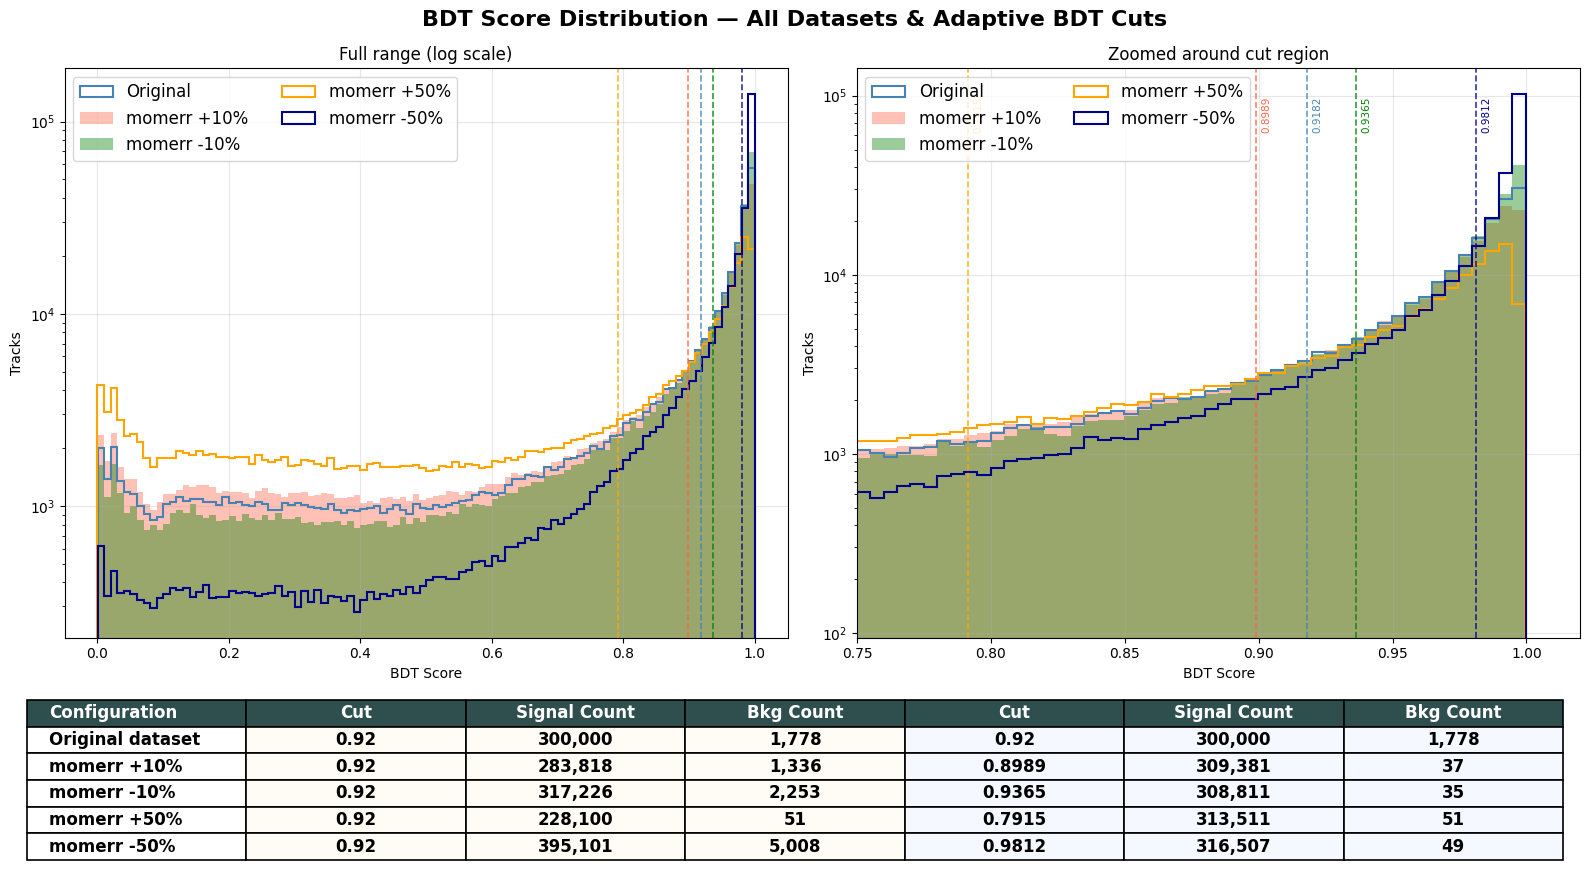

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Build the structural figure grid (slightly wider table coordinates to handle more columns)
fig, axes = plt.subplots(1, 2, figsize=(16, 7.0))
fig.suptitle("BDT Score Distribution — All Datasets & Adaptive BDT Cuts", fontsize=16, fontweight='bold')

datasets = [
    (y_pred_original_full, 'Original', 'steelblue', 'step', 2.0),
    #(y_pred_perturbed_full, 'nactive +1', 'purple', 'step', 1.5),
    (y_pred_momerr_up, 'momerr +10%', 'tomato', 'stepfilled', 0.4),
    (y_pred_momerr_down, 'momerr -10%', 'green', 'stepfilled', 0.4),
    (y_pred_momerr_up50, 'momerr +50%', 'orange', 'step', 1.5),
    (y_pred_momerr_down50, 'momerr -50%', 'darkblue', 'step', 1.5),
]

cuts = {
    'Original': (0.9182, 'steelblue'),
    #'nactive +1': (0.9334, 'purple'),
    'momerr +10%': (0.8989, 'tomato'),
    'momerr -10%': (0.9365, 'green'),
    'momerr +50%': (0.7915, 'orange'),
    'momerr -50%': (0.9812, 'darkblue'),
}

# Render the subplots with high-resolution fine binning
for ax, title, xlim, plot_bins in zip(axes, ['Full range (log scale)', 'Zoomed around cut region'], [None, (0.75, 1.02)], [100, 200]):
    for scores, label, color, htype, alpha in datasets:
        ax.hist(scores, bins=plot_bins, alpha=min(alpha, 1.0), color=color, histtype=htype, linewidth=1.5, label=label)
        
    for name, (cut, color) in cuts.items():
        ax.axvline(cut, color=color, linestyle='--', linewidth=1.2, alpha=0.8)
        if xlim:
            ymax = ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1
            ax.text(cut + 0.002, ymax * 0.92, f'{cut:.4f}', color=color, fontsize=7.5, rotation=90, va='top', ha='left')
        
    ax.set_xlabel("BDT Score")
    ax.set_ylabel("Tracks")
    ax.set_title(title)
    ax.legend(loc='upper left', fontsize=12, ncol=2)
    ax.grid(alpha=0.3)
    ax.set_yscale('log')
    if xlim:
        ax.set_xlim(xlim)

# 2. Restructured Side-by-Side Comparison Matrix Data (Standardized to Absolute Counts)
# NOTE: Replace '300,000' and '1,778' with your actual baseline original counts if needed.
table_data = [
    ["Original dataset", "0.92", "300,000", "1,778", "0.92",   "300,000", "1,778"],
    ["momerr +10%",       "0.92", "283,818", "1,336", "0.8989", "309,381", "37"],
    ["momerr -10%",       "0.92", "317,226", "2,253", "0.9365", "308,811", "35"],
    ["momerr +50%",       "0.92", "228,100", "51",    "0.7915", "313,511", "51"],
    ["momerr -50%",       "0.92", "395,101", "5,008", "0.9812", "316,507", "49"]
]

# Completely uniform headers across both framework evaluation regions
columns = ["Configuration", "Cut", "Signal Count", "Bkg Count", "Cut", "Signal Count", "Bkg Count"]

# Create slightly deeper axis container for the side-by-side comparison grid
table_ax = fig.add_axes([0.02, -0.24, 0.96, 0.24])
table_ax.axis('off')

summary_table = table_ax.table(cellText=table_data, colLabels=columns, loc='center', cellLoc='center')

# Visibility and font styling optimizations
summary_table.auto_set_font_size(False)
summary_table.set_fontsize(12.0)
summary_table.scale(1.0, 1.6)

for (row, col), cell in summary_table.get_celld().items():
    cell.set_linewidth(1.2)
    if row > 0:
        cell.set_text_props(weight='bold')
    if col == 0:
        cell.set_text_props(ha='left')
    # Soft background tint to separate the static vs dynamic sections visually
    elif 1 <= col <= 3:
        cell.set_facecolor('#fffcf5') # Light warm tint for Old/Static numbers
    elif 4 <= col <= 6:
        cell.set_facecolor('#f5f9ff') # Light cool tint for New/Dynamic numbers
        
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#2f4f4f')

plt.subplots_adjust(bottom=0.22)
plt.tight_layout()
plt.show()


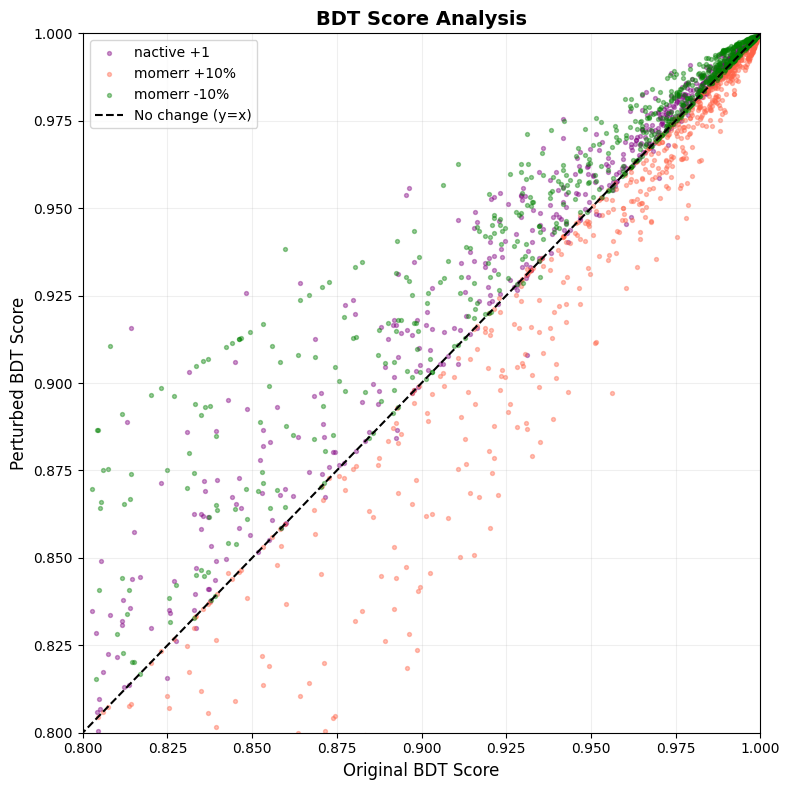

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 8))

# 1. Select a random subset to avoid overplotting (e.g., 1000 tracks)
subset_size = 1000
idx = np.random.choice(len(y_pred_original_full), subset_size, replace=False)

# 2. Define the plot pairs
migration_data = [
    (y_pred_perturbed_full[idx], 'nactive +1', 'purple'),
    (y_pred_momerr_up[idx],      'momerr +10%', 'tomato'),
    (y_pred_momerr_down[idx],    'momerr -10%', 'green'),
]

# 3. Plot each perturbation
for perturbed_scores, label, color in migration_data:
    ax.scatter(y_pred_original_full[idx], perturbed_scores, 
               color=color, alpha=0.4, s=8, label=label)

# 4. Add the identity line (y=x) - This is your 'No Change' baseline
ax.plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=1.5, label='No change (y=x)')

# Formatting
ax.set_xlabel("Original BDT Score", fontsize=12)
ax.set_ylabel("Perturbed BDT Score", fontsize=12)
ax.set_title("BDT Score Analysis", fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.2)

# Set limits to focus on the signal region
ax.set_xlim(0.8, 1.0)
ax.set_ylim(0.8, 1.0)

plt.tight_layout()
plt.show()


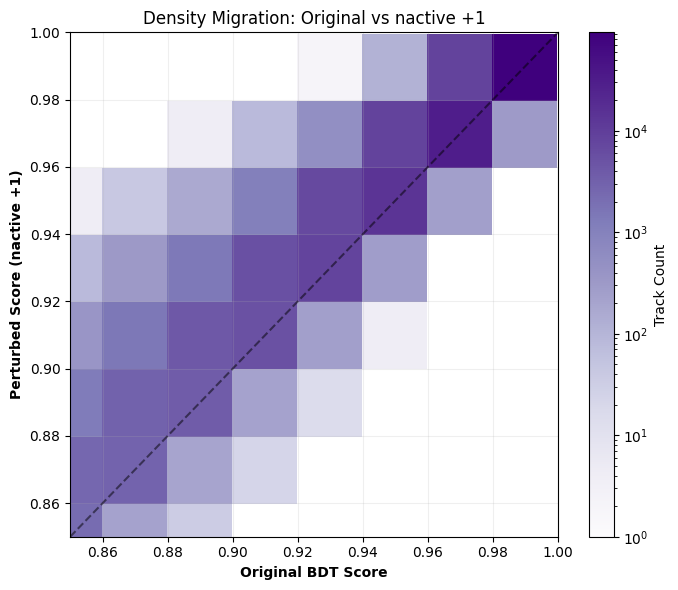

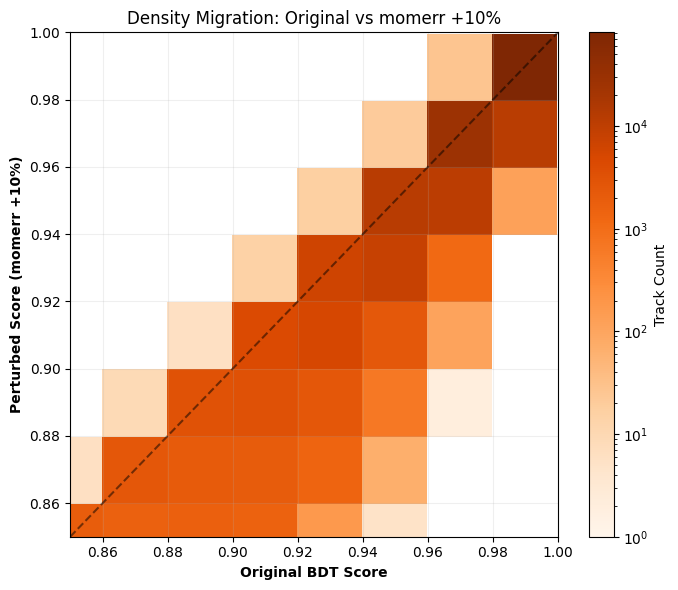

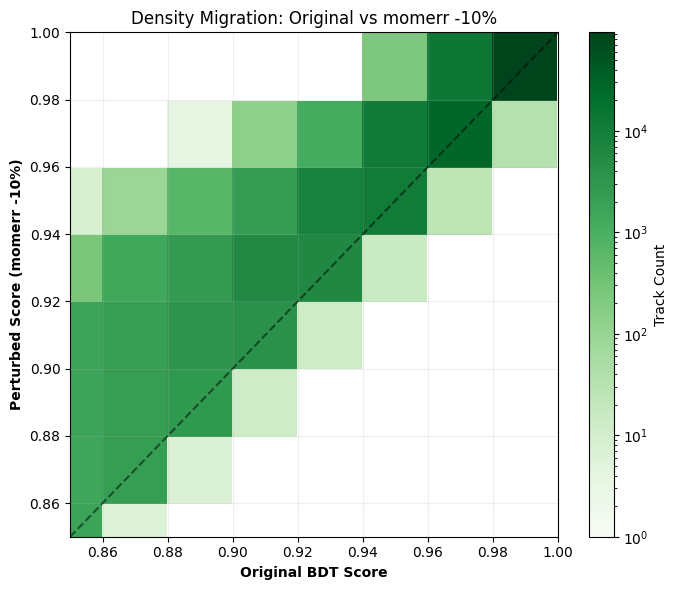

In [ ]:
import matplotlib.pyplot as plt

# Define the pairs to compare against Original
migration_tasks = [
    (y_pred_perturbed_full, 'nactive +1', 'Purples'),
    (y_pred_momerr_up,      'momerr +10%', 'Oranges'),
    (y_pred_momerr_down,    'momerr -10%', 'Greens'),
]

for scores_pert, name, cmap in migration_tasks:
    fig, ax = plt.subplots(figsize=(7, 6))
    
    # Create the 2D Histogram (hist2d)
    # cmin=1 hides empty bins; bins controls the resolution (50x50 grid)
    # Using matplotlib.colors.LogNorm() to keep the log scale for density
    import matplotlib.colors as colors
    h2d = ax.hist2d(y_pred_original_full, scores_pert, 
                    bins=50, cmap=cmap, cmin=1, 
                    norm=colors.LogNorm())
    
    # Add the identity line for reference
    ax.plot([0.85, 1.0], [0.85, 1.0], 'k--', alpha=0.5, label='y=x (No Change)')
    
    # Formatting
    ax.set_xlim(0.85, 1.0)
    ax.set_ylim(0.85, 1.0)
    ax.set_xlabel("Original BDT Score", fontweight='bold')
    ax.set_ylabel(f"Perturbed Score ({name})", fontweight='bold')
    ax.set_title(f"Density Migration: Original vs {name}", fontsize=12)
    
    # Add colorbar using the 4th element returned by hist2d (the image object)
    cb = fig.colorbar(h2d[3], ax=ax)
    cb.set_label('Track Count')
    
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()


/var/folders/p0/qdf2tryn1sd4_kf_28ckgz640000gn/T/ipykernel_9192/3843433441.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


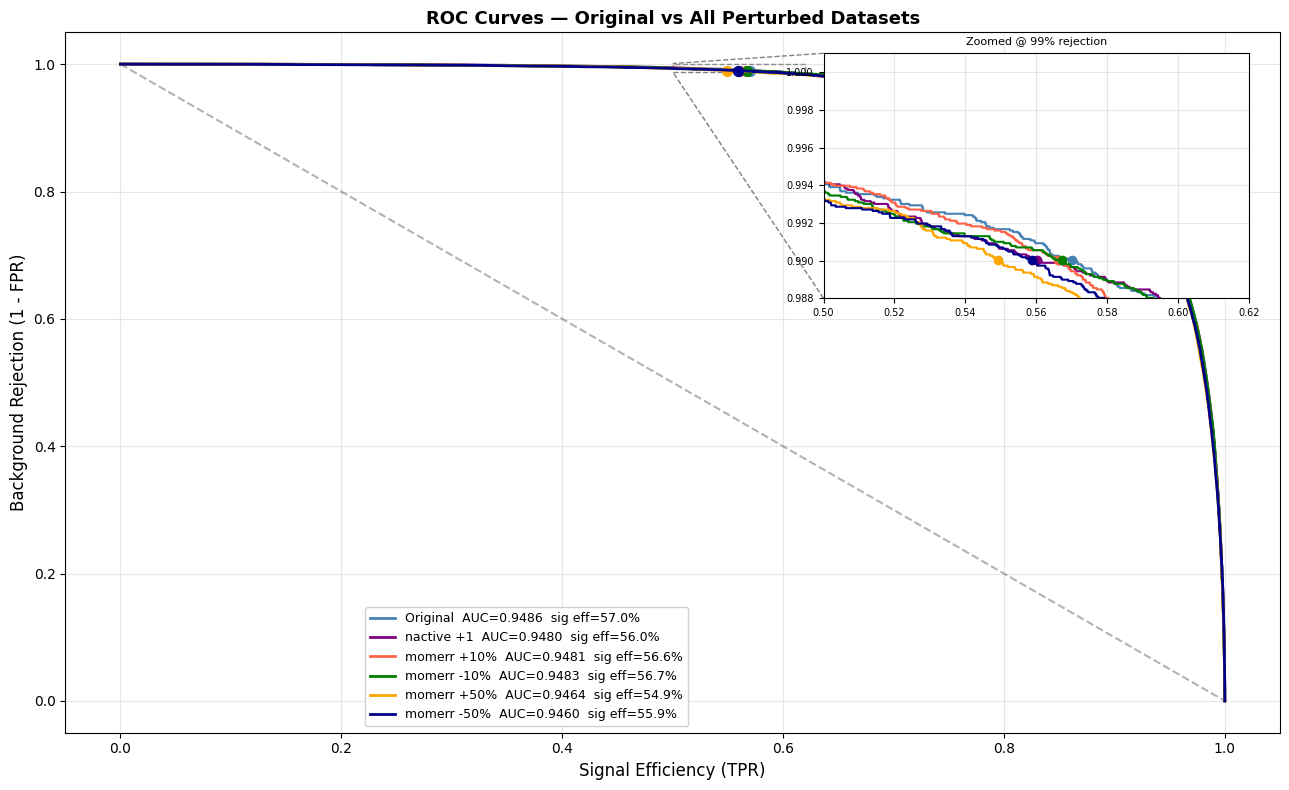

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

datasets_roc = [
    (y_pred_original_full,   y_full, 'Original',     'steelblue'),
    (y_pred_perturbed_full,  y_full, 'nactive +1',   'purple'),
    (y_pred_momerr_up,       y_full, 'momerr +10%',  'tomato'),
    (y_pred_momerr_down,     y_full, 'momerr -10%',  'green'),
    (y_pred_momerr_up50,     y_full, 'momerr +50%',  'orange'),
    (y_pred_momerr_down50,   y_full, 'momerr -50%',  'darkblue'),
]

rej_target = 0.99

fig, ax = plt.subplots(figsize=(13, 8))
ax.plot([0, 1], [1, 0], 'k--', alpha=0.3)

# Inset — moved to upper right to avoid legend overlap
ax_ins = inset_axes(ax, width="35%", height="35%", loc='upper right',
                    bbox_to_anchor=(-0.02, -0.02, 1, 1),
                    bbox_transform=ax.transAxes)

for scores, labels, name, color in datasets_roc:
    fpr, tpr, thresholds = roc_curve(labels, scores, pos_label=1)
    auc_score = auc(fpr, tpr)

    indices = np.where(1 - fpr >= rej_target)[0]
    cut_idx = indices[-1] if len(indices) > 0 else 0
    sig_eff = tpr[cut_idx]
    opt_cut = thresholds[cut_idx]

    # Main plot — include AUC and signal efficiency in label
    ax.plot(tpr, 1 - fpr, color=color, linewidth=2,
            label=f"{name}  AUC={auc_score:.4f}  sig eff={sig_eff*100:.1f}%")
    ax.plot(tpr[cut_idx], 1 - fpr[cut_idx], 'o', color=color, markersize=7)

    # Inset
    ax_ins.plot(tpr, 1 - fpr, color=color, linewidth=1.5)
    ax_ins.plot(tpr[cut_idx], 1 - fpr[cut_idx], 'o', color=color, markersize=6)

# Inset zoom — centered around all marker positions
ax_ins.set_xlim(0.50, 0.62)
ax_ins.set_ylim(0.988, 1.001)
ax_ins.set_title("Zoomed @ 99% rejection", fontsize=8)
ax_ins.tick_params(labelsize=7)
ax_ins.grid(alpha=0.3)
mark_inset(ax, ax_ins, loc1=2, loc2=3, fc="none", ec="0.5", ls="--")

ax.set_xlabel("Signal Efficiency (TPR)", fontsize=12)
ax.set_ylabel("Background Rejection (1 - FPR)", fontsize=12)
ax.set_title("ROC Curves — Original vs All Perturbed Datasets", fontsize=13, fontweight='bold')

# Legend at bottom to avoid overlap with inset
ax.legend(loc='lower center', bbox_to_anchor=(0.38, 0.0),
          fontsize=9, ncol=1, framealpha=0.9)
ax.grid(alpha=0.3)

plt.tight_layout()
#plt.savefig("roc_all_datasets_final.png", dpi=150, bbox_inches='tight')
plt.show()

/var/folders/p0/qdf2tryn1sd4_kf_28ckgz640000gn/T/ipykernel_9192/949339724.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


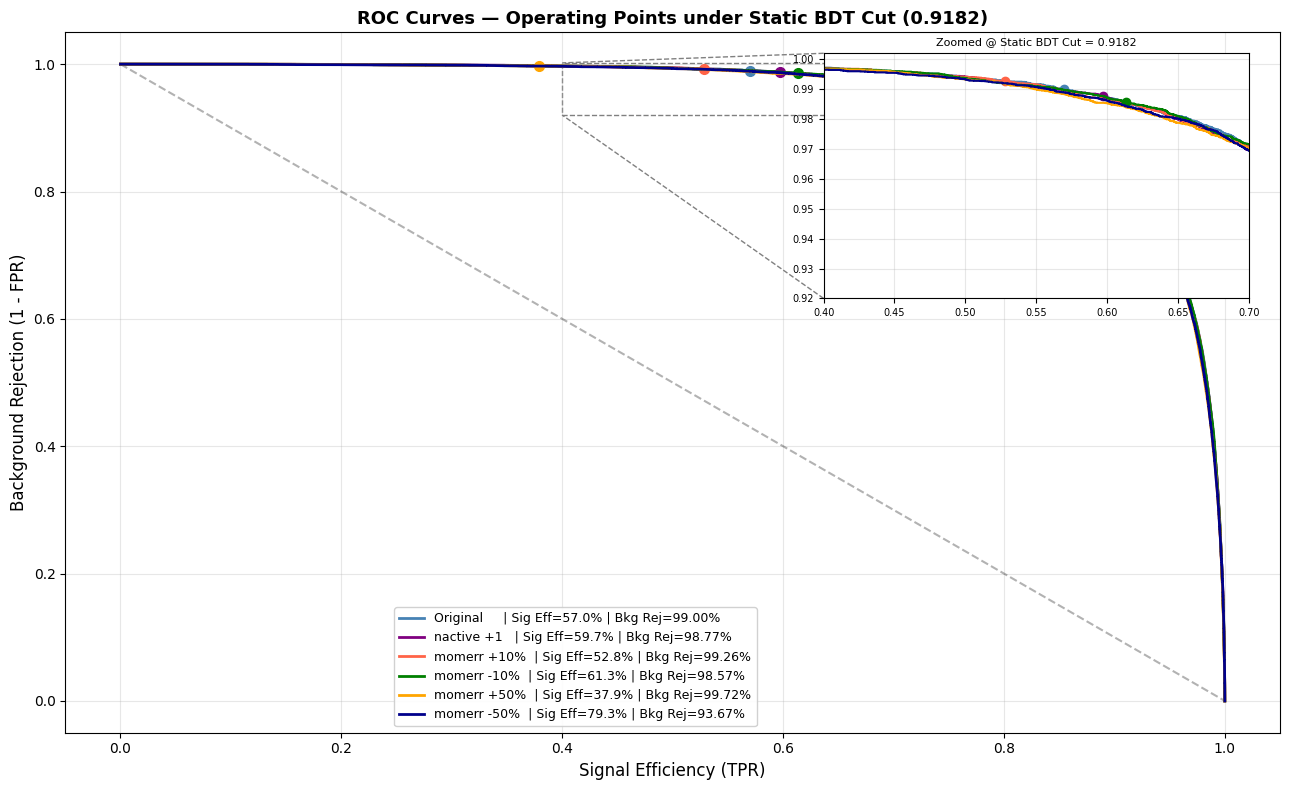

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

datasets_roc = [
    (y_pred_original_full, y_full, 'Original', 'steelblue'),
    (y_pred_perturbed_full, y_full, 'nactive +1', 'purple'),
    (y_pred_momerr_up, y_full, 'momerr +10%', 'tomato'),
    (y_pred_momerr_down, y_full, 'momerr -10%', 'green'),
    (y_pred_momerr_up50, y_full, 'momerr +50%', 'orange'),
    (y_pred_momerr_down50, y_full, 'momerr -50%', 'darkblue'),
]

# Fixed static cut value as the common target anchor
static_cut_target = 0.9182

fig, ax = plt.subplots(figsize=(13, 8))
ax.plot([0, 1], [1, 0], 'k--', alpha=0.3)

# Inset configuration
ax_ins = inset_axes(ax, width="35%", height="35%", loc='upper right', 
                    bbox_to_anchor=(-0.02, -0.02, 1, 1), bbox_transform=ax.transAxes)

for scores, labels, name, color in datasets_roc:
    fpr, tpr, thresholds = roc_curve(labels, scores, pos_label=1)
    auc_score = auc(fpr, tpr)
    
    # Find the exact index where the threshold crosses the static 0.9182 value
    indices = np.where(thresholds >= static_cut_target)[0]
    cut_idx = indices[-1] if len(indices) > 0 else 0
    
    # Extract metrics at this specific static point
    sig_eff_static = tpr[cut_idx]
    bkg_rej_static = 1 - fpr[cut_idx]
    
    # --- FIXED LABELS: Displays both metrics explicitly at the 0.9182 cut ---
    ax.plot(tpr, 1 - fpr, color=color, linewidth=2, 
            label=f"{name:<12} | Sig Eff={sig_eff_static*100:.1f}% | Bkg Rej={bkg_rej_static*100:.2f}%")
    ax.plot(tpr[cut_idx], 1 - fpr[cut_idx], 'o', color=color, markersize=7)
    
    # Inset plot
    ax_ins.plot(tpr, 1 - fpr, color=color, linewidth=1.5)
    ax_ins.plot(tpr[cut_idx], 1 - fpr[cut_idx], 'o', color=color, markersize=6)

# Adjusted Zoom Window parameters to capture the scattered points cleanly
ax_ins.set_xlim(0.40, 0.70)
ax_ins.set_ylim(0.920, 1.002) # Widened further to see the massive 93.67% drop clearly
ax_ins.set_title("Zoomed @ Static BDT Cut = 0.9182", fontsize=8)
ax_ins.tick_params(labelsize=7)
ax_ins.grid(alpha=0.3)
mark_inset(ax, ax_ins, loc1=2, loc2=3, fc="none", ec="0.5", ls="--")

ax.set_xlabel("Signal Efficiency (TPR)", fontsize=12)
ax.set_ylabel("Background Rejection (1 - FPR)", fontsize=12)
ax.set_title("ROC Curves — Operating Points under Static BDT Cut (0.9182)", fontsize=13, fontweight='bold')

ax.legend(loc='lower center', bbox_to_anchor=(0.42, 0.0), fontsize=9, ncol=1, framealpha=0.9)
ax.grid(alpha=0.3)
plt.tight_layout()

/var/folders/p0/qdf2tryn1sd4_kf_28ckgz640000gn/T/ipykernel_9192/1453914273.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


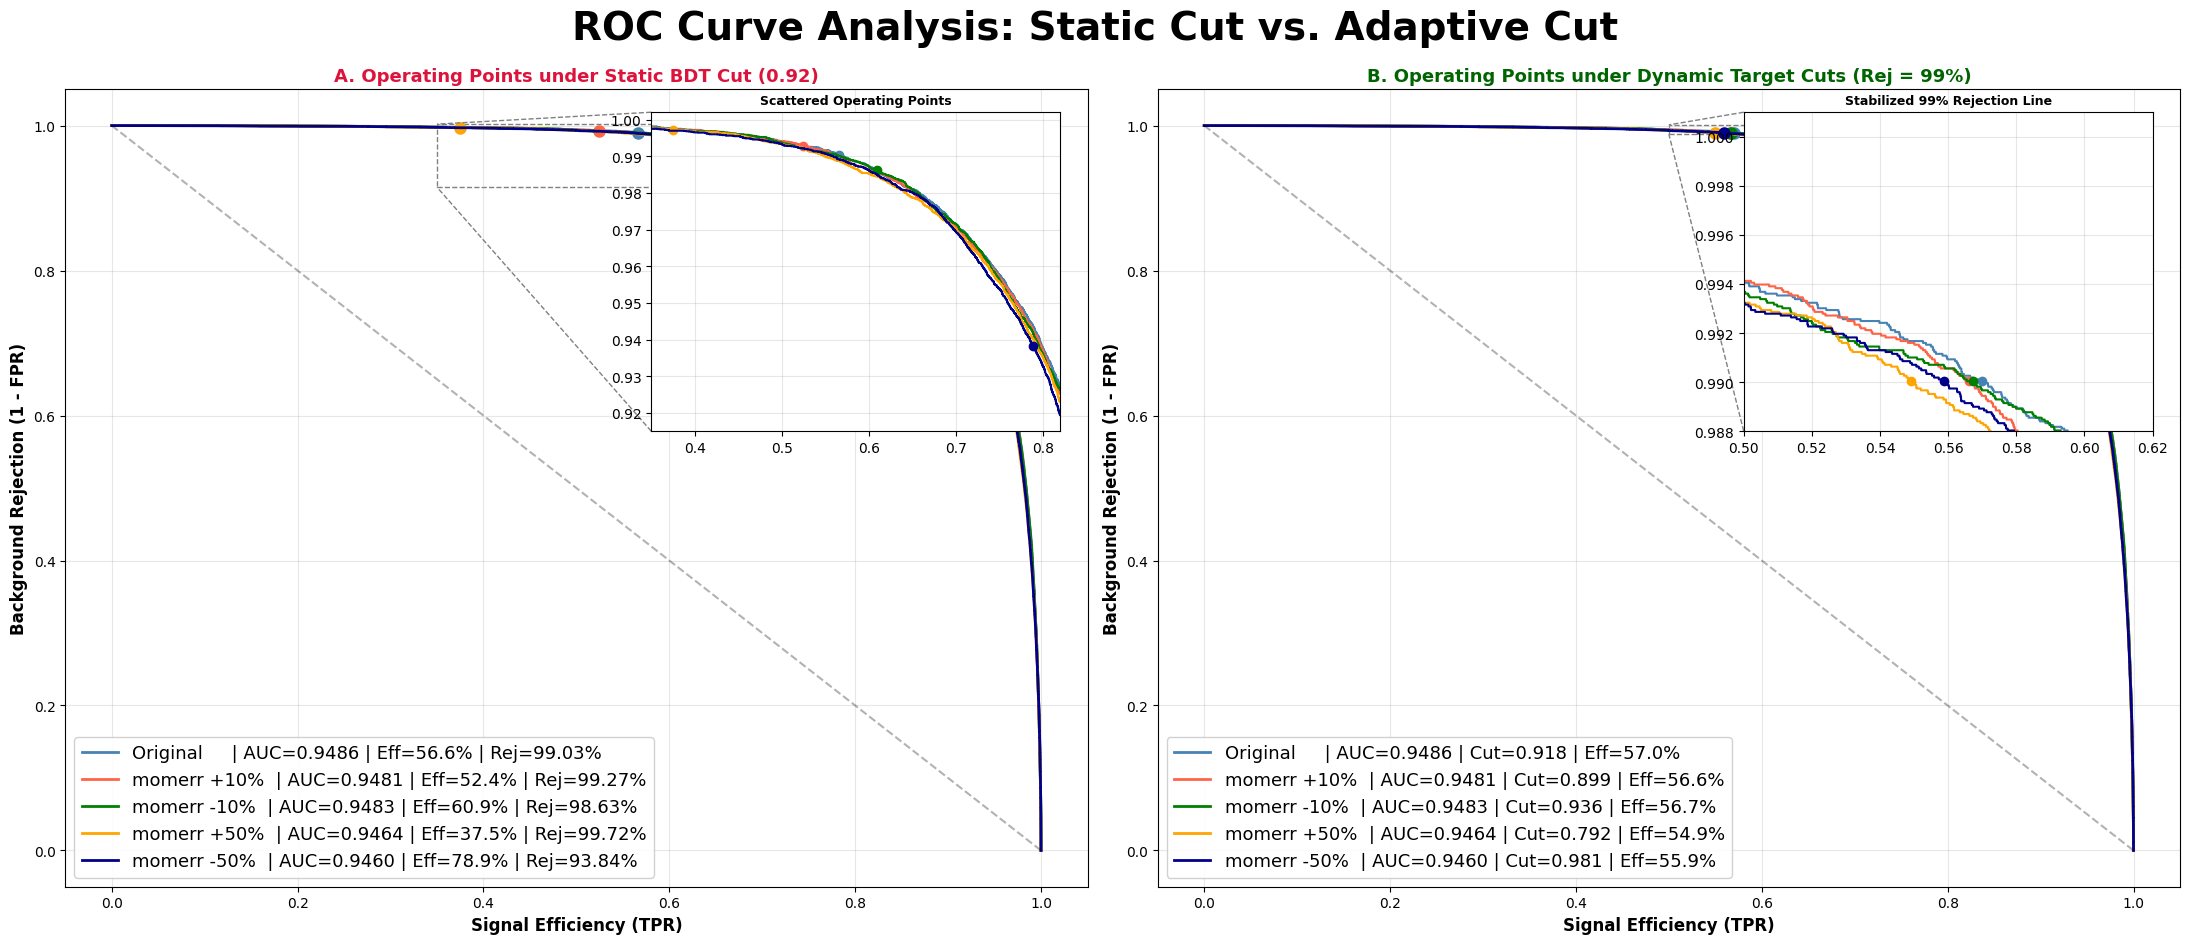

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# 1. Define dataset configurations
datasets_roc = [
    (y_pred_original_full, y_full, 'Original', 'steelblue'),
    #(y_pred_perturbed_full, y_full, 'nactive +1', 'purple'),
    (y_pred_momerr_up, y_full, 'momerr +10%', 'tomato'),
    (y_pred_momerr_down, y_full, 'momerr -10%', 'green'),
    (y_pred_momerr_up50, y_full, 'momerr +50%', 'orange'),
    (y_pred_momerr_down50, y_full, 'momerr -50%', 'darkblue'),
]

static_cut_target = 0.92
rej_target = 0.99

# 2. Initialize side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 10)) # Slightly wider to prevent text squeezing
fig.suptitle("ROC Curve Analysis: Static Cut vs. Adaptive Cut", fontsize=28, fontweight='bold', y=0.94)

# Setup shared insets for both panels
ax_ins1 = inset_axes(ax1, width="40%", height="40%", loc='upper right', bbox_to_anchor=(-0.02, -0.02, 1, 1), bbox_transform=ax1.transAxes)
ax_ins2 = inset_axes(ax2, width="40%", height="40%", loc='upper right', bbox_to_anchor=(-0.02, -0.02, 1, 1), bbox_transform=ax2.transAxes)

# 3. Loop through data to plot Left Panel (Static Cut) and Right Panel (Dynamic Threshold)
for scores, labels, name, color in datasets_roc:
    fpr, tpr, thresholds = roc_curve(labels, scores, pos_label=1)
    auc_score = auc(fpr, tpr)
    
    # --- LEFT PANEL: STATIC CUT SELECTION ---
    indices_static = np.where(thresholds >= static_cut_target)[0]
    idx_stat = indices_static[-1] if len(indices_static) > 0 else 0 # Explicitly target the 1D index element
    sig_eff_stat = float(tpr[idx_stat])
    bkg_rej_stat = float(1 - fpr[idx_stat])
    
    # Included AUC score into the text block string format
    ax1.plot(tpr, 1 - fpr, color=color, linewidth=2, 
             label=f"{name:<12} | AUC={auc_score:.4f} | Eff={sig_eff_stat*100:.1f}% | Rej={bkg_rej_stat*100:.2f}%")
    ax1.plot(tpr[idx_stat], 1 - fpr[idx_stat], 'o', color=color, markersize=8)
    ax_ins1.plot(tpr, 1 - fpr, color=color, linewidth=1.5)
    ax_ins1.plot(tpr[idx_stat], 1 - fpr[idx_stat], 'o', color=color, markersize=6)
    
    # --- RIGHT PANEL: DYNAMIC ADAPTIVE SELECTION ---
    indices_dyn = np.where(1 - fpr >= rej_target)[0]
    idx_dyn = indices_dyn[-1] if len(indices_dyn) > 0 else 0 # Explicitly target the 1D index element
    sig_eff_dyn = float(tpr[idx_dyn])
    opt_cut = float(thresholds[idx_dyn])
    
    # Included AUC score into the text block string format
    ax2.plot(tpr, 1 - fpr, color=color, linewidth=2, 
             label=f"{name:<12} | AUC={auc_score:.4f} | Cut={opt_cut:.3f} | Eff={sig_eff_dyn*100:.1f}%")
    ax2.plot(tpr[idx_dyn], 1 - fpr[idx_dyn], 'o', color=color, markersize=8)
    ax_ins2.plot(tpr, 1 - fpr, color=color, linewidth=1.5)
    ax_ins2.plot(tpr[idx_dyn], 1 - fpr[idx_dyn], 'o', color=color, markersize=6)

# 4. Format Left Subplot (Static Cut)
ax1.plot([0, 1], [1, 0], 'k--', alpha=0.3)
ax1.set_xlabel("Signal Efficiency (TPR)", fontsize=12, fontweight='bold')
ax1.set_ylabel("Background Rejection (1 - FPR)", fontsize=12, fontweight='bold')
ax1.set_title("A. Operating Points under Static BDT Cut (0.92)", fontsize=13, fontweight='bold', color='crimson')
ax1.grid(alpha=0.3)
ax1.legend(loc='lower left', fontsize=13, framealpha=0.9)

ax_ins1.set_xlim(0.35, 0.82)
ax_ins1.set_ylim(0.915, 1.002)
ax_ins1.set_title("Scattered Operating Points", fontsize=9, fontweight='bold')
ax_ins1.grid(alpha=0.3)
mark_inset(ax1, ax_ins1, loc1=2, loc2=3, fc="none", ec="0.5", ls="--")

# 5. Format Right Subplot (Dynamic Thresholds)
ax2.plot([0, 1], [1, 0], 'k--', alpha=0.3)
ax2.set_xlabel("Signal Efficiency (TPR)", fontsize=12, fontweight='bold')
ax2.set_ylabel("Background Rejection (1 - FPR)", fontsize=12, fontweight='bold')
ax2.set_title("B. Operating Points under Dynamic Target Cuts (Rej = 99%)", fontsize=13, fontweight='bold', color='darkgreen')
ax2.grid(alpha=0.3)
ax2.legend(loc='lower left', fontsize=13, framealpha=0.9)

ax_ins2.set_xlim(0.50, 0.62)
ax_ins2.set_ylim(0.988, 1.001)
ax_ins2.set_title("Stabilized 99% Rejection Line", fontsize=9, fontweight='bold')
ax_ins2.grid(alpha=0.3)
mark_inset(ax2, ax_ins2, loc1=2, loc2=3, fc="none", ec="0.5", ls="--")

plt.tight_layout(rect=[0, 0, 1, 0.95])
# plt.savefig("roc_regime_comparison_side_by_side_auc_fixed.png", dpi=200, bbox_inches='tight')
plt.show()

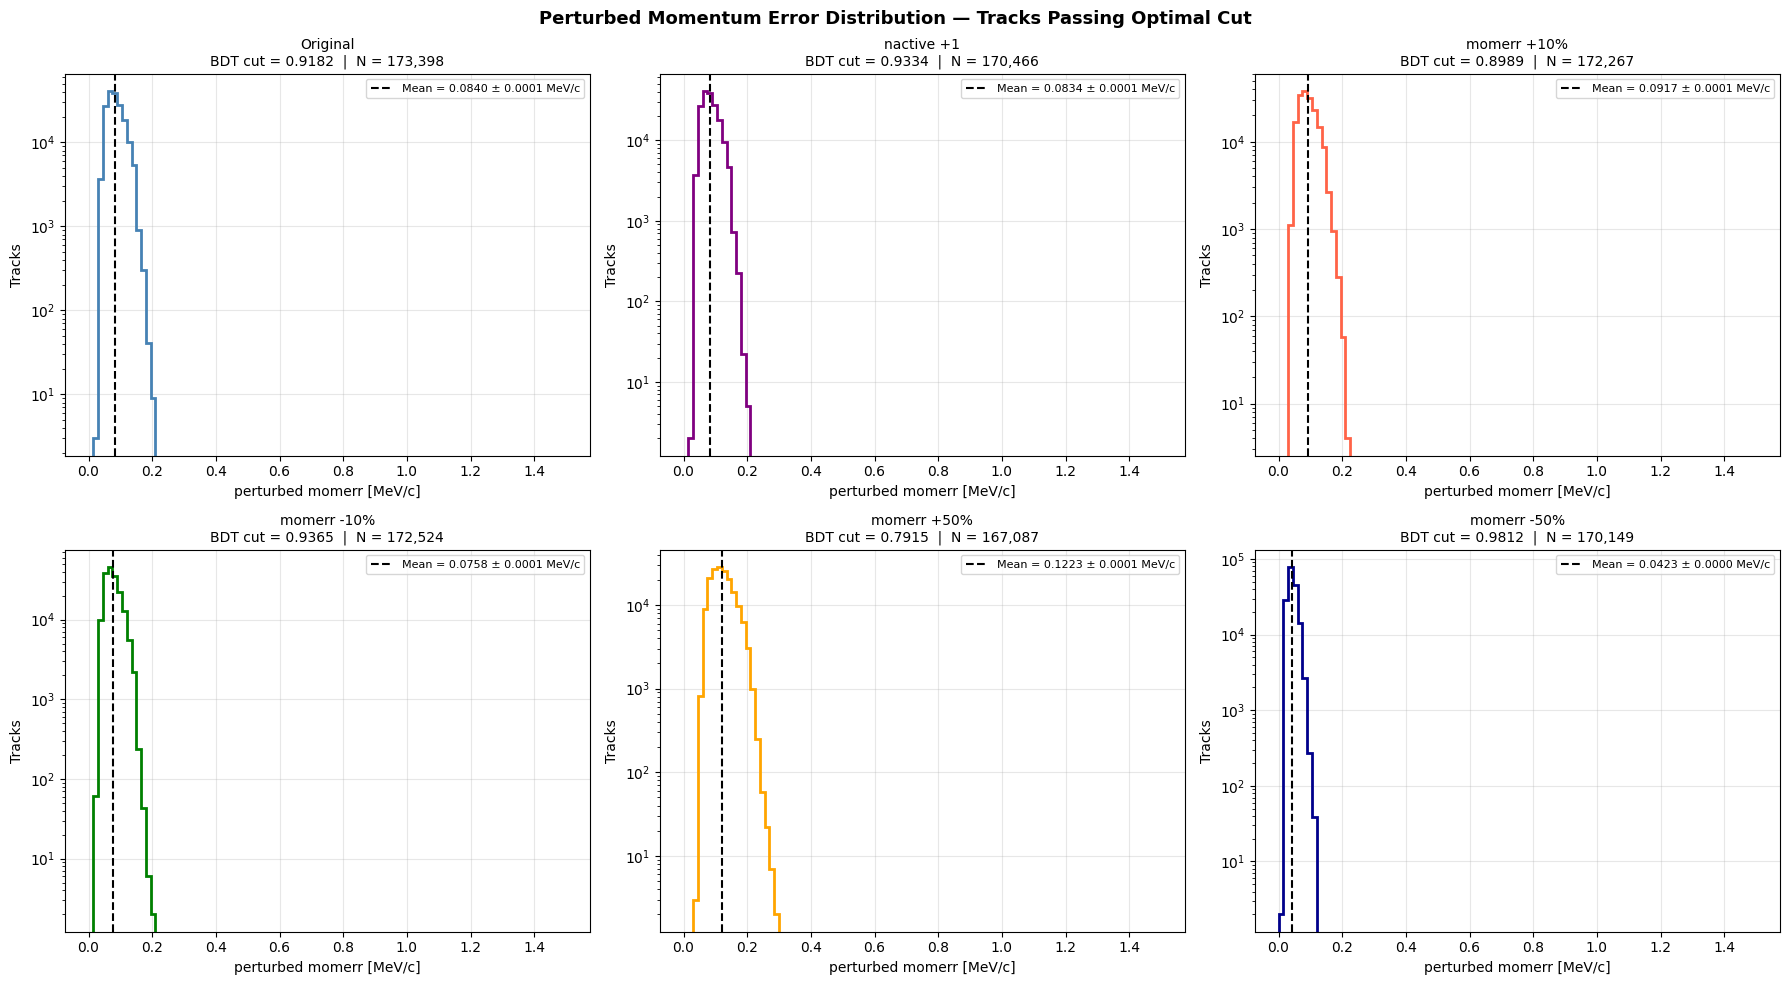

Dataset                      BDT cut   N passing   mean momerr       ± σ
----------------------------------------------------------------------
Original                      0.9182     173,398        0.0840    0.0001
nactive +1                    0.9334     170,466        0.0834    0.0001
momerr +10%                   0.8989     172,267        0.0917    0.0001
momerr -10%                   0.9365     172,524        0.0758    0.0001
momerr +50%                   0.7915     167,087        0.1223    0.0001
momerr -50%                   0.9812     170,149        0.0423    0.0000


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Perturbed Momentum Error Distribution — Tracks Passing Optimal Cut",
             fontsize=13, fontweight='bold')

# Unperturbed base array
momerr_base = x_full[:, momerr_idx]

# Added a 5th element to the tuple: the scaling/perturbation factor
studies = [
    # (label, scores, cut, color, perturbation_factor)
    ('Original',    y_pred_original_full,  0.9182, 'steelblue', 1.0),
    ('nactive +1',  y_pred_perturbed_full, 0.9334, 'purple',    1.0),  # nactive doesn't change momerr
    ('momerr +10%', y_pred_momerr_up,      0.8989, 'tomato',    1.1),
    ('momerr -10%', y_pred_momerr_down,    0.9365, 'green',     0.9),
    ('momerr +50%', y_pred_momerr_up50,    0.7915, 'orange',    1.5),
    ('momerr -50%', y_pred_momerr_down50,  0.9812, 'darkblue',  0.5),
]

for ax, (label, scores, cut, color, factor) in zip(axes.flatten(), studies):
    # Apply the specific perturbation factor to the momerr variable
    momerr_perturbed = momerr_base * factor
    
    mask  = scores >= cut
    N     = mask.sum()
    m     = momerr_perturbed[mask].mean()
    sigma = momerr_perturbed[mask].std() / np.sqrt(N)

    ax.hist(momerr_perturbed[mask], bins=100, range=(0, 1.5), log=True, 
            histtype='step', color=color, linewidth=2)
    ax.axvline(m, color='black', linestyle='--', linewidth=1.5,
               label=f"Mean = {m:.4f} ± {sigma:.4f} MeV/c")
    ax.set_title(f"{label}\nBDT cut = {cut:.4f}  |  N = {N:,}", fontsize=10)
    ax.set_xlabel("perturbed momerr [MeV/c]")
    ax.set_ylabel("Tracks")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary table with the perturbed tracking metrics
print(f"{'Dataset':<25} {'BDT cut':>10}  {'N passing':>10}  {'mean momerr':>12}  {'± σ':>8}")
print("-" * 70)
for label, scores, cut, color, factor in studies:
    momerr_perturbed = momerr_base * factor
    mask  = scores >= cut
    N     = mask.sum()
    m     = momerr_perturbed[mask].mean()
    sigma = momerr_perturbed[mask].std() / np.sqrt(N)
    print(f"{label:<25} {cut:>10.4f}  {N:>10,}  {m:>12.4f}  {sigma:>8.4f}")


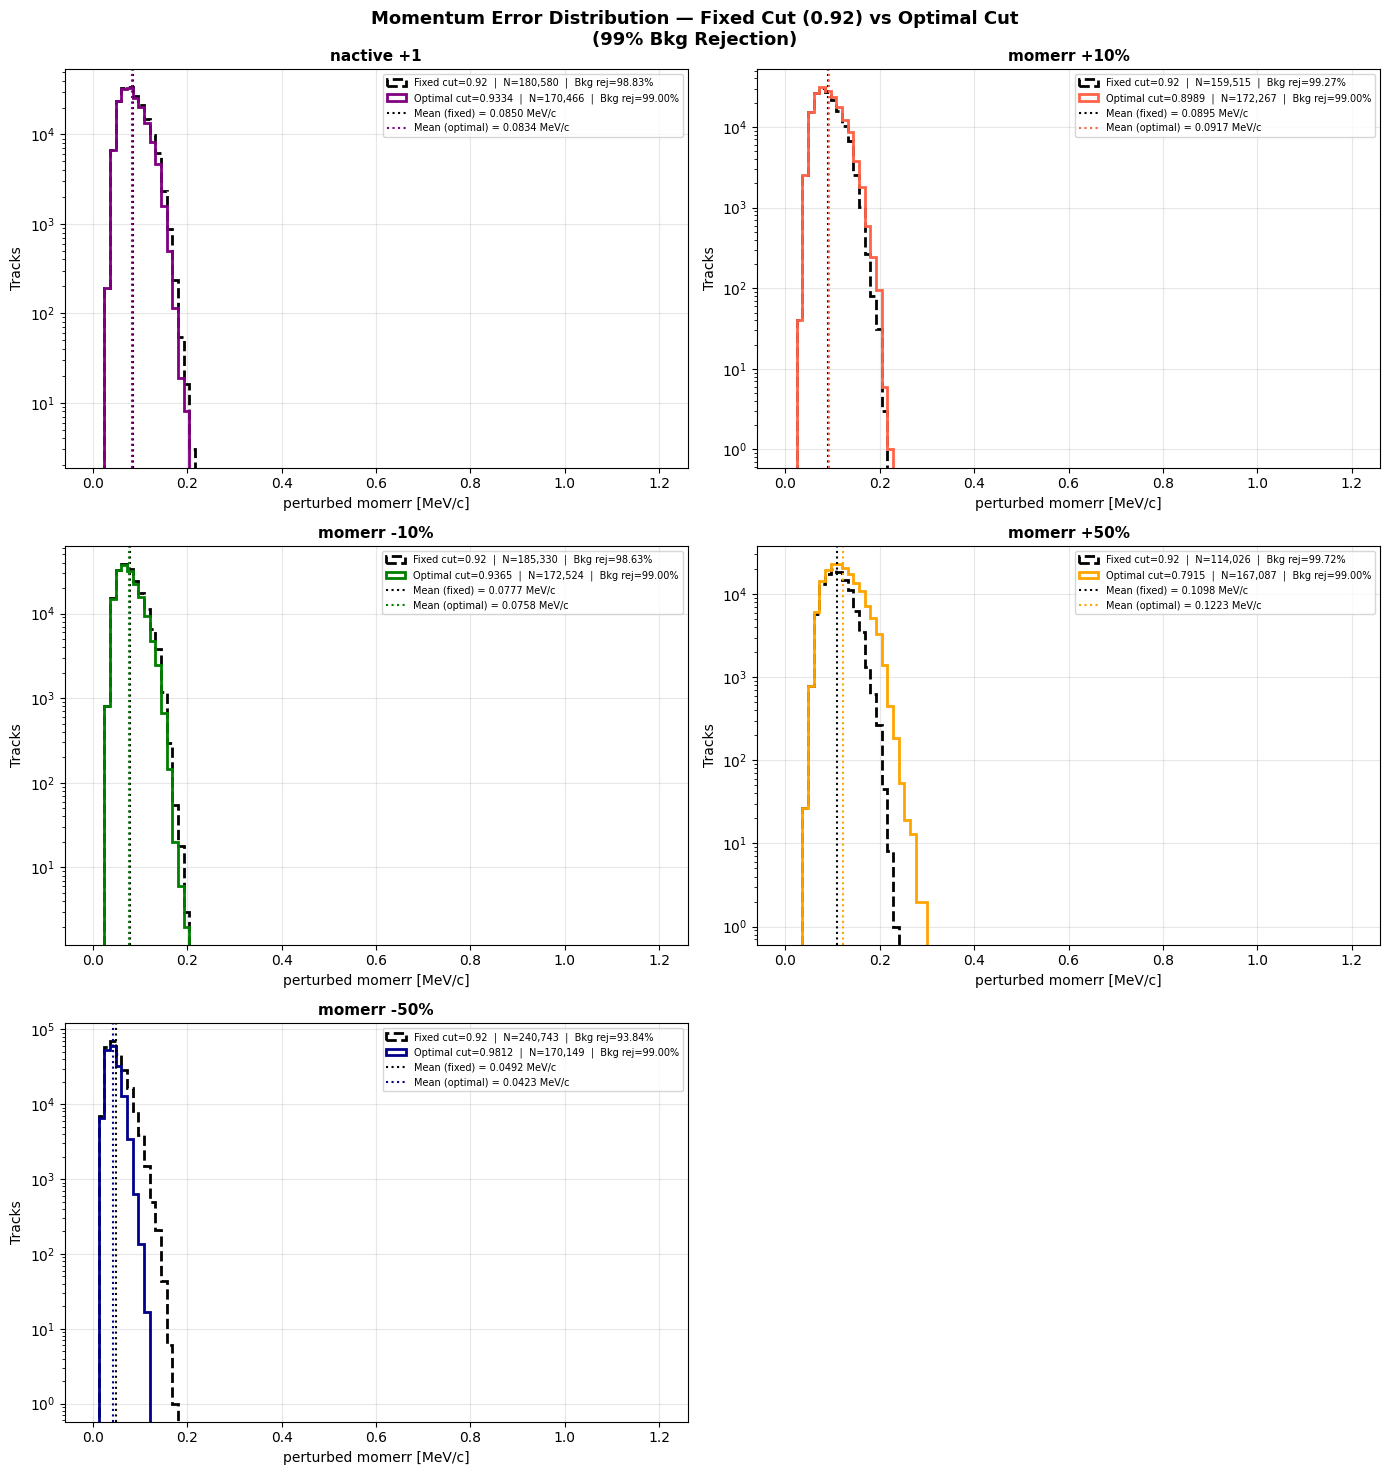

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(14, 15))
fig.suptitle("Momentum Error Distribution — Fixed Cut (0.92) vs Optimal Cut\n(99% Bkg Rejection)",
             fontsize=13, fontweight='bold')

# Base array before scaling
momerr_base = x_full[:, momerr_idx]
fixed_cut   = 0.92

# Added the 5th element (the factor) to match the real perturbations
studies = [
    ('nactive +1',  y_pred_perturbed_full, 0.9334, 'purple',    1.0),
    ('momerr +10%', y_pred_momerr_up,      0.8989, 'tomato',    1.1),
    ('momerr -10%', y_pred_momerr_down,    0.9365, 'green',     0.9),
    ('momerr +50%', y_pred_momerr_up50,    0.7915, 'orange',    1.5),
    ('momerr -50%', y_pred_momerr_down50,  0.9812, 'darkblue',  0.5),
]

for idx, (label, scores, opt_cut, color, factor) in enumerate(studies):
    row = idx // 2
    col = idx % 2
    ax  = axes[row, col]

    # Create the GENUINE perturbed variable for this specific panel
    momerr_perturbed = momerr_base * factor

    # Fixed cut applied to perturbed data
    mask_fixed = scores >= fixed_cut
    N_fixed    = mask_fixed.sum()
    m_fixed    = momerr_perturbed[mask_fixed].mean()
    bkg_fixed  = 1 - (((scores >= fixed_cut) & (y_full == 0)).sum() / (y_full == 0).sum())

    # Optimal cut applied to perturbed data
    mask_opt = scores >= opt_cut
    N_opt    = mask_opt.sum()
    m_opt    = momerr_perturbed[mask_opt].mean()
    bkg_opt  = 1 - (((scores >= opt_cut) & (y_full == 0)).sum() / (y_full == 0).sum())

    # Plot both overlapped using the perturbed data (Notice the range is extended to 1.2)
    ax.hist(momerr_perturbed[mask_fixed], bins=100, range=(0, 1.2), log=True,
            histtype='step', color='black', linewidth=2, linestyle='--',
            label=f"Fixed cut=0.92  |  N={N_fixed:,}  |  Bkg rej={bkg_fixed*100:.2f}%")
    ax.hist(momerr_perturbed[mask_opt], bins=100, range=(0, 1.2), log=True,
            histtype='step', color=color, linewidth=2, linestyle='-',
            label=f"Optimal cut={opt_cut:.4f}  |  N={N_opt:,}  |  Bkg rej={bkg_opt*100:.2f}%")

    # Mean lines mapping the real perturbed averages
    ax.axvline(m_fixed, color='black', linestyle=':', linewidth=1.5,
               label=f"Mean (fixed) = {m_fixed:.4f} MeV/c")
    ax.axvline(m_opt, color=color, linestyle=':', linewidth=1.5,
               label=f"Mean (optimal) = {m_opt:.4f} MeV/c")

    ax.set_title(f"{label}", fontsize=11, fontweight='bold')
    ax.set_xlabel("perturbed momerr [MeV/c]")
    ax.set_ylabel("Tracks")
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

# Hide last empty panel
axes[2, 1].axis('off')

plt.tight_layout()
plt.show()


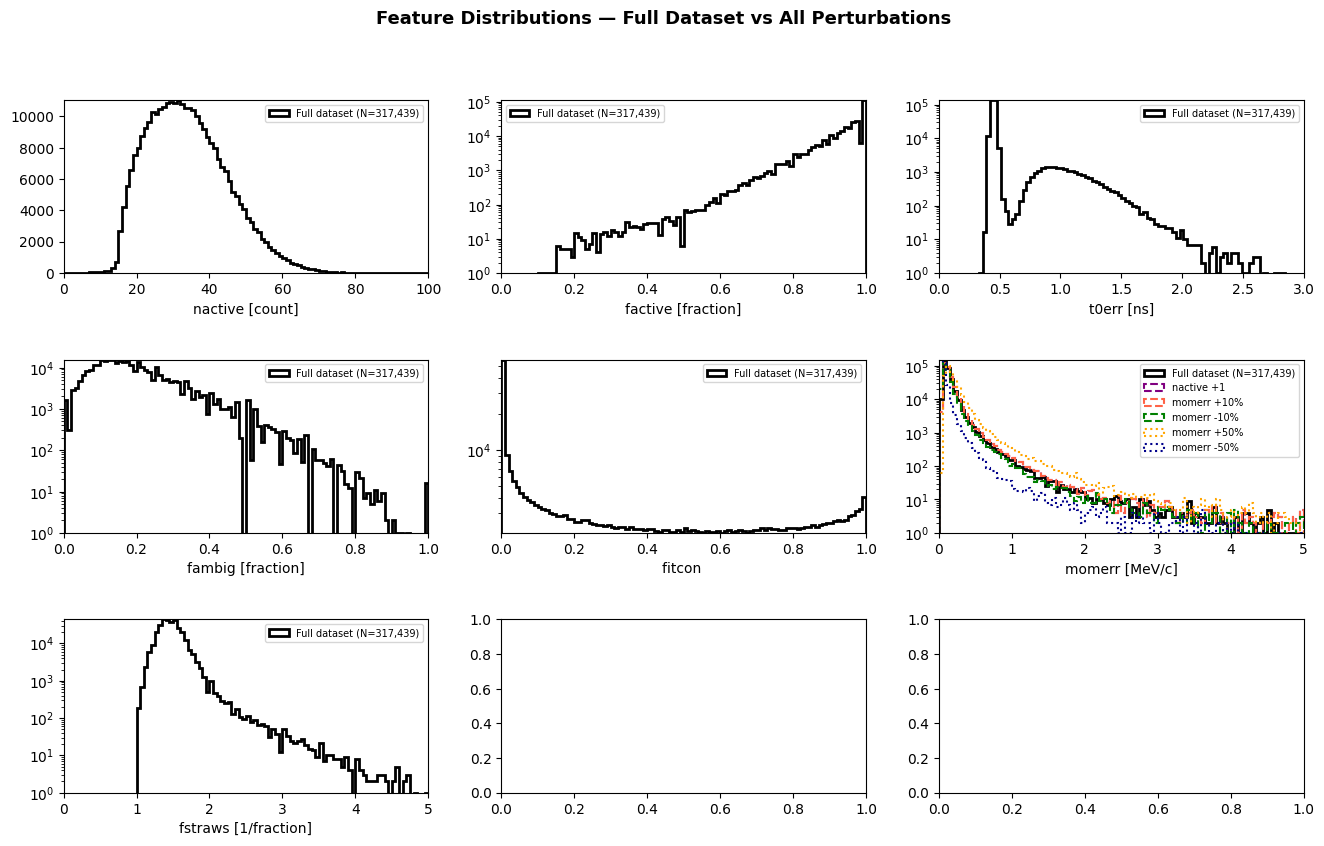

In [ ]:
fig, axs = plt.subplots(3, 3, figsize=(16, 9))
fig.subplots_adjust(hspace=.5)
fig.suptitle("Feature Distributions — Full Dataset vs All Perturbations", fontsize=13, fontweight='bold')

for i_var in range(n_input_vars):
    ax = axs.flatten()[i_var]
    ax.hist(x_full[:, i_var], bins=100, range=(x_mins[i_var], x_maxs[i_var]),
            histtype='step', color='black', log=log_ys[i_var],
            label=f'Full dataset (N={len(x_full):,})', linewidth=2.0)
    if i_var == momerr_idx:
        ax.hist(x_up[:, i_var], bins=100, range=(x_mins[i_var], x_maxs[i_var]),
                histtype='step', color='purple', log=log_ys[i_var],
                label='nactive +1', linestyle='--', linewidth=1.5)
        ax.hist(x_momerr_up[:, i_var], bins=100, range=(x_mins[i_var], x_maxs[i_var]),
                histtype='step', color='tomato', log=log_ys[i_var],
                label='momerr +10%', linestyle='--', linewidth=1.5)
        ax.hist(x_momerr_down[:, i_var], bins=100, range=(x_mins[i_var], x_maxs[i_var]),
                histtype='step', color='green', log=log_ys[i_var],
                label='momerr -10%', linestyle='--', linewidth=1.5)
        ax.hist(x_up50[:, i_var], bins=100, range=(x_mins[i_var], x_maxs[i_var]),
                histtype='step', color='orange', log=log_ys[i_var],
                label='momerr +50%', linestyle=':', linewidth=1.5)
        ax.hist(x_down50[:, i_var], bins=100, range=(x_mins[i_var], x_maxs[i_var]),
                histtype='step', color='darkblue', log=log_ys[i_var],
                label='momerr -50%', linestyle=':', linewidth=1.5)
    ax.set_xlabel(input_var_names[i_var] + " " + units[i_var])
    ax.margins(0)
    ax.legend(fontsize=7)

#plt.savefig("feature_distributions_all_perturbations.png", dpi=150, bbox_inches='tight')
plt.show()

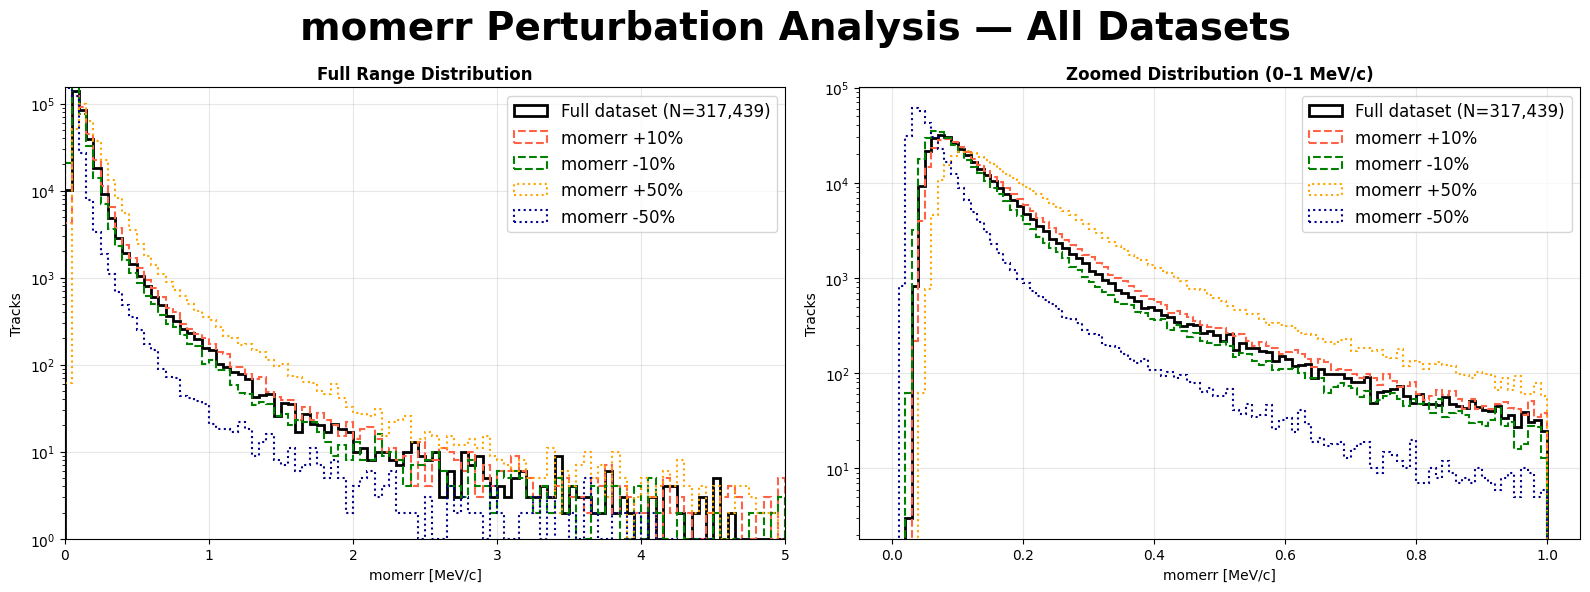

In [ ]:
# Combined momerr Distribution: Full Range and Zoomed
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
i = momerr_idx

plot_params = [
    (x_full[:, i],        'black',    f'Full dataset (N={len(x_full):,})', '-',   2.0),
    #(x_up[:, i],          'purple',   'nactive +1',                        '--',  1.5),
    (x_momerr_up[:, i],   'tomato',   'momerr +10%',                       '--',  1.5),
    (x_momerr_down[:, i], 'green',    'momerr -10%',                       '--',  1.5),
    (x_up50[:, i],        'orange',   'momerr +50%',                       ':',   1.5),
    (x_down50[:, i],      'darkblue', 'momerr -50%',                       ':',   1.5),
]

for ax in [ax1, ax2]:
    for data, color, label, style, lw in plot_params:
        ax.hist(data, bins=100,
                range=(x_mins[i], x_maxs[i]) if ax == ax1 else (0, 1.0),
                histtype='step', color=color, log=True,
                label=label, linestyle=style, linewidth=lw)
    ax.set_ylabel("Tracks")
    ax.legend(fontsize=12)
    ax.grid(alpha=0.3)

ax1.set_title("Full Range Distribution", fontweight='bold')
ax1.set_xlabel(f"{input_var_names[i]} {units[i]}")
ax1.margins(0)

ax2.set_title("Zoomed Distribution (0–1 MeV/c)", fontweight='bold')
ax2.set_xlabel("momerr [MeV/c]")

fig.suptitle("momerr Perturbation Analysis — All Datasets", fontsize=28, fontweight='bold')
plt.tight_layout()
#plt.savefig("momerr_combined_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

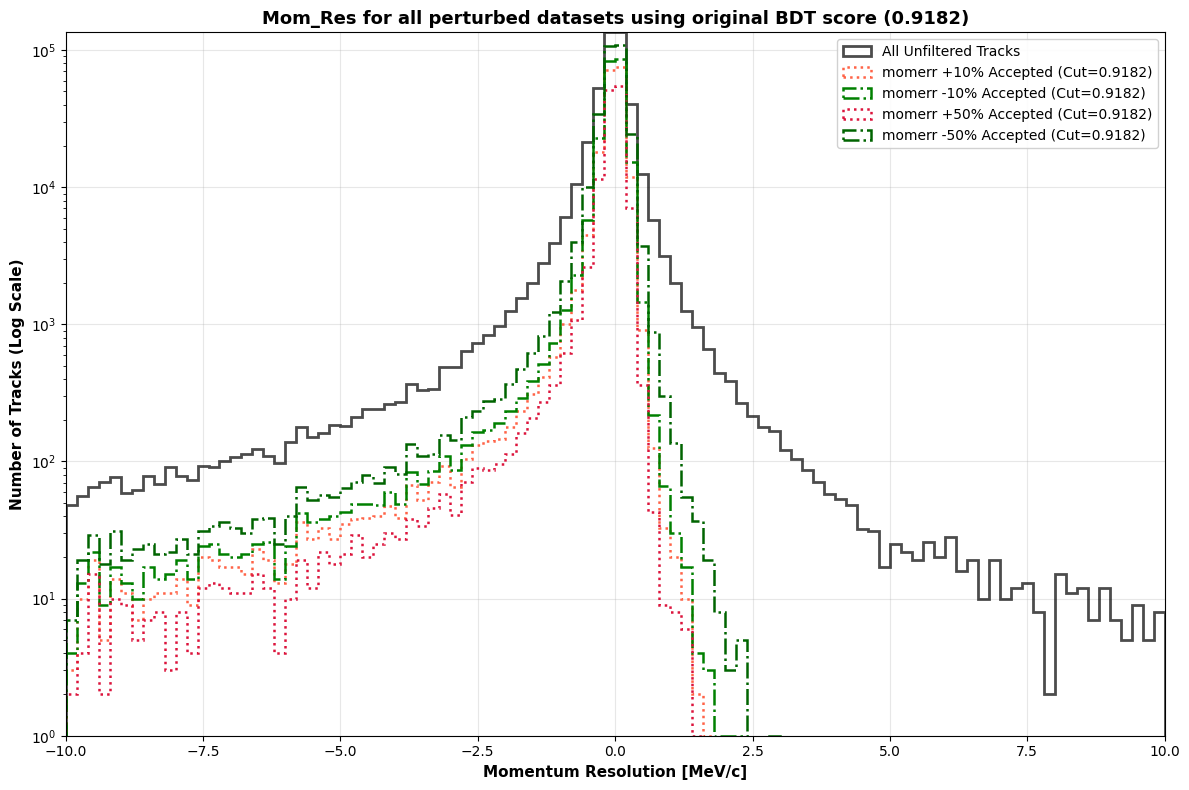

In [ ]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

# 1. Set the fixed reference cut from the Original dataset
static_cut = 0.9182

# 2. Load the base feature structures from the file
with uproot.open(training_dataset_filename) as f:
    tree = f[training_dataset_treename]
    arrays = tree.arrays(library="np")
    
    nactive_raw = arrays['trk.nactive']
    nhits       = arrays['trk.nhits']
    factive_raw = nactive_raw / nhits
    fambig_raw  = arrays['trk.nnullambig'] / nactive_raw
    fstraws_raw = arrays['trk.nmatactive'] / nactive_raw
    t0err       = arrays['trk_ent_pars.t0err']
    fitcon      = arrays['trk.fitcon']
    momerr_raw  = arrays['trk_ent.momerr']

# Dictionary to hold the dynamic configurations for each line
variations = {
    #'Original':    (nactive_raw,     momerr_raw,        'steelblue', '-'),
    #'nactive +1':  (nactive_raw + 1, momerr_raw,        'purple',    '--'),
    'momerr +10%': (nactive_raw,     momerr_raw * 1.10, 'tomato',    ':'),
    'momerr -10%': (nactive_raw,     momerr_raw * 0.90, 'green',     '-.'),
    'momerr +50%': (nactive_raw,     momerr_raw * 1.50, 'crimson',   ':'),
    'momerr -50%': (nactive_raw,     momerr_raw * 0.50, 'darkgreen', '-.'),
}

fig, ax = plt.subplots(figsize=(12, 8))

# 3. Plot the complete reference background baseline
ax.hist(mom_res, bins=n_mom_res_bins, range=(min_mom_res, max_mom_res), log=True, 
        histtype='step', color='black', label='All Unfiltered Tracks', linewidth=2.0, alpha=0.7)

# 4. Loop through each dataset configuration to compute and overlay its accepted tracks
for name, (nact, merr, color, linestyle) in variations.items():
    # Recalculate helper ratios based on the modified features
    f_act = nact / nhits
    f_amb = arrays['trk.nnullambig'] / nact
    f_str = arrays['trk.nmatactive'] / nact
    
    # Structure matrix and score
    x_matrix = np.vstack((nact, f_act, t0err, f_amb, fitcon, merr, f_str)).T
    scores = model.predict_proba(x_matrix)[:, 1]
    
    # Filter the global mom_res array using the static cut
    accepted_tracks = mom_res[scores >= static_cut]
    
    # Overlay the histogram line
    ax.hist(accepted_tracks, bins=n_mom_res_bins, range=(min_mom_res, max_mom_res), log=True, 
            histtype='step', color=color, label=f'{name} Accepted (Cut={static_cut})', 
            linestyle=linestyle, linewidth=1.8)

# Layout parameters
ax.legend(loc='upper right', fontsize=10, framealpha=0.9)
ax.margins(0)
ax.grid(True, alpha=0.3)
ax.set_xlabel("Momentum Resolution [MeV/c]", fontweight='bold', fontsize=11)
ax.set_ylabel("Number of Tracks (Log Scale)", fontweight='bold', fontsize=11)
ax.set_title(f"Mom_Res for all perturbed datasets using original BDT score ({static_cut})", fontsize=13, fontweight='bold')

plt.tight_layout()
# Clean up and reorder legend explicitly to look pro
handles, labels = ax.get_legend_handles_labels()
# Order them: Unfiltered -> Original -> 10% shifts -> 50% shifts
order = [0, 1, 2, 3, 4] #6 for nactive, #5 for the original cut 
ax.legend([handles[idx] for idx in order], [labels[idx] for idx in order], 
          loc='upper right', fontsize=10, framealpha=0.9)

plt.show()


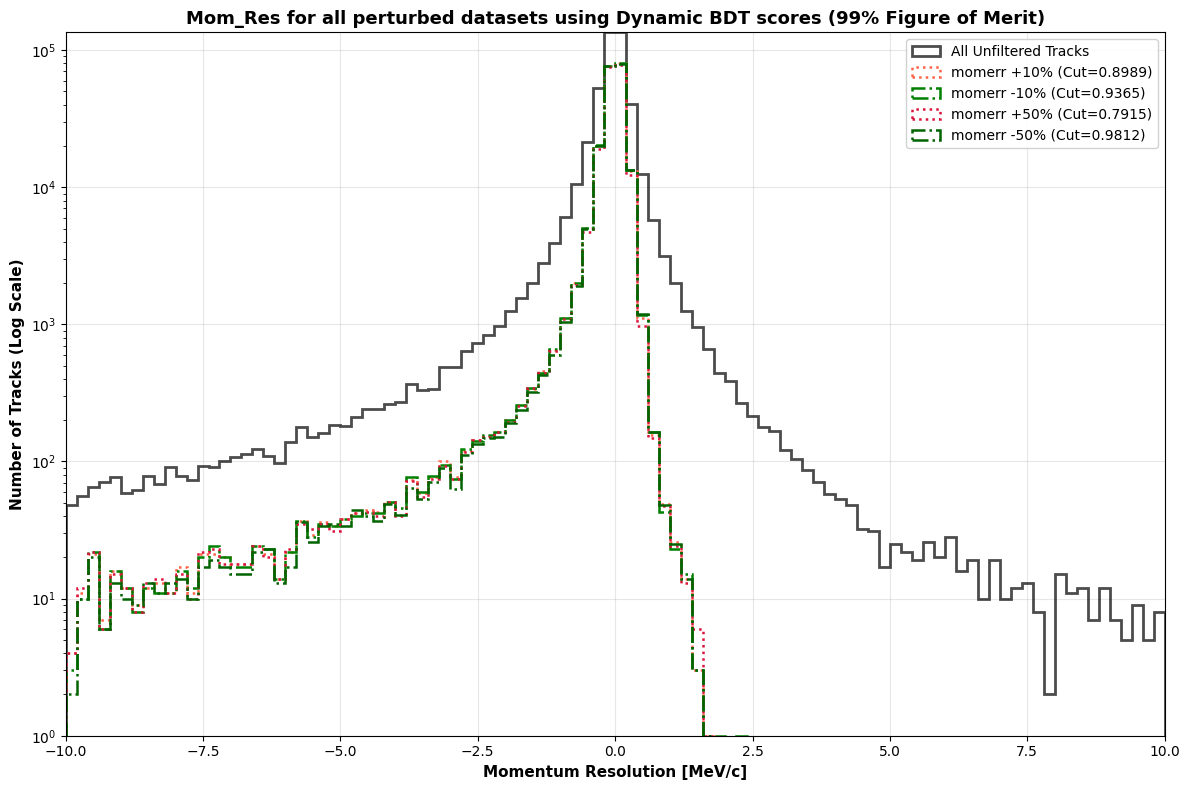

In [ ]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the base feature structures from the file
with uproot.open(training_dataset_filename) as f:
    tree = f[training_dataset_treename]
    arrays = tree.arrays(library="np")
    
    nactive_raw = arrays['trk.nactive']
    nhits       = arrays['trk.nhits']
    factive_raw = nactive_raw / nhits
    fambig_raw  = arrays['trk.nnullambig'] / nactive_raw
    fstraws_raw = arrays['trk.nmatactive'] / nactive_raw
    t0err       = arrays['trk_ent_pars.t0err']
    fitcon      = arrays['trk.fitcon']
    momerr_raw  = arrays['trk_ent.momerr']

# 2. Dictionary configured to hold features, colors, styles, AND specific optimal cuts
variations = {
    #'Original':    (nactive_raw,     momerr_raw,        'steelblue', '-',  0.9182),
    #'nactive +1':  (nactive_raw + 1, momerr_raw,        'purple',    '--', 0.9334),
    'momerr +10%': (nactive_raw,     momerr_raw * 1.10, 'tomato',    ':',  0.8989),
    'momerr -10%': (nactive_raw,     momerr_raw * 0.90, 'green',     '-.', 0.9365),
    'momerr +50%': (nactive_raw,     momerr_raw * 1.50, 'crimson',   ':',  0.7915),
    'momerr -50%': (nactive_raw,     momerr_raw * 0.50, 'darkgreen', '-.', 0.9812),
}

fig, ax = plt.subplots(figsize=(12, 8))

# 3. Plot the complete reference background baseline
ax.hist(mom_res, bins=n_mom_res_bins, range=(min_mom_res, max_mom_res), log=True, 
        histtype='step', color='black', label='All Unfiltered Tracks', linewidth=2.0, alpha=0.7)

# 4. Loop through each dataset configuration using its DYNAMIC cut value
for name, (nact, merr, color, linestyle, dynamic_cut) in variations.items():
    # Recalculate helper ratios based on the modified features
    f_act = nact / nhits
    f_amb = arrays['trk.nnullambig'] / nact
    f_str = arrays['trk.nmatactive'] / nact
    
    # Structure matrix and score
    x_matrix = np.vstack((nact, f_act, t0err, f_amb, fitcon, merr, f_str)).T
    scores = model.predict_proba(x_matrix)[:, 1]
    
    # Filter the global mom_res array using the unique dynamic cut
    accepted_tracks = mom_res[scores >= dynamic_cut]
    
    # Overlay the histogram line
    ax.hist(accepted_tracks, bins=n_mom_res_bins, range=(min_mom_res, max_mom_res), log=True, 
            histtype='step', color=color, label=f'{name} (Cut={dynamic_cut:.4f})', 
            linestyle=linestyle, linewidth=1.8)

# Layout parameters
ax.margins(0)
ax.grid(True, alpha=0.3)
ax.set_xlabel("Momentum Resolution [MeV/c]", fontweight='bold', fontsize=11)
ax.set_ylabel("Number of Tracks (Log Scale)", fontweight='bold', fontsize=11)
ax.set_title("Mom_Res for all perturbed datasets using Dynamic BDT scores (99% Figure of Merit)", fontsize=13, fontweight='bold')

# Clean up and reorder legend explicitly to look pro
handles, labels = ax.get_legend_handles_labels()
# Order them: Unfiltered -> Original -> 10% shifts -> 50% shifts
order = [0, 1, 2, 3, 4] #6 for nactive, #5 for the original cut 
ax.legend([handles[idx] for idx in order], [labels[idx] for idx in order], loc='upper right', fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.show()


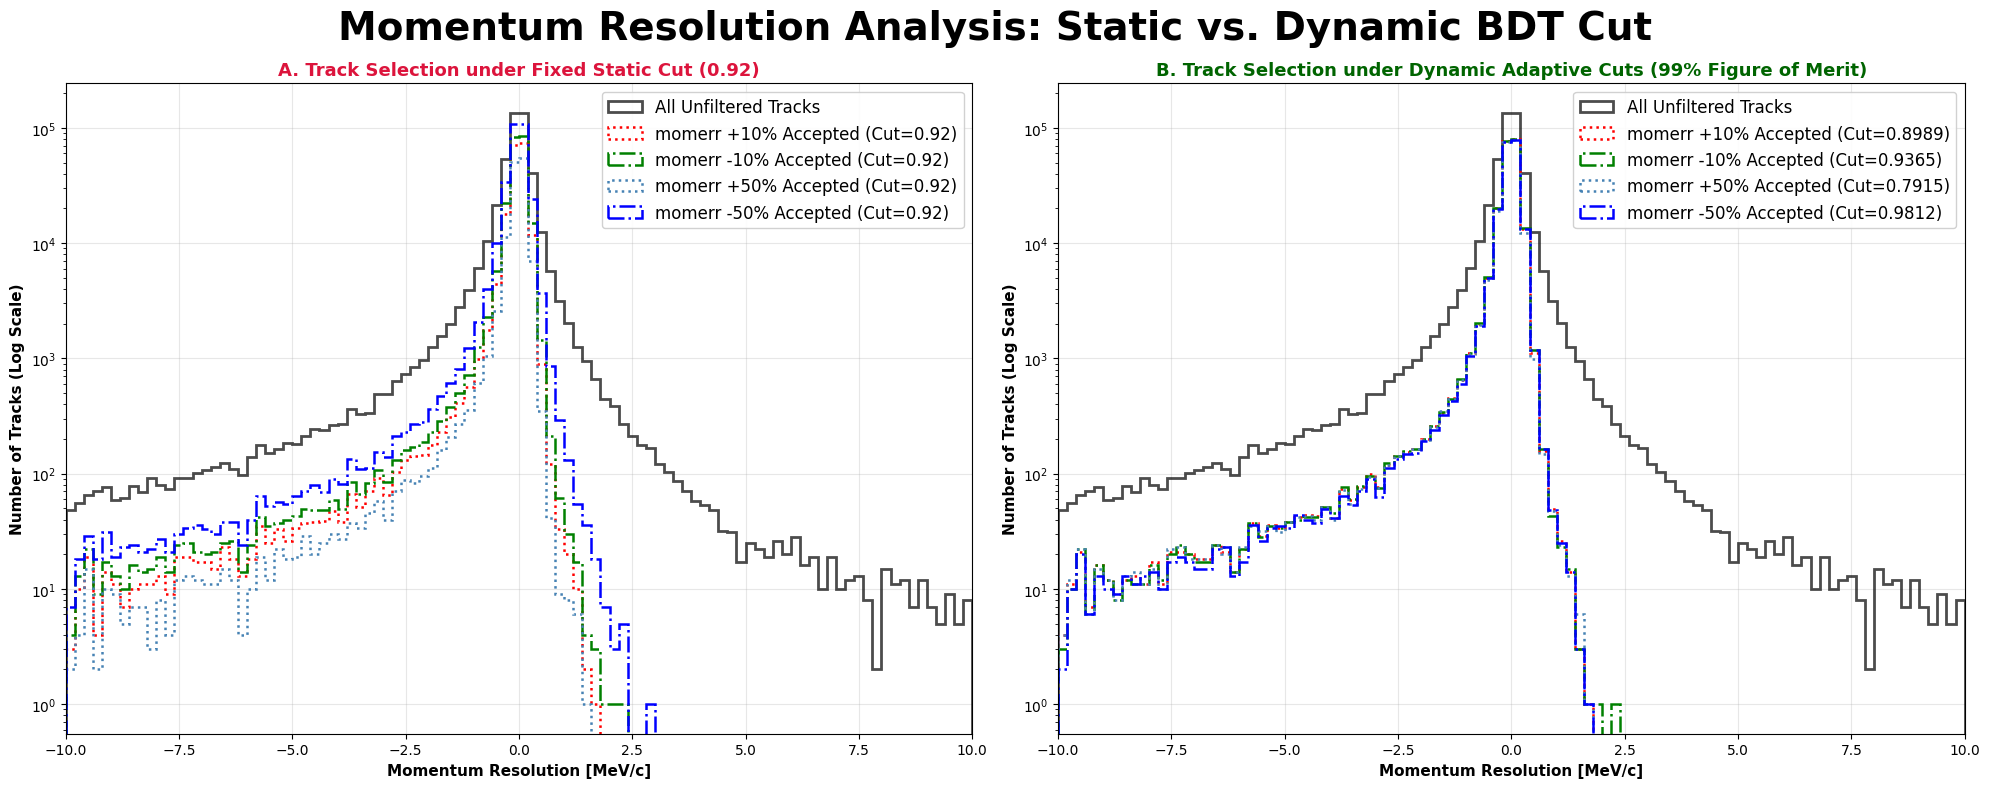

In [ ]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

# 1. Configuration parameters
static_cut = 0.92

# Unique cuts calculated to maintain the constant 99% background rejection target
dynamic_cuts = {
    'momerr +10%': 0.8989,
    'momerr -10%': 0.9365,
    'momerr +50%': 0.7915,
    'momerr -50%': 0.9812,
}

# Dictionary holding dataset configurations, colors, and line styles
variations = {
    'momerr +10%': (1.10, 'red',    ':'),
    'momerr -10%': (0.90, 'green',     '-.'),
    'momerr +50%': (1.50, 'steelblue',   ':'),
    'momerr -50%': (0.50, 'blue', '-.'),
}

# 2. Extract base feature structures from the ROOT file
with uproot.open(training_dataset_filename) as f:
    tree = f[training_dataset_treename]
    arrays = tree.arrays(library="np")
    
    nactive = arrays['trk.nactive']
    nhits   = arrays['trk.nhits']
    factive = nactive / nhits
    fambig  = arrays['trk.nnullambig'] / nactive
    fstraws = arrays['trk.nmatactive'] / nactive
    t0err   = arrays['trk_ent_pars.t0err']
    fitcon  = arrays['trk.fitcon']
    momerr_raw = arrays['trk_ent.momerr']

# 3. Initialize side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle("Momentum Resolution Analysis: Static vs. Dynamic BDT Cut", fontsize=28, fontweight='bold')

# Loop through both axes to plot the background baseline first
for ax in [ax1, ax2]:
    ax.hist(mom_res, bins=n_mom_res_bins, range=(min_mom_res, max_mom_res), log=True, 
            histtype='step', color='black', label='All Unfiltered Tracks', linewidth=2.0, alpha=0.7)

# 4. Generate scores and overlay filtered distributions for both panels simultaneously
for name, (scale_factor, color, linestyle) in variations.items():
    # Scale momerr by its corresponding perturbation factor
    perturbed_momerr = momerr_raw * scale_factor
    
    # Restructure 2D array and compute BDT scores across the full native track sequence
    x_matrix = np.vstack((nactive, factive, t0err, fambig, fitcon, perturbed_momerr, fstraws)).T
    scores = model.predict_proba(x_matrix)[:, 1]
    
    # --- PANEL A: FIXED STATIC CUT SELECTION ---
    passed_static = mom_res[scores >= static_cut]
    ax1.hist(passed_static, bins=n_mom_res_bins, range=(min_mom_res, max_mom_res), log=True, 
             histtype='step', color=color, linestyle=linestyle, linewidth=1.8,
             label=f'{name} Accepted (Cut={static_cut})')
    
    # --- PANEL B: ADAPTIVE DYNAMIC CUT SELECTION ---
    target_cut = dynamic_cuts[name]
    passed_dynamic = mom_res[scores >= target_cut]
    ax2.hist(passed_dynamic, bins=n_mom_res_bins, range=(min_mom_res, max_mom_res), log=True, 
             histtype='step', color=color, linestyle=linestyle, linewidth=1.8,
             label=f'{name} Accepted (Cut={target_cut:.4f})')

# 5. Format Subplot Panel A (Static Selection)
ax1.set_xlim(-10.0, 10.0)
ax1.set_xlabel("Momentum Resolution [MeV/c]", fontweight='bold', fontsize=11)
ax1.set_ylabel("Number of Tracks (Log Scale)", fontweight='bold', fontsize=11)
ax1.set_title("A. Track Selection under Fixed Static Cut (0.92)", fontsize=13, fontweight='bold', color='crimson')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right', fontsize=12, framealpha=0.9)

# 6. Format Subplot Panel B (Dynamic Selection)
ax2.set_xlim(-10.0, 10.0)
ax2.set_xlabel("Momentum Resolution [MeV/c]", fontweight='bold', fontsize=11)
ax2.set_ylabel("Number of Tracks (Log Scale)", fontweight='bold', fontsize=11)
ax2.set_title("B. Track Selection under Dynamic Adaptive Cuts (99% Figure of Merit)", fontsize=13, fontweight='bold', color='darkgreen')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper right', fontsize=12, framealpha=0.9)

plt.tight_layout()
# plt.savefig("momentum_resolution_side_by_side_comparison.png", dpi=200, bbox_inches='tight')
plt.show()


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# =====================================================================
# CONFIG — change this to switch scenarios
# =====================================================================
# Options:
#   "fambig"   ->  just fambig = 1.0
#   "momerr"   ->  just momerr × 2
#   "both"     ->  combined fambig=1 + momerr×2
#   "all"      ->  momerr ±10%, ±50%, fambig=1, combined, original
# =====================================================================
SCENARIO = "all"
# =====================================================================

# ---------------------------------------------------------------------
# Map scenario -> list of (filename, label, color)
# ---------------------------------------------------------------------
def datasets_for(scenario):
    base = training_dataset_filename

    common = [
        (base, "Original", "steelblue"),
    ]
    perturbed = {
        "fambig" : [(base.replace('.root', '_fambig_full.root'),
                     "fambig = 1.0", "orange")],
        "momerr" : [(base.replace('.root', '_momerr_x2.root'),
                     "momerr × 2", "orange")],
        "both"   : [(base.replace('.root', '_fambigFull_momerrX2.root'),
                     "Both stressed", "orange")],
        "all"    : [
            (base.replace('.root', '_momerr_plus10pct.root'),
             "momerr +10%", "tomato"),
            (base.replace('.root', '_momerr_minus10pct.root'),
             "momerr -10%", "limegreen"),
            (base.replace('.root', '_momerr_plus50pct.root'),
             "momerr +50%", "orange"),
            (base.replace('.root', '_momerr_minus50pct.root'),
             "momerr -50%", "darkblue"),
            (base.replace('.root', '_fambig_full.root'),
             "fambig = 1.0", "purple"),
            (base.replace('.root', '_fambigFull_momerrX2.root'),
             "Both stressed", "crimson"),
        ],
    }
    return common + perturbed[scenario]

dataset_meta = datasets_for(SCENARIO)

# ---------------------------------------------------------------------
# Load / compute (score, label) for each entry
# ---------------------------------------------------------------------
def load_scores(fname):
    x = get_features_from_file(fname)
    return model.predict_proba(x)[:, 1]

datasets_roc = []
for fname, label, color in dataset_meta:
    scores = (y_pred_original_full if fname == training_dataset_filename
              else load_scores(fname))
    datasets_roc.append((scores, y_full, label, color))

# ---------------------------------------------------------------------
# Plot parameters
# ---------------------------------------------------------------------
static_cut_target = 0.92
rej_target        = 0.99

# ---------------------------------------------------------------------
# Initialize side-by-side subplots
# ---------------------------------------------------------------------
n_panels = len(datasets_roc)
fig_w = max(22, 14 + 1.5 * (n_panels - 4))   # wider if many panels
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(fig_w, 10))
fig.suptitle(f"ROC Curve Analysis — Static vs Adaptive Cut  "
             f"(scenario: {SCENARIO})",
             fontsize=22, fontweight='bold', y=0.96)

ax_ins1 = inset_axes(ax1, width="40%", height="40%", loc='upper right',
                     bbox_to_anchor=(-0.02, -0.02, 1, 1),
                     bbox_transform=ax1.transAxes)
ax_ins2 = inset_axes(ax2, width="40%", height="40%", loc='upper right',
                     bbox_to_anchor=(-0.02, -0.02, 1, 1),
                     bbox_transform=ax2.transAxes)

# ---------------------------------------------------------------------
# Loop over datasets
# ---------------------------------------------------------------------
for scores, labels, name, color in datasets_roc:
    fpr, tpr, thresholds = roc_curve(labels, scores, pos_label=1)
    auc_score = auc(fpr, tpr)

    # ---- LEFT PANEL: STATIC CUT ----
    idx_static = np.where(thresholds >= static_cut_target)[0]
    idx_s = idx_static[-1] if len(idx_static) > 0 else 0
    sig_eff_s = float(tpr[idx_s])
    bkg_rej_s = float(1 - fpr[idx_s])

    ax1.plot(tpr, 1 - fpr, color=color, linewidth=2,
             label=f"{name:<14} | AUC={auc_score:.4f} | "
                   f"Eff={sig_eff_s*100:5.1f}% | "
                   f"Rej={bkg_rej_s*100:5.2f}%")
    ax1.plot(tpr[idx_s], 1 - fpr[idx_s], 'o', color=color, markersize=8)
    ax_ins1.plot(tpr, 1 - fpr, color=color, linewidth=1.5)
    ax_ins1.plot(tpr[idx_s], 1 - fpr[idx_s], 'o', color=color, markersize=6)

    # ---- RIGHT PANEL: ADAPTIVE CUT ----
    idx_dyn = np.where(1 - fpr >= rej_target)[0]
    idx_d = idx_dyn[-1] if len(idx_dyn) > 0 else 0
    sig_eff_d = float(tpr[idx_d])
    opt_cut   = float(thresholds[idx_d])

    ax2.plot(tpr, 1 - fpr, color=color, linewidth=2,
             label=f"{name:<14} | AUC={auc_score:.4f} | "
                   f"Cut={opt_cut:.3f} | "
                   f"Eff={sig_eff_d*100:5.1f}%")
    ax2.plot(tpr[idx_d], 1 - fpr[idx_d], 'o', color=color, markersize=8)
    ax_ins2.plot(tpr, 1 - fpr, color=color, linewidth=1.5)
    ax_ins2.plot(tpr[idx_d], 1 - fpr[idx_d], 'o', color=color, markersize=6)

# ---------------------------------------------------------------------
# Format LEFT subplot
# ---------------------------------------------------------------------
ax1.plot([0, 1], [1, 0], 'k--', alpha=0.3)
ax1.set_xlabel("Signal Efficiency (TPR)", fontsize=12, fontweight='bold')
ax1.set_ylabel("Background Rejection (1 − FPR)", fontsize=12, fontweight='bold')
ax1.set_title(f"A. Operating Points at Static BDT Cut = {static_cut_target:.2f}",
              fontsize=13, fontweight='bold', color='crimson')
ax1.grid(alpha=0.3)
ax1.legend(loc='lower left', fontsize=11, framealpha=0.9)

ax_ins1.set_xlim(0.35, 0.82)
ax_ins1.set_ylim(0.915, 1.002)
ax_ins1.set_title("Operating-point scatter (zoom)", fontsize=9, fontweight='bold')
ax_ins1.grid(alpha=0.3)
mark_inset(ax1, ax_ins1, loc1=2, loc2=3, fc="none", ec="0.5", ls="--")

# ---------------------------------------------------------------------
# Format RIGHT subplot
# ---------------------------------------------------------------------
ax2.plot([0, 1], [1, 0], 'k--', alpha=0.3)
ax2.set_xlabel("Signal Efficiency (TPR)", fontsize=12, fontweight='bold')
ax2.set_ylabel("Background Rejection (1 − FPR)", fontsize=12, fontweight='bold')
ax2.set_title(f"B. Operating Points at Adaptive Cut (Rej = {rej_target*100:.0f}%)",
              fontsize=13, fontweight='bold', color='darkgreen')
ax2.grid(alpha=0.3)
ax2.legend(loc='lower left', fontsize=11, framealpha=0.9)

ax_ins2.set_xlim(0.50, 0.62)
ax_ins2.set_ylim(0.988, 1.001)
ax_ins2.set_title("Stabilized 99% rejection line (zoom)", fontsize=9, fontweight='bold')
ax_ins2.grid(alpha=0.3)
mark_inset(ax2, ax_ins2, loc1=2, loc2=3, fc="none", ec="0.5", ls="--")

plt.tight_layout(rect=[0, 0, 1, 0.94])
# plt.savefig(f"roc_robustness_{SCENARIO}.png", dpi=200, bbox_inches='tight")
plt.show()


NameError: name 'training_dataset_filename' is not defined